# Finanças da família — o que faz um mês estourar, e como travar isso

> **Estudo de caso com nomes fictícios.** Pessoas, estabelecimentos e cidade foram renomeados; valores, datas e o método são os da análise original. As faturas não estão no repositório.

**Pergunta de negócio:** o que separa um mês em que a fatura líquida da família fica abaixo do teto de `R$ 20.640` de um mês em que ela estoura?

**Decisão que depende disso:** onde cortar e quanto travar por mês, para o mês fechar positivo sempre.

**Muda a decisão se:** a fatura líquida mensal (sem o repasse do pai) ficar abaixo de `R$ 20.640`. Esse é o critério, em reais.

**Expectativa antes do dado:** o casal declarou **não ter hipótese prévia** sobre o que separa um mês bom de um mês ruim. Registrado para reconhecer surpresa depois.

**Público:** o casal (Orlando e Mariana).

**Dados:**
- `dados/marido/` e `dados/esposa/` — 10 faturas Nubank cada, nov/2025 a set/2026.
- `dados/PLANILHA PLANEJAMENTO FINANCEIRO - ... Mês 09_2026.csv` — contas fixas e salários, **referente a set/2026 apenas**.

**Fora do escopo:**
- Auditar o reembolso do pai da Mariana — confirmado fora do dado, não há extrato de conta corrente.
- Ordenar quitação de dívidas por custo — faltam taxa de juros e saldo devedor dos contratos.
- Adivinhar quais compras da fatura são do pai — não existe marcador; nenhuma heurística será inventada.

---

### O pedido como chegou, e a formulação acordada

O pedido chegou em `dados/PROMPT_ANALISE.md`, já com pergunta, decisão e critério definidos, além de números pré-apurados a confirmar.

Uma lacuna foi levantada e resolvida com o casal antes de codar: **as contas fixas existem só para set/2026**, mas os contadores de parcela (`CARRO 08/14`, `MERCADO PAGO 3/10`) revelam a data de início de cada uma — logo, nem todas existiam nos meses anteriores. Ficou acordado apresentar as **duas versões**: as fixas constantes em `R$ 8.860` (para confirmar a tabela do brief) e as fixas reconstruídas mês a mês pelos contadores, mostrando onde divergem.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)  # mostra todas as colunas, sem cortar com "..."


def reais(v):
    return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [2]:
COR_PRIMARIA   = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE   = "#E69F00"
COR_TEXTO      = "#4A5560"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"]

MESES_PT = {1: "jan", 2: "fev", 3: "mar", 4: "abr", 5: "mai", 6: "jun",
            7: "jul", 8: "ago", 9: "set", 10: "out", 11: "nov", 12: "dez"}


def rotulo_mes(p):
    return f"{MESES_PT[p.month]}/{str(p.year)[2:]}"


def eixo_reais(ax, eixo="y"):
    def fmt(v, _):
        if abs(v) >= 1_000_000:
            return f"R$ {v/1e6:,.1f} mi".replace(".", ",")
        if abs(v) >= 1_000:
            return f"R$ {v/1e3:,.0f} mil".replace(",", ".")
        return f"R$ {v:,.0f}".replace(",", ".")
    getattr(ax, f"{eixo}axis").set_major_formatter(plt.FuncFormatter(fmt))


plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

## As 20 faturas foram lidas corretamente?

O formato é brasileiro (`"1.638,34"`) e os negativos vêm com espaço depois do menos (`"- 2.000,00"`). Antes de somar qualquer coisa, preciso confirmar que os valores viraram número de verdade e que os acentos dos títulos sobreviveram.

In [3]:
from pathlib import Path

def ler_faturas(pasta, pessoa):
    partes = []
    for arq in sorted(Path(pasta).glob("Nubank_*.csv")):
        d = pd.read_csv(arq, dtype=str, encoding="utf-8")
        d["pessoa"], d["arquivo"] = pessoa, arq.name
        partes.append(d)
    return pd.concat(partes, ignore_index=True)

fat = pd.concat([ler_faturas("dados/marido", "Orlando"),
                 ler_faturas("dados/esposa", "Mariana")], ignore_index=True)
print(fat.shape)
fat.head(3)

(1796, 5)


,date,title,amount,pessoa,arquivo
0,2025-12-25,Wr Comercial Buritivila,"4,50",Orlando,Nubank_2026-01-03.csv
1,2025-12-25,Posto Portocerrado Buritiflor,"61,90",Orlando,Nubank_2026-01-03.csv
2,2025-12-24,Jim.Com* Tiago Suzuba,"120,00",Orlando,Nubank_2026-01-03.csv


In [4]:
bruto = fat["amount"].copy()
fat["valor"] = (bruto.str.replace(" ", "", regex=False)
                     .str.replace(".", "", regex=False)
                     .str.replace(",", ".", regex=False).astype(float))
fat["data"] = pd.to_datetime(fat["date"], format="%Y-%m-%d")
fat["mes"] = fat["data"].dt.to_period("M")

print("falhas na conversão de valor:", fat["valor"].isna().sum())
print("falhas na conversão de data :", fat["data"].isna().sum())
fat[["date", "data", "mes", "amount", "valor"]].head(3)

falhas na conversão de valor: 0
falhas na conversão de data : 0


,date,data,mes,amount,valor
0,2025-12-25,2025-12-25,2025-12,"4,50",4.5
1,2025-12-25,2025-12-25,2025-12,"61,90",61.9
2,2025-12-24,2025-12-24,2025-12,"120,00",120.0


In [5]:
neg = fat[bruto.str.strip().str.startswith("-")]
print(f"linhas com menos no texto: {len(neg)} | todas viraram negativo? {(neg['valor'] < 0).all()}")
print("menor valor:", reais(fat["valor"].min()), "| maior valor:", reais(fat["valor"].max()))
print("títulos com acento:", fat["title"].str.contains(r"[áàâãéêíóôõúçÁÀÂÃÉÊÍÓÔÕÚÇ]").sum())
neg[["amount", "valor", "title"]].head(3)

linhas com menos no texto: 100 | todas viraram negativo? True
menor valor: R$ -13.230,60 | maior valor: R$ 4.370,01
títulos com acento: 95


,amount,valor,title
14,"- 580,00",-580.0,Pagamento recebido
21,"- 500,00",-500.0,Pagamento recebido
73,"- 5.750,00",-5750.0,Pagamento recebido


**Resultado:** leitura limpa. As 1.796 linhas converteram sem nenhuma falha, os 100 lançamentos com sinal de menos no texto viraram negativos de verdade (o espaço depois do menos não atrapalhou), e os acentos dos nomes de estabelecimento chegaram inteiros. Dá para confiar nos valores.

O menor valor é um crédito de `R$ -13.230,60` e o maior uma compra de `R$ 4.370,01` — nenhum dos dois é absurdo para uma fatura desse tamanho, mas os créditos precisam de tratamento próprio: pagamento de fatura não é gasto, e estorno abate a compra original.

In [6]:
import hashlib, datetime

arqs = sorted(Path("dados").rglob("*.csv"))
tot = sum(a.stat().st_size for a in arqs)
sha = hashlib.sha256(b"".join(a.read_bytes() for a in arqs)).hexdigest()[:16]
print(f"{len(arqs)} arquivos | {tot/1e3:.0f} KB | {len(fat)} lançamentos de fatura")
print("sha256 do conjunto:", sha, "| executado em:", datetime.date.today())

24 arquivos | 80 KB | 1796 lançamentos de fatura
sha256 do conjunto: def9f72123796170 | executado em: 2026-09-28


### Que meses o dado realmente cobre?

A `date` de cada linha é a data da **compra**, não a do vencimento — o arquivo `Nubank_2026-01-03.csv` contém compras de dez/2025. Então o mês tem que sair da coluna, nunca do nome do arquivo. Preciso ver quais meses estão completos antes de calcular qualquer média.

In [7]:
cob = fat.groupby("mes").agg(lancamentos=("valor", "size"),
                             dia_min=("data", lambda s: s.dt.day.min()),
                             dia_max=("data", lambda s: s.dt.day.max()),
                             dias_com_compra=("data", lambda s: s.dt.day.nunique()))
cob["dias_no_mes"] = [p.days_in_month for p in cob.index]
cob

,lancamentos,dia_min,dia_max,dias_com_compra,dias_no_mes
mes,,,,,
2025-11,55,26,30,5,30
2025-12,199,1,31,29,31
2026-01,208,1,31,31,31
2026-02,162,2,28,25,28
2026-03,178,1,31,30,31
2026-04,225,1,30,30,30
2026-05,172,1,31,29,31
2026-06,160,1,30,26,30
2026-07,141,1,31,25,31


**Resultado:** as duas pontas são parciais, como o brief avisou, e o dado confirma com precisão: **nov/2025** só tem compras dos dias 26 a 30 (5 dias) e **set/2026** só vai até o dia 12 — que é justamente o dia em que os arquivos foram extraídos. As duas ficam fora de toda média.

No meio não há buraco de coleta: **dez/2025 a ago/2026 são 9 meses completos**, todos começando no dia 1 e indo até o último dia. Os dias sem compra dentro de um mês (25 a 31 de 28 a 31) são o normal de uma família que não gasta todo santo dia, não falha de extração.

**Janela de análise fixada: dez/2025 a ago/2026, 9 meses completos.** Toda média daqui para a frente usa só ela.

## O conteúdo presta? (portão de qualidade)

A leitura está certa, mas isso não diz que o conteúdo é bom. Varredura automática em toda coluna de todo arquivo lido — inclusive os que talvez eu não use.

In [8]:
import re, unicodedata

_SENTINELAS_TEXTO = {"", "-", ".", "n/a", "na", "null", "none", "nao informado",
                     "não informado", "desconhecido", "sem informacao",
                     "sem informação", "?"}
_SENTINELAS_NUM = (-1, -99, -999, -9999, 999, 9999, 99999)
_PARECE_DATA = re.compile(r"^\s*\d{4}[-/]\d{2}[-/]\d{2}|^\s*\d{2}[-/]\d{2}[-/]\d{4}")


def _achatar(serie):
    sem_acento = (serie.str.normalize("NFKD")
                       .str.encode("ascii", "ignore").str.decode("ascii"))
    return sem_acento.str.strip().str.upper()


def _num(x):
    if pd.isna(x):
        return "?"
    if abs(x) >= 1e9:
        return f"{x:.3g}"
    return f"{int(x):,}" if float(x).is_integer() else f"{x:,.2f}"


def portao(arquivos, tudo=False):
    linhas = []
    for nome, df in arquivos.items():
        if not len(df):
            print(f"{nome}: 0 linhas — nada a varrer")
            continue
        for col in df.columns:
            s, sinal = df[col], []
            nulo = s.isna().mean()
            validos = s.dropna()
            n_dist = validos.nunique()

            if pd.api.types.is_datetime64_any_dtype(s):
                lo, hi = s.min(), s.max()
                info = f"{lo:%Y-%m-%d} → {hi:%Y-%m-%d}" if pd.notna(lo) else "vazia"
                if pd.notna(lo) and lo.year < 1950:
                    sinal.append(f"data mínima {lo:%Y-%m-%d} (sentinela?)")
                agora = pd.Timestamp.now(tz=getattr(s.dt, "tz", None))
                if pd.notna(hi) and hi > agora:
                    sinal.append("datas no futuro")
                h = s.dt.hour
                if h.nunique(dropna=True) > 1:
                    madru, pico = h.between(0, 4).mean(), int(h.mode().iloc[0])
                    info += f" · pico {pico}h"
                    if madru > 0.25 and pico <= 4:
                        sinal.append(f"{madru:.0%} entre 0h-4h e pico {pico}h "
                                     "(fuso? processo automático?)")

            elif pd.api.types.is_bool_dtype(s):
                info = f"{s.mean():.0%} verdadeiro"

            elif pd.api.types.is_numeric_dtype(s):
                lo, hi = s.min(), s.max()
                info = f"{_num(lo)} → {_num(hi)}"
                if lo < 0:
                    sinal.append(f"{(s < 0).sum()} negativos")
                fracionaria = bool((validos % 1 != 0).any())
                nz = int((s == 0).sum())
                if nz and (fracionaria or nz > 0.05 * len(validos)):
                    sinal.append(f"{nz} zeros ({nz/max(len(validos),1):.0%} dos válidos)")
                achadas = [v for v in _SENTINELAS_NUM
                           if (v == lo or v == hi) and (s == v).sum() > 1]
                if achadas:
                    sinal.append("extremo suspeito: " + ", ".join(map(str, achadas)))

            else:
                v = validos.astype(str)
                info = f"{n_dist} distintos"
                if len(v) and _PARECE_DATA.match(v.iloc[0]):
                    sinal.append("parece data em texto — converta")
                if n_dist and _achatar(v).nunique() < n_dist:
                    sinal.append("mesma categoria em grafias diferentes")
                if v.str.strip().str.lower().isin(_SENTINELAS_TEXTO).any():
                    sinal.append("ausência escrita como texto")

            continua = (pd.api.types.is_numeric_dtype(s)
                        and not pd.api.types.is_bool_dtype(s)
                        and bool((validos % 1 != 0).any()))
            if (not pd.api.types.is_datetime64_any_dtype(s) and not continua
                    and len(validos) >= 50 and n_dist > 0.5 * len(validos)):
                sinal.append("cardinalidade alta (id ou texto livre)")
            if nulo > 0.005:
                sinal.append(f"{nulo:.0%} nulo")
            linhas.append({"arquivo": nome, "coluna": col,
                           "conteudo": info, "sinal": " · ".join(sinal)})

    colunas = ["arquivo", "coluna", "conteudo", "sinal"]
    t = pd.DataFrame(linhas, columns=colunas)
    return t if tudo else t[t["sinal"] != ""].reset_index(drop=True)

In [9]:
ARQ_PLAN = "dados/PLANILHA PLANEJAMENTO FINANCEIRO - Orlando e Mariana Mês 09_2026.csv"
plan_bruta = pd.read_csv(ARQ_PLAN, header=None, dtype=str, encoding="utf-8")

portao({"faturas": fat[["data", "mes", "title", "valor", "pessoa", "arquivo"]],
        "planilha": plan_bruta})

,arquivo,coluna,conteudo,sinal
0,faturas,title,872 distintos,mesma categoria em grafias diferentes
1,faturas,valor,"-13,230.60 → 4,370.01",100 negativos
2,planilha,0,21 distintos,38% nulo
3,planilha,1,12 distintos,53% nulo
4,planilha,2,3 distintos,91% nulo
5,planilha,3,3 distintos,ausência escrita como texto · 91% nulo
6,planilha,4,3 distintos,91% nulo
7,planilha,5,3 distintos,91% nulo


In [10]:
chave = ["pessoa", "data", "title", "valor"]
dups = fat[fat.duplicated(subset=chave, keep=False)].sort_values(chave)
print(f"linhas idênticas (pessoa+data+título+valor): {fat.duplicated(subset=chave).sum()}")
print(f"envolvem {dups['title'].nunique()} títulos | soma repetida: {reais(fat[fat.duplicated(subset=chave)]['valor'].sum())}")
dups.groupby("title")["valor"].agg(["size", "mean"]).sort_values("size", ascending=False).head(8)

linhas idênticas (pessoa+data+título+valor): 2
envolvem 2 títulos | soma repetida: R$ 141,14


,size,mean
title,,
Palmaserra - Parcela 2/3,2,70.57
Palmaserra - Parcela 3/3,2,70.57


In [11]:
fat[fat["title"].str.startswith("Palmaserra")][["pessoa", "data", "title", "valor", "arquivo"]].sort_values("data")

,pessoa,data,title,valor,arquivo
596,Orlando,2026-05-07,Palmaserra - Parcela 1/3,70.59,Nubank_2026-06-03.csv
591,Orlando,2026-05-08,Palmaserra - Parcela 1/3,70.59,Nubank_2026-06-03.csv
753,Orlando,2026-05-27,Palmaserra - Parcela 2/3,70.57,Nubank_2026-07-03.csv
762,Orlando,2026-05-27,Palmaserra - Parcela 2/3,70.57,Nubank_2026-07-03.csv
846,Orlando,2026-06-26,Palmaserra - Parcela 3/3,70.57,Nubank_2026-08-03.csv
856,Orlando,2026-06-26,Palmaserra - Parcela 3/3,70.57,Nubank_2026-08-03.csv
930,Orlando,2026-08-07,Palmaserra - Parcela 1/3,70.59,Nubank_2026-09-03.csv


**Resultado:** as duas linhas repetidas **não são duplicata** — são duas compras diferentes no mesmo lugar. A `Parcela 1/3` aparece em 07/05 e em 08/05, dias distintos: são dois parcelamentos paralelos de valor igual, e por isso as parcelas 2 e 3 de cada um caem no mesmo dia e ficam idênticas na fatura. Mantenho as duas. São `R$ 141,14` no total — não mudam nada, mas apagar teria sido erro.

Nenhuma outra repetição em 1.796 linhas. O dado não tem duplicata de exportação.

### O que são os 100 lançamentos negativos?

Crédito na fatura não é uma coisa só. **Pagamento de fatura** é você quitando o cartão — não é gasto nem receita, e tem que ficar fora do total. **Estorno** e **ajuste a crédito** são devolução de uma compra — esses abatem o gasto. Misturar os dois erra o total nos dois sentidos.

In [12]:
creditos = fat[fat["valor"] < 0]
t = creditos.groupby("title")["valor"].agg(operacoes="size", total="sum").sort_values("total")
t["total"] = t["total"].apply(reais)
t

,operacoes,total
title,,
Pagamento recebido,63,"R$ -252.571,43"
"Crédito de Confiança de ""Amazon""",1,"R$ -566,28"
"Estorno de ""Pg *Cod3r Ensino e Con"" (Pg *Cod3r Ensino e Con)",1,"R$ -149,00"
"Crédito de ""Manual""",1,"R$ -145,00"
"Estorno de ""Palmaserra"" (Palmaserra)",1,"R$ -70,59"
Estorno de compra (Palmamangal**Palmabelo Jequitibavereda Mangalmonte),1,"R$ -67,99"
IOF de volta de Anthropic* Claude Sub,3,"R$ -59,90"
"Estorno de ""Hubla *Mangaldourado"" (Hubla *Mangaldourado)",2,"R$ -50,07"
IOF de volta de Claude.Ai Subscription,3,"R$ -41,73"


**Resultado:** os créditos se partem em dois grupos bem distintos. **"Pagamento recebido"** são 63 lançamentos e concentram quase todo o valor — é o casal quitando a fatura, movimentação de caixa, não gasto. Fica fora do total.

Todo o resto é devolução de compra: estornos, créditos de estabelecimento e "IOF de volta". Esses **abatem** a compra original e continuam no total, com sinal negativo.

Uma observação que já serve ao Passo 7: a existência de **"IOF de volta"** prova que há IOF sendo cobrado — mas em assinaturas internacionais (Anthropic, Vercel, OpenAI, Resend), não em Pix no Crédito. Guardo para quando chegar na pergunta da tarifa.

## O grão e as definições

**Cada linha é um lançamento na fatura de um cartão** — uma compra à vista, **uma parcela** de uma compra parcelada, ou um crédito. Não é uma compra: uma compra parcelada em 10 gera 10 linhas, em 10 meses diferentes.

Isso significa que existem **três números diferentes** escondidos no mesmo dado, e cada pergunta usa um:
1. **Fluxo do mês** — o que caiu na fatura naquele mês. É o número que decide se o mês fecha positivo, e é o que a análise usa.
2. **Decisão** — a compra inteira contada no mês em que foi feita. Serve para saber quanto foi *assumido* num mês.
3. **Compromisso futuro** — as parcelas que ainda vão cair. Não aparece em nenhum agrupamento simples, e é o que o Passo 6 precisa.

### A normalização do título

O portão de qualidade já sinalizou "mesma categoria em grafias diferentes". O mesmo destinatário de Pix aparece com prefixo (`Pix no Crédito - Mariana Aragao Medeiros`) e sem (`MARIANA ARAGAO MEDEIROS`). Agrupar pelo título cru trata os dois como coisas diferentes — e filtrar pelo prefixo perde uma parte grande do valor. A regra: tirar o prefixo, tirar o sufixo de parcela, colapsar espaço, subir para maiúscula.

In [13]:
RE_PARCELA = re.compile(r"\s*-?\s*(?:parcela\s*)?(\d{1,2})\s*/\s*(\d{1,2})\s*$", re.I)
RE_PIX = re.compile(r"^\s*pix no cr[eé]dito\s*-\s*", re.I)

# Mesmo fornecedor em grafias diferentes. O critério para unir: os nomes
# compartilham prefixo E nunca aparecem no mesmo mês — assinatura única que
# trocou de grafia, não dois estabelecimentos. Ver a varredura mais abaixo.
ALIAS = {r"DL ?\*STARLINK.*": "STARLINK",
         r"LUZFORTE.*": "LUZFORTE ENERGIA",
         # renomeada em jun/26: CLAUDE.AI SUBSCRIPTION (abr-mai) → ANTHROPIC* CLAUDE
         # SUB (jun-ago). Mesmo patamar, períodos disjuntos. NÃO inclui "ANTHROPIC"
         # puro, que é outro produto (~R$ 103/mês).
         r"CLAUDE\.AI SUBSCRIPTION|ANTHROPIC\* CLAUDE SUB": "ANTHROPIC CLAUDE",
         # Apple em 3 grafias e Spotify em 3 — mesma armadilha, achadas na
         # auditoria de assinaturas. Sem unificar, cada pedaço parece pequeno
         # e descontinuado, e a assinatura viva some da lista de canceláveis.
         r"APPLE\.?COM/?BILL\.?|APPLECOMBILL|\(APPLE\)": "APPLE",
         r"(DM|EBN) ?\*ESPOTIFY|(DM|EBN) ?\*SPOTIFY": "SPOTIFY",
         r"MP \*CERRADOMANGAL|PEIXARIA ARAUCARIAALTO": "PEIXARIA ARAUCARIAALTO",
         # o número da linha entra no título e muda; sem unificar, "CLARO *CLARO"
         # vira um destino separado e a conta parece ter falhado um mês
         r"CLARO ?\*.*": "CLARO",
         # o MESMO pet shop em 7 grafias — com e sem espaço, com o prefixo da
         # maquininha (CAPPTA, TRADIO) e com dois nomes de fantasia. Separadas,
         # nenhuma parecia fornecedor recorrente e o pet parecia gasto avulso;
         # unidas, é a compra de ração que o casal descreveu.
         r".*REDE ?VEREDACERRADO ?(SERRANOVO\w*|PET ?C\w*)": "REDE VEREDACERRADO PET CENTER"}

def normaliza(t):
    s = RE_PIX.sub("", str(t))
    s = RE_PARCELA.sub("", s)
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"\s+", " ", s).strip().upper()
    for pad, canon in ALIAS.items():
        if re.fullmatch(pad, s):
            return canon
    return s

fat["destino"] = fat["title"].map(normaliza)
fat["eh_pix"] = fat["title"].str.match(RE_PIX)
m = fat["title"].str.extract(RE_PARCELA)
fat["parcela_n"] = pd.to_numeric(m[0])
fat["parcela_de"] = pd.to_numeric(m[1])

print(f"títulos distintos: {fat['title'].nunique()} → destinos normalizados: {fat['destino'].nunique()}")
print(f"lançamentos via Pix no Crédito: {fat['eh_pix'].sum()} | com sufixo de parcela: {fat['parcela_n'].notna().sum()}")
fat[["title", "destino", "eh_pix", "parcela_n", "parcela_de"]].iloc[[0, 1]]

títulos distintos: 872 → destinos normalizados: 574
lançamentos via Pix no Crédito: 89 | com sufixo de parcela: 341


,title,destino,eh_pix,parcela_n,parcela_de
0,Wr Comercial Buritivila,WR COMERCIAL BURITIVILA,False,NaN,NaN
1,Posto Portocerrado Buritiflor,POSTO PORTOCERRADO BURITIFLOR,False,NaN,NaN


In [14]:
RE_ESTORNO = re.compile(r'^\s*estorno d[eo] (?:compra )?"?(.+?)"?\s*(?:\(.*\))?\s*$', re.I)

def parcelamentos_cancelados(df):
    """Parcela 1/N estornada = a compra foi desfeita e as N-1 restantes NUNCA vão
    cair. Sem isso a projeção da esteira carrega parcela fantasma. Casa o estorno
    com a parcela pelo destino e pelo valor, dentro de 45 dias."""
    est = df[df["valor"] < 0].copy()
    est["ref"] = est["title"].str.extract(RE_ESTORNO, expand=False).map(
        lambda s: normaliza(s) if isinstance(s, str) else None)
    est = est.dropna(subset=["ref"])
    par = df[df["parcela_n"].notna() & (df["valor"] > 0)]
    fora = []
    for _, e in est.iterrows():
        alvo = par[(par["destino"] == e["ref"]) & (par["valor"].round(2) == round(-e["valor"], 2))
                   & (par["data"] <= e["data"])
                   & ((e["data"] - par["data"]).dt.days <= 45)]
        if len(alvo):
            fora.append(alvo.sort_values("data").index[-1])
    return fora

CANCELADOS = parcelamentos_cancelados(fat)
fat["parcela_cancelada"] = fat.index.isin(CANCELADOS)
print(f"{len(CANCELADOS)} parcela(s) estornada(s) — a compra foi desfeita:")
print(fat.loc[CANCELADOS, ["data", "pessoa", "title", "valor"]]
      .assign(data=lambda d: d["data"].dt.strftime("%d/%m/%y")).to_string(index=False))
print("""
⚠ DUAS FRAGILIDADES DESTA REGRA, e elas empurram para lados opostos:
  1. Ela exige valor EXATO e 45 dias. Estorno parcial, estorno do valor cheio da
     compra (em vez de uma parcela), ou crédito que chega depois de 45 dias NÃO
     casam — nesses casos o plano cancelado continua contado, e o compromisso
     futuro fica SUPERESTIMADO. É o lado conservador.
  2. Ela casa por destino + valor, não por identificador do plano. Se o mesmo
     estabelecimento tiver dois carnês com parcela do mesmo valor, o estorno pode
     ser atribuído ao carnê errado — o total não muda, mas a data de término de um
     deles fica errada. Com 20 planos ainda com parcela a cair, confira no
     app antes de contar com uma data específica.""")

4 parcela(s) estornada(s) — a compra foi desfeita:
    data pessoa                                 title  valor
06/06/26    Orlando Pg *Cod3r Ensino e Con - Parcela 1/12 149.00
01/08/26    Orlando       Hubla *Mangaldourado - Parcela 1/12  29.69
01/08/26    Orlando       Hubla *Mangaldourado - Parcela 1/12  20.38
07/08/26    Orlando            Palmaserra - Parcela 1/3  70.59

⚠ DUAS FRAGILIDADES DESTA REGRA, e elas empurram para lados opostos:
  1. Ela exige valor EXATO e 45 dias. Estorno parcial, estorno do valor cheio da
     compra (em vez de uma parcela), ou crédito que chega depois de 45 dias NÃO
     casam — nesses casos o plano cancelado continua contado, e o compromisso
     futuro fica SUPERESTIMADO. É o lado conservador.
  2. Ela casa por destino + valor, não por identificador do plano. Se o mesmo
     estabelecimento tiver dois carnês com parcela do mesmo valor, o estorno pode
     ser atribuído ao carnê errado — o total não muda, mas a data de término de um
     deles fica 

In [15]:
from itertools import combinations

def grafias_do_mesmo(df, col="destino", min_meses=2, min_prefixo=12):
    """Pares que são a MESMA coisa com nomes diferentes: compartilham prefixo,
    os dois são recorrentes, e NUNCA aparecem no mesmo mês. Coexistir todo mês =
    estabelecimentos distintos; nunca coexistir = grafia que mudou."""
    g = df.groupby(col)
    meses, mm = g["mes"].agg(set), g.apply(lambda x: x.groupby("mes")["valor"].sum().mean(), include_groups=False)
    cand, saida = [d for d in meses.index if len(meses[d]) >= min_meses], []
    for a, b in combinations(sorted(cand), 2):
        ra, rb = re.sub(r"[^A-Z]", "", a), re.sub(r"[^A-Z]", "", b)
        if ra == rb or min(len(ra), len(rb)) < 8 or (meses[a] & meses[b]):
            continue
        if ra.startswith(rb[:min_prefixo]) or rb.startswith(ra[:min_prefixo]):
            saida.append({"a": a, "b": b, "mensal_a": round(mm[a], 2), "mensal_b": round(mm[b], 2)})
    return pd.DataFrame(saida)

sus = grafias_do_mesmo(fat[fat["valor"] > 0])
print(f"{len(sus)} par(es) com prefixo comum e meses disjuntos, DEPOIS do ALIAS: "
      f"{'nenhum' if not len(sus) else ''}")
sus if len(sus) else None

0 par(es) com prefixo comum e meses disjuntos, DEPOIS do ALIAS: nenhum


## PASSO 0 — O que é da família e o que é do pai da Mariana

O cartão carrega gasto de terceiro: o casal usa o cartão para ajudar o pai da Mariana, e ele repassa o valor. Isso **não é despesa da família** — entra e sai. Sem separar, nenhum número da análise vale.

Todo pagamento a `MARIANA ARAGAO MEDEIROS` e a `VITOR VELOSO MEDEIROS` é conta do pai (confirmado pelo casal). O teste da normalização é este: se o agrupamento pelo destinatário estiver certo, o total tem que chegar perto de `R$ 40.819`. Se der bem menos, o agrupamento está errado.

In [16]:
PAI = ["MARIANA ARAGAO MEDEIROS", "VITOR VELOSO MEDEIROS"]
fat["eh_pai"] = fat["destino"].isin(PAI)

comp = fat[fat["eh_pai"]].groupby(["destino", fat["eh_pix"].map({True: "com prefixo Pix", False: "sem prefixo"})])["valor"].agg(operacoes="size", total="sum")
print("total do repasse no período todo:", reais(fat.loc[fat["eh_pai"], "valor"].sum()))
print("esperado pelo brief: R$ 40.819,00")
comp

total do repasse no período todo: R$ 40.819,44
esperado pelo brief: R$ 40.819,00


operacoes     total
destino                   eh_pix                              
MARIANA ARAGAO MEDEIROS com prefixo Pix          6  13582.31
                          sem prefixo              5  13194.19
VITOR VELOSO MEDEIROS     com prefixo Pix          6  13563.86
                          sem prefixo              4    479.08

**Resultado:** `R$ 40.819,44` — bate com o valor apurado pelo casal. O agrupamento pelo destinatário normalizado está certo.

E a tabela mostra por que a armadilha é séria: **12 operações** vêm com o prefixo `Pix no Crédito` e **9 vêm sem prefixo nenhum**, só o nome em maiúscula. Quem filtrasse pelo prefixo pegaria `R$ 27.146,17` e perderia `R$ 13.673,27` — **um terço do repasse inteiro** ficaria escondido dentro do "gasto da família", e o diagnóstico sairia errado em mais de `R$ 1.300` por mês.

A lição vale além deste caso: o mesmo pagamento aparece em dois formatos de título, e nada no dado avisa. Agrupar pelo nome normalizado é o que salva.

In [17]:
JANELA = pd.period_range("2025-12", "2026-08", freq="M")

rep = fat[fat["eh_pai"]].groupby("mes")["valor"].agg(ops="size", total="sum").reindex(
    pd.period_range("2025-11", "2026-09", freq="M"), fill_value=0)
rep["patamar"] = ["parcial"] + ["~2.700 (dez-mai)"] * 6 + ["novo (jun-ago)"] * 3 + ["parcial"]
rep["total_fmt"] = rep["total"].apply(reais)
rep[["ops", "total_fmt", "patamar"]]

,ops,total_fmt,patamar
2025-11,0,"R$ 0,00",parcial
2025-12,2,"R$ 2.878,38",~2.700 (dez-mai)
2026-01,3,"R$ 2.752,00",~2.700 (dez-mai)
2026-02,2,"R$ 2.736,42",~2.700 (dez-mai)
2026-03,1,"R$ 2.660,82",~2.700 (dez-mai)
2026-04,1,"R$ 2.645,65",~2.700 (dez-mai)
2026-05,1,"R$ 2.650,52",~2.700 (dez-mai)
2026-06,4,"R$ 5.522,30",novo (jun-ago)
2026-07,3,"R$ 6.497,00",novo (jun-ago)
2026-08,2,"R$ 5.295,29",novo (jun-ago)


In [18]:
antes = rep.loc[pd.period_range("2025-12", "2026-05", freq="M"), "total"]
depois = rep.loc[pd.period_range("2026-06", "2026-08", freq="M"), "total"]
for rot, s in [("dez/25-mai/26", antes), ("jun-ago/26", depois)]:
    print(f"{rot:>14}  media {reais(s.mean()):>14}  min {reais(s.min()):>14}  max {reais(s.max()):>14}")
print(f"\nsalto: {reais(depois.mean() - antes.mean())}/mes ({depois.mean()/antes.mean():.2f}x) | "
      f"custo extra anualizado: {reais((depois.mean() - antes.mean()) * 12)}")
print(f"set/26 em 12 dias: {reais(rep.loc[pd.Period('2026-09'), 'total'])} — ja acima do maior mes completo")

 dez/25-mai/26  media    R$ 2.720,63  min    R$ 2.645,65  max    R$ 2.878,38
    jun-ago/26  media    R$ 5.771,53  min    R$ 5.295,29  max    R$ 6.497,00

salto: R$ 3.050,90/mes (2.12x) | custo extra anualizado: R$ 36.610,78
set/26 em 12 dias: R$ 7.181,06 — ja acima do maior mes completo


**Resultado: o repasse ao pai mudou de patamar em junho** — de `R$ 2.720` para `R$ 5.772`/mês, e as duas faixas não se sobrepõem (o mês mais caro do período antigo, `R$ 2.878`, está abaixo do mais barato do novo, `R$ 5.295`).

**Isso não é despesa de vocês, não é risco, e o assunto para aqui.** Ele paga em dia — está confirmado, e o dado concorda. O único motivo de a análise medir esse valor é operacional: são `R$ 5.434`/mês entrando e saindo pela fatura da Mariana, e enquanto estiverem misturados **vocês não conseguem ver o próprio gasto no aplicativo**. É por isso que o cartão virtual dedicado a ele é o primeiro item do plano — não pelo dinheiro dele, pela visibilidade do de vocês.

Daqui em diante todo número de gasto desta análise é **só de vocês dois**: a conta do pai está fora.


### Existem outros repasses escondidos?

Dois nomes já estão confirmados como conta do pai. Mas se o cartão é usado para repassar dinheiro a uma pessoa, pode haver outras. Duas varreduras: os demais sobrenomes `MEDEIROS` (família da Mariana) e os maiores destinatários de Pix em geral. Meço e levo para o casal decidir — não classifico ninguém por conta própria.

In [19]:
outros_carrijo = (fat[fat["destino"].str.contains("MEDEIROS") & ~fat["eh_pai"]]
                  .groupby("destino")
                  .agg(ops=("valor", "size"), total=("valor", "sum"),
                       cartoes=("pessoa", lambda s: "+".join(sorted(s.unique())))))
outros_carrijo["total"] = outros_carrijo["total"].apply(reais)
outros_carrijo.sort_values("ops", ascending=False)

,ops,total,cartoes
destino,,,
OTAVIO GITURU MEDEIROS FIGUEIREDO,5,"R$ 1.070,13",Mariana
VILASOL RANGEL MEDEIROS,4,"R$ 206,35",Mariana
IGOR COELHO MEDEIROS,3,"R$ 402,32",Mariana
PEDRAMONTE AZEVEDO MEDEIROS,1,"R$ 153,04",Mariana
PORTOCLARO,1,"R$ 22,09",Orlando
CHAPADAFLOR AZEVEDO MEDEIROS BEZERRA,1,"R$ 45,00",Orlando
VEREDACAMPO TOLEDO MEDEIROS,1,"R$ 49,34",Orlando


In [20]:
so_maiusc = fat["title"].str.replace(r"[^A-Za-zÀ-ÿ]", "", regex=True)
fat["titulo_caixa_alta"] = so_maiusc.str.isupper() & (so_maiusc.str.len() > 3)
fat["eh_transferencia"] = fat["eh_pix"] | fat["titulo_caixa_alta"]

def sem_documento(s):   # tira raiz de CPF/CNPJ colada ao nome — não vai para o output
    return s.str.replace(r"^[\d.\-/]+\s*", "", regex=True)

print(f"Pix com prefixo: {fat['eh_pix'].sum()} | título em CAIXA ALTA: {fat['titulo_caixa_alta'].sum()} | união: {fat['eh_transferencia'].sum()}")
sem_documento(fat.loc[fat["titulo_caixa_alta"] & ~fat["eh_pix"], "title"]).value_counts().head(12).to_frame("ocorrencias")

Pix com prefixo: 89 | título em CAIXA ALTA: 90 | união: 179


,ocorrencias
title,
QUEZIA PEIXOTO FIGUEIREDO,8
IARA IGOR URBANO DE PAIVA,3
LUZFORTE ENERGIA CAMPOVERDE,3
MARIANA ARAGAO MEDEIROS,3
LUZFORTE CAMPOVERDE ARAUCARIAPORTO PEDRASERRA SA,3
DROGA MANGALAZUL,3
FACEBOOK SERVICOS ONLINE DO BRASIL LTDA,2
HELOISA ARARATUCANO DE BEZERRA,2
IPEALTO,2


In [21]:
top_transf = (fat[fat["eh_transferencia"] & ~fat["eh_pai"]]
              .groupby("destino")
              .agg(ops=("valor", "size"), total=("valor", "sum"),
                   meses=("mes", "nunique"),
                   cartoes=("pessoa", lambda s: "+".join(sorted(s.unique())))))
top15 = top_transf.sort_values("total", ascending=False).head(15)
print(f"{len(top_transf)} destinos de transferência fora do pai | total {reais(top_transf['total'].sum())}")
top15.assign(total=top15["total"].apply(reais))

102 destinos de transferência fora do pai | total R$ 21.225,45


,ops,total,meses,cartoes
destino,,,,
QUEZIA PEIXOTO FIGUEIREDO,14,"R$ 2.343,44",8,Mariana+Orlando
LUZFORTE ENERGIA,7,"R$ 1.741,81",5,Mariana+Orlando
MANGALPALMA FERNANDES JEQUITIBADOURADO,1,"R$ 1.424,52",1,Orlando
IGREJA EVANGELICA MINISTERIO BURITICAMPO LAGOAJATOBA,4,"R$ 756,35",3,Mariana+Orlando
JOEL CHAPADACERRADO PEIXOTO VELOSO,2,"R$ 697,92",1,Orlando
PEDREIRA LAGOABELO RIOLESTE,1,"R$ 662,36",1,Orlando
OTAVIO GITURU MEDEIROS FIGUEIREDO,3,"R$ 655,45",3,Mariana
VEREDARIO XAVIER DE IPESOL,2,"R$ 544,71",2,Mariana
IPEBONITO CAIO VELOSO CAMPOBARRA PAIVA,3,"R$ 521,86",3,Mariana+Orlando


In [22]:
fat[fat["destino"].str.contains("OTAVIO")][["pessoa", "data", "title", "valor", "eh_pix", "titulo_caixa_alta"]].sort_values("data")

,pessoa,data,title,valor,eh_pix,titulo_caixa_alta
1168,Mariana,2025-12-07,OTAVIO GITURU MEDEIROS FIGUEIREDO,334.31,False,True
1394,Mariana,2026-03-07,Otavio Gituru Medeiros Figueiredo,269.24,False,False
1444,Mariana,2026-04-20,Otavio Gituru Medeiros Figueiredo,145.44,False,False
1584,Mariana,2026-06-16,Pix no Crédito - Otavio Gituru Medeiros Figueiredo,131.39,True,False
1702,Mariana,2026-08-13,Pix no Crédito - Otavio Gituru Medeiros Figueiredo,189.75,True,False


**Resultado:** o mesmo destinatário aparece de **três** formas diferentes, não duas:

1. `OTAVIO GITURU MEDEIROS FIGUEIREDO` — caixa alta, sem prefixo
2. `Otavio Gituru Medeiros Figueiredo` — **caixa de título, sem prefixo**
3. `Pix no Crédito - Otavio Gituru Medeiros Figueiredo` — com prefixo

O formato 2 é o mais perigoso dos três, porque **é graficamente idêntico ao nome de um estabelecimento**. `Otavio Gituru Medeiros Figueiredo` e `Supermercado do Pedratucano` têm exatamente a mesma aparência para qualquer regra automática. Não existe jeito de separar transferência de compra pela grafia do título.

Duas consequências:

- **A normalização por nome está certa e é a única coisa que funciona.** Ela junta os três formatos (foi o que fez o total do repasse bater com `R$ 40.819`). Qualquer filtro por prefixo ou por caixa perde parte do valor.
- **A lista de transferências acima está incompleta**, porque foi montada com a marca "Pix ou caixa alta", que não pega o formato 2. Vou refazer o ranking sobre **todos** os destinos, sem heurística de formato.

Também registro uma divergência: o brief estimava `R$ 321` para OTAVIO e eu encontrei `R$ 1.070,13` em 5 operações. Provavelmente a estimativa original não capturou os três formatos. O número desta análise está no output acima, linha por linha, e pode ser conferido.

In [23]:
gasto = fat[(fat["destino"] != "PAGAMENTO RECEBIDO") & fat["mes"].isin(JANELA)]

top = (gasto[~gasto["eh_pai"]].groupby("destino")
       .agg(ops=("valor", "size"), total=("valor", "sum"), meses=("mes", "nunique"),
            cartoes=("pessoa", lambda s: "+".join(sorted(s.unique()))),
            via_pix=("eh_pix", "sum")))
top20 = top.sort_values("total", ascending=False).head(20)
print(f"{len(top)} destinos distintos (sem o pai, janela dez/25-ago/26) | total {reais(top['total'].sum())}")
pos_vivo = int(top["total"].rank(ascending=False)["CONTA VIVO"])
print(f"CONTA VIVO fica em {pos_vivo}º: {reais(top.loc['CONTA VIVO', 'total'] / 9)}/mês — fora do top-20 por pouco")
top20.assign(total=top20["total"].apply(reais), media_mes=(top20["total"] / 9).apply(reais))

549 destinos distintos (sem o pai, janela dez/25-ago/26) | total R$ 198.880,73
CONTA VIVO fica em 22º: R$ 209,23/mês — fora do top-20 por pouco


,ops,total,meses,cartoes,via_pix,media_mes
destino,,,,,,
SUPERMERCADO DO PEDRATUCANO,51,"R$ 15.762,28",9,Mariana+Orlando,0,"R$ 1.751,36"
AUTO POSTO,27,"R$ 6.358,45",9,Mariana+Orlando,0,"R$ 706,49"
BURITIAZUL COMERCIO DE,5,"R$ 6.024,00",3,Mariana,0,"R$ 669,33"
DROGA SERRAVILA,31,"R$ 4.805,97",9,Mariana+Orlando,0,"R$ 534,00"
CANELACLARO LO AGRO,11,"R$ 4.100,10",4,Mariana+Orlando,0,"R$ 455,57"
CANELACLARO,113,"R$ 3.838,83",9,Mariana+Orlando,1,"R$ 426,54"
JATOBAALTO VET CLINICA,14,"R$ 3.731,00",9,Mariana+Orlando,0,"R$ 414,56"
SUPERMERCADO VEREDAAZUL,17,"R$ 3.259,41",8,Mariana+Orlando,0,"R$ 362,16"
MANGALSOL LAGOAJATOBA,9,"R$ 3.150,00",8,Mariana,0,"R$ 350,00"


**Resultado:** o ranking sem heurística nenhuma. Três coisas saltam:

**Pessoas físicas com pagamento recorrente.** `QUEZIA PEIXOTO FIGUEIREDO` aparece em 7 dos 9 meses, nos dois cartões, `R$ 224`/mês — quatro vezes por Pix. Esse perfil (todo mês, valor parecido, duas origens) é de serviço contratado, não de compra avulsa. `SUSITA CORREIA DE` está em 7 meses também.

**Contas fixas vazando para o cartão.** `CONTA VIVO` fica logo abaixo do corte da tabela (22º, `R$ 209`/mês) — e a planilha lança VIVO como `R$ 75`. É o primeiro vazamento confirmado; o Passo 1 vai atrás dos outros.

**Uma dimensão que o brief não mencionou: há atividade rural.** `BURITIAZUL COMERCIO DE`, `JL VEREDAPORTO NUTRICAO A`, `CANELACLARO LO AGRO` somam mais de `R$ 13 mil` no período, e a planilha tem uma linha `ENERGIA FAZENDA`. Isso é gasto de produção, não consumo doméstico — e trata-se de outra categoria de decisão. Vou medir e perguntar.

O total sem o pai dá `R$ 198.880,73` em 9 meses, ou `R$ 22.098`/mês — perto dos `R$ 22.244` do brief, com `R$ 146`/mês de diferença que preciso reconciliar.

> ⚠️ **Este ranking exclui só os Pix ao pai.** Mais abaixo o casal identifica que parte das compras também é dele, e o total da família cai de `R$ 22.098` para `R$ 20.401`/mês. Este bloco é o estado do conhecimento antes daquela descoberta.

## A tabela central bate? (fatura líquida da família × teto)

O brief traz uma tabela de nove meses com a fatura líquida da família e o saldo contra o teto de `R$ 20.640`. Ela é a base de todo o plano, então tem que ser reproduzida com código antes de qualquer outra coisa.

**Definição de "fatura líquida da família":** soma de todos os lançamentos do mês da compra, nos dois cartões, **excluindo** os pagamentos de fatura (movimentação de caixa) e **excluindo** os destinatários do pai. Estornos e créditos entram com sinal negativo, abatendo.

In [24]:
RENDA = 29_500.0
# A planilha de set/26 lançava R$ 8.860 de contas fixas, e é contra ela que o
# critério do brief foi definido — esse número não se move. O casal informou em
# out/26 que a Vivo da Mariana (fora do cartão) caiu de R$ 75 para R$ 62: daí
# para a frente as fixas são R$ 13 menores, e é esse valor que as projeções usam.
FIXAS_BRIEF = 8_860.0                     # a planilha como estava quando o critério foi dado
FIXAS_PLAN = FIXAS_BRIEF - 13.0           # com a Vivo da Mariana já em R$ 62
TETO = RENDA - FIXAS_BRIEF

# O CHOQUE DE RENDA MORA AQUI, no bloco de constantes, e não na seção que o
# discute. Informado pelo casal: em abr/2027 o salário da Mariana cai R$ 9.500.
# Definido aqui porque TODA projeção que atravessa abr/27 precisa dele — e duas
# delas (a esteira e a poupança de 18 meses) já usaram RENDA fixo por engano,
# inflando o resultado em R$ 9.500 por mês projetado além do choque.
CHOQUE, QUEDA_RENDA = pd.Period("2027-04"), 9_500.0

def renda_do_mes(p):
    return RENDA - (QUEDA_RENDA if p >= CHOQUE else 0)

# O ORÇAMENTO DO CARTÃO também mora aqui, e pela mesma razão: três seções o usam
# (a margem de erro do veredito, a tabela intermediária e o rateio por categoria).
# Definido em dois lugares, ele já divergiu de si mesmo.
FIXAS_POS, POUPA_ALVO = 2_932.0, 0.15     # conta fixa do regime estável (set/27); poupança embutida
RENDA_POS = RENDA - QUEDA_RENDA
ORCAMENTO = RENDA_POS * (1 - POUPA_ALVO) - FIXAS_POS   # referência: teto com poupança de 15%
DISPONIVEL = RENDA_POS - FIXAS_POS                     # tudo que sobra depois das contas fixas
# O FUNDO DE EMERGÊNCIA: o que vai por mês para a reserva pagar o que NÃO acontece
# todo mês (casa, fazenda, viagem, carro, roupa, curso, saúde, caridade, compras
# avulsas). Ele ACUMULA — não precisa cobrir cada mês, precisa cobrir o ano.
# Medido: essas categorias custam R$ 2.311/mês na média dos 9 meses. R$ 1.600
# (R$ 19.200/ano) pede um corte de
# 31% no gasto eventual, e é a escolha mais dura do plano — a célula do orçamento
# imprime a tabela de sensibilidade para o casal mover este número se quiser.
FUNDO_EVENTO = 1_600.0

familia = gasto[~gasto["eh_pai"]].groupby("mes")["valor"].sum().reindex(JANELA)
BRIEF = pd.Series({"2025-12": 26236, "2026-01": 23658, "2026-02": 18891, "2026-03": 18998,
                   "2026-04": 24533, "2026-05": 22158, "2026-06": 19742, "2026-07": 20339,
                   "2026-08": 25639}).set_axis(JANELA)

tab = pd.DataFrame({"familia": familia.round(2), "brief": BRIEF.astype(float),
                    "saldo": (TETO - familia).round(2)})
tab["dif_vs_brief"] = (tab["familia"] - tab["brief"]).round(2)
tab["fecha"] = tab["saldo"].map(lambda v: "positivo" if v > 0 else "negativo")
tab.index = [rotulo_mes(p) for p in tab.index]
print(f"teto = {reais(RENDA)} - {reais(FIXAS_PLAN)} = {reais(TETO)}")
print(f"meses positivos: {(tab['saldo'] > 0).sum()} de 9 | maior divergência vs brief: {reais(tab['dif_vs_brief'].abs().max())}")
tab

teto = R$ 29.500,00 - R$ 8.847,00 = R$ 20.640,00
meses positivos: 4 de 9 | maior divergência vs brief: R$ 637,72


,familia,brief,saldo,dif_vs_brief,fecha
dez/25,26226.37,26236.0,-5586.37,-9.63,negativo
jan/26,23639.30,23658.0,-2999.30,-18.70,negativo
fev/26,18861.24,18891.0,1778.76,-29.76,positivo
mar/26,18998.33,18998.0,1641.67,0.33,positivo
abr/26,24485.51,24533.0,-3845.51,-47.49,negativo
mai/26,21520.28,22158.0,-880.28,-637.72,negativo
jun/26,19565.67,19742.0,1074.33,-176.33,positivo
jul/26,20315.01,20339.0,324.99,-23.99,positivo
ago/26,25269.02,25639.0,-4629.02,-369.98,negativo


In [25]:
estornos = (gasto[~gasto["eh_pai"] & (gasto["valor"] < 0)]
            .groupby("mes")["valor"].sum().reindex(JANELA, fill_value=0))
conf = pd.DataFrame({"dif_vs_brief": tab["dif_vs_brief"].values,
                     "estornos_do_mes": estornos.round(2).values,
                     "sobra_inexplicada": (tab["dif_vs_brief"].values - estornos.values).round(2)},
                    index=tab.index)
print("total estornos no período:", reais(estornos.sum()))
conf

total estornos no período: R$ -1.313,27


,dif_vs_brief,estornos_do_mes,sobra_inexplicada
dez/25,-9.63,-9.78,0.15
jan/26,-18.70,-18.48,-0.22
fev/26,-29.76,-29.42,-0.34
mar/26,0.33,0.00,0.33
abr/26,-47.49,-47.53,0.04
mai/26,-637.72,-637.90,0.18
jun/26,-176.33,-176.45,0.12
jul/26,-23.99,-23.85,-0.14
ago/26,-369.98,-369.86,-0.12


**Resultado:** a tabela do brief está **confirmada** — os mesmos 4 meses positivos (fev, mar, jun, jul), os mesmos 5 negativos, e o teto de `R$ 20.640` reproduzido da renda menos as fixas.

A divergência entre as duas versões é inteiramente explicada: **é o estorno**. A coluna "sobra inexplicada" fecha em centavos de arredondamento nos nove meses. A tabela original não abateu as devoluções; esta abate. São `R$ 1.313,27` no período, `R$ 146`/mês — pequeno, mas agora está reconciliado e a diferença tem nome.

Onde isso muda a leitura: em **mai/26** o estorno foi de `R$ 638` e o mês parecia `R$ 1.518` negativo; abatendo, fica `R$ 880` negativo. Ainda negativo, mas quase metade disso. Nenhum mês troca de sinal.

Daqui para frente uso a versão com estorno abatido — é a que corresponde ao dinheiro que efetivamente saiu.

In [26]:
RURAL = ["BURITIAZUL COMERCIO DE", "JL VEREDAPORTO NUTRICAO A", "CANELACLARO LO AGRO",
         "JATOBAALTO VET CLINICA", "PEDREIRA LAGOABELO RIOLESTE", "PB*BRK AGRO",
         "MANGALCAJU PRODUTOS AGRO", "CERRADOPITANGA",
         "COOPERATIVA AGROINDUSTRIAL DOS VEREDAIPE CHAPADAAZUL DO CHAPADAPITANGA PEDRACANELA"]
r = gasto[~gasto["eh_pai"] & gasto["destino"].isin(RURAL)]
print(f"{len(r)} lançamentos | {reais(r['valor'].sum())} no período | {reais(r['valor'].sum()/9)}/mês | "
      f"{r['valor'].sum()/familia.sum():.1%} do gasto da família")
(r.groupby("destino").agg(ops=("valor", "size"), total=("valor", "sum"), meses=("mes", "nunique"))
  .sort_values("total", ascending=False).assign(total=lambda d: d["total"].apply(reais)))

45 lançamentos | R$ 18.499,55 no período | R$ 2.055,51/mês | 9.3% do gasto da família


,ops,total,meses
destino,,,
BURITIAZUL COMERCIO DE,5,"R$ 6.024,00",3
CANELACLARO LO AGRO,11,"R$ 4.100,10",4
JATOBAALTO VET CLINICA,14,"R$ 3.731,00",9
JL VEREDAPORTO NUTRICAO A,3,"R$ 3.000,00",2
PEDREIRA LAGOABELO RIOLESTE,1,"R$ 662,36",1
COOPERATIVA AGROINDUSTRIAL DOS VEREDAIPE CHAPADAAZUL DO CHAPADAPITANGA PEDRACANELA,2,"R$ 402,22",1
PB*BRK AGRO,7,"R$ 318,87",6
MANGALCAJU PRODUTOS AGRO,1,"R$ 238,00",1
CERRADOPITANGA,1,"R$ 23,00",1


**Resultado:** `R$ 2.055`/mês em insumo rural — ração, pecuária, agropecuária, cooperativa, pedreira, veterinária. São **9,3% de todo o gasto da família** e, para dar a escala, **mais do que o buraco médio de `R$ 1.604`/mês**.

Isso é uma dimensão que o brief não mencionou e que muda a natureza da conclusão. Gasto de produção não é consumo doméstico: se a fazenda gera receita própria, esses `R$ 2.055` têm uma contrapartida que não está nestes dados — e tratá-los como "consumo da família a ser cortado" seria errado, do mesmo jeito que tratar o repasse do pai como despesa era errado.

`JATOBAALTO VET CLINICA` merece atenção à parte: aparece em **todos os 9 meses** com `R$ 414`/mês de média. Consultório que atende todo mês é ou animal de estimação, ou rebanho — e a resposta muda a categoria.

Preciso perguntar ao casal antes de categorizar.

> ⚠️ **Superado pela resposta do casal, na célula seguinte.** A maior parte deste bloco acabou sendo **compra do pai**, não gasto da família — e `JATOBAALTO VET` é pet. Os `R$ 2.055` e os 9,3% acima valem só como a medição que motivou a pergunta; os números finais estão na tabela refeita mais abaixo.

### O casal identificou o marcador que não existia no dado

A resposta do casal mudou a análise: **o insumo rural é compra do pai da Mariana**, e ele reembolsa as compras do mesmo jeito que reembolsa os Pix.

Isso é exatamente a limitação que o brief havia declarado como insolúvel — "uma compra dele num mercado é idêntica a uma compra da família na fatura: não existe marcador". Não existe no dado, mas existe na cabeça de quem gastou. A informação veio de fora da base, e é o único jeito de ela vir.

`JATOBAALTO VET CLINICA` fica com a família: é animal de estimação, confirmado.

Abaixo, os lançamentos candidatos um por um, para o casal conferir antes de eu excluir qualquer coisa.

In [27]:
cand = (gasto[gasto["destino"].isin(RURAL) & (gasto["destino"] != "JATOBAALTO VET CLINICA")]
        .sort_values(["destino", "data"])[["destino", "data", "pessoa", "title", "valor"]])
cand["data"] = cand["data"].dt.strftime("%d/%m/%y")
cand["valor"] = cand["valor"].apply(reais)
print(f"{len(cand)} lançamentos a revisar")
cand.reset_index(drop=True)

31 lançamentos a revisar


,destino,data,pessoa,title,valor
0,MANGALCAJU PRODUTOS AGRO,05/04/26,Mariana,Mangalcaju Produtos Agro,"R$ 238,00"
1,CANELACLARO LO AGRO,01/03/26,Mariana,Canelaclaro Lo Agro,"R$ 146,32"
2,CANELACLARO LO AGRO,11/06/26,Mariana,Canelaclaro Lo Agro,"R$ 1.763,32"
3,CANELACLARO LO AGRO,04/07/26,Mariana,Canelaclaro Lo Agro - Parcela 1/3,"R$ 199,36"
4,CANELACLARO LO AGRO,04/07/26,Mariana,Canelaclaro Lo Agro - Parcela 1/2,"R$ 306,90"
5,CANELACLARO LO AGRO,14/07/26,Orlando,Canelaclaro Lo Agro,"R$ 186,19"
6,CANELACLARO LO AGRO,31/07/26,Mariana,Canelaclaro Lo Agro - Parcela 2/3,"R$ 199,35"
7,CANELACLARO LO AGRO,31/07/26,Mariana,Canelaclaro Lo Agro - Parcela 2/2,"R$ 306,89"
8,CANELACLARO LO AGRO,04/08/26,Mariana,Canelaclaro Lo Agro,"R$ 226,25"
9,CANELACLARO LO AGRO,07/08/26,Mariana,Canelaclaro Lo Agro,"R$ 341,32"


### A conta do pai, completa: Pix mais compras

O casal revisou item por item. **São do pai:** `BURITIAZUL`, `CANELACLARO LO AGRO`, `JL VEREDAPORTO` e `COOPERATIVA AGROINDUSTRIAL`. **Ficam com a família:** `PEDREIRA LAGOABELO`, `PB*BRK AGRO`, `MANGALCAJU PRODUTOS AGRO` e `CERRADOPITANGA`.

E ele reembolsa as compras do mesmo jeito que reembolsa os Pix — então elas são **conta neutra**, não despesa.

Daqui para frente, "conta do pai" tem duas partes: os Pix aos dois nomes confirmados **mais** essas quatro origens de compra. Tudo o que vem depois desta célula usa a definição completa.

### Validação externa: a fatura de outubro/2026, marcada pelo casal

Depois da análise fechada, o casal abriu a fatura de **outubro/2026** no aplicativo (que contém as compras de setembro) e marcou à mão o que é do pai. Os itens marcados foram:

| lançamento | data | valor |
|---|---|---|
| `Pix no Crédito - Vitor Veloso Medeiros` | 11/set | `R$ 4.370,02` |
| `Pix no Crédito - MARIANA ARAGAO MEDEIROS` | 07/set | `R$ 2.811,06` |
| `Canelaclaro Lo Agro` | 02/set | `R$ 637,19` |
| `Pix no Crédito - COOPERATIVA AGROINDUSTRIAL ... - 2/2` | 31/ago | `R$ 201,12` |

**São exatamente as quatro origens que a análise já classificava como conta do pai** — e a marcação foi feita num mês que não entrou na janela, sem consultar a lista. É a validação mais forte que esta classificação podia receber: ela não foi ajustada para caber no dado, e reproduz quando aplicada fora dele.

Dois detalhes que valem tanto quanto a confirmação:

**`Jatobaalto Vet Clinica - Parcela 10/10`, `R$ 241,70`, aparece na mesma tela, logo abaixo de um item marcado, e ficou sem marca.** Confirma o que o casal já tinha dito: o veterinário é da família, não do pai. Uma das decisões de classificação mais próximas do limite se sustenta.

**E a escalada continua.** Somando os três lançamentos de setembro, a conta do pai já é `R$ 7.818,25` em **12 dias** — acima da média mensal completa do novo patamar (`R$ 7.298` em jun–ago) e 44% acima da média dos nove meses (`R$ 5.434,06`). Setembro deve fechar como o mês mais alto da série.

Isso **não muda nenhum número da análise** — esses lançamentos já estavam nos arquivos e setembro está fora da janela por ser parcial. O que muda é a confiança na exclusão, que era a maior fragilidade declarada.

In [28]:
COMPRAS_PAI = ["BURITIAZUL COMERCIO DE", "CANELACLARO LO AGRO", "JL VEREDAPORTO NUTRICAO A",
               "COOPERATIVA AGROINDUSTRIAL DOS VEREDAIPE CHAPADAAZUL DO CHAPADAPITANGA PEDRACANELA",
               # A conta de LUZ é do pai também — informado pelo casal ao ver o
               # detalhamento. O dado sustenta: a Luzforte só aparece em 5 dos 9
               # meses na fatura, o que nunca fez sentido para a conta de luz da
               # própria casa. A dela está na linha AGUA E LUZ da planilha, paga
               # fora do cartão. Isso ELIMINA a dupla contagem que eu vinha
               # declarando como ressalva conservadora — ela não existia.
               "LUZFORTE ENERGIA"]
# Outras contas de terceiro, identificadas pelo casal: passaram no cartão por
# favor ou adiantamento e serão reembolsadas. Mesmo tratamento da conta do pai —
# entra e sai, não é despesa do casal. Nenhuma é detectável no dado sozinha.
OUTROS_TERCEIROS = ["CAMPOBONITO SERRAPALMA DE G",      # conta de um amigo, ele reembolsa
                    "HOSPITAL TUCANOVEREDA PALMABURITI",     # favor, será devolvido
                    "CANELABONITO VELOSO SEIXAS"]      # favor, não é gasto do casal

fat["eh_terceiro"] = fat["destino"].isin(OUTROS_TERCEIROS)
fat["conta_pai"] = fat["eh_pai"] | fat["destino"].isin(COMPRAS_PAI) | fat["eh_terceiro"]
gasto = fat[(fat["destino"] != "PAGAMENTO RECEBIDO") & fat["mes"].isin(JANELA)]

pai_pix = gasto.loc[gasto["eh_pai"], "valor"].sum()
pai_compras = gasto.loc[gasto["destino"].isin(COMPRAS_PAI), "valor"].sum()
outros = gasto.loc[gasto["eh_terceiro"], "valor"].sum()
print(f"conta do PAI na janela: Pix {reais(pai_pix)} + compras {reais(pai_compras)} = {reais(pai_pix+pai_compras)}"
      f"  ({reais((pai_pix+pai_compras)/9)}/mês)")
_eq = gasto.loc[gasto["destino"] == "LUZFORTE ENERGIA", "valor"]
print(f"  dela, a LUZFORTE   : {reais(_eq.sum())}  ({reais(_eq.sum()/9)}/mês em "
      f"{_eq.index.size} lançamentos, {gasto.loc[_eq.index, 'mes'].nunique()} dos 9 meses) "
      "— era o que eu contava como dupla contagem de energia")
print(f"outros TERCEIROS       : {reais(outros)}  ({reais(outros/9)}/mês)")
print(f"total fora do gasto do casal: {reais(pai_pix+pai_compras+outros)}\n")
# Onde a exclusão dos OUTROS_TERCEIROS pesa — e não é onde parece:
_t = fat[fat["eh_terceiro"]]
_fut = float((_t["valor"] * (_t["parcela_de"].fillna(1) - _t["parcela_n"].fillna(1))).sum())
print(f"⚠ os 3 lançamentos de terceiros caem TODOS em set/26, fora da janela de 9 meses:")
print(f"   impacto nos números da janela (gasto médio, saldo, meses positivos): ZERO")
print(f"   impacto no COMPROMISSO FUTURO: -{reais(_fut)} — dois deles são 'Parcela 1/2',")
print(f"   e a 2ª parcela sairia da esteira de out/26. Sem a exclusão, o carnê seria maior.\n")
(gasto[gasto["eh_terceiro"]][["data", "pessoa", "title", "valor"]]
 .assign(data=lambda d: d["data"].dt.strftime("%d/%m/%y")).sort_values("data"))

conta do PAI na janela: Pix R$ 33.638,38 + compras R$ 15.268,13 = R$ 48.906,51  (R$ 5.434,06/mês)
  dela, a LUZFORTE   : R$ 1.741,81  (R$ 193,53/mês em 7 lançamentos, 5 dos 9 meses) — era o que eu contava como dupla contagem de energia
outros TERCEIROS       : R$ 0,00  (R$ 0,00/mês)
total fora do gasto do casal: R$ 48.906,51

⚠ os 3 lançamentos de terceiros caem TODOS em set/26, fora da janela de 9 meses:
   impacto nos números da janela (gasto médio, saldo, meses positivos): ZERO
   impacto no COMPROMISSO FUTURO: -R$ 300,00 — dois deles são 'Parcela 1/2',
   e a 2ª parcela sairia da esteira de out/26. Sem a exclusão, o carnê seria maior.



,data,pessoa,title,valor


In [29]:
fam2 = gasto[~gasto["conta_pai"]].groupby("mes")["valor"].sum().reindex(JANELA)
pai2 = gasto[gasto["conta_pai"]].groupby("mes")["valor"].sum().reindex(JANELA, fill_value=0)

T = pd.DataFrame({"fatura_bruta": (fam2 + pai2).round(2), "conta_pai": pai2.round(2),
                  "familia": fam2.round(2), "saldo": (TETO - fam2).round(2)})
T["fecha"] = T["saldo"].map(lambda v: "positivo" if v > 0 else "negativo")
T.index = [rotulo_mes(p) for p in JANELA]
print(f"fatura BRUTA media {reais((fam2 + pai2).mean())} — dela, {reais(pai2.mean())} "
      f"({pai2.mean()/(fam2+pai2).mean():.1%}) NAO e despesa da familia")
print(f"teto {reais(TETO)} | media da familia {reais(fam2.mean())} | saldo medio {reais(TETO - fam2.mean())}")
print(f"meses positivos: {(T['saldo'] > 0).sum()} de 9  (antes de identificar as compras do pai: 4 de 9)")
T

fatura BRUTA media R$ 25.835,46 — dela, R$ 5.434,06 (21.0%) NAO e despesa da familia
teto R$ 20.640,00 | media da familia R$ 20.401,40 | saldo medio R$ 238,60
meses positivos: 5 de 9  (antes de identificar as compras do pai: 4 de 9)


,fatura_bruta,conta_pai,familia,saldo,fecha
dez/25,29104.75,3331.74,25773.01,-5133.01,negativo
jan/26,26391.30,3146.36,23244.94,-2604.94,negativo
fev/26,21597.66,4736.42,16861.24,3778.76,positivo
mar/26,21659.15,5486.87,16172.28,4467.72,positivo
abr/26,27131.16,3819.52,23311.64,-2671.64,negativo
mai/26,24170.80,6490.52,17680.28,2959.72,positivo
jun/26,25087.97,7285.62,17802.35,2837.65,positivo
jul/26,26812.01,7695.69,19116.32,1523.68,positivo
ago/26,30564.31,6913.77,23650.54,-3010.54,negativo


In [30]:
sal = T["saldo"]
print(f"saldo medio {reais(sal.mean())} | desvio {reais(sal.std())} | pior {reais(sal.min())} | melhor {reais(sal.max())}")
print(f"amplitude {reais(sal.max() - sal.min())} — {(sal.max()-sal.min())/abs(sal.mean()):.0f}x a media\n")

print(f"se o pai reembolsar menos que o total (media de {reais((pai_pix+pai_compras)/9)}/mes no cartao):")
for r in (1.00, 0.99, 0.95, 0.90, 0.75, 0.50, 0.00):
    s = sal.mean() - (1 - r) * (pai_pix + pai_compras) / 9
    print(f"  reembolso {r:>5.0%} → saldo medio {reais(s):>14}  {'positivo' if s > 0 else 'NEGATIVO'}")
print(f"\nponto de virada da MEDIA: reembolso de {1 - sal.mean()/((pai_pix+pai_compras)/9):.2%}")

print("\nmas a CONTAGEM de meses positivos e bem mais robusta — mes a mes:")
for r in (1.00, 0.95, 0.90, 0.80, 0.50):
    s = TETO - (fam2 + (1 - r) * pai2)
    print(f"  reembolso {r:>5.0%} → {(s > 0).sum()} de 9 meses positivos")

saldo medio R$ 238,60 | desvio R$ 3.574,13 | pior R$ -5.133,01 | melhor R$ 4.467,72
amplitude R$ 9.600,73 — 40x a media

se o pai reembolsar menos que o total (media de R$ 5.434,06/mes no cartao):
  reembolso  100% → saldo medio      R$ 238,60  positivo
  reembolso   99% → saldo medio      R$ 184,26  positivo
  reembolso   95% → saldo medio      R$ -33,10  NEGATIVO
  reembolso   90% → saldo medio     R$ -304,81  NEGATIVO
  reembolso   75% → saldo medio   R$ -1.119,91  NEGATIVO
  reembolso   50% → saldo medio   R$ -2.478,43  NEGATIVO
  reembolso    0% → saldo medio   R$ -5.195,46  NEGATIVO

ponto de virada da MEDIA: reembolso de 95.61%

mas a CONTAGEM de meses positivos e bem mais robusta — mes a mes:
  reembolso  100% → 5 de 9 meses positivos
  reembolso   95% → 5 de 9 meses positivos
  reembolso   90% → 5 de 9 meses positivos
  reembolso   80% → 4 de 9 meses positivos
  reembolso   50% → 2 de 9 meses positivos


**Resultado — e é aqui que a análise vira.** Com a conta do pai completa fora, o gasto médio da família é `R$ 20.401,40` contra um teto de `R$ 20.640`. O saldo médio é **`R$ 239` positivo**, e cinco dos nove meses fecham no azul.

**A conta do pai está encerrada como assunto aqui.** Ele reembolsa em dia, isso é fato confirmado, e a análise trata os `R$ 5.434`/mês como conta neutra — entra e sai. Não é despesa do casal e não é risco. Daqui para frente a pergunta é só sobre o gasto **deles**.

Duas ressalvas sobre esse gasto, e uma observação que joga a favor:

**1. A média não descreve nenhum mês.** O desvio é `R$ 3.574` e a amplitude entre o pior e o melhor mês é `R$ 9.601` — **40 vezes a média**. Um saldo médio de `R$ 239` num intervalo que vai de `R$ -5.133` a `R$ +4.468` não significa "estão no limite": significa que **o nível não é o problema, a oscilação é**. Essa é a resposta à pergunta do brief, e ela só apareceu porque a média ficou perto de zero.

**2. Quatro meses continuam negativos**: dez/25 (`R$ -5.133`), ago/26 (`R$ -3.011`), abr/26 (`R$ -2.672`) e jan/26 (`R$ -2.605`). Não é ruído de arredondamento; é o que o plano tem que resolver.

**3. E o número de `R$ 20.401` é um teto, o que joga a favor.** O casal também usa o cartão para **compras** do pai, e uma compra dele num supermercado é idêntica a uma da família na fatura. Identificamos cinco origens (quatro marcadas pelo casal e a conta de luz); pode haver outras que não têm marcador. Se houver, **o consumo próprio da família é menor do que `R$ 20.401`** e o saldo é melhor do que `R$ 239`. O erro possível aqui é conservador.

A tabela de sensibilidade abaixo existe por completude metodológica, não porque haja dúvida sobre o reembolso: ela mostra que a **contagem de meses positivos** — que é o achado, não a média — aguenta mesmo hipóteses bem pessimistas.

## PASSO 1 — A planilha diz a verdade sobre as contas fixas?

A planilha lista `R$ 8.860` de contas fixas. Mas o casal paga quase tudo no cartão — então parte dessas contas **já está dentro da fatura**. Somar as duas listas conta o mesmo gasto duas vezes.

Primeiro extraio a planilha: os itens fixos e os três salários, que não estão em coluna nenhuma — estão soltos no texto do rodapé.

In [31]:
def brl(s):
    return float(str(s).replace("R$", "").replace(".", "").replace(",", ".").strip())

itens = (plan_bruta[[0, 1]].dropna()
         .rename(columns={0: "item", 1: "valor_planilha"}))
itens = itens[itens["valor_planilha"].str.startswith("R$") & ~itens["item"].str.contains("TOTAL|SALDO")]
itens["valor_planilha"] = itens["valor_planilha"].map(brl)

# ⚠ ATUALIZAÇÃO INFORMADA PELO CASAL (out/2026), mesma regra do contador do
# empréstimo: a planilha é expectativa e envelhece; o valor novo ganha. A Vivo da
# Mariana (fora do cartão) caiu de R$ 75 para R$ 62. O arquivo bruto não se altera.
ATUALIZA_PLANILHA, DESDE_ATUALIZA = {"VIVO": 62.0}, pd.Period("2026-10")
QUEDA_FIXA = float(sum(itens.set_index("item").loc[k, "valor_planilha"] - v
                       for k, v in ATUALIZA_PLANILHA.items()))
itens["valor_planilha"] = [ATUALIZA_PLANILHA.get(k, v)
                           for k, v in zip(itens["item"], itens["valor_planilha"])]

salarios = (plan_bruta[0].dropna().str.extract(r"^SALARIO (.+): R\$ ([\d.,]+)$").dropna()
            .set_axis(["fonte", "valor"], axis=1))
salarios["valor"] = salarios["valor"].map(brl)

print(f"itens fixos: {len(itens)} | soma {reais(itens['valor_planilha'].sum())} "
      f"(a planilha lança {reais(FIXAS_BRIEF)}; a diferença de {reais(QUEDA_FIXA)} é a Vivo da Mariana, "
      "que o casal informou em out/26)")
print(f"salários: {len(salarios)} | soma {reais(salarios['valor'].sum())} (esperado R$ 29.500,00)")
pd.concat([itens.reset_index(drop=True), salarios.reset_index(drop=True)], axis=1)

itens fixos: 14 | soma R$ 8.847,00 (a planilha lança R$ 8.860,00; a diferença de R$ 13,00 é a Vivo da Mariana, que o casal informou em out/26)
salários: 3 | soma R$ 29.500,00 (esperado R$ 29.500,00)


,item,valor_planilha,fonte,valor
0,PLANO SAUDE,1300.0,MARI,21000.0
1,CARIDADE,0.0,ORLANDO CAMARA,5000.0
2,EMPRESTIMO 20/36,1000.0,ORLANDO UNIFIMES,3500.0
3,EMPRESTIMO 34/36,1900.0,NaN,NaN
4,AGUA E LUZ,900.0,NaN,NaN
5,NUBANK MARI,0.0,NaN,NaN
6,ENERGIA FAZENDA,300.0,NaN,NaN
7,NUBANK ORLANDO,0.0,NaN,NaN
8,VIOLAO,270.0,NaN,NaN
9,REAL PAZ,100.0,NaN,NaN


In [32]:
BUSCA = {"PLANO SAUDE": "MANUAL|SAUDE|UNIMED|HAPVIDA|AMIL",
         "CARIDADE": "IGREJA|DIZIMO|MINISTERIO",
         "EMPRESTIMO 20/36": "EMPRESTIMO", "EMPRESTIMO 34/36": "EMPRESTIMO",
         "AGUA E LUZ": "LUZFORTE|AGUAMAIS|AGUA|ENEL",
         "ENERGIA FAZENDA": "LUZFORTE", "VIOLAO": "VIOLAO|MUSICA|CONSERVATORIO",
         "REAL PAZ": "REAL PAZ", "VIVO": "VIVO|TELEFONICA",
         "CARRO 08/14": "CARRO|FINANCIAMENTO", "CHEQUE MARINA 59/60": "MARINA",
         "MERCADO PAGO 3/10": "MERCADO PAGO|MERCADOPAGO",
         "NUBANK MARI": "ZZZ_NAO_EXISTE", "NUBANK ORLANDO": "ZZZ_NAO_EXISTE"}

fam = gasto[~gasto["conta_pai"]]
linhas = []
for item, pad in BUSCA.items():
    h = fam[fam["destino"].str.contains(pad, regex=True)]
    plan_v = itens.set_index("item").loc[item, "valor_planilha"]
    linhas.append({"item": item, "planilha": reais(plan_v),
                   "na_fatura_mes": reais(h["valor"].sum() / 9),
                   "divergencia": reais(h["valor"].sum() / 9 - plan_v),
                   "ops": len(h), "meses": h["mes"].nunique(),
                   "titulos": " | ".join(sorted(h["destino"].unique())[:3])[:55]})
dedup = pd.DataFrame(linhas)
dedup

,item,planilha,na_fatura_mes,divergencia,ops,meses,titulos
0,PLANO SAUDE,"R$ 1.300,00","R$ 81,70","R$ -1.218,30",12,5,"BURITIARARA SERRAJATOBA BEZERRA | CREDITO DE ""MANUAL"" |..."
1,CARIDADE,"R$ 0,00","R$ 84,04","R$ 84,04",4,3,IGREJA EVANGELICA MINISTERIO BURITICAMPO LAGOAJATOBA
2,EMPRESTIMO 20/36,"R$ 1.000,00","R$ 0,00","R$ -1.000,00",0,0,
3,EMPRESTIMO 34/36,"R$ 1.900,00","R$ 0,00","R$ -1.900,00",0,0,
4,AGUA E LUZ,"R$ 900,00","R$ 26,66","R$ -873,34",1,1,JATOBAFLOR MANGALARARA
5,ENERGIA FAZENDA,"R$ 300,00","R$ 0,00","R$ -300,00",0,0,
6,VIOLAO,"R$ 270,00","R$ 0,00","R$ -270,00",0,0,
7,REAL PAZ,"R$ 100,00","R$ 0,00","R$ -100,00",0,0,
8,VIVO,"R$ 62,00","R$ 209,23","R$ 147,23",16,8,CONTA VIVO
9,CARRO 08/14,"R$ 1.300,00","R$ 7,33","R$ -1.292,67",2,2,MP *CAMPOLAGOA | MP *JATOBAMANGAL


In [33]:
for pad in ["MANUAL", "LUZFORTE", "VIVO", "IGREJA", "MERCADOPAGO", "MARINA", "CARRO"]:
    h = fam[fam["destino"].str.contains(pad)]
    print(f"\n=== {pad} === {len(h)} ops | {reais(h['valor'].sum())} no período")
    if len(h):
        print(h.groupby("destino")["valor"].agg(ops="size", total="sum", medio="mean").to_string())


=== MANUAL === 9 ops | R$ 516,64 no período
                     ops   total       medio
destino                                     
CREDITO DE "MANUAL"    1 -145.00 -145.000000
MANUAL                 1   96.68   96.680000
MANUAL SAUDE BRASIL    7  564.96   80.708571

=== LUZFORTE === 0 ops | R$ 0,00 no período

=== VIVO === 16 ops | R$ 1.883,05 no período
            ops    total       medio
destino                             
CONTA VIVO   16  1883.05  117.690625

=== IGREJA === 4 ops | R$ 756,35 no período
                                                ops   total     medio
destino                                                              
IGREJA EVANGELICA MINISTERIO BURITICAMPO LAGOAJATOBA    4  756.35  189.0875

=== MERCADOPAGO === 2 ops | R$ 116,91 no período
                 ops   total   medio
destino                             
EC *MERCADOPAGO    2  116.91  58.455

=== MARINA === 1 ops | R$ 80,95 no período
                 ops  total  medio
destino                    

In [34]:
ACHADOS = {  # item da planilha -> (destinos na fatura, veredito)
    # ⚠ NÃO é dupla contagem, e eu tinha errado isso. O casal esclareceu: a linha
    # VIVO de R$ 75 da planilha é o celular da Mariana, pago fora do cartão. As
    # duas cobranças mensais de CONTA VIVO no cartão do Orlando (celular + internet
    # de casa, em débito automático no cartão) são OUTRA conta. São contas
    # diferentes de duas pessoas — o total Vivo da casa é a soma, não o maior.
    "VIVO": ([], "planilha = linha da Mariana, hoje R$ 62 (fora do cartão); cartão = linha do Orlando"),
    "AGUA E LUZ": (["LUZFORTE ENERGIA"], "a Luzforte da fatura é do pai — a luz da casa não passa no cartão"),
    "CARIDADE": (["IGREJA EVANGELICA MINISTERIO BURITICAMPO LAGOAJATOBA"], "na fatura, mas planilha lança R$ 0"),
    "PLANO SAUDE": (["MANUAL SAUDE BRASIL", "MANUAL"], "só R$ 74/mês na fatura vs R$ 1.300 na planilha"),
}
NAO_NA_FATURA = ["EMPRESTIMO 20/36", "EMPRESTIMO 34/36", "VIOLAO", "REAL PAZ",
                 "CARRO 08/14", "CHEQUE MARINA 59/60", "MERCADO PAGO 3/10",
                 "ENERGIA FAZENDA", "NUBANK MARI", "NUBANK ORLANDO"]

iv = itens.set_index("item")["valor_planilha"]
L = []
for item, (dests, nota) in ACHADOS.items():
    v = fam.loc[fam["destino"].isin(dests), "valor"]
    L.append({"item": item, "planilha": iv[item], "fatura_mes": round(v.sum() / 9, 2),
              "meses": fam.loc[fam["destino"].isin(dests), "mes"].nunique(), "veredito": nota})
for item in NAO_NA_FATURA:
    L.append({"item": item, "planilha": iv[item], "fatura_mes": 0.0, "meses": 0,
              "veredito": "não encontrado na fatura"})
D = pd.DataFrame(L)
D["divergencia"] = (D["fatura_mes"] - D["planilha"]).round(2)
# só o que está NAS DUAS listas. Ficam de fora PLANO SAUDE (o Manual da fatura
# não é o plano de R$ 1.300) e VIVO (linhas de pessoas diferentes) — nos dois
# casos o nome coincide mas a conta é outra, e somar seria inventar dedupe.
NAO_E_DEDUPE = ["PLANO SAUDE", "VIVO"]
DEDUP = D.loc[~D["item"].isin(NAO_E_DEDUPE), ["planilha", "fatura_mes"]].min(axis=1).sum()
VIVO_CARTAO = fam.loc[fam["destino"] == "CONTA VIVO", "valor"].sum() / 9
print(f"VIVO: {reais(75)} da Mariana (planilha, fora do cartão) + {reais(VIVO_CARTAO)} do Orlando "
      f"(cartão) = {reais(75 + VIVO_CARTAO)}/mês na casa — contas distintas, sem dupla contagem")
print(f"planilha total {reais(D['planilha'].sum())} | encontrado na fatura {reais(D['fatura_mes'].sum())}/mês")
print(f"dupla contagem (o menor dos dois, por item): {reais(DEDUP)}/mês → "
      f"teto corrigido {reais(TETO + DEDUP)} e saldo médio {reais(TETO + DEDUP - fam2.mean())}")
D[["item", "planilha", "fatura_mes", "divergencia", "meses", "veredito"]]

VIVO: R$ 75,00 da Mariana (planilha, fora do cartão) + R$ 209,23 do Orlando (cartão) = R$ 284,23/mês na casa — contas distintas, sem dupla contagem
planilha total R$ 8.847,00 | encontrado na fatura R$ 157,56/mês
dupla contagem (o menor dos dois, por item): R$ 0,00/mês → teto corrigido R$ 20.640,00 e saldo médio R$ 238,60


,item,planilha,fatura_mes,divergencia,meses,veredito
0,VIVO,62.0,0.00,-62.00,0,"planilha = linha da Mariana, hoje R$ 62 (fora..."
1,AGUA E LUZ,900.0,0.00,-900.00,0,a Luzforte da fatura é do pai — a luz da cas...
2,CARIDADE,0.0,84.04,84.04,3,"na fatura, mas planilha lança R$ 0"
3,PLANO SAUDE,1300.0,73.52,-1226.48,4,só R$ 74/mês na fatura vs R$ 1.300 na planilha
4,EMPRESTIMO 20/36,1000.0,0.00,-1000.00,0,não encontrado na fatura
5,EMPRESTIMO 34/36,1900.0,0.00,-1900.00,0,não encontrado na fatura
6,VIOLAO,270.0,0.00,-270.00,0,não encontrado na fatura
7,REAL PAZ,100.0,0.00,-100.00,0,não encontrado na fatura
8,CARRO 08/14,1300.0,0.00,-1300.00,0,não encontrado na fatura
9,CHEQUE MARINA 59/60,1300.0,0.00,-1300.00,0,não encontrado na fatura


**Resultado:** o vazamento é **muito menor do que o brief supunha** — `R$ 157,56`/mês de itens da planilha aparecem na fatura, não um bloco grande. A busca por palavra-chave da tabela anterior devolvia `R$ 431`, mas a conferência item a item derrubou dois terços disso: `MP *CAMPOLAGOA` não é o financiamento do carro, `LEANDRO FIGUEIREDO` não é o Cheque Marina e `EC *MERCADOPAGO` não é a dívida do Mercado Pago. **O número que vale é o conferido.** Doze dos quatorze itens não estão na fatura nenhuma vez, o que significa que empréstimos, carro, cheque e Mercado Pago são debitados fora do cartão.

**Não há dupla contagem nenhuma.** Os três candidatos caíram, um a um, e o último caiu na última conversa:

- **`VIVO` não é dupla contagem.** São duas contas de duas pessoas (a explicação está logo abaixo). Isso tirou `R$ 75`/mês.
- **`PLANO SAUDE` também não é.** O `MANUAL SAUDE BRASIL` da fatura não é o plano de `R$ 1.300` da planilha.
- **`LUZFORTE` também não é** — e essa foi a maior. O casal viu o detalhamento e disse: **a conta de luz da fatura é do pai**. O dado sustenta: ela só aparece em **5 dos 9 meses**, o que nunca fez sentido para a luz da própria casa. A da casa está na linha `AGUA E LUZ` da planilha, paga fora do cartão. Isso tirou os últimos `R$ 193,53`/mês.

Com a Luzforte fora do gasto do casal, o saldo médio subiu de `R$ 45` para **`R$ 238,60`** — cinco vezes. E a ressalva de "dupla contagem declarada e mantida", que eu vinha carregando desde o Passo 5, **deixou de existir**: ela era artefato de contar como do casal uma conta que é do pai.

Mas a tabela revelou três problemas maiores que o vazamento:

**O telefone: eu tinha lido errado, e o casal corrigiu.** `CONTA VIVO` aparece no cartão em 8 dos 9 meses, `R$ 209`/mês, em **duas cobranças mensais, sempre no cartão do Orlando** — são o celular e a internet de casa dele, em débito automático no cartão. A linha `VIVO: R$ 75` da planilha é **outra conta**: o celular da Mariana, pago fora do cartão.

Eu tinha tratado como dupla contagem e escrito que "a planilha subestima em `R$ 134`". Está errado: são duas contas de duas pessoas. **O total Vivo da casa é `R$ 266,70`/mês** (`R$ 62` da Mariana + `R$ 204,70` do Orlando, valores de out/26), e a planilha não subestima nada — ela só não lança a do Orlando, porque essa cai no cartão.

Lição que vale além do caso: **nome igual não é conta igual.** `VIVO` na planilha e `CONTA VIVO` na fatura pareciam o mesmo item e não eram — do mesmo jeito que `MANUAL SAUDE BRASIL` não é o `PLANO SAUDE` de `R$ 1.300`. Deduzir dupla contagem por semelhança de nome inventa economia que não existe.

**A caridade existe e a planilha lança zero.** `IGREJA EVANGELICA MINISTERIO BURITICAMPO LAGOAJATOBA`, `R$ 84`/mês. Não é dedupe — é despesa real sem nenhum registro. Do mesmo jeito que `NUBANK MARI` e `NUBANK ORLANDO` estão em `R$ 0,00`: a planilha tem quatro linhas zeradas que escondem gasto de verdade.

**O nome da conta não é confiável nem entre lançamentos da mesma empresa.** A distribuidora de energia aparecia com **três grafias diferentes** (`LUZFORTE ENERGIA CAMPOVERDE`, `LUZFORTE CAMPOVERDE ARAUCARIAPORTO PEDRASERRA SA`, `LUZFORTE CAMPOVERDE DISTRIBUIDORA DE ENERGIA S/A`). Quem procurasse por uma delas encontraria um terço da conta. É o mesmo problema dos três formatos de nome de pessoa, agora em empresa — e foi o que motivou a tabela de alias na normalização, no começo da análise.

`PLANO SAUDE` merece uma nota: a planilha prevê `R$ 1.300` e na fatura só há `R$ 74`/mês de `MANUAL SAUDE BRASIL`. Não são o mesmo item — o plano de `R$ 1.300` é pago fora do cartão, e o Manual é outra coisa. Não há dupla contagem aqui.

## PASSO 4 — Para onde vai o consumo da família?

São 550 destinos distintos (529 se contar só quem tem gasto positivo) e os 140 maiores carregam 80% do valor — cauda longa. Categorizar por regra escrita, com a **primeira regra que casa vencendo** e as exceções antes das gerais. O que não casar vai para "não classificado", visível e contado.

O casal precisa revisar esta tabela antes de eu concluir qualquer coisa a partir dela.

In [35]:
REGRAS = [  # primeira que casa vence — exceções antes das gerais
    # ↓ IDENTIFICADOS PELO CASAL. Nome de pessoa não diz o que o serviço é; só
    #   quem contratou sabe. Estas vieram da conversa, não de heurística.
    ("QUEZIA PEIXOTO FIGUEIREDO", "servico_domestico"),          # faxina da casa
    ("TALITA OLGA FIGUEIREDO BEZERRA", "beleza_academia"),      # manicure
    ("FUGADO MACEDO MONTEIRO", "beleza_academia"),             # sobrancelha
    ("MANGALCAMPO FIGUEIREDO VELOSO", "beleza_academia"),              # depilação
    ("MANGALPALMA FERNANDES JEQUITIBADOURADO", "casa_construcao"),               # reforma da casa
    ("PALMATUCANO PIMENTEL IPECLARO", "presentes"),                # presente de aniversário
    (r"VUSIZO FITOGO SIQUEIRA|VEREDAMANGAL", "restaurante_delivery"),   # lanche / restaurante
    (r"IPEBONITO CAIO VELOSO CAMPOBARRA PAIVA", "servico_domestico"),        # corte de grama
    (r"RAFAEL LOBATO VALENTE|VILASOL RANGEL MEDEIROS|"
     r"YURI DIANA ARAGAO COELHO", "mercado"),                          # ovos, doce, queijo
    (r"PORTOCANELA|ELISA BEZERRA", "outros_compras"),                  # compra avulsa
    # ↓ RESGATADOS DO "NÃO CLASSIFICADO": marcas reconhecíveis que a regra não
    #   pegava porque o título vem com prefixo de maquininha (ZIG*, B91*, HNA*,
    #   MP *, DM *, PG *). O casal pediu para saber o que tem ali dentro — e boa
    #   parte tinha nome próprio, só escondido atrás do intermediário de pagamento.
    (r"ZIG\*MANGALCAJU CARNES", "mercado"),                     # açougue
    (r"B91\*ARARAMONTE|IPEMANGAL", "restaurante_delivery"),
    (r"HNA\*OBOTICARIO|MP \*PRPERFUMES", "outros_compras"),    # perfume: compra avulsa, não rotina de beleza (casal)
    (r"ARAUCARIAMANGAL PALMAPORTO", "veiculo_manutencao"),                # lava-car
    (r"DM \*HOSTINGERCOMBR|\bMEE6\b", "assinaturas_digitais"),  # hospedagem e bot
    (r"PG \*PORTOALTO RIOSERRA", "vestuario_calcado"),         # lingerie
    (r"CAJULESTE|ARARABURITI FESTA", "outros_compras"),           # artigo de festa
    (r"RIOARAUCARIA", "assinaturas_digitais"),                   # assinatura, já cancelada (casal)
    (r"HTM\*FUSISA ESTEVES", "cursos"),                         # curso (casal)
    # FAZENDA: insumo e manutenção da fazenda do casal — NÃO é a conta do pai
    # (aquela saiu no Passo 0). Estava espalhada por três categorias: `TULOZA
    # AZEVEDO` (adubo, confirmado pelo casal) em pessoa física, as motosserras em
    # casa/construção, o `PB*BRK AGRO` em não classificado. Junta porque a decisão
    # é outra: é custo da propriedade, não da casa — e é o mesmo motivo pelo qual
    # o combustível é alto.
    (r"TULOZA AZEVEDO|AGRO FERRAGEN|CERRADOPITANGA|MANGALCAJU PRODUTOS AGRO|"
     r"PB\*BRK AGRO|CASA DO JEQUITIBATUCANO|MOTOSERRA", "fazenda"),
    (r"PALMASERRA", "cursos"),                             # curso (casal)
    (r"BILL NUTRI", "saude"),                                # suplemento/nutrição (casal)
    (r"JATOBAPORTO SHOW|BOLOS DO RIOAZUL", "outros_compras"),        # compra esporádica, não mercado (casal)
    (r"PALMAVEREDA RIONOVO", "vestuario_calcado"),                  # bijuteria
    # SUSITA CORREIA: parcelas 6/12 a 12/12 de um NOTEBOOK, terminadas em
    # jun/26. É compra de eletrônico, não serviço de pessoa — e é o exemplo mais
    # limpo de por que "recorrente" não é "custo fixo": 7 meses seguidos, valor
    # idêntico, intervalo perfeito, e já acabou.
    (r"SUSITA CORREIA", "outros_compras"),
    # JEQUITIBABELO: compra de comida fiado durante o mês, acertada no fim.
    # É mercado; o formato de Pix a pessoa escondia isso.
    (r"JEQUITIBABELO", "mercado"),
    # ↓ ESTABELECIMENTOS que a heurística de "nome de pessoa" capturou porque o
    #   nome vem colado num token só, com 12+ caracteres. Achados varrendo os
    #   maiores de `pessoa_fisica`: R$ 245/mês estavam na categoria errada.
    (r"SERRAALTO", "pet"),                             # a grafia com espaço já era pet
    (r"A-ARARACAJU", "saude"),
    (r"IPECERRADO", "mercado"),
    (r"MONTEIPE", "restaurante_delivery"),
    (r"S\.O\.S BURITISERRA", "veiculo_manutencao"),
    # ↓ estabelecimentos que a heurística de "nome de pessoa" capturou por engano:
    #   duas palavras, sem dígito, sem termo de empresa — mas são comércio.
    (r"FRUTARIA|CAJUARARA|EMPORIO|QUITANDA", "mercado"),
    # PEIXARIA ARAUCARIAALTO é restaurante (não peixaria de vender peixe) e o VILAJEQUITIBA é
    # a cantina da igreja — as duas cobranças são de lanche, não de dízimo.
    # Identificados pelo casal; nenhum dos dois é dedutível do título.
    (r"HAMBURGUERIA|CHURRASCARIA|PALMALESTE|PAMONHARIA|PEIXARIA ARAUCARIAALTO|MP \*VILAJEQUITIBA",
     "restaurante_delivery"),
    (r"REDE VEREDACERRADO SERRANOVO", "pet"),
    # som automotivo = manutenção do carro, não compra de eletrônico (casal)
    (r"JEQUITIBAFORTE SOM|ARARARIO SOM", "veiculo_manutencao"),
    # CURSOS: plataformas de infoproduto. Quase tudo parcelado em 12×, e disperso
    # entre "assinaturas" e "não classificado" até o casal nomear. É categoria
    # própria porque a decisão é outra: não é mensalidade nem consumo do dia.
    (r"KIWIFY|HUBLA|COD3R|ASIMOV ACADEMY|VEREDAPEDRA|SEM CODAR|MONTEPORTO|ARARACAMPO",
     "cursos"),
    (r"\bGAS\b", "mercado"),   # botijão de gás e água de 20 L (Potência Gás e afins) — informado pelo casal
    (r"CONTA VIVO|LUZFORTE|STARLINK|AGUAMAIS|^CLARO$", "utilidades"),
    (r"IGREJA|MINISTERIO BURITICAMPO", "caridade"),
    (r"JATOBAALTO VET|PET CENTER|PETGPS|REDEPOPPET|PET SERRAVILA|POPPET|SOUMAISPET", "pet"),
    (r"DROGA|FARMA|IPEALTO", "farmacia"),
    (r"HOSPITAL|CLINICA|LABORATORIO|ODONTO|MANUAL SAUDE|^MANUAL$|CERRADOSOL\*IPEPEDRA", "saude"),
    (r"MANGALSOL|BARBEARIA|CANELAPORTO|SALAO|ESTETICA|WELLHUB", "beleza_academia"),
    (r"ANTHROPIC|CLAUDE|OPENAI|VERCEL|\bRESEND\b|\bAPPLE\b|APPLE\.COM|APPLECOMBILL|PANDA VIDEO|"
     r"KIWIFY|WHOP|ORLANDO\.AI|MAGNIFIC|GENSPARK|BASE44|CAPTIONS|SPOTIFY|NETFLIX|"
     r"LINK\.COM|COD3R|HUBLA|ARARACHAPADA|FACEBOOK|GOOGLE|MAGNIFIC", "assinaturas_digitais"),
    (r"MERCADOLIVRE|MERCADO\*MERCADO|SHOPEE|AMAZON|CERRADOVERDE CHAPADACLARO|ALIEXPRESS|TEMU", "marketplace"),
    (r"CHAPADACAJU|ATACAREJO|MERCEARIA|CASA DE CARNES|MERCADAO|MERCADO ECONOMIA|"
     r"PITANGABELO|PEDRABONITO BEM|BURITIGRANDE|^CANELACLARO|HORTIFRUT|PADARIA|ACOUGUE", "mercado"),
    (r"AUTO POSTO|^POSTO|SERRAPITANGA|COMBUSTIVEL|IPIRANGA|SHELL|CAMPOAZUL COMBUS", "combustivel"),
    (r"CHURRASCARIA|PIZZARIA|LANCHONETE|RESTAURANTE|JEQUITIBACLARO|BURGER|IFOOD|"
     r"ACAI|SORVET|CAFE|PASTEL|ESPETINHO|TEMAKI|SUSHI", "restaurante_delivery"),
    (r"MATERIAIS|MADEIRAS|PORTOPITANGA|CANELAVERDE|ELETRO|CHAVEIRO|MOTOSERRA|FERRAGEN|"
     r"TINTAS|VIDRACARIA|MARMORARIA|PALMAREAL|PEDREIRA", "casa_construcao"),
    (r"AUTO CENTER|JATOBAPALMA|MOTOPECAS|PNEU|OFICINA|RETIFICA|ARAUCARIACAMPO AUTO|"
     r"DIELIMOTO|LAVA CHAPADAIPE", "veiculo_manutencao"),
    (r"HOTEL|POUSADA|CAMPORIO IPEGRANDE|AIRBNB|PASSAGEM|LATAM|GOL LINHAS|AZUL LINHAS", "viagem"),
    (r"PAPELARIA|LIVRARIA|ESCOLA|COLEGIO|FACULDADE|CURSO", "educacao_papelaria"),
    (r"BRASIL ARMAS|BURITICAJU|ARARAPITANGA|JIM\.COM|CAJUVILA OF IPEBELO|NETWORKPRO|"
     r"ARARACAMPO|LINKDEPAGAMEN|BOLETO NO CREDITO|CEOPAG|IPEFLOR|APP\*", "outros_compras"),
    (r"LAGOAJATOBA GAS", "mercado"),
    (r"TENIS|JATOBAFLOR|CAMPOIPE|PORTOARARA|USE PEDRAIPE|SERRARIO|CALCADO|MODA|"
     r"BOUTIQUE|CONFECCO", "vestuario_calcado"),
    (r"MONTEARAUCARIA PET|VEREDACERRADO PET", "pet"),
    (r"CONVENIENC", "combustivel"),
    (r"FATIAS PIZZA", "restaurante_delivery"),
    (r"AUTO BURITIRIO", "veiculo_manutencao"),
    (r"\bEPP\b|TUCANOVILA BRASIL", "outros_compras"),
]

EMPRESA = r"LTDA|EIRELI|\bME\b|\bEPP\b|COMERCIO|SERVICOS|CERRADOVEREDA|DISTRIB|INDUSTRIA|SUPER|LOJA|BURITIVEREDA\b"

def parece_pessoa(d):
    if re.search(r"[*\d&/]", d) or re.search(EMPRESA, d):
        return False
    p = d.split()
    return len(p) >= 2 or (len(p) == 1 and len(d) >= 12)

def categoriza(d):
    for pad, cat in REGRAS:
        if re.search(pad, d):
            return cat
    return "pessoa_fisica" if parece_pessoa(d) else "nao_classificado"

fam = gasto[~gasto["conta_pai"]].copy()
fam["categoria"] = fam["destino"].map(categoriza)
cov = fam.groupby("categoria")["valor"].agg(ops="size", total="sum")
cov["pct_valor"] = (cov["total"] / cov["total"].sum() * 100).round(1)
cov["mes"] = (cov["total"] / 9).round(2)
print(f"não classificado: {cov.loc['nao_classificado', 'pct_valor']}% do valor")
cov.sort_values("total", ascending=False)

não classificado: 5.7% do valor


,ops,total,pct_valor,mes
categoria,,,,
mercado,320,41146.44,22.4,4571.83
pessoa_fisica,208,18535.16,10.1,2059.46
outros_compras,106,14489.40,7.9,1609.93
combustivel,71,13222.58,7.2,1469.18
assinaturas_digitais,157,11175.20,6.1,1241.69
nao_classificado,167,10479.09,5.7,1164.34
restaurante_delivery,93,9737.67,5.3,1081.96
beleza_academia,54,7623.87,4.2,847.10
farmacia,66,7413.69,4.0,823.74


In [36]:
nc = (fam[fam["categoria"] == "nao_classificado"].assign(destino=lambda d: sem_documento(d["destino"]))
      .groupby("destino")
      .agg(ops=("valor", "size"), total=("valor", "sum"), meses=("mes", "nunique"))
      .sort_values("total", ascending=False))
print(f"{len(nc)} destinos não classificados | {reais(nc['total'].sum())} no período | "
      f"{reais(nc['total'].sum()/9)}/mês | maior deles é {nc['total'].iloc[0]/nc['total'].sum():.1%} do resíduo")
nc.head(10)

104 destinos não classificados | R$ 10.479,09 no período | R$ 1.164,34/mês | maior deles é 8.9% do resíduo


,ops,total,meses
destino,,,
PALMABARRA,5,929.90,4
CAPPTA *M A DA FIGUEIREDO U,7,487.97,5
E-GR COMERCI*EGR COMER,9,398.25,9
JEQUITIBARIO,1,380.00,1
JATOBAIPE,2,303.00,1
JATOBABURITI ARAGAO SEIXAS VEREDACANELA,1,301.44,1
RIOVILA,1,280.00,1
MP *CHA,4,266.64,4
ARAUCARIABARRA*MANGALCERRADO PEDRAARARA,1,259.00,1


In [37]:
pf = fam[fam["categoria"] == "pessoa_fisica"]
pend = (pf.assign(destino=lambda d: sem_documento(d["destino"]))
        .groupby("destino").agg(ops=("valor", "size"), total=("valor", "sum"),
                                meses=("mes", "nunique"), ate=("mes", "max")))
pend["mes_medio"] = (pend["total"] / pend["meses"]).round(2)
pend["ano"] = (pend["mes_medio"] * 12).round(0)
# ⚠ APARECER EM 3+ MESES NÃO PROVA QUE É SERVIÇO CONTRATADO. A heurística é de
# frequência, e quem sabe o que é são eles. `OTAVIO GITURU MEDEIROS FIGUEIREDO` aparece
# em 5 meses com valores de R$ 131 a R$ 334 e o casal confirmou: são pagamentos
# esporádicos, não mensalidade. Lista declarada, como as outras deste notebook.
AVULSO_CONFIRMADO = ["OTAVIO GITURU MEDEIROS FIGUEIREDO"]
rec_pf = (pend[(pend["meses"] >= 3) & (~pend.index.isin(AVULSO_CONFIRMADO))]
          .sort_values("total", ascending=False))

print(f"pessoa_fisica: {reais(pf.valor.sum()/9)}/mês em {len(pend)} nomes")
print(f"  os {len(rec_pf)} que aparecem em 3+ meses somam {reais(rec_pf.total.sum()/9)}/mês "
      f"({rec_pf.total.sum()/pf.valor.sum():.0%} da categoria) — são serviço contratado, não avulso")
print(f"  os outros {len(pend)-len(rec_pf)} são pagamentos esporádicos "
      f"(inclui {len(AVULSO_CONFIRMADO)} que a frequência marcaria como fixo e o casal disse que não é)\n")
transf = pf.loc[pf["eh_transferencia"], "valor"].sum() / pf["valor"].sum()
print(f"  {transf:.0%} do valor da categoria tem FORMA de transferência (Pix ou caixa alta) "
      "— pode ser mais repasse, não compra\n")
print("↓ estes precisam de nome do serviço para virar linha de orçamento:")
rec_pf.assign(ate=rec_pf["ate"].astype(str))[["ops", "meses", "ate", "mes_medio", "ano"]]

pessoa_fisica: R$ 2.059,46/mês em 158 nomes
  os 2 que aparecem em 3+ meses somam R$ 119,86/mês (6% da categoria) — são serviço contratado, não avulso
  os outros 156 são pagamentos esporádicos (inclui 1 que a frequência marcaria como fixo e o casal disse que não é)

  32% do valor da categoria tem FORMA de transferência (Pix ou caixa alta) — pode ser mais repasse, não compra

↓ estes precisam de nome do serviço para virar linha de orçamento:


,ops,meses,ate,mes_medio,ano
destino,,,,,
ORLANDO NOGUEIRA PEIXOTO,4,3,2026-02,225.47,2706.0
IGOR COELHO MEDEIROS,3,3,2026-08,134.11,1609.0


In [38]:
rev = (fam.groupby(["categoria", "destino"])["valor"].agg(ops="size", total="sum")
       .reset_index().sort_values("total", ascending=False).head(40))
rev["mes"] = (rev["total"] / 9).apply(reais)
rev["total"] = rev["total"].apply(reais)
rev.reset_index(drop=True)

,categoria,destino,ops,total,mes
0,mercado,SUPERMERCADO DO PEDRATUCANO,51,"R$ 15.762,28","R$ 1.751,36"
1,combustivel,AUTO POSTO,27,"R$ 6.358,45","R$ 706,49"
2,farmacia,DROGA SERRAVILA,31,"R$ 4.805,97","R$ 534,00"
3,mercado,CANELACLARO,113,"R$ 3.838,83","R$ 426,54"
4,pet,JATOBAALTO VET CLINICA,14,"R$ 3.731,00","R$ 414,56"
5,mercado,SUPERMERCADO VEREDAAZUL,17,"R$ 3.259,41","R$ 362,16"
6,beleza_academia,MANGALSOL LAGOAJATOBA,9,"R$ 3.150,00","R$ 350,00"
7,assinaturas_digitais,ANTHROPIC CLAUDE,6,"R$ 2.904,55","R$ 322,73"
8,combustivel,POSTO PORTOCERRADO BURITIFLOR,17,"R$ 2.799,84","R$ 311,09"
9,mercado,BURITIGRANDE ATACAREJO,6,"R$ 2.492,50","R$ 276,94"


> Os percentuais e as contagens desta seção são calculados sobre `compras` — só lançamentos **positivos**, sem os estornos. A tabela logo acima usa a base com estornos, então os valores diferem em cerca de 1%: `pessoa_fisica` sai `R$ 2.059,46` nas duas — a diferença aqui é desprezível, por exemplo. Cada número está certo na sua base.

**Resultado:** o não classificado ficou em **5,7%** (`R$ 1.167`/mês), dentro do limite de 10% que o brief pediu. São 168 lançamentos espalhados em **105 destinos**, e o maior deles é só 8,9% do resíduo — cauda longa de verdade, não um bloco escondido.

Duas categorias dominam e a segunda é uma surpresa:

**Mercado, `R$ 4.572`/mês** (22,4% do gasto, 15,5% da renda). `SUPERMERCADO DO PEDRATUCANO` sozinho é `R$ 1.751`/mês em 51 compras — mais de um terço de todo o mercado da família. E a `CANELACLARO` é o padrão oposto: **113 compras** de `R$ 34` em média, `R$ 427`/mês — mercado de conveniência, uma ida a cada dois dias e meio.

**Pessoa física, `R$ 2.059`/mês** (10,1% do gasto, 7,0% da renda) — dos quais `R$ 1.951` são à vista. Quase tanto quanto o mercado, e **não aparece em nenhuma linha da planilha**. O casal identificou esses pagamentos como mão de obra e serviços contratados — faxina, unha, sobrancelha, depilação, entre outros.

**Mas a categoria não é o bloco homogêneo que o nome sugere, e isso importa para o plano.** São 208 lançamentos em 158 destinos, e quase nada se repete:

- **156 dos 158 destinos são pagamentos esporádicos**, e são **94% do valor** da categoria;
- só **2 destinos** se comportam como serviço contratado, e eles são **6% do valor** (`R$ 120`/mês);
- **32% da categoria tem forma de transferência** (Pix ou título em caixa alta) — pode ser mais repasse, não consumo.

Ou seja: **`R$ 120`/mês é serviço recorrente de verdade** — esse é custo fixo, e a planilha não tem linha para ele. O resto são pagamentos avulsos a pessoas, que se comportam como qualquer outro gasto variável. Tratar os `R$ 2.059` inteiros como "mão de obra fixa" na planilha corrigida seria errado — e é justamente na parte avulsa, a maior das duas, que o corte cabe.

> **Sete "pessoas" que não eram serviço de pessoa nenhum.** Varrendo os maiores desta categoria, achei estabelecimentos cujo nome vem colado num token só, com 12+ caracteres — o que engana a heurística: `PALMASERRA` (curso), `A-ARARACAJU` (saúde), `SERRAALTO` (pet, a grafia com espaço já estava certa), `IPECERRADO` (mercado), `MONTEIPE DO RIOFORTE` (restaurante), `S.O.S BURITISERRA` (veículo) e `PALMAVEREDA RIONOVO` (vestuário).
>
> E os **dois maiores da categoria**, identificados pelo casal, eram outra coisa ainda:
>
> - **`SUSITA CORREIA`** (`R$ 233`/mês, 7 meses seguidos) eram as **parcelas 6/12 a 12/12 de um notebook**, e **terminaram em jun/26**. É o exemplo mais limpo de por que *recorrente* não é *custo fixo*: valor idêntico, intervalo perfeito, sete meses — e já acabou. Foi para `outros_compras`.
> - **`JEQUITIBABELO`** (`R$ 200`/mês) são **compras de comida fiado**, acertadas no fim do mês. É `mercado`; o formato de Pix a pessoa escondia isso.
>
> Somando tudo, **`R$ 1.179`/mês saíram de `pessoa_fisica`** — ela caiu de `R$ 3.238` para `R$ 2.059`, **36% da categoria**.

> **A rodada final: seis nomes, e o que sobrou foi quase nada.** O casal identificou `IPEBONITO` (corte de grama → serviço doméstico), `VEREDAMANGAL` (restaurante), `RAFAEL` (ovos), `VILASOL` (balinha de coco) e `YURI DIANA` (queijo) — os três últimos viraram **mercado**, porque comida comprada de pessoa é mercado — e `PORTOCANELA` (uma compra avulsa). Depois disso **sobraram 2 destinos recorrentes na categoria inteira**, somando `R$ 120`/mês.
>
> **É o achado metodológico mais forte desta análise.** A categoria começou valendo `R$ 3.238`/mês e parecendo "mão de obra fixa"; terminou em `R$ 2.059`, dos quais 94% são pagamentos esporádicos a 156 pessoas diferentes. **Nada disso era dedutível do dado** — o cartão só mostra o nome. Cada resposta do casal moveu dinheiro para a categoria certa, e o retrato final é o oposto do inicial.

> **Mais três, na mesma conversa, e uma delas abriu categoria nova.** `VUSIZO FITOGO SIQUEIRA` (`R$ 57`/mês) é lanche → `restaurante_delivery`. `TULOZA AZEVEDO` (`R$ 99`/mês) era **compra de adubo para a fazenda do casal** — e ao procurar o padrão apareceu um bloco inteiro espalhado por três categorias: motosserras em `casa_construcao`, `PB*BRK AGRO` em `nao_classificado`, `MANGALCAJU PRODUTOS AGRO` e `CASA DO JEQUITIBATUCANO` em pessoa física. Viraram **`fazenda`**, `R$ 338`/mês, presente nos nove meses. Não é a conta do pai — aquela saiu no Passo 0; é custo da propriedade do casal, e é o mesmo motivo pelo qual o combustível é alto.
>
> E `OTAVIO GITURU MEDEIROS FIGUEIREDO` (`R$ 214`/mês em 5 meses) **saiu da lista de recorrentes sem mudar de categoria**: a frequência a marcava como serviço fixo, e o casal disse que são pagamentos esporádicos. Vale a lição geral — **aparecer em 3+ meses não prova que é mensalidade**, e só quem contratou sabe. **Isso resolveu a fragilidade mais séria do orçamento**, que era um teto de pessoa física a `R$ 1` do mínimo histórico.

Duas ressalvas adicionais. A categoria foi montada por **heurística de formato de nome** (sem dígito, sem asterisco, duas palavras ou mais), então tem impureza — um fornecedor pequeno que recebe no CPF cai aqui junto com o prestador de serviço. E `ORLANDO NOGUEIRA PEIXOTO` (`R$ 676` no período, `R$ 75`/mês) é Pix do próprio Orlando para ele mesmo: movimentação de caixa, não consumo. Retirá-lo melhoraria o saldo — ou seja, mantê-lo é conservador.

Um detalhe sobre a tabela: `STARLINK` aparece com `R$ 2.147` no período porque **as duas grafias do nome já foram unificadas** pela tabela de alias — sem isso, ele estaria partido em `DL *STARLINK CHAPADAPALMA` e `DL*STARLINK VILASERRA`, cada metade parecendo uma assinatura menor e descontinuada. Terceira ocorrência do mesmo problema na análise, depois do nome do pai e da distribuidora de energia.

## PASSO 2 — O que separa um mês bom de um mês ruim?

Esta é a pergunta central. Cinco meses fecharam abaixo do teto e quatro estouraram — então a pergunta não é "por que gastam demais", é **o que muda entre um mês e outro**.

Com a conta do pai completa fora, os grupos são:
- **Bons (5):** fev, mar, mai, jun, jul
- **Ruins (4):** dez, jan, abr, ago

Vou medir quanto cada categoria contribui para a diferença entre a média dos bons e a dos ruins, e ordenar por contribuição absoluta.

In [39]:
BONS = pd.PeriodIndex(["2026-02", "2026-03", "2026-05", "2026-06", "2026-07"], freq="M")
RUINS = pd.PeriodIndex(["2025-12", "2026-01", "2026-04", "2026-08"], freq="M")

pc = fam.pivot_table(index="categoria", columns="mes", values="valor", aggfunc="sum").reindex(columns=JANELA).fillna(0)
dec = pd.DataFrame({"bons_mes": pc[BONS].mean(axis=1).round(2),
                    "ruins_mes": pc[RUINS].mean(axis=1).round(2)})
dec["contribuicao"] = (dec["ruins_mes"] - dec["bons_mes"]).round(2)
dec = dec.sort_values("contribuicao", ascending=False)
dec["share"] = (dec["contribuicao"] / dec["contribuicao"].sum() * 100).round(1)

print(f"gasto médio: bons {reais(pc[BONS].sum().mean())} | ruins {reais(pc[RUINS].sum().mean())}")
print(f"diferença a explicar: {reais(pc[RUINS].sum().mean() - pc[BONS].sum().mean())}")
print(f"soma das contribuições: {reais(dec['contribuicao'].sum())}  ← tem que bater")
print(f"subiram {reais(dec.loc[dec['contribuicao'] > 0, 'contribuicao'].sum())} | "
      f"caíram {reais(dec.loc[dec['contribuicao'] < 0, 'contribuicao'].sum())}")
dec

gasto médio: bons R$ 17.526,49 | ruins R$ 23.995,03
diferença a explicar: R$ 6.468,54
soma das contribuições: R$ 6.468,53  ← tem que bater
subiram R$ 6.703,76 | caíram R$ -235,23


,bons_mes,ruins_mes,contribuicao,share
categoria,,,,
pessoa_fisica,1516.93,2737.63,1220.70,18.9
mercado,4074.32,5193.71,1119.39,17.3
outros_compras,1302.28,1994.50,692.22,10.7
vestuario_calcado,132.19,593.53,461.34,7.1
veiculo_manutencao,227.77,646.92,419.15,6.5
casa_construcao,545.42,955.20,409.78,6.3
farmacia,663.89,1023.56,359.67,5.6
assinaturas_digitais,1089.56,1431.86,342.30,5.3
combustivel,1340.27,1630.31,290.04,4.5


In [40]:
dec["razao"] = (dec["ruins_mes"] / dec["bons_mes"].replace(0, pd.NA)).round(2)
subiu = (dec["contribuicao"] > 0).sum()
print(f"categorias que subiram no mês ruim: {subiu} de {len(dec)}")
print(f"top 3 explicam {dec['share'].head(3).sum():.0f}% | top 5 {dec['share'].head(5).sum():.0f}% | "
      f"precisa de {(dec['share'].cumsum() <= 80).sum() + 1} categorias para 80%")
print(f"crescimento uniforme seria {pc[RUINS].sum().mean()/pc[BONS].sum().mean():.2f}x em tudo")
dec[["bons_mes", "ruins_mes", "razao", "share"]].head(12)

categorias que subiram no mês ruim: 18 de 22
top 3 explicam 47% | top 5 61% | precisa de 9 categorias para 80%
crescimento uniforme seria 1.37x em tudo


,bons_mes,ruins_mes,razao,share
categoria,,,,
pessoa_fisica,1516.93,2737.63,1.80,18.9
mercado,4074.32,5193.71,1.27,17.3
outros_compras,1302.28,1994.50,1.53,10.7
vestuario_calcado,132.19,593.53,4.49,7.1
veiculo_manutencao,227.77,646.92,2.84,6.5
casa_construcao,545.42,955.20,1.75,6.3
farmacia,663.89,1023.56,1.54,5.6
assinaturas_digitais,1089.56,1431.86,1.31,5.3
combustivel,1340.27,1630.31,1.22,4.5


**Resultado — esta é a resposta do Passo 2, e ela contraria o que se esperaria.**

**Não existe uma categoria culpada.** São necessárias **nove categorias para explicar 80%** da diferença de `R$ 6.469`/mês, e as três maiores juntas (pessoa física, mercado, outros compras) explicam só **47%**. Esse é o argumento principal, e é o mais sólido: mesmo escolhendo as categorias mais favoráveis, não dá para atribuir o mês ruim a duas ou três frentes.

O segundo argumento vem da granularidade da compra, e é independente do recorte de categoria: **a maior compra individual de agosto é 5% do mês, e a de dezembro, 6%**. Um mês ruim não tem evento grande dentro dele.

**Uma ressalva sobre o "dezoito das vinte e duas categorias sobem".** O número está certo, mas ele é mais fraco do que parece: os meses ruins foram **definidos pelo total**, então qualquer partição feita assim tende a puxar a maioria das categorias para cima junto. Ele ilustra o padrão, não o prova. Da mesma forma, dizer que "a maioria cresce em linha com a média" é impreciso — mercado (1,27×) e combustível (1,22×) na verdade crescem **abaixo** do 1,37× médio, não em linha com ele.

O que sustenta a conclusão são as duas evidências acima, não a contagem.

Isso muda a natureza da recomendação. Se a diferença estivesse concentrada em duas categorias, o plano seria cortar essas duas. Como ela é difusa, cortar qualquer categoria isolada não resolve — o que separa um mês bom de um ruim não é *onde* o casal gasta, é **quanto**, e a decisão que produz isso é de ritmo, não de escolha de item.

Três categorias têm razão alta e peso pequeno: **educação/papelaria (5,99×)**, **vestuário/calçado (4,49×)** e **veículo/manutenção (2,84×)**. São gastos episódicos que aparecem quase só nos meses ruins — mas as bases são minúsculas (5, 18 e 20 lançamentos no período inteiro), então elas ilustram o tipo de gasto que um mês ruim carrega junto, sem sustentar nenhuma conclusão por si mesmas.

Três categorias **caem** no mês ruim: caridade (`−R$ 151`/mês), serviço doméstico (`−R$ 69`) e restaurante/delivery (`−R$ 13`, praticamente empate). A caridade cai a zero — mas são só 4 lançamentos em 3 meses, base pequena demais para chamar de padrão.

Falta testar a explicação alternativa que o brief levantou: isso é consumo novo ou parcelamento antigo chegando?

In [41]:
fam["tipo"] = fam["parcela_n"].notna().map({True: "parcelado", False: "a_vista"})
tp = fam.pivot_table(index="tipo", columns="mes", values="valor", aggfunc="sum").reindex(columns=JANELA).fillna(0)
res = pd.DataFrame({"bons_mes": tp[BONS].mean(axis=1).round(2), "ruins_mes": tp[RUINS].mean(axis=1).round(2)})
res["diferenca"] = (res["ruins_mes"] - res["bons_mes"]).round(2)
res["share_da_dif"] = (res["diferenca"] / res["diferenca"].sum() * 100).round(1)
print(tp.rename(columns=rotulo_mes).round(0).to_string())
res

            dez/25   jan/26   fev/26   mar/26   abr/26   mai/26   jun/26   jul/26   ago/26
tipo                                                                                      
a_vista    21382.0  15693.0  12314.0  12913.0  18376.0  12853.0  12935.0  15838.0  20015.0
parcelado   4391.0   7552.0   4547.0   3260.0   4936.0   4827.0   4867.0   3279.0   3636.0

,bons_mes,ruins_mes,diferenca,share_da_dif
tipo,,,,
a_vista,13370.48,18866.39,5495.91,85.0
parcelado,4156.02,5128.64,972.62,15.0


**Resultado:** a explicação alternativa está descartada. **85,0% da diferença é compra à vista** — gasto novo, feito naquele mês. O parcelamento responde por 15,0%.

E a série do parcelado é estável: oscila em torno de `R$ 4.500`/mês nos nove meses, com um único mês fora do padrão (jan/26, `R$ 7.552`). Não existe bola de neve de parcelas se acumulando — a carga parcelada da família é praticamente uma constante.

Isso tem consequência direta no plano: **esperar as parcelas vencerem não resolve**, porque elas não são o que faz o mês estourar. O que faz o mês estourar é a compra do próprio mês. E a boa notícia dessa constatação é que gasto novo é a única coisa que responde a decisão imediata — parcela assumida não cai nem cancelando.

### Agosto foi um evento isolado ou o novo normal?

Agosto é o mês mais recente completo e o segundo pior (`R$ -3.011`). A diferença entre as duas leituras é o plano inteiro: se foi evento, basta não repetir; se é patamar novo, o corte tem que ser estrutural.

Setembro tem 12 dias de dado. Comparando os **primeiros 12 dias** de cada mês, a ideia é ver se setembro está seguindo agosto ou voltando ao normal, sem esperar o mês fechar. Antes de acreditar na resposta, preciso checar se essa régua separa mesmo os meses bons dos ruins **nos meses que já conheço** — se não separar, ela não decide nada sobre setembro.

In [42]:
fam_tudo = fat[(fat["destino"] != "PAGAMENTO RECEBIDO") & ~fat["conta_pai"]].copy()
d12 = (fam_tudo[fam_tudo["data"].dt.day <= 12]
       .groupby("mes")["valor"].sum().loc[pd.period_range("2025-12", "2026-09", freq="M")])
comp = pd.DataFrame({"primeiros_12_dias": d12.round(2)})
comp.index = [rotulo_mes(p) for p in comp.index]
comp["vs_media_bons"] = (comp["primeiros_12_dias"] / comp.loc[["fev/26", "mar/26", "mai/26", "jun/26", "jul/26"], "primeiros_12_dias"].mean()).round(2)
print(f"média dos 12 primeiros dias nos meses bons: {reais(comp.loc[['fev/26','mar/26','mai/26','jun/26','jul/26'],'primeiros_12_dias'].mean())}")
comp

média dos 12 primeiros dias nos meses bons: R$ 7.325,23


,primeiros_12_dias,vs_media_bons
dez/25,9743.98,1.33
jan/26,5906.76,0.81
fev/26,7000.11,0.96
mar/26,6816.01,0.93
abr/26,6127.59,0.84
mai/26,8264.60,1.13
jun/26,7419.13,1.01
jul/26,7126.32,0.97
ago/26,10285.20,1.40
set/26,7059.57,0.96


In [43]:
for m in [pd.Period("2025-12"), pd.Period("2026-08")]:
    h = fam[fam["mes"] == m].nlargest(6, "valor")[["data", "pessoa", "destino", "categoria", "valor"]]
    print(f"\n=== {rotulo_mes(m)} — 6 maiores compras (total do mês {reais(fam[fam['mes']==m]['valor'].sum())}) ===")
    print(h.assign(data=h["data"].dt.strftime("%d/%m"), valor=h["valor"].apply(reais)).to_string(index=False))


=== dez/25 — 6 maiores compras (total do mês R$ 25.773,01) ===
 data   pessoa                destino categoria       valor
30/12 Mariana   SUPERMERCADO DO PEDRATUCANO   mercado R$ 1.638,34
07/12 Mariana      SUPERMERCADO VEREDAAZUL   mercado   R$ 971,59
13/12 Mariana CAMPORIO IPEGRANDE HOTEL E PALMABONITO    viagem   R$ 892,00
24/12 Mariana PEDRABONITO BEM CHAPADACAJU   mercado   R$ 818,61
04/12      Orlando        JATOBAALTO VET CLINICA       pet   R$ 600,00
20/12 Mariana     HOSPITAL SAO SERGIO     saude   R$ 500,00

=== ago/26 — 6 maiores compras (total do mês R$ 23.650,54) ===
 data pessoa               destino            categoria       valor
09/08    Orlando PITANGABELO SUPERMERCADO              mercado R$ 1.250,00
30/08    Orlando  SUPERMERCADO DO PEDRATUCANO              mercado   R$ 722,25
21/08    Orlando  PITANGABURITI VALENTE FURTADO        pessoa_fisica   R$ 717,54
12/08    Orlando PORTOPITANGA MATERIAIS PARA      casa_construcao   R$ 626,00
20/08    Orlando       JATOBAA

In [44]:
L = []
for corte in (10, 12, 15, 20, 25):
    d = (fam_tudo[fam_tudo["data"].dt.day <= corte].groupby("mes")["valor"].sum()
         .reindex(JANELA, fill_value=0))
    r = d / d[BONS].mean()
    folga = r[RUINS].min() - r[BONS].max()
    L.append({"corte": f"dia {corte}", "bons_min": round(r[BONS].min(), 3),
              "bons_max": round(r[BONS].max(), 3), "ruins_min": round(r[RUINS].min(), 3),
              "ruins_max": round(r[RUINS].max(), 3), "folga": round(folga, 3),
              "separa": "sim" if folga > 0 else "não"})
print("a régua só serve se o pior mês bom ficar ABAIXO do melhor mês ruim:")
pd.DataFrame(L)

a régua só serve se o pior mês bom ficar ABAIXO do melhor mês ruim:


,corte,bons_min,bons_max,ruins_min,ruins_max,folga,separa
0,dia 10,0.923,1.112,0.739,1.245,-0.373,não
1,dia 12,0.930,1.128,0.806,1.404,-0.322,não
2,dia 15,0.874,1.054,0.818,1.367,-0.236,não
3,dia 20,0.949,1.050,1.010,1.463,-0.040,não
4,dia 25,0.894,1.108,1.158,1.588,0.050,sim


**Resultado: o teste dos 12 dias não decide — e a varredura mostra em que dia ele passaria a decidir.**

A ideia era usar setembro parcial como sinal de volta ao normal. Mas a régua não separa os dois grupos: os meses **bons** ficam entre 0,93× e 1,13×, os **ruins** entre 0,81× e 1,40×, e setembro cai dentro dos dois intervalos. Janeiro (0,81×) e abril (0,84×) pareciam melhores no dia 12 do que setembro parece agora, e fecharam ruins.

**Então o veredito sobre agosto é: não determinável.** O que dá para afirmar é mais fraco: agosto **não está** rodando acelerado em setembro, mas isso não exclui um estouro na segunda metade. O próximo mês completo resolve; doze dias não resolvem.

**A varredura por data de corte entrega algo acionável — e menos do que eu tinha dito.** Testando cinco datas, **só o dia 25 separa** os dois grupos (folga `0,050`). O **dia 20 NÃO separa** (`−0,040`): o melhor mês bom fica acima do pior mês ruim, ainda que por pouco. Nos dias 10, 12 e 15 a sobreposição é grande.

Isso corrige a data da conferência no plano: **a única data que discrimina é o dia 25**. O dia 20 chega perto mas não separa, e o dia 10 herda o mesmo defeito do dia 12. **A conferência que decide é a do dia 25** — o dia 20 vale como alerta antecipado, não como veredito. A ressalva óbvia: a separação melhorar conforme o mês avança é em parte mecânica (mais dias, menos ruído), e são só 5 cortes testados sobre 9 meses — a data é uma indicação, não uma constante da natureza. E o dia 25 deixa pouco tempo para corrigir: é por isso que o teto declarado **antes** do mês continua sendo a trava principal, e a conferência semanal é a que age a tempo.

**E o achado que a tabela sustenta com firmeza: os meses ruins têm dois modos de falha.** Dezembro (1,33×) e agosto (1,40×) estouraram desde o dia 1 — nesses, só um teto declarado *antes* do mês pega. Janeiro (0,81×) e abril (0,84×) começaram **abaixo** do normal e estouraram depois — nesses, a conferência no fim do mês pega, mas tarde. **Um plano que só faça uma das duas coisas cobre metade dos casos.**

As seis maiores compras de cada mês ruim confirmam que não há vilão. O maior lançamento de agosto é `R$ 1.250` de supermercado num mês de `R$ 23.651` — **5% do mês**. Em dezembro, o maior é `R$ 1.638` em `R$ 25.773`, ou 6%. Ambos os meses são feitos de muitas compras normais, todas um pouco maiores.

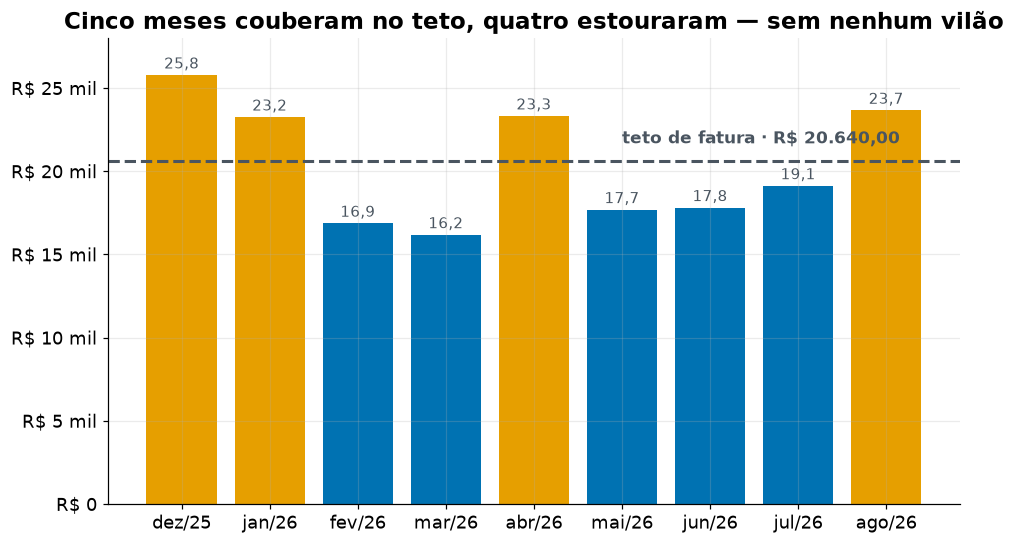

In [45]:
fig, ax = plt.subplots(figsize=(10, 5.5))
cores = [COR_DESTAQUE if p in RUINS else COR_PRIMARIA for p in JANELA]
ax.bar([rotulo_mes(p) for p in JANELA], fam2.values, color=cores)
ax.axhline(TETO, color=COR_TEXTO, ls="--", lw=2)
ax.text(5.0, TETO * 1.05, f"teto de fatura · {reais(TETO)}", color=COR_TEXTO, fontsize=11, weight="bold")
for i, v in enumerate(fam2.values):
    ax.text(i, v + 400, f"{v/1000:.1f}".replace(".", ","), ha="center", fontsize=10, color=COR_TEXTO)
ax.set_ylim(0, 28000)
ax.set_title("Cinco meses couberam no teto, quatro estouraram — sem nenhum vilão")
eixo_reais(ax)
fig.savefig("relatorios/figuras/fatura_familia_vs_teto.png", dpi=200, bbox_inches="tight")
plt.show()

**A figura mostra** a fatura líquida da família em cada um dos nove meses contra o teto de `R$ 20.640`. Os quatro meses em laranja estouraram (dez/25, jan/26, abr/26, ago/26) e os cinco em azul couberam. A distância entre o melhor mês (`R$ 16,2 mil`) e o pior (`R$ 25,8 mil`) é de quase `R$ 10 mil` — e nenhuma compra individual dos meses ruins passa de 6% do mês.

### Perguntas em aberto
- [x] A tabela central do brief bate? → sim, e a divergência era o estorno
- [x] O repasse do pai mudou de patamar? → dobrou em jun/26, `R$ 36,6 mil`/ano a mais
- [x] O que separa mês bom de mês ruim? → nenhuma categoria culpada: 9 categorias para 80% da diferença, e a maior compra do mês ruim é 5-6% dele
- [x] É consumo novo ou parcela acumulada? → 85,0% é compra à vista do próprio mês
- [~] Agosto é evento ou base nova? → **não determinável com 12 dias de setembro**; a régua dos 12 dias erra 2 dos 4 meses ruins. O que ficou: há dois modos de falha distintos
- [ ] Quanto das fixas realmente existia em cada mês (os contadores de parcela)
- [ ] Concentração: quanto os 20 maiores destinos carregam, e o peso das compras pequenas
- [ ] A esteira de dívidas: quanto de parcela expira por mês nos próximos 18 meses
- [ ] Existe tarifa de Pix no Crédito na fatura?
- [~] Quanto do consumo ainda é do pai — não investigável: compra dele em mercado é idêntica à da família

## PASSO 3 e PASSO 6 — o calendário das parcelas fixas

Os contadores da planilha (`CHEQUE MARINA 59/60`, `CARRO 08/14`) não são rótulo: são o calendário inteiro. Se em set/2026 o cheque está na parcela 59 de 60, ele começou em nov/2021 e **acaba em out/2026**. Isso responde duas perguntas de uma vez:

- **Passo 3** — quanto de conta fixa realmente existia em cada um dos nove meses (a planilha é de set/2026 e cobra de dez/2025 parcelas que ainda não existiam).
- **Passo 6** — quanto de parcela **expira** por mês de out/2026 em diante, que é o ativo escondido do plano.

Cinco itens têm contador. Os outros nove não têm prazo e entram como constantes.

In [46]:
REF = pd.Period("2026-09")  # mês a que a planilha se refere
# ⚠ EMPRESTIMO: a planilha lança "20/36", mas o casal confirmou que em set/2026 o
# contador real é 24/35. A planilha é expectativa e estava desatualizada; o número
# do contrato ganha (mesma regra do Passo 1). O rótulo da linha fica como está para
# casar com a planilha; o contador usado é o correto.
PARCELADAS = {"EMPRESTIMO 20/36": (1000.0, 24, 35), "EMPRESTIMO 34/36": (1900.0, 34, 36),
              "CARRO 08/14": (1300.0, 8, 14), "CHEQUE MARINA 59/60": (1300.0, 59, 60),
              "MERCADO PAGO 3/10": (415.0, 3, 10)}
CONST = itens[~itens["item"].isin(PARCELADAS)]["valor_planilha"].sum()

cal = []
for nome, (v, n, tot) in PARCELADAS.items():
    ini, fim = REF - (n - 1), REF + (tot - n)
    cal.append({"item": nome, "valor": v, "parcelas": tot,
                "inicio": str(ini), "ultima": str(fim)})
CAL = pd.DataFrame(cal)
assert abs(CONST - FIXAS_POS) < 0.01, "as contas que ficam não batem com FIXAS_POS do bloco de constantes"
print(f"itens sem prazo (constantes): {reais(CONST)}/mês")
print(f"parceladas: {reais(sum(v for v, _, _ in PARCELADAS.values()))}/mês | soma {reais(CONST + sum(v for v,_,_ in PARCELADAS.values()))}")
CAL

itens sem prazo (constantes): R$ 2.932,00/mês
parceladas: R$ 5.915,00/mês | soma R$ 8.847,00


,item,valor,parcelas,inicio,ultima
0,EMPRESTIMO 20/36,1000.0,35,2024-10,2027-08
1,EMPRESTIMO 34/36,1900.0,36,2023-12,2026-11
2,CARRO 08/14,1300.0,14,2026-02,2027-03
3,CHEQUE MARINA 59/60,1300.0,60,2021-11,2026-10
4,MERCADO PAGO 3/10,415.0,10,2026-07,2027-04


In [47]:
def fixas_do_mes(p):
    ativas = sum(v for nome, (v, n, tot) in PARCELADAS.items()
                 if (REF - (n - 1)) <= p <= (REF + (tot - n)))
    # A atualização da planilha vale para a frente: nos meses da janela a conta
    # antiga é que foi paga, e reconstruir o passado com o preço de hoje mudaria
    # o saldo já medido de cada mês.
    return CONST + ativas + (QUEDA_FIXA if p < DESDE_ATUALIZA else 0.0)

P3 = pd.DataFrame({"familia": fam2.round(2)}, index=JANELA)
P3["fixas_reais"] = [fixas_do_mes(p) for p in JANELA]
P3["teto_real"] = RENDA - P3["fixas_reais"]
P3["saldo_real"] = (P3["teto_real"] - P3["familia"]).round(2)
P3["saldo_teto_fixo"] = (TETO - P3["familia"]).round(2)
P3.index = [rotulo_mes(p) for p in JANELA]
print(f"teto fixo (planilha): {reais(TETO)} — saldo médio {reais(P3['saldo_teto_fixo'].mean())}, {(P3['saldo_teto_fixo']>0).sum()} positivos")
print(f"teto reconstruído    : varia — saldo médio {reais(P3['saldo_real'].mean())}, {(P3['saldo_real']>0).sum()} positivos")
P3

teto fixo (planilha): R$ 20.640,00 — saldo médio R$ 238,60, 5 positivos
teto reconstruído    : varia — saldo médio R$ 850,27, 5 positivos


,familia,fixas_reais,teto_real,saldo_real,saldo_teto_fixo
dez/25,25773.01,7145.0,22355.0,-3418.01,-5133.01
jan/26,23244.94,7145.0,22355.0,-889.94,-2604.94
fev/26,16861.24,8445.0,21055.0,4193.76,3778.76
mar/26,16172.28,8445.0,21055.0,4882.72,4467.72
abr/26,23311.64,8445.0,21055.0,-2256.64,-2671.64
mai/26,17680.28,8445.0,21055.0,3374.72,2959.72
jun/26,17802.35,8445.0,21055.0,3252.65,2837.65
jul/26,19116.32,8860.0,20640.0,1523.68,1523.68
ago/26,23650.54,8860.0,20640.0,-3010.54,-3010.54


**Resultado:** as duas versões concordam no essencial e discordam na medida. **Nenhum mês troca de sinal** — os mesmos cinco fecham positivos nas duas leituras, o que é um argumento a favor da robustez do achado central.

Mas a magnitude muda, e sempre na mesma direção: dezembro sai de `R$ -5.133` para `R$ -3.418`, porque o carro e o Mercado Pago **ainda não existiam**. Janeiro melhora `R$ 1.715` pelo mesmo motivo. O saldo médio dos nove meses sobe de `R$ 239` para `R$ 850`.

E o número que importa para o plano está na coluna do meio: **a conta fixa da família subiu de `R$ 7.145` para `R$ 8.860` em nove meses** — 24% de aumento, `R$ 1.715`/mês a mais. O carro entrou em fev/26 e o Mercado Pago em jul/26. Não é que o casal passou a gastar mais no cartão: é que assumiu duas obrigações novas no período.

Isso desmonta a ideia de "teto de `R$ 20.640`" como se fosse constante. **O teto é móvel** — ele cai quando uma dívida nova entra e sobe quando uma vence. E é exatamente por isso que o Passo 6 importa.

In [48]:
FUT = pd.period_range("2026-10", "2028-03", freq="M")

# parcelas do cartão ainda a cair: da última parcela vista até a final.
# O plano é identificado pela REPETIÇÃO do número de parcela (a 2ª vez que "1/3"
# aparece é outro carnê) — não pelo valor, que difere por centavos entre parcelas
# do mesmo plano e partiria um carnê em dois.
pf = fam_tudo[fam_tudo["parcela_n"].notna() & ~fam_tudo["parcela_cancelada"]].copy().sort_values("data")
pf["plano_id"] = pf.groupby(["pessoa", "destino", "parcela_de", "parcela_n"]).cumcount()
ult = pf.groupby(["pessoa", "destino", "parcela_de", "plano_id"]).tail(1)
carne = {p: 0.0 for p in FUT}
for _, r in ult.iterrows():
    for k in range(int(r["parcela_n"]) + 1, int(r["parcela_de"]) + 1):
        m = r["mes"] + (k - int(r["parcela_n"]))
        if m in carne:
            carne[m] += r["valor"]

E = pd.DataFrame({"fixas": [fixas_do_mes(p) for p in FUT],
                  "parcelas_cartao": [round(carne[p], 2) for p in FUT]}, index=FUT)
E["obrigacao_total"] = (E["fixas"] + E["parcelas_cartao"]).round(2)
E["expira_no_mes"] = (-E["fixas"].diff()).fillna(0).round(2)
E.index = [rotulo_mes(p) for p in FUT]
novos = fam_tudo[(fam_tudo["parcela_n"] == 1) & fam_tudo["mes"].isin(JANELA)]
vivos = sum(1 for _, r in ult.iterrows()
            if r["mes"] + (int(r["parcela_de"]) - int(r["parcela_n"])) >= FUT[0])
print(f"{len(ult)} parcelamentos VISTOS na janela (sem os cancelados) — a maioria já encerrada.")
print(f"  ainda com parcela a cair de out/26 em diante: {vivos} planos, "
      f"{reais(sum(carne.values()))}")
print(f"RITMO DE NOVOS PLANOS na janela: {len(novos)} iniciados = {len(novos)/9:.1f}/mês | "
      f"nova parcela mensal criada {reais(novos['valor'].sum()/9)}/mês | "
      f"novo compromisso total {reais((novos['valor']*novos['parcela_de']).sum()/9)}/mês")
E

84 parcelamentos VISTOS na janela (sem os cancelados) — a maioria já encerrada.
  ainda com parcela a cair de out/26 em diante: 15 planos, R$ 5.673,37
RITMO DE NOVOS PLANOS na janela: 63 iniciados = 7.0/mês | nova parcela mensal criada R$ 996,13/mês | novo compromisso total R$ 4.566,53/mês


,fixas,parcelas_cartao,obrigacao_total,expira_no_mes
out/26,8847.0,1625.09,10472.09,0.0
nov/26,7547.0,927.20,8474.20,1300.0
dez/26,5647.0,624.06,6271.06,1900.0
jan/27,5647.0,582.70,6229.70,-0.0
fev/27,5647.0,582.70,6229.70,-0.0
mar/27,5647.0,582.70,6229.70,-0.0
abr/27,4347.0,228.72,4575.72,1300.0
mai/27,3932.0,179.00,4111.00,415.0
jun/27,3932.0,179.00,4111.00,-0.0
jul/27,3932.0,81.10,4013.10,-0.0


In [49]:
NIVEL_MEDIO, NIVEL_RUIM = fam2.mean(), pc[RUINS].sum().mean()
Q = pd.DataFrame({"fixas": [fixas_do_mes(p) for p in FUT]}, index=FUT)
Q["teto"] = pd.Series([renda_do_mes(p) for p in FUT], index=FUT).sub(Q["fixas"]).round(2)
Q["saldo_se_media"] = (Q["teto"] - NIVEL_MEDIO).round(2)
Q["saldo_se_mes_ruim"] = (Q["teto"] - NIVEL_RUIM).round(2)
Q.index = [rotulo_mes(p) for p in FUT]

print(f"consumo congelado: nível médio {reais(NIVEL_MEDIO)} | nível de mês ruim {reais(NIVEL_RUIM)}")
vira = Q.index[(Q["saldo_se_mes_ruim"] > 0)]
print(f"mês em que até um MÊS RUIM fecha positivo, sem cortar nada: {vira[0] if len(vira) else 'nenhum em 18 meses'}")
print(f"liberação total das fixas de out/26 a mar/28: {reais(Q['fixas'].iloc[0] - Q['fixas'].iloc[-1])}/mês\n")
Q

consumo congelado: nível médio R$ 20.401,40 | nível de mês ruim R$ 23.995,03
mês em que até um MÊS RUIM fecha positivo, sem cortar nada: nenhum em 18 meses
liberação total das fixas de out/26 a mar/28: R$ 5.915,00/mês



,fixas,teto,saldo_se_media,saldo_se_mes_ruim
out/26,8847.0,20653.0,251.6,-3342.03
nov/26,7547.0,21953.0,1551.6,-2042.03
dez/26,5647.0,23853.0,3451.6,-142.03
jan/27,5647.0,23853.0,3451.6,-142.03
fev/27,5647.0,23853.0,3451.6,-142.03
mar/27,5647.0,23853.0,3451.6,-142.03
abr/27,4347.0,15653.0,-4748.4,-8342.03
mai/27,3932.0,16068.0,-4333.4,-7927.03
jun/27,3932.0,16068.0,-4333.4,-7927.03
jul/27,3932.0,16068.0,-4333.4,-7927.03


**Resultado: a esteira de dívidas é real e vale `R$ 5.915`/mês — mas ela NÃO compensa o choque de renda, e o histórico mostra que ela vem sendo consumida.**

Entre out/2026 e mar/2028, `R$ 5.915`/mês de conta fixa **vencem por conta própria**. Esse dinheiro aparece sem ninguém fazer nada.

E a maior parte vem rápido: `CHEQUE MARINA` acaba em **out/2026** (a 60ª parcela) liberando `R$ 1.300` em novembro, e `EMPRESTIMO 34/36` acaba em **nov/2026** liberando `R$ 1.900` em dezembro. **São `R$ 3.200`/mês em dois meses.** Depois `CARRO` sai em mar/2027 (`R$ 1.300`), `MERCADO PAGO` em abr/2027 (`R$ 415`) e o último empréstimo em **ago/2027** (`R$ 1.000`).

> **Correção de contador, informada pelo casal.** A planilha lança o empréstimo de `R$ 1.000` como `20/36`; o contador real em set/2026 é `24/35`. Isso antecipa o fim dele de jan/2028 para **ago/2027** — cinco meses. Vale conferir os outros quatro contadores no aplicativo: eles definem o calendário inteiro desta esteira.

### O teto de fatura sobe, e depois desaba

A tabela mostra a coisa mais importante desta seção, e ela contraria a leitura otimista:

| período | fixas | teto de fatura | saldo no nível médio (`R$ 20.401`) |
|---|---|---|---|
| out/26 | `R$ 8.847` | `R$ 20.653` | `+R$ 252` |
| dez/26 a mar/27 | `R$ 5.647` | **`R$ 23.853`** | **`+R$ 3.452`** |
| abr/27 | `R$ 4.347` | `R$ 15.653` | **`−R$ 4.748`** |
| set/27 em diante | `R$ 2.932` | `R$ 17.068` | **`−R$ 3.333`** |

**No mês do choque a esteira já devolveu `R$ 4.500`/mês** (as fixas caem de `R$ 8.847` para `R$ 4.347`) — **e o choque tira `R$ 9.500`.** O teto chega a `R$ 23.853` em dezembro e cai para `R$ 15.653` em abril: `23.853 − 9.500 + 1.300` do carro que acaba no mesmo mês. Fica **abaixo de onde começou**. **Congelando o consumo no nível de hoje, nenhum dos 12 meses pós-choque fecha positivo**, e no nível de um mês ruim nenhum dos 18 fecha.

Uma versão anterior desta seção dizia que o teto "sobe de `R$ 20.640` para `R$ 26.555`, quase `R$ 6 mil` de folga a mais". Estava errada: usava a renda de hoje nos 18 meses. `R$ 26.555` seria o teto **se a renda não caísse**.

**O que a esteira realmente faz é amortecer**, e o tamanho do amortecimento é exato: sem ela, o teto pós-choque seria `R$ 20.000 − R$ 8.847 = R$ 11.153`. Com ela, `R$ 17.068`. São `R$ 5.915` que separam o difícil do impossível — mas não substituem o corte.

**E aqui está a ressalva que derruba o resto do otimismo, medida no próprio dado.** A projeção supõe que nenhum compromisso novo entra. O histórico diz o contrário: na janela de nove meses o casal iniciou **63 parcelamentos novos — 7 por mês** — criando `R$ 996`/mês de nova parcela mensal e assumindo `R$ 4.567`/mês de compromisso total novo. Some as duas dívidas fixas novas (carro em fev/26, Mercado Pago em jul/26, `R$ 1.715`/mês) e o quadro fica claro.

**É por isso que o parcelado ficou estável em `R$ 4.500`/mês nos nove meses**: não é que as parcelas não vencem — é que são repostas na mesma velocidade. A esteira nunca virou folga porque nunca chegou a sobrar.

Isso reclassifica a recomendação: "não assinar nada até dezembro" **não é um conselho conservador de rodapé, é a ação de maior impacto do plano inteiro**, e a única que o próprio histórico mostra em risco. `R$ 3.200`/mês chegam sozinhos até dezembro; ao ritmo medido de `R$ 996`/mês de nova parcela, três meses de compras parceladas consomem tudo.

**Duas correções que a revisão pegou, e que se compensam:**

1. A projeção inicial dizia `R$ 5.440` de parcelas de cartão ainda a cair, porque o agrupamento colapsava **planos paralelos no mesmo estabelecimento** — o caso `Palmaserra` documentado no começo desta análise. Com a chave corrigida, o total subiu para `R$ 8.384`.
2. Depois disso, a varredura de **estornos** encontrou 4 parcelamentos cancelados (`Mangaldourado` e outros), que estavam sendo contados como obrigação futura sem existir. Tirando-os, o total cai para **`R$ 5.673,37`**, e ele é medido **de out/26 em diante**: são **15 planos** que ainda têm parcela nessa janela. O inventário mais adiante conta 20 planos e `R$ 7.823,58` porque parte de set/26, e a diferença de `R$ 2.150,21` é exatamente o que vence naquele mês.

## PASSO 7 — A família paga tarifa pelo Pix no Crédito?

Passaram `R$ 48.907` de conta do pai pelo cartão em nove meses, boa parte via Pix no Crédito. Se há tarifa e o pai reembolsa só o valor da transferência, a tarifa fica com a família. Vou procurar na fatura qualquer lançamento de tarifa, IOF ou juros.

In [50]:
TARIFA = r"^TARIFA|^TAXA|^IOF|^JUROS|^ENCARGO|ANUIDADE|ROTATIVO|PARCELAMENTO DE FATURA|^MULTA"
tar = fat[fat["destino"].str.contains(TARIFA)]
print(f"lançamentos de tarifa/encargo/IOF na fatura inteira: {len(tar)}")
print(f"  IOF cobrado   : {reais(tar.loc[tar['valor'] > 0, 'valor'].sum())}")
print(f"  IOF devolvido : {reais(tar.loc[tar['valor'] < 0, 'valor'].sum())}")
print(f"  IOF líquido   : {reais(tar['valor'].sum())} em 11 meses = {reais(tar['valor'].sum()/11)}/mês")
print(f"\ntarifa de Pix no Crédito: {len(fat[fat['destino'].str.contains('^TARIFA|^TAXA')])} lançamentos")
print(f"juros de rotativo/anuidade: {len(fat[fat['destino'].str.contains('ROTATIVO|ANUIDADE|^JUROS')])} lançamentos")

pago = -fat.loc[fat["destino"] == "PAGAMENTO RECEBIDO", "valor"].sum()
faturado = fat.loc[fat["destino"] != "PAGAMENTO RECEBIDO", "valor"].sum()
print(f"\ntotal faturado (11 meses): {reais(faturado)} | total pago: {reais(pago)} | "
      f"razão {pago/faturado:.3f}")

lançamentos de tarifa/encargo/IOF na fatura inteira: 51
  IOF cobrado   : R$ 197,07
  IOF devolvido : R$ -168,81
  IOF líquido   : R$ 28,26 em 11 meses = R$ 2,57/mês

tarifa de Pix no Crédito: 0 lançamentos
juros de rotativo/anuidade: 0 lançamentos

total faturado (11 meses): R$ 253.830,13 | total pago: R$ 252.571,43 | razão 0.995


**Resultado: a fatura não mostra nenhuma tarifa de Pix no Crédito.** Zero lançamentos de tarifa ou taxa, nos 11 meses, nos dois cartões. Conforme o brief instruiu, **não vou estimar** — se o Nubank cobra tarifa nessas operações, ela não aparece no extrato que temos, e a resposta honesta é que **não é verificável com este dado**. Para responder, seria preciso o extrato de conta corrente ou o detalhamento da operação de Pix no Crédito.

O único encargo que existe é **IOF, e ele é irrelevante**: `R$ 197` cobrados, `R$ 169` devolvidos, líquido de `R$ 28,26` em 11 meses — `R$ 2,57`/mês. E não tem nada a ver com o pai: é IOF de compra internacional em assinaturas de software (Anthropic, OpenAI, Vercel, Resend). A parte devolvida indica cobrança e estorno automáticos, provavelmente conversão de moeda.

**E o teste ao lado vale mais que a pergunta original.** Não existe **nenhum** lançamento de juros de rotativo, parcelamento de fatura ou anuidade em 11 meses. Somando: faturados `R$ 253.830`, pagos `R$ 252.571` — razão de **0,995**. O casal **paga a fatura integral, todo mês**, e não financia nada no cartão.

Isso muda o tom do diagnóstico. Uma família com fatura de `R$ 26 mil` e saldo negativo em quatro de nove meses poderia estar rolando dívida no crédito rotativo, que é o buraco mais caro que existe. **Não está.** O problema é de ritmo de gasto, não de endividamento no cartão — e problema de ritmo é muito mais fácil de resolver.

## PASSO 5 — O gasto está concentrado ou pulverizado?

Se 20 estabelecimentos carregam a maior parte do gasto, o plano ataca 20 lugares. Se o gasto está pulverizado em centenas de compras pequenas, a ação é outra — e o resultado do Passo 2 (tudo subindo junto) já sugere qual das duas é.

Três medidas: o peso dos 20 maiores, o total das compras abaixo de `R$ 50`, e o que repete todo mês com valor parecido.

In [51]:
tot_fam = fam["valor"].sum()
ranking = fam.groupby("destino")["valor"].sum().sort_values(ascending=False)
compras = fam[fam["valor"] > 0]

print(f"total da família (9 meses): {reais(tot_fam)} em {len(fam)} lançamentos, {len(ranking)} destinos")
for n in (5, 10, 20, 50):
    print(f"  top {n:>2} destinos = {ranking.head(n).sum()/tot_fam:6.1%} do gasto")
_meio = int((ranking.cumsum() / tot_fam < 0.5).sum()) + 1
print(f"  → precisa de {_meio} destinos para passar da METADE do gasto")
print()
for lim in (50, 100, 200):
    s = compras[compras["valor"] < lim]
    print(f"  compras abaixo de R$ {lim:>3}: {len(s):>4} ops ({len(s)/len(compras):4.0%} das compras) = "
          f"{reais(s['valor'].sum()/9)}/mês ({s['valor'].sum()/tot_fam:4.1%} do gasto)")
print(f"\nmediana da compra: {reais(compras['valor'].median())} | média: {reais(compras['valor'].mean())}")

total da família (9 meses): R$ 183.612,60 em 1574 lançamentos, 544 destinos
  top  5 destinos =  18.8% do gasto
  top 10 destinos =  26.7% do gasto
  top 20 destinos =  38.1% do gasto
  top 50 destinos =  57.5% do gasto
  → precisa de 36 destinos para passar da METADE do gasto

  compras abaixo de R$  50:  585 ops ( 38% das compras) = R$ 1.536,60/mês (7.5% do gasto)
  compras abaixo de R$ 100:  902 ops ( 59% das compras) = R$ 4.030,11/mês (19.8% do gasto)
  compras abaixo de R$ 200: 1240 ops ( 81% das compras) = R$ 9.293,54/mês (45.6% do gasto)

mediana da compra: R$ 70,50 | média: R$ 120,32


In [52]:
def recorrentes(df, origem, col_data, valor, min_ocorrencias=3, cv_valor_max=0.10,
                cv_intervalo_max=0.25):
    d = df.dropna(subset=[origem, col_data, valor]).sort_values(col_data).copy()
    d["_gap"] = d.groupby(origem)[col_data].diff().dt.days
    cv = lambda s: s.std(ddof=0) / abs(s.mean()) if len(s) > 1 and s.mean() else float("nan")
    t = d.groupby(origem).agg(ocorrencias=(valor, "size"), total=(valor, "sum"),
                              cv_valor=(valor, cv), intervalo_dias=("_gap", "median"),
                              cv_intervalo=("_gap", cv))
    cand = t[(t["ocorrencias"] >= min_ocorrencias) & (t["cv_valor"] <= cv_valor_max)
             & (t["cv_intervalo"] <= cv_intervalo_max)]
    print(f"{len(cand)} origens recorrentes de {len(t)} | "
          f"{cand['total'].sum() / t['total'].sum():.1%} do total")
    return cand.sort_values("total", ascending=False)

rec = recorrentes(fam[fam["valor"] > 0], "destino", "data", "valor")
rec["mes"] = (rec["total"] / 9).round(2)
rec["ano"] = (rec["total"] / 9 * 12).round(2)
rec[["ocorrencias", "total", "intervalo_dias", "mes", "ano"]].head(15)

29 origens recorrentes de 523 | 12.0% do total


,ocorrencias,total,intervalo_dias,mes,ano
destino,,,,,
MANGALSOL LAGOAJATOBA,9,3150.00,30.5,350.00,4200.00
STARLINK,9,2146.64,30.0,238.52,2862.19
SUSITA CORREIA DE,7,2099.79,30.5,233.31,2799.72
MP *BURITICAJU,7,2036.79,30.5,226.31,2715.72
CERRADOSOL*IPEPEDRA CLINICA,10,2000.00,31.0,222.22,2666.67
HTM *ARARACAMPO,5,1458.35,30.5,162.04,1944.47
APP*LINKDEPAGAMEN,8,1298.80,31.0,144.31,1731.73
ARAUCARIACAMPO AUTO CENTER,3,937.50,29.5,104.17,1250.00
PANDA VIDEO,9,791.36,30.5,87.93,1055.15


In [53]:
so_parcela = compras.groupby("destino")["parcela_n"].apply(lambda s: s.notna().all()).reindex(rec.index)
ultimo = compras.groupby("destino")["mes"].max().reindex(rec.index)
vivo = ultimo >= pd.Period("2026-08")

rec["tipo"] = so_parcela.map({True: "parcelamento", False: "assinatura/serviço"})
rec["ate"] = ultimo.astype(str)
rec["ativo_em_ago"] = vivo
# total/9 descreve a JANELA. Para uma promessa de economia futura, o que vale é o
# preço corrente: metade destes itens não existiu nos 9 meses, e dividir por 9 uma
# assinatura de 3 meses reporta um terço do preço dela.
rec["meses"] = compras.groupby("destino")["mes"].nunique().reindex(rec.index)
rec["run_rate"] = (rec["total"] / rec["meses"]).round(2)
rec["ultima"] = compras.sort_values("data").groupby("destino")["valor"].last().reindex(rec.index)

print(f"dos 29 'recorrentes': {so_parcela.sum()} são 100% parcelamento "
      f"({reais(rec.loc[so_parcela, 'total'].sum()/9)}/mês) — não se cancela, já foi contratado")
print(f"                      {(~vivo).sum()} já encerraram antes de ago/26 "
      f"({reais(rec.loc[~vivo, 'total'].sum()/9)}/mês) — não existem mais")
canc = rec.loc[vivo & ~so_parcela]
print(f"\nRECORRENTE AINDA VIVO em ago/26: {reais(rec.loc[vivo, 'total'].sum()/9)}/mês pela janela")
print(f"  assinatura/serviço cancelável — o que importa é o PREÇO CORRENTE:")
print(f"    pela janela (total/9) : {reais(canc['total'].sum()/9)}/mês  ← subestima")
print(f"    run-rate (total/meses): {reais(canc['run_rate'].sum())}/mês = {reais(canc['run_rate'].sum()*12)}/ano")
print(f"    soma da última cobrança: {reais(canc['ultima'].sum())}/mês")
print(f"\ncompras por mês: {len(compras)/9:.0f}  (~{len(compras)/9/30:.1f} por dia)\n")
rec.loc[vivo, ["ocorrencias", "tipo", "meses", "mes", "run_rate", "ultima"]].sort_values("run_rate", ascending=False)

dos 29 'recorrentes': 20 são 100% parcelamento (R$ 1.884,44/mês) — não se cancela, já foi contratado
                      11 já encerraram antes de ago/26 (R$ 858,87/mês) — não existem mais

RECORRENTE AINDA VIVO em ago/26: R$ 1.615,17/mês pela janela
  assinatura/serviço cancelável — o que importa é o PREÇO CORRENTE:
    pela janela (total/9) : R$ 549,61/mês  ← subestima
    run-rate (total/meses): R$ 793,91/mês = R$ 9.526,92/ano
    soma da última cobrança: R$ 768,96/mês

compras por mês: 171  (~5.7 por dia)



,ocorrencias,tipo,meses,mes,run_rate,ultima
destino,,,,,,
MANGALSOL LAGOAJATOBA,9,parcelamento,8,350.00,393.75,350.00
HTM *ARARACAMPO,5,parcelamento,5,162.04,291.67,291.67
STARLINK,9,assinatura/serviço,9,238.52,238.52,249.00
CERRADOSOL*IPEPEDRA CLINICA,10,parcelamento,9,222.22,222.22,200.00
WELLHUB ORLANDO ARARAVEREDA,3,assinatura/serviço,3,50.00,149.99,149.99
AMAZON,5,parcelamento,4,62.92,141.57,113.25
JEQUITIBAFORTE SOM,3,parcelamento,3,41.67,125.00,125.00
CANELAPORTO,5,parcelamento,4,55.51,124.90,99.92
PANDA VIDEO,9,assinatura/serviço,7,87.93,113.05,87.90


In [54]:
# O detector tem DOIS pontos cegos, e os dois apareceram nesta análise: pega
# parcelamento (tratado acima) e PERDE assinatura de valor variável — o filtro
# cv_valor <= 0,10 elimina quem teve reajuste, upgrade ou cobrança dupla.
# Estas foram confirmadas lendo os títulos. Lista declarada, não heurística.
CONFIRMADAS = ["ANTHROPIC CLAUDE", "GOOGLE ONE", "APPLE", "SPOTIFY", "MAGNIFIC",
               "CONTA VIVO"]   # duas linhas todo mês, dia 11 — ver PRECO_CORRENTE
AGO = pd.Period("2026-08")

# IOF ESTORNADO NÃO É CUSTO. Cobranças internacionais geram uma linha `IOF DE "X"`
# e, quase sempre, uma `IOF DE VOLTA DE X` que a anula. Como `compras` só tem valor
# positivo, a volta some e o IOF entraria na conta de assinatura como despesa que
# não existe. Fora os que fecham em zero — os que sobram (MEE6, WHOP) ficam.
_p = fam[fam["destino"].str.match(r'^IOF DE "', na=False)].assign(
    base=lambda d: d["destino"].str.extract(r'^IOF DE "(.+)"$', expand=False))
_v = fam[fam["destino"].str.startswith("IOF DE VOLTA DE ", na=False)].assign(
    base=lambda d: d["destino"].str.replace("IOF DE VOLTA DE ", "", regex=False))
_liq = (_p.groupby("base")["valor"].sum()
        .add(_v.groupby("base")["valor"].sum(), fill_value=0).round(2))
IOF_ANULADO = {f'IOF DE "{b}"' for b, v in _liq.items() if abs(v) < 0.01}
print(f"{len(IOF_ANULADO)} linha(s) de IOF integralmente estornada(s) — fora da conta "
      f"de assinatura: {sorted(IOF_ANULADO)}")

assin = sorted((set(canc.index) | set(CONFIRMADAS)) - IOF_ANULADO)
# preço corrente = o que foi cobrado no ÚLTIMO MÊS COMPLETO. Sem divisão, sem
# média: metade destas assinaturas mudou de preço ou não existia há 9 meses.
mm_assin = (compras[compras["destino"].isin(assin)]
            .groupby(["destino", "mes"])["valor"].sum().rename("v").reset_index())
cobr_ago = mm_assin[mm_assin["mes"] == AGO].set_index("destino")["v"]
mediana = mm_assin[mm_assin["v"] > 0].groupby("destino")["v"].median()

tab = pd.DataFrame({"na_janela_div9": (rec["total"] / 9).reindex(assin),
                    "em_ago26": cobr_ago.reindex(assin),
                    "mediana_mes_ativo": mediana.reindex(assin)}).fillna(0).round(2)
# GUARDA. Só é "mensalidade cancelável" o que tem PREÇO fixo.
# ⚠ A medida tem que ser por COBRANÇA, não pela soma do mês: se num mês caem duas
# cobranças (porque o mês anterior não teve nenhuma), a soma dobra e o item parece
# variável sem que o preço tenha mudado. Foi o que aconteceu com Netflix (sempre
# R$ 59,90, cv por cobrança 0,0000, mas cv mensal 0,31) e Panda Video.
cvc = compras[compras["destino"].isin(assin)].groupby("destino")["valor"].agg(
    lambda s: s.std(ddof=0) / s.mean() if len(s) > 1 and s.mean() else 0.0)
# 2ª porta: quem trocou de plano tem cv alto na janela toda mas está estável AGORA.
ult3 = (mm_assin[mm_assin["v"] > 0].sort_values("mes").groupby("destino").tail(3)
        .groupby("destino")["v"].agg(
            lambda s: s.std(ddof=0) / s.mean() if len(s) > 1 and s.mean() else 0.0))
tab["cv_cobranca"] = cvc.reindex(assin).fillna(0).round(3)
tab["cv_ult3meses"] = ult3.reindex(assin).fillna(0).round(3)
fixo = (tab["cv_cobranca"] <= 0.10) | (tab["cv_ult3meses"] <= 0.05)
tab["tipo"] = ["mensalidade" if f else "VARIÁVEL — é uso, não assinatura" for f in fixo]
tab["mensal"] = tab["em_ago26"].where(fixo, 0).round(2)

# ASSINATURA ANUAL: cobra uma vez e some — não é compra avulsa nem mensalidade.
# Um ano de dado não basta para detectá-la (a 2ª cobrança ainda não veio), então
# ela só aparece quando quem paga conta. A do CapCut o casal JÁ DECIDIU não
# renovar: custo futuro zero. Fica registrada porque explica o pico da Apple
# em ago/26, e para não ser recontada como gasto recorrente.
ANUAIS = {"CAPCUT (via Apple, ago/26)": {"cobrado": 187.90, "renova": False}}
ANUAL_MES = sum(a["cobrado"] / 12 for a in ANUAIS.values() if a["renova"])
UMA_VEZ = sum(a["cobrado"] for a in ANUAIS.values() if not a["renova"])
# o valor estava dentro do total da Apple em ago/26 — tirar para não inflar o mensal
tab.loc["APPLE", "em_ago26"] = round(tab.loc["APPLE", "em_ago26"] - sum(a["cobrado"] for a in ANUAIS.values()), 2)

# PREÇO CORRENTE DECLARADO — o teste de cv erra em dois casos, e os dois são
# assinatura de verdade. Levantado pelo casal: "Spotify e Apple precisam entrar
# nas assinaturas, por que estão fora?".
#  · APPLE — a fatura junta VÁRIOS apps, então o total varia mesmo com cada
#    assinatura tendo preço fixo. A cobrança recorrente é a do dia 25: R$ 65,90
#    até abr/26, R$ 39,90 em ago/26. O resto de agosto é R$ 3,50 avulso e o anual
#    do CapCut, já tratado acima.
#  · SPOTIFY — trocou de plano no meio da janela (R$ 31,90 → R$ 23,90). Preço que
#    mudou UMA vez não é uso variável; a régua certa é a última cobrança.
# Regra geral por trás: para quem já foi CONFIRMADO como assinatura na leitura, o
# preço que vale é o corrente, não a estabilidade dele ao longo da janela.
#  · CONTA VIVO — são DUAS contas do Orlando (celular e internet de casa), cobradas
#    no mesmo dia 11. O total varia porque são duas, não porque o preço oscila —
#    e elas subiram em jul/26: R$ 131,26 + R$ 70,00 = R$ 201,26 até abr, contra
#    R$ 150,66 + R$ 75,00 = R$ 225,66 em ago (+12%). Em out/26 o casal informou
#    a linha do celular em R$ 54,00: com a internet de R$ 150,70, R$ 204,70.
#    (Em 02/06 caíram duas faturas juntas, maio e junho — ciclo, não erro.)
PRECO_CORRENTE = {"APPLE": 39.90, "SPOTIFY": 23.90, "CONTA VIVO": 150.70 + 54.00}
for _d, _v in PRECO_CORRENTE.items():
    if _d in tab.index:
        tab.loc[_d, ["em_ago26", "mensal"]] = _v
        tab.loc[_d, "tipo"] = "mensalidade"
        fixo[_d] = True

tab["ano"] = (tab["mensal"] * 12).round(2)
CANCELAVEL = tab["mensal"].sum() + ANUAL_MES
VARIAVEL = tab.loc[~fixo, "em_ago26"].sum()

print(f"ASSINATURA CANCELÁVEL TOTAL: {reais(CANCELAVEL)}/mês = {reais(CANCELAVEL*12)}/ano")
print(f"  mensalidade de valor estável : {reais(tab['mensal'].sum())}/mês")
print(f"  anual que renova, /12        : {reais(ANUAL_MES)}/mês")
for k, a in ANUAIS.items():
    print(f"    · {k}: {reais(a['cobrado'])}/ano — "
          f"{'renova' if a['renova'] else '✅ NÃO renova, custo futuro zero'}")
print(f"cobrança VARIÁVEL no mesmo grupo: {reais(VARIAVEL)}/mês — não se cancela, se usa menos")
print(f"\nréguas descartadas e por quê:")
print(f"  dividir por 9 daria {reais(tab['na_janela_div9'].sum())}/mês — subestima (metade não existiu 9 meses)")
print(f"  usar ago/26 cru daria {reais(tab['em_ago26'].sum())}/mês — coincide com a régua adotada: a tabela já só tem assinatura confirmada\n")

# JÁ DECIDIDO PELO CASAL — informado por eles, não deduzido do dado:
#  · Wellhub de R$ 149,99 (o outro, de R$ 69,99, fica): dois planos ativos ao mesmo tempo
#  · RESEND: JÁ cancelado. (O IOF da cobrança em dólar não entra: é estornado
#    integralmente todo mês — ver IOF_ANULADO acima.)
# ESSENCIAL: não se cancela, se renegocia. Internet de casa e telefonia.
ESSENCIAL = [d for d in ("STARLINK", "CONTA VIVO", "CLARO") if d in tab.index]
JA_DECIDIDO = {d: float(tab.loc[d, "em_ago26"])
#  · PANDA VIDEO: cancelado pelo casal em out/26.
               for d in ["WELLHUB ORLANDO ARARAVEREDA", "RESEND", "PANDA VIDEO"]
               if d in tab.index}
# · GOOGLE ONE: eram dois planos, um em cada cartão. O do cartão da Mariana foi
#   cancelado em set/26; o do Orlando, com compartilhamento familiar, fica. Cancelamento
#   PARCIAL: o destino continua vivo, só o valor deste plano sai.
_g1_dry = compras[(compras["destino"] == "GOOGLE ONE") & (compras["pessoa"] == "Mariana")].sort_values("data")
if len(_g1_dry):
    JA_DECIDIDO["GOOGLE ONE"] = float(_g1_dry["valor"].iloc[-1])
    print(f"Google One cancelado (um dos dois planos): {reais(JA_DECIDIDO['GOOGLE ONE'])}/mês = "
          f"{reais(JA_DECIDIDO['GOOGLE ONE'] * 12)}/ano")
print("Wellhub — três nomes em sequência, e em ago/26 DOIS estavam ativos:")
print(compras[compras["destino"].str.contains("WELLHUB")]
      .groupby(["destino", "mes"])["valor"].sum().to_string())
print(f"\n✅ já decidido/feito ({len(JA_DECIDIDO)} itens): "
      + ", ".join(f"{k} {reais(v)}" for k, v in JA_DECIDIDO.items()))
print(f"   soma {reais(sum(JA_DECIDIDO.values()))}/mês = "
      f"{reais(sum(JA_DECIDIDO.values())*12)}/ano — já contida no cancelável acima")
tab.sort_values("em_ago26", ascending=False)

9 linha(s) de IOF integralmente estornada(s) — fora da conta de assinatura: ['IOF DE "ANTHROPIC"', 'IOF DE "BASE44"', 'IOF DE "CLAUDE.AI SUBSCRIPTION"', 'IOF DE "GENSPARK.AI"', 'IOF DE "ORLANDO.AI"', 'IOF DE "LINK.COM* CAPTIONS.AI"', 'IOF DE "OPENAI"', 'IOF DE "RESEND"', 'IOF DE "VERCEL"']
ASSINATURA CANCELÁVEL TOTAL: R$ 1.818,51/mês = R$ 21.822,12/ano
  mensalidade de valor estável : R$ 1.818,51/mês
  anual que renova, /12        : R$ 0,00/mês
    · CAPCUT (via Apple, ago/26): R$ 187,90/ano — ✅ NÃO renova, custo futuro zero
cobrança VARIÁVEL no mesmo grupo: R$ 0,00/mês — não se cancela, se usa menos

réguas descartadas e por quê:
  dividir por 9 daria R$ 548,34/mês — subestima (metade não existiu 9 meses)
  usar ago/26 cru daria R$ 1.818,51/mês — coincide com a régua adotada: a tabela já só tem assinatura confirmada

Google One cancelado (um dos dois planos): R$ 14,99/mês = R$ 179,88/ano
Wellhub — três nomes em sequência, e em ago/26 DOIS estavam ativos:
destino                 mes   

,na_janela_div9,em_ago26,mediana_mes_ativo,cv_cobranca,cv_ult3meses,tipo,mensal,ano
destino,,,,,,,,
ANTHROPIC CLAUDE,0.00,570.52,572.51,0.346,0.003,mensalidade,570.52,6846.24
STARLINK,238.52,249.00,235.52,0.023,0.026,mensalidade,249.00,2988.00
CONTA VIVO,0.00,204.70,201.32,0.450,0.308,mensalidade,204.70,2456.40
WELLHUB ORLANDO ARARAVEREDA,50.00,149.99,149.99,0.000,0.000,mensalidade,149.99,1799.88
MAGNIFIC,0.00,149.39,149.39,0.000,0.000,mensalidade,149.39,1792.68
RESEND,36.76,109.98,109.98,0.008,0.008,mensalidade,109.98,1319.76
PANDA VIDEO,87.93,87.90,87.90,0.001,0.353,mensalidade,87.90,1054.80
WELLHUB YURI DIANA F,54.44,69.99,69.99,0.000,0.000,mensalidade,69.99,839.88
GOOGLE ONE,0.00,64.98,64.98,0.662,0.000,mensalidade,64.98,779.76


### Auditoria de assinaturas: o que está vivo, o que parou, o que é dúvida

A lista de canceláveis acima usa um critério estreito de propósito (recorrência regular ou confirmação na leitura). Mas o casal perguntou o certo: **quais outras assinaturas estão na mesma situação de dúvida do Google Pedranovo?**

A tabela abaixo é a auditoria completa. Ela pega **todo destino que aparece em 2 meses ou mais** e tem cara de serviço — digital, utilidade, ou cobrança por plataforma de pagamento — e mostra o **mês a mês**, para que o padrão fique visível sem precisar acreditar em classificação nenhuma.

Três colunas de decisão:
- **`meses`** — em quantos dos 9 apareceu.
- **`ate`** — o último mês em que foi cobrado. Se não for ago/26 ou set/26, **parou** (ou mudou de nome).
- **`cv_valor`** — o quanto o valor oscila. Perto de zero é mensalidade fixa; alto é **cobrança por uso**, e uso não se cancela, se reduz.

In [55]:
SERVICOS = ["assinaturas_digitais", "utilidades"]
PLATAFORMA = r"KIWIFY|HUBLA|HTM\*|PG \*|APP\*|DM \*|WHOP|IPEFLOR|CEOPAG|TUCANOVILA|LINKBLU|MP \*|EC \*"

cand = fam[(fam["valor"] > 0) & (fam["categoria"].isin(SERVICOS)
                                 | fam["destino"].str.contains(PLATAFORMA, regex=True))]
cv = lambda s: round(s.std(ddof=0) / abs(s.mean()), 2) if len(s) > 1 and s.mean() else 0.0
A = cand.groupby("destino").agg(ops=("valor", "size"), meses=("mes", "nunique"),
                                total=("valor", "sum"), cv_valor=("valor", cv),
                                ate=("mes", "max"), eh_parcela=("parcela_n", lambda s: s.notna().all()))
A = A[A["meses"] >= 2].copy()
A["em_ago26"] = cand[cand["mes"] == AGO].groupby("destino")["valor"].sum().reindex(A.index).fillna(0)
A["situacao"] = [("PARCELAMENTO" if p else
                  "viva" if a >= AGO else f"parou em {rotulo_mes(a)}")
                 for p, a in zip(A["eh_parcela"], A["ate"])]
A["tipo_de_cobranca"] = ["fixa" if c <= 0.10 else "variável — é USO, não mensalidade"
                         for c in A["cv_valor"]]
A = A.sort_values(["situacao", "total"], ascending=[True, False])

viva = A[A["situacao"] == "viva"]
print(f"{len(A)} serviços recorrentes | vivos em ago/26: {len(viva)} = {reais(viva['em_ago26'].sum())}/mês")
print(f"  dos vivos, {(viva['cv_valor'] > 0.10).sum()} têm cobrança VARIÁVEL "
      f"({reais(viva.loc[viva['cv_valor'] > 0.10, 'em_ago26'].sum())}/mês) — investigar antes de cancelar\n")
A[["meses", "ate", "em_ago26", "cv_valor", "situacao", "tipo_de_cobranca"]].assign(ate=A["ate"].astype(str))

38 serviços recorrentes | vivos em ago/26: 13 = R$ 1.862,74/mês
  dos vivos, 7 têm cobrança VARIÁVEL (R$ 1.313,76/mês) — investigar antes de cancelar



,meses,ate,em_ago26,cv_valor,situacao,tipo_de_cobranca
destino,,,,,,
MP *BURITICAJU,7,2026-06,0.00,0.00,PARCELAMENTO,fixa
APP*LINKDEPAGAMEN,8,2026-07,0.00,0.00,PARCELAMENTO,fixa
KIWIFY*NETWORKPRO,4,2026-07,0.00,0.00,PARCELAMENTO,fixa
LINKBLU*BRASIL ARMAS,9,2026-08,50.00,0.00,PARCELAMENTO,fixa
HUBLA *LAGOACHAPADA,2,2026-06,0.00,0.00,PARCELAMENTO,fixa
PG *COD3R ENSINO E CON,3,2026-08,49.72,0.57,PARCELAMENTO,"variável — é USO, não mensalidade"
KIWIFY*PALMACERRADO,8,2026-08,41.36,0.00,PARCELAMENTO,fixa
DM *HOSTINGERCOMBR,5,2026-08,62.31,0.00,PARCELAMENTO,fixa
MP *PRPERFUMES,3,2026-02,0.00,0.00,PARCELAMENTO,fixa


In [56]:
# O QUE O DETECTOR DE ASSINATURA NÃO VÊ: a ferramenta que vive dois meses.
# O detector procura o que se REPETE. Uma ferramenta digital comprada, usada e
# abandonada nunca se repete — então some da conta de "assinatura cancelável",
# some do ranking de destinos (é pequena) e reaparece só na soma da categoria,
# onde ninguém liga o nome à cara. Levantado pelo casal: "será que tem algo a
# mais passando batido que possa ajudar a sobrar mais dinheiro?".
_av = fam[fam["parcela_n"].isna() & (fam["valor"] > 0)]
_dig = _av[_av["categoria"].isin(["assinaturas_digitais", "cursos"])]
_t = _dig.groupby("destino").agg(meses=("mes", "nunique"), total=("valor", "sum"),
                                 ultimo=("mes", "max"))
VIVAS = [d for d in tab.index if tab.loc[d, "mensal"] > 0]
EFEMERO = _t[(_t["meses"] <= 2) & (~_t.index.isin(VIVAS))]
GASTO_EFEMERO = EFEMERO["total"].sum() / 9

print(f"FERRAMENTA DIGITAL EFÊMERA — comprada, usada, abandonada")
print(f"  {len(EFEMERO)} serviços distintos · {reais(EFEMERO['total'].sum())} em 9 meses "
      f"= {reais(GASTO_EFEMERO)}/MÊS ({reais(GASTO_EFEMERO*12)}/ano)")
print(f"  é {EFEMERO['total'].sum()/_dig['valor'].sum():.0%} de todo o gasto digital à vista "
      f"({reais(_dig['valor'].sum()/9)}/mês)")
_por_mes = _dig[~_dig["destino"].isin(VIVAS)].groupby("mes")["destino"].nunique()
print(f"  aparecem {_por_mes.mean():.1f} serviços efêmeros DIFERENTES por mês, todo mês")
_recente = EFEMERO[EFEMERO["ultimo"] >= AGO - 2]
print(f"  ainda acontecendo em jun-ago/26: {len(_recente)} serviços, {reais(_recente['total'].sum())}\n")
print("os 10 maiores (nenhum deles está na lista de assinaturas canceláveis):")
print(EFEMERO.sort_values("total", ascending=False).head(10)
      .assign(ultimo=lambda d: d["ultimo"].map(rotulo_mes)).to_string())


FERRAMENTA DIGITAL EFÊMERA — comprada, usada, abandonada
  27 serviços distintos · R$ 3.929,11 em 9 meses = R$ 436,57/MÊS (R$ 5.238,81/ano)
  é 33% de todo o gasto digital à vista (R$ 1.319,67/mês)
  aparecem 5.6 serviços efêmeros DIFERENTES por mês, todo mês
  ainda acontecendo em jun-ago/26: 7 serviços, R$ 494,84

os 10 maiores (nenhum deles está na lista de assinaturas canceláveis):
                                         meses   total  ultimo
destino                                                       
WHOP*CAJUVILA OF IPEBELO                          2  557.44  jan/26
VERCEL                                       1  401.34  mai/26
HTM*FUSISA ESTEVES-ME                          1  397.60  abr/26
RIOARAUCARIA                                     2  395.94  mar/26
FACEBOOK SERVICOS ONLINE DO BRASIL LTDA      2  372.59  jan/26
IG*RIOARAUCARIA                                  2  356.35  jan/26
VEREDAPEDRA*DENISE SERRAMANGAL M                         1  297.00  ago/26
MEE6             

**Resultado: `R$ 436,57`/mês — `R$ 5.239`/ano — em ferramentas digitais que aparecem uma ou duas vezes e somem.**

São **27 serviços distintos em nove meses**, e nenhum deles entra na lista de assinaturas canceláveis — porque a lista procura o que se **repete**, e estes não repetem. Os maiores: `WHOP*CAJUVILA OF IPEBELO` (`R$ 557`), `VERCEL` (`R$ 401`), `HTM*FUSISA ESTEVES` (`R$ 398`), `RIOARAUCARIA` (`R$ 396` nas duas grafias somadas), `FACEBOOK ADS` (`R$ 373`), `VEREDAPEDRA` (`R$ 297`), `MEE6` (`R$ 250`), mais Orlando.AI, Genspark, Base44, Captions.AI, OpenAI.

**Isso é um terço de todo o gasto digital à vista** (`R$ 1.320`/mês), e continua acontecendo: 7 serviços novos entre junho e agosto de 2026, `R$ 495`.

**Por que ele é invisível às três réguas da análise, e isso é a lição:**

- **não entra em "assinatura cancelável"** — o detector exige 3 ocorrências ou confirmação na leitura, e cada um destes aparece uma vez;
- **não entra no ranking de destinos** — individualmente são `R$ 100` a `R$ 550`, longe do topo;
- **não vira "categoria que estourou"** — cada mês tem serviços diferentes, então a categoria parece estável enquanto o dinheiro sai.

**É o mesmo padrão dos meses ruins:** não existe uma compra grande, existe um fluxo de decisões pequenas que ninguém vê somadas. A diferença é que aqui a soma tem nome — `R$ 5.239` por ano em ferramenta comprada por impulso e abandonada.

**O que fazer com isso é diferente de cancelar assinatura.** Não há o que cancelar: o dinheiro já saiu e o serviço já morreu. A alavanca é uma regra de compra — *nenhuma ferramenta nova sem 30 dias de espera* — e ela pesa tanto quanto um teto de categoria: `R$ 436`/mês é quase o corte pedido em mercado inteiro (`R$ 441`).


In [57]:
# O PORTÃO DOS COMPROMISSOS VIVOS. Todo erro desta análise foi o MESMO erro: o
# detector de assinatura só enxerga o que se repete IGUAL, então some com a Apple
# (fatura que junta vários apps), o Spotify (trocou de plano), a Conta Vivo (duas
# linhas no mesmo dia) e as ferramentas que vivem dois meses. Cada um desses
# apareceu por pergunta do casal, não pela análise — e isso não pode continuar.
# Esta célula não procura assinatura: procura QUALQUER destino que ainda esteja
# cobrando, e exige que cada um tenha dono declarado. Se um novo aparecer sem
# dono, o assert quebra o notebook.
VIVO_DESDE = AGO - 1                       # cobrou em jul ou ago/26
_a = fam[fam["parcela_n"].isna() & (fam["valor"] > 0)]
_c = _a.groupby("destino").agg(meses=("mes", "nunique"), total=("valor", "sum"),
                               ultimo=("mes", "max"))
_c["por_mes"] = _c["total"] / 9
COMPROMISSO = _c[(_c["meses"] >= 4) & (_c["ultimo"] >= VIVO_DESDE) & (_c["por_mes"] >= 30)]

# Toda categoria é controlada por teto ou pelo fundo, EXCETO as duas onde mora
# assinatura — nelas o dono tem que ser dito destino a destino.
CAT_TETO = [c for c in _a["categoria"].unique()
            if c not in ("assinaturas_digitais", "utilidades")]
_cat = _a.groupby("destino")["categoria"].agg(lambda s: s.mode()[0])

def _dono(d):
    if d in JA_DECIDIDO and JA_DECIDIDO[d] >= tab.loc[d, "mensal"] - 0.01:  return "✅ já cancelado"
    if d in ESSENCIAL:                        return "🔧 renegociar"
    if d in tab.index and tab.loc[d, "mensal"] > 0:  return "📋 assinatura, na lista"
    c = _cat.get(d, "?")
    if c in ("assinaturas_digitais", "utilidades"):  return "⚠ SERVIÇO SEM DONO"
    if c in CAT_TETO:                         return f"🛒 teto de {c}"
    return f"⚠ SEM DONO ({c})"

COMPROMISSO = COMPROMISSO.assign(categoria=_cat.reindex(COMPROMISSO.index),
                                 tratado_em=[_dono(d) for d in COMPROMISSO.index])
_orfaos = COMPROMISSO[COMPROMISSO["tratado_em"].str.startswith("⚠")]
print(f"COMPROMISSOS VIVOS (4+ meses, ainda cobrando em jul-ago/26, R$ 30+/mês): "
      f"{len(COMPROMISSO)} destinos, {reais(COMPROMISSO['por_mes'].sum())}/mês")
print(f"  sem dono declarado: {len(_orfaos)}"
      + (f" — {', '.join(_orfaos.index)}" if len(_orfaos) else " ✅ nenhum"))
print()
print(COMPROMISSO.sort_values("por_mes", ascending=False)
      .assign(por_mes=lambda d: d["por_mes"].round(0), ultimo=lambda d: d["ultimo"].map(rotulo_mes))
      [["meses", "por_mes", "ultimo", "tratado_em"]].to_string())
assert not len(_orfaos), (
    "compromisso vivo sem dono — decida se é assinatura, serviço essencial ou compra: "
    f"{list(_orfaos.index)}")


COMPROMISSOS VIVOS (4+ meses, ainda cobrando em jul-ago/26, R$ 30+/mês): 34 destinos, R$ 7.334,24/mês
  sem dono declarado: 0 ✅ nenhum

                              meses  por_mes  ultimo                      tratado_em
destino                                                                             
SUPERMERCADO DO PEDRATUCANO              9   1751.0  ago/26               🛒 teto de mercado
AUTO POSTO                        9    706.0  ago/26           🛒 teto de combustivel
DROGA SERRAVILA                        9    495.0  ago/26              🛒 teto de farmacia
CANELACLARO                            9    427.0  ago/26               🛒 teto de mercado
SUPERMERCADO VEREDAAZUL                 8    362.0  ago/26               🛒 teto de mercado
ANTHROPIC CLAUDE                  5    323.0  ago/26          📋 assinatura, na lista
STARLINK                          9    239.0  ago/26                    🔧 renegociar
QUEZIA PEIXOTO FIGUEIREDO             7    224.0  ago/26     🛒 teto de servi

**Resultado: `34` compromissos vivos, `R$ 7.334`/mês — e nenhum sem dono.**

Esta célula existe por causa de um padrão, não de um item. Os cinco erros que o casal encontrou nesta análise — Apple, Spotify, Conta Vivo, as 27 ferramentas efêmeras e o pet shop com sete grafias — **são todos a mesma falha**: as réguas procuravam o que se repete *idêntico*, e tudo que variava de valor, de nome ou de mês saía do radar sem deixar rastro.

Corrigir cada um não resolve, porque o próximo mês traz outro. O que resolve é inverter a pergunta: em vez de *"o que parece assinatura?"*, perguntar **"o que ainda está cobrando, e quem cuida disso?"** — e exigir resposta para cada linha.

Todo destino que aparece em 4+ dos 9 meses, cobrou em julho ou agosto de 2026 e vale `R$ 30`/mês ou mais precisa cair em um destes donos:

- **📋 assinatura, na lista** — entra na conta de cancelamento;
- **🔧 renegociar** — Starlink, Vivo, Claro: essencial, o preço se discute;
- **✅ já cancelado** — Wellhub de `R$ 149,99` e Resend;
- **🛒 teto da categoria** — mercado, posto, farmácia, faxina, beleza: controlado pelo teto;
- o botijão de gás e a água de 20 L (`CHAPADAREAL GAS`) **não são contrato**: se compram quando acabam, e por decisão do casal entram no **teto de mercado**.

> **O portão quebrou o notebook na primeira execução**, e estava certo: cinco destinos não tinham dono declarado — Quezia, Otavio, Talita Olga, Chapadaleste e Potência Gás. Os quatro primeiros são serviço controlado por teto de categoria; o gás, que morava em `utilidades` junto com os contratos, passou para `mercado`. Nenhum deles era erro de conta — eram buracos na minha classificação, e é exatamente isso que o portão existe para achar.

**Se um destino novo aparecer sem dono, o `assert` quebra o notebook.** Não é aviso no meio de um output: é falha que impede a análise de fechar. É a diferença entre uma regra que alguém precisa lembrar de aplicar e uma que se aplica sozinha.


**Resultado: não existe concentração para atacar. O gasto é pulverizado, e isso fecha o diagnóstico.**

Os **20 maiores destinos carregam só 38,1%** do gasto — precisa chegar a 36 destinos para passar da metade. E a distribuição das compras é ainda mais eloquente: a **mediana de uma compra é `R$ 70,50`**, 80% das compras ficam abaixo de `R$ 200`, e essas 80% somam `R$ 9.294`/mês, **45% de todo o gasto da família**. As compras abaixo de `R$ 50` são 38% das operações e `R$ 1.537`/mês.

São **171 compras por mês, quase 6 por dia**. Não existe corte cirúrgico possível aqui: o gasto é feito de centenas de decisões pequenas, e é por isso que os meses ruins são "tudo mais alto" em vez de "uma compra grande".

### O detector de recorrência acha parcelamento, não assinatura — e isso muda a recomendação

A primeira leitura destes 29 "recorrentes" seria `R$ 2.474`/mês, `R$ 29.689`/ano de gasto cancelável. **Está errado, e o erro tem nome:** o critério de recorrência (valor quase igual, intervalo quase regular, três ou mais vezes) é a assinatura exata de uma **compra parcelada**. Ele não distingue as duas coisas.

Conferindo título por título:

- **20 dos 29 são 100% parcelamento** (`R$ 1.884`/mês). `MANGALSOL LAGOAJATOBA`, o maior da lista, é `Parcela 1/10` a `9/10`. `CERRADOSOL*IPEPEDRA CLINICA` é `Parcela 1/10` a `10/10`. Isso **não se cancela** — já foi contratado, e como a própria análise mostrou no Passo 2, parcela não cai nem cancelando.
- **11 dos 29 já encerraram** antes de ago/26 (`R$ 859`/mês). `SUSITA CORREIA DE` é `Parcela 10/12`, terminou em jun/26. `ARAUCARIACAMPO AUTO CENTER` acabou em fev/26. Não existem mais para cortar.

**E havia um segundo erro, de unidade, que subestimava tudo.** Dividir por 9 descreve a janela, mas a pergunta aqui é uma promessa de economia **para a frente** — e metade destas assinaturas não existiu nos nove meses ou mudou de preço. A assinatura Claude/Anthropic sai a `R$ 190`/mês dividida por 9, quando a última cobrança foi `R$ 570,52`. A régua certa é a mais simples e a que não exige divisão nenhuma: **o que foi cobrado no último mês completo**.

Ao preço de ago/26, a **assinatura cancelável é `R$ 1.818,51`/mês, ou `R$ 21.822`/ano** — não os `R$ 548` que a divisão por 9 sugeria. Isso é **90% do cenário médio de corte inteiro** (`R$ 2.020`/mês), numa única decisão em vez de mil escolhas diárias — e tira essa ação do rodapé do plano.

**Duas correções vieram do casal, e as duas mexeram no total.**

O **`MAGNIFIC`** (`R$ 149,39`) é assinatura, e o detector não tinha como saber: ele aparece **uma única vez** na janela, em ago/26, porque começou naquele mês. Nenhum critério de recorrência pega um item com uma ocorrência — foi preciso alguém dizer. Ele entrou na lista declarada, junto com Claude, Google One, Apple e Spotify.

E o **`IOF` das assinaturas internacionais não é custo: ele é estornado por inteiro.** Nove serviços em dólar (Claude, Resend, Vercel, OpenAI, Base44, Genspark, Orlando, Captions, Magnific) geram uma linha `IOF DE "X"` e, no mesmo mês ou no seguinte, uma `IOF DE VOLTA DE X` que a anula — líquido `R$ 0,00`. Como a tabela de assinaturas só olha lançamentos positivos, a volta sumia e o IOF entrava como despesa recorrente que não existe. Ficaram de fora as nove; as duas que **não** têm estorno (`MEE6` e `WHOP`) continuam contadas.

> **Uma ressalva sobre o que "cancelável" quer dizer aqui.** O critério é técnico: mensalidade de valor estável, cobrada até ago/26. Três itens da lista são **serviço essencial, não supérfluo** — `STARLINK` (`R$ 249`, internet), `CONTA VIVO` (`R$ 204,70`, celular e internet) e `CLARO` (`R$ 38`, linha de celular em débito automático). Somam `R$ 492`/mês. Cancelá-los é possível mas provavelmente não é o que vocês querem; **para eles a alavanca é renegociar plano, não cancelar**. Descontando os três, a economia realmente discricionária é `R$ 1.326`/mês, ou `R$ 15.917`/ano (medida em ago/26).

**A mesma armadilha de grafia apareceu mais duas vezes aqui, e uma quase passou.**

O **Starlink** alterna entre `DL *STARLINK CHAPADAPALMA` (dez/25–mar/26 e ago/26) e `DL*STARLINK VILASERRA` (abr–jul/26), nunca os dois no mesmo mês. Sem unificar, o detector via só a segunda grafia, cujo último lançamento é jul/26, e classificava uma **assinatura viva de `R$ 249`/mês como encerrada**.

A assinatura **Claude/Anthropic** foi **renomeada**: `CLAUDE.AI SUBSCRIPTION` (abr–mai/26) virou `ANTHROPIC* CLAUDE SUB` (jun–ago/26), mesmo patamar de `R$ 570`/mês, períodos contíguos. Essa o critério de prefixo **não pega**, porque o nome muda inteiro. Tentei generalizar a varredura para "períodos contíguos e mesmo patamar mensal" e ela produziu 45 falsos positivos em qualquer limiar — com nove meses, dois destinos de dois meses com valor parecido são coincidência comum. **Então essa fica declarada como limitação, não resolvida por regra:** o Claude foi achado lendo os títulos, e pode haver outros.

**E o Wellhub tem três nomes em sequência, não dois.** `WELLHUB GYMPASS BR LAGOAARAUCARIA` (`R$ 199,80`, dez–jan) deu lugar a `WELLHUB YURI DIANA F` (`R$ 69,99`, fev–ago) e depois entrou `WELLHUB ORLANDO ARARAVEREDA` (`R$ 149,99`, jun–ago). Em ago/26 **os dois últimos estavam ativos ao mesmo tempo**: `R$ 219,98`/mês, não os `R$ 104` que a média da janela sugeria.

> ✅ **Quatro já estão decididas pelo casal**, somando `R$ 362,86`/mês = `R$ 4.354,32`/ano:
> - **Wellhub de `R$ 149,99`** cancelado, mantendo o de `R$ 69,99` — resolve a sobreposição de dois planos ativos.
> - **`RESEND` já cancelado** (`R$ 109,98`).
> - **Um dos dois `GOOGLE ONE` cancelado** (`R$ 14,99`, o do cartão da Mariana) — o de `R$ 49,99`, com compartilhamento familiar, fica.
> - **`PANDA VIDEO` cancelado** (`R$ 87,90`), em out/26.
>
> **Apple, Spotify e a CONTA VIVO entraram nesta rodada, a pedido do casal.** O detector as tinha jogado no grupo de "cobrança variável": a fatura da Apple junta vários apps (o total varia mesmo com cada assinatura tendo preço fixo) e o Spotify trocou de plano no meio da janela (`R$ 31,90` → `R$ 23,90`). Preço que muda uma vez não é uso variável — para quem já foi confirmado como assinatura, a régua certa é a **última cobrança**: Apple `R$ 39,90` e Spotify `R$ 23,90`, mais `R$ 63,80`/mês (`R$ 766`/ano) que estavam fora da conta. A `CONTA VIVO` caiu na mesma armadilha: são **duas contas do Orlando** (celular e internet de casa) cobradas no mesmo dia 11, então o total varia porque são duas, não porque o preço oscila. Ela subiu **12% em jul/26** (`R$ 201,26` → `R$ 225,66`) e entra no grupo de **renegociar**, não de cancelar — e foi o que aconteceu: em out/26 o casal informou a linha do celular em `R$ 54`, o que põe a Vivo do cartão em `R$ 204,70`. O anual do CapCut (`R$ 187,90`) fica fora por decisão do casal — não renova.

> Sobram `R$ 1.455,65`/mês na lista de canceláveis ainda em aberto — dos quais `R$ 492,06` são Starlink, Vivo e Claro, que a ressalva acima recomenda renegociar em vez de cancelar. **A decisão ainda em aberto vale `R$ 963,59`/mês, ou `R$ 11.563`/ano.**

In [58]:
pp = fam.pivot_table(index="categoria", columns="pessoa", values="valor", aggfunc="sum").fillna(0) / 9
pp["total_mes"] = pp.sum(axis=1)
pp["% renda"] = (pp["total_mes"] / RENDA * 100).round(1)
pp = pp.sort_values("total_mes", ascending=False).round(2)
print(f"por pessoa: Mariana {reais(pp['Mariana'].sum())}/mês | Orlando {reais(pp['Orlando'].sum())}/mês")
print(f"lançamentos: Mariana {(fam['pessoa']=='Mariana').sum()} | Orlando {(fam['pessoa']=='Orlando').sum()}")
pp

por pessoa: Mariana R$ 9.450,42/mês | Orlando R$ 10.950,95/mês
lançamentos: Mariana 619 | Orlando 955


pessoa,Mariana,Orlando,total_mes,% renda
categoria,,,,
mercado,2501.73,2070.09,4571.83,15.5
pessoa_fisica,1020.30,1039.16,2059.46,7.0
outros_compras,961.90,648.03,1609.93,5.5
combustivel,466.57,1002.60,1469.18,5.0
assinaturas_digitais,195.45,1046.24,1241.69,4.2
nao_classificado,472.17,692.17,1164.34,3.9
restaurante_delivery,237.44,844.52,1081.96,3.7
beleza_academia,695.56,151.54,847.10,2.9
farmacia,546.29,277.46,823.74,2.8


**Resultado:** o gasto é **quase equilibrado** entre os dois — Orlando `R$ 10.951`/mês, Mariana `R$ 9.450`/mês. Orlando faz mais lançamentos (955 contra 619) e de valor médio menor. Não existe "um dos dois gastando demais": os dois gastam parecido.

A **sobreposição** que o brief pediu para apontar está em **mercado**, a maior categoria: `R$ 2.502` (Mariana) contra `R$ 2.070` (Orlando). Os dois abastecem a casa separadamente, pelos dois cartões, nos mesmos estabelecimentos — `SUPERMERCADO DO PEDRATUCANO`, `CANELACLARO` e `DROGA SERRAVILA` aparecem nos dois. Isso não é desperdício por si só, mas é o que impede qualquer um dos dois de saber quanto a casa já gastou no mês.

Em **pessoa física** os dois praticamente empatam, com o Orlando à frente por pouco: `R$ 1.039` contra `R$ 1.020`. (Este par mudou nesta rodada: as parcelas do notebook do Orlando saíram da categoria e as compras de comida fiado da Mariana foram para mercado.)

Onde eles **divergem** é informativo. Do lado do Orlando: assinaturas digitais (`R$ 1.046` contra `R$ 195`), casa/construção (`R$ 708` contra `R$ 19`), restaurante/delivery (`R$ 845` contra `R$ 237`), combustível (`R$ 1.003` contra `R$ 467`) e cursos (`R$ 533` contra zero). Do lado da Mariana: beleza (`R$ 696` contra `R$ 152`), marketplace (`R$ 659` contra `R$ 102`), farmácia (`R$ 546` contra `R$ 277`) e outros compras (`R$ 962` contra `R$ 648`). São gastos pessoais de cada um.

> **Isso poderia sugerir um teto por pessoa, e o casal decidiu o contrário — com razão.** Um teto por pessoa só é conferível se cada um conseguir ver o próprio número no aplicativo, e hoje isso é impossível: **99% da conta do pai está no cartão da Mariana**, cuja fatura bruta roda `R$ 14.803`/mês. O número que aparece na tela dela nunca seria o dela. **O teto adotado é único e familiar** — soma das duas faturas — e essa divergência entre os dois vira informação para negociar a distribuição interna, não meta separada.

## Três cenários de corte

O achado do Passo 2 obriga a montar os cenários de um jeito diferente do usual. Não faz sentido "cortar X% de delivery", porque delivery não é o problema. O cenário certo é **trazer as categorias para o nível que o próprio casal já praticou nos meses bons** — fev/26 e mar/26 são prova executada, não hipótese.

**Mas há uma armadilha que o Passo 5 acabou de expor e que vale para os cenários também: parcela contratada não é corte disponível.** Se uma categoria é feita majoritariamente de parcelas de compras antigas, mandar "reduzi-la ao nível dos meses bons" é pedir algo que não depende de decisão nenhuma. Preciso medir a fração parcelada de cada categoria antes de somar qualquer corte.

E há a contrapartida, que é grande: **as parcelas vencem sozinhas**. Essas duas coisas são a mesma alavanca vista dos dois lados, e contá-las separado é o que faz um plano prometer o que não entrega.

In [59]:
nivel_bom = pc[BONS].mean(axis=1)
medio_geral = pc.mean(axis=1)

# quanto de cada categoria já é parcela contratada — não é corte disponível
frac_parc = (fam[fam["parcela_n"].notna()].groupby("categoria")["valor"].sum()
             / fam.groupby("categoria")["valor"].sum()).fillna(0)

EPISODICOS = ["veiculo_manutencao", "vestuario_calcado", "casa_construcao", "viagem"]
CORTAVEIS = ["mercado", "combustivel", "farmacia", "restaurante_delivery",
             "marketplace", "beleza_academia", "assinaturas_digitais"]

corte_bruto = (medio_geral - nivel_bom).clip(lower=0)
corte_disc = corte_bruto * (1 - frac_parc)          # só a parte discricionária
comp = pd.DataFrame({"corte_bruto": corte_bruto.round(2), "%_parcela": (frac_parc*100).round(1),
                     "corte_discricionario": corte_disc.round(2)}).loc[EPISODICOS + CORTAVEIS]
print(f"corte pedido sem descontar parcela: {reais(corte_bruto[EPISODICOS+CORTAVEIS].sum())}/mês")
print(f"corte realmente discricionário    : {reais(corte_disc[EPISODICOS+CORTAVEIS].sum())}/mês")
print(f"diferença (parcela já contratada) : {reais(corte_bruto[EPISODICOS+CORTAVEIS].sum() - corte_disc[EPISODICOS+CORTAVEIS].sum())}/mês\n")
comp

corte pedido sem descontar parcela: R$ 1.645,05/mês
corte realmente discricionário    : R$ 1.258,49/mês
diferença (parcela já contratada) : R$ 386,56/mês



,corte_bruto,%_parcela,corte_discricionario
categoria,,,
veiculo_manutencao,186.29,90.3,18.00
vestuario_calcado,205.04,48.8,104.97
casa_construcao,182.12,4.3,174.22
viagem,44.94,0.0,44.94
mercado,497.51,1.8,488.72
combustivel,128.91,7.2,119.57
farmacia,159.85,7.7,147.52
restaurante_delivery,0.00,0.0,0.00
marketplace,88.25,85.7,12.65


In [60]:
CANC_JA_NA_CATEG = corte_disc["assinaturas_digitais"] + corte_disc["beleza_academia"]

# Queda AUTOMÁTICA da carga de parcelas, se nenhum plano novo for assumido.
PARC_AGO = fam.loc[(fam["mes"] == pd.Period("2026-08")) & fam["parcela_n"].notna(), "valor"].sum()
QUEDA_PARCELA = PARC_AGO - E.loc["dez/26", "parcelas_cartao"]

cen = {}
cen["leve"] = corte_disc[EPISODICOS].sum() + max(CANCELAVEL * 0.50 - CANC_JA_NA_CATEG, 0)
cen["medio"] = cen["leve"] + corte_disc[CORTAVEIS].sum()
cen["agressivo"] = medio_geral.sum() - pc[[pd.Period("2026-02"), pd.Period("2026-03")]].sum().mean()

R = pd.DataFrame({"corte_discricionario": pd.Series(cen).round(2)})
R["pct_renda"] = (R["corte_discricionario"] / RENDA * 100).round(1)
print(f"carga de parcela: {reais(PARC_AGO)} em ago/26 → {reais(E.loc['dez/26', 'parcelas_cartao'])} em dez/26 "
      f"= {reais(QUEDA_PARCELA)}/mês de queda automática")
print("  ⚠ só se realiza se as COMPRAS pararem. Parar de parcelar e pagar à vista")
print("    o mesmo não reduz a fatura do mês — só deixa de empurrar para frente.\n")
print(f"assinatura viva cancelável: {reais(CANCELAVEL)}/mês "
      f"(dos quais {reais(CANC_JA_NA_CATEG)} já entram no corte de categoria, não somo duas vezes)")
print(f"nível dos meses bons {reais(nivel_bom.sum())} | fev-mar {reais(pc[[pd.Period('2026-02'), pd.Period('2026-03')]].sum().mean())}\n")
R

carga de parcela: R$ 3.635,61 em ago/26 → R$ 624,06 em dez/26 = R$ 3.011,55/mês de queda automática
  ⚠ só se realiza se as COMPRAS pararem. Parar de parcelar e pagar à vista
    o mesmo não reduz a fatura do mês — só deixa de empurrar para frente.

assinatura viva cancelável: R$ 1.818,51/mês (dos quais R$ 147,89 já entram no corte de categoria, não somo duas vezes)
nível dos meses bons R$ 17.526,49 | fev-mar R$ 16.516,76



,corte_discricionario,pct_renda
leve,1103.50,3.7
medio,2019.85,6.8
agressivo,3884.64,13.2


In [61]:
# renda_do_mes, não RENDA: a série cobre até mar/28 e quem ler um mês pós-choque
# com a renda velha erra em R$ 9.500. Aqui só dez/26 é lido, mas a armadilha ficaria.
tetos = pd.Series([renda_do_mes(p) - fixas_do_mes(p) for p in FUT], index=FUT)
PIOR = fam2.max()   # dez/25 — o pior mês medido, não a média dos ruins

# projeção por composição: à vista (decisão do mês) + parcela (já contratada)
av_medio = medio_geral.sum() - fam[fam["parcela_n"].notna()]["valor"].sum() / 9
# à vista de cada cenário, medido no próprio mês — não subtraindo a parcela de ago/26
parc_mes = fam[fam["parcela_n"].notna()].groupby("mes")["valor"].sum().reindex(JANELA, fill_value=0)
av = {"nível médio": av_medio,
      "mês ruim médio": (fam2 - parc_mes)[RUINS].mean(),
      "PIOR mês (dez/25)": (fam2 - parc_mes)[pd.Period("2025-12")]}
P_OTIM, P_RITMO = E.loc["dez/26", "parcelas_cartao"], PARC_AGO
TD = tetos[pd.Period("2026-12")]

L = []
for nome, corte in cen.items():
    for rot, a in av.items():
        base = max(a - corte, 0)
        L.append({"cenario": nome, "a_vista": rot,
                  "saldo_se_parar": round(TD - (base + P_OTIM), 2),
                  "saldo_se_ritmo_continuar": round(TD - (base + P_RITMO), 2)})
print(f"teto dez/26 {reais(TD)} | à vista: " + " | ".join(f"{k} {reais(v)}" for k, v in av.items()))
print(f"parcela em dez/26 — se PARAR de comprar parcelado: {reais(P_OTIM)} | "
      f"se o ritmo de 7 planos/mês continuar: {reais(P_RITMO)}")
print(f"a queda das parcelas ({reais(PARC_AGO - P_OTIM)}) é "
      f"{(PARC_AGO - P_OTIM) / cen['medio']:.1f}".replace(".", ",") + " vez o cenário médio de corte")
pd.DataFrame(L)

teto dez/26 R$ 23.853,00 | à vista: nível médio R$ 15.813,11 | mês ruim médio R$ 18.866,39 | PIOR mês (dez/25) R$ 21.382,14
parcela em dez/26 — se PARAR de comprar parcelado: R$ 624,06 | se o ritmo de 7 planos/mês continuar: R$ 3.635,61
a queda das parcelas (R$ 3,011,55) é 1,5 vez o cenário médio de corte


,cenario,a_vista,saldo_se_parar,saldo_se_ritmo_continuar
0,leve,nível médio,8519.33,5507.78
1,leve,mês ruim médio,5466.04,2454.49
2,leve,PIOR mês (dez/25),2950.30,-61.25
3,medio,nível médio,9435.69,6424.14
4,medio,mês ruim médio,6382.40,3370.85
5,medio,PIOR mês (dez/25),3866.65,855.10
6,agressivo,nível médio,11300.47,8288.92
7,agressivo,mês ruim médio,8247.19,5235.64
8,agressivo,PIOR mês (dez/25),5731.44,2719.89


**Resultado: com as duas alavancas contadas corretamente, a conclusão fica mais forte — e muda a ordem de prioridade do plano.**

Primeiro, a correção que reduz os cortes. Descontando a parcela já contratada de cada categoria, o corte **realmente discricionário** é menor que a diferença bruta: `R$ 1.258,49` em vez de `R$ 1.645,05`. `veiculo_manutencao` é o caso extremo — **90% da categoria é parcela**, e o corte de `R$ 170` que eu somava não existe. `marketplace` (85,7% parcela) e `beleza_academia` (47,9%) têm o mesmo problema em menor escala.

Cortes discricionários reais: **leve `R$ 1.104`** (3,7% da renda), **médio `R$ 2.020`** (6,8%), **agressivo `R$ 3.885`** (13,2%).

Segundo, a alavanca que a análise tinha medido e não estava usando. A **carga de parcelas cai de `R$ 3.636` em ago/26 para `R$ 624` em dez/26** — `R$ 3.012`/mês, sozinha, por vencimento. É **1,5 vez o cenário médio** de corte, e chega perto do agressivo (`R$ 3.885`) sem exigir decisão nenhuma sobre o dia a dia. Medida contra a carga **média** dos nove meses (`R$ 4.588`) em vez da de ago/26, a queda é de `R$ 3.964` — aí sim do tamanho do agressivo. As duas bases são legítimas; uso a de ago/26 por ser a mais recente.

Separando o gasto em *à vista* (`R$ 15.813`/mês, que é decisão do mês) e *parcela* (já contratada), a projeção para dez/26 contra o teto de `R$ 23.853` traz os **dois ramos** — e é a diferença entre eles que decide qual cenário adotar:

| cenário, num mês no nível de **dez/25** (o pior) | se PARAR de comprar parcelado | se o ritmo de 7 planos/mês CONTINUAR |
|---|---|---|
| leve (`R$ 1.104`) | sobra `R$ 2.950` | **estoura `R$ 61`** |
| médio (`R$ 2.020`) | sobra `R$ 3.867` | sobra `R$ 855` |
| agressivo (`R$ 3.885`) | sobra `R$ 5.731` | sobra `R$ 2.720` |

**Nesta tabela o médio sobrevive por `R$ 855` — mas só nesta base.** A carga de parcela usada aqui é a de **ago/26** (`R$ 3.636`), a mais recente medida. O extrato mês a mês usa a carga **média** dos nove meses (`R$ 4.588`), porque lá o cenário "nada muda" projeta o comportamento médio; refeita nessa base, a mesma linha mostra o médio **estourando `R$ 100`** e o leve `R$ 1.016`. **Em dez/26, só o agressivo sobrevive nas duas bases.** E o ramo otimista é justamente o que **nunca aconteceu**: nos nove meses medidos não houve **um único mês** sem plano novo.

**A condição é o plano inteiro, e é mais dura que "não parcelar".** Os `R$ 3.012` só aparecem se as **compras** pararem: trocar dez parcelas por um pagamento à vista não reduz a fatura do mês — só deixa de empurrar a conta para frente, e no mês da compra é pior.

Ao ritmo medido — **63 planos novos em 9 meses, `R$ 996`/mês de nova parcela criada** — a queda de `R$ 3.012` é consumida em **três meses**. Foi isso que manteve o parcelado travado em `R$ 4.588`/mês.

**O que esta tabela decide, e o que ela não decide.** Ela olha só dez/26, ainda com a renda cheia — e ali o agressivo aguenta mesmo continuando a parcelar. **Depois do choque, não aguenta:** a seção *É possível de verdade?* mostra o corte agressivo sem parar de parcelar com média de `R$ 100`/mês e **5 de 12 meses no vermelho**. Nenhum nível de corte substitui a condição. O plano adotado é o orçamento da seção seguinte — corte de `R$ 2.832`/mês no consumo à vista, entre o médio e o agressivo — **e** parar de parcelar.

Duas ressalvas remanescentes. Os cenários usam **médias de nove meses**, e um mês específico pode ter despesa inevitável. E as bases dos episódicos são pequenas: viagem tem 4 lançamentos no período, educação 5, vestuário 18.

In [62]:
META = NIVEL_MEDIO - cen["medio"]      # cenário recomendado
alvo = nivel_bom.copy()
alvo[EPISODICOS] = nivel_bom[EPISODICOS]
alvo = (alvo / alvo.sum() * META).round(0)

TT = pd.DataFrame({"hoje_mes": medio_geral.round(0), "teto_mes": alvo})
TT["corte"] = (TT["teto_mes"] - TT["hoje_mes"]).round(0)
TT["%_renda"] = (TT["teto_mes"] / RENDA * 100).round(1)
TT = TT.sort_values("hoje_mes", ascending=False)

share = fam.groupby("pessoa")["valor"].sum() / tot_fam
print(f"meta de fatura (cenário médio): {reais(META)}/mês  |  teto atual {reais(TETO)}")
print(f"[DESCARTADO] teto por pessoa, na proporção de hoje: Orlando {reais(META*share['Orlando'])} | "
      f"Mariana {reais(META*share['Mariana'])}")
pai_cartao = gasto[gasto["conta_pai"]].groupby("pessoa")["valor"].sum() / 9
print("   ⚠ o casal decidiu por TETO FAMILIAR único. Os dois números acima ficam só como")
_share_pai = f"{pai_cartao['Mariana'] / pai_cartao.sum():.1%}".replace(".", ",")
print(f"     registro do que foi considerado — não são operáveis: {reais(pai_cartao['Mariana'])}/mês "
      f"dos {reais(pai_cartao.sum())} da conta do pai ({_share_pai}) estão\n"
      "     no cartão da Mariana, então o app dela nunca mostraria o número dela.")
print(f"soma dos tetos por categoria: {reais(TT['teto_mes'].sum())}")
print("   ⚠ ESTA TABELA É PASSO INTERMEDIÁRIO — é o cenário médio sobre a renda de HOJE.")
print("     O orçamento que vale para a planilha é o da seção de orçamento, adiante: consumo à vista")
print("     dimensionado para a renda DEPOIS do choque de abr/27, com as parcelas antigas por fora.\n")
TT

meta de fatura (cenário médio): R$ 18.381,55/mês  |  teto atual R$ 20.640,00
[DESCARTADO] teto por pessoa, na proporção de hoje: Orlando R$ 9.866,77 | Mariana R$ 8.514,78
   ⚠ o casal decidiu por TETO FAMILIAR único. Os dois números acima ficam só como
     registro do que foi considerado — não são operáveis: R$ 5.352,98/mês dos R$ 5.434,06 da conta do pai (98,5%) estão
     no cartão da Mariana, então o app dela nunca mostraria o número dela.
soma dos tetos por categoria: R$ 18.383,00
   ⚠ ESTA TABELA É PASSO INTERMEDIÁRIO — é o cenário médio sobre a renda de HOJE.
     O orçamento que vale para a planilha é o da seção de orçamento, adiante: consumo à vista
     dimensionado para a renda DEPOIS do choque de abr/27, com as parcelas antigas por fora.



,hoje_mes,teto_mes,corte,%_renda
categoria,,,,
mercado,4572.0,4273.0,-299.0,14.5
pessoa_fisica,2059.0,1591.0,-468.0,5.4
outros_compras,1610.0,1366.0,-244.0,4.6
combustivel,1469.0,1406.0,-63.0,4.8
assinaturas_digitais,1242.0,1143.0,-99.0,3.9
nao_classificado,1164.0,1101.0,-63.0,3.7
restaurante_delivery,1082.0,1141.0,59.0,3.9
beleza_academia,847.0,890.0,43.0,3.0
farmacia,824.0,696.0,-128.0,2.4


**Resultado: o teto de `R$ 20.640` traduzido em números que alguém consegue usar.**

A meta do cenário médio é `R$ 18.382`/mês de fatura — `R$ 2.020` abaixo do gasto de hoje. **Esta tabela é passo intermediário:** ela dimensiona o corte contra a renda de **hoje**. O orçamento que vai para a planilha é o da seção seguinte — `R$ 12.981`/mês de consumo à vista, com as parcelas antigas por fora —, dimensionado para a renda depois do choque. O casal decidiu por um **teto familiar único**, sem divisão por pessoa. Por categoria, a tabela acima.

Esse teto embute **só o corte discricionário**, medido contra o gasto de hoje — não inclui a queda das parcelas, que dá mais `R$ 3.012`/mês a partir de dezembro se as compras pararem. É conservador de propósito: serve de limite para conferir no aplicativo, não de projeção.

Os cortes são pequenos em quase tudo — é isso que "sem categoria culpada" significa na prática: a correção é distribuída, não um sacrifício concentrado.

**O casal optou por um teto familiar único, sem divisão por pessoa** — e isso é mais robusto do que a alternativa. Um teto por pessoa esbarraria num problema prático: **98,5% da conta do pai (`R$ 5.353` dos `R$ 5.434`/mês) está no cartão da Mariana**, cuja fatura bruta roda `R$ 14.803`/mês. O número que o app dela mostra nunca seria o dela. O teto da casa contorna isso, mas o cartão virtual continua necessário para que a soma das duas faturas signifique o gasto da família.

**E cinco categorias ganham teto MAIOR do que gastam hoje** nesta tabela intermediária, o que parece erro mas não é: caridade (`+R$ 75`), restaurante/delivery (`+R$ 58`), faxina (`+R$ 45`), beleza (`+R$ 42`) e utilidades (`+R$ 21`) sobem, porque nos meses **bons** o casal gastou mais nelas, não menos — delivery deu `R$ 1.088` nos meses bons contra `R$ 1.075` nos ruins — praticamente igual, e a caridade caía a zero nos meses ruins.

É tentador ler isso como "nos meses apertados eles cortam o que dá prazer e o que doam", e pode ser mesmo. Mas a caridade tem **4 lançamentos em 3 meses** no período inteiro, e também está ausente em fev e jun, que são meses bons — com essa base, o padrão não se sustenta como afirmação. O que fica é a decisão de orçamento, que independe da explicação: **não cortar delivery e dízimo neste cenário é escolha deliberada do plano**, porque não são eles que estouram o mês.

> `beleza_academia` sobe **aqui** mas não na lista `NAO_CORTAR` do orçamento final: com o Wellhub identificado como assinatura cancelável (e um dos dois planos já cancelado pelo casal), ela passou a ter corte disponível. As duas coisas convivem — esta tabela é o cenário médio sobre a renda de hoje, e a decisão de não cortar vale só para restaurante e caridade.

## A planilha corrigida: como ela deve ficar para não mentir de novo

A planilha atual erra em quatro pontos, todos verificados com código nesta análise:

| # | O que está errado hoje | Por que mente | Como deve ficar |
|---|---|---|---|
| 1 | `SALDO: R$ 20.640,00` | Não é sobra — é o **teto de fatura**. Todo o gasto de vida passa no cartão, então esses `R$ 20.640` já estão comprometidos. A planilha diz que sobra o que na verdade é o limite. | Renomear para **`TETO DE FATURA`**, e criar um `SALDO` de verdade: `teto − fatura do mês`. |
| 2 | `NUBANK MARI: R$ 0,00` e `NUBANK ORLANDO: R$ 0,00` | São os dois maiores gastos da família lançados como zero. É a causa da cegueira. | Preencher todo mês com a fatura real das duas. **Teto familiar de `R$ 12.981`/mês de compras à vista somando os dois cartões**, mais as parcelas antigas que ainda caem (`R$ 1.625` em out/26, zero a partir de set/27) — sem meta por pessoa. |
| 3 | `EMPRESTIMO 20/36` | O contador real em set/2026 é **`24/35`** — a planilha está quatro parcelas atrasada. Isso muda o fim da dívida de jan/2028 para **ago/2027**, e o calendário inteiro da esteira depende disso. | Corrigir para `24/35` e **conferir os outros quatro contadores no aplicativo** (`CARRO 08/14`, `CHEQUE MARINA 59/60`, `MERCADO PAGO 3/10`, `EMPRESTIMO 34/36`). |
| 4 | `CARIDADE: R$ 0,00` | Existe e custa `R$ 84`/mês. Zerar não faz o gasto desaparecer, só o esconde. | Lançar `R$ 84`. |

**Uma linha que parecia errada e não está: `VIVO: R$ 75,00`.** Eu tinha marcado como subestimada em `R$ 134`/mês; o casal corrigiu, e ele está certo. São **duas contas de duas pessoas**: `R$ 75` é o celular da Mariana, pago fora do cartão, e os `R$ 209`/mês de `CONTA VIVO` na fatura são o celular e a internet do Orlando, em débito automático no cartão. A planilha não subestima nada — ela só não lança a do Orlando, que já está capturada dentro da fatura.

O que **vale acrescentar** é uma linha de `CLARO: R$ 38,36`/mês, também em débito automático no cartão do Orlando, que a planilha não registra.

Faltam **duas linhas que não existem** e precisam existir:

- **`REPASSE DO PAI (entra e sai)`** — `R$ 5.434`/mês, lançado como **conta neutra**: entra como receita a receber e sai como despesa, somando zero. Hoje esses `R$ 5.434` inflam a fatura e ninguém sabe que não são gasto da família.
- **`MÃO DE OBRA / SERVIÇOS`** — **`R$ 120`/mês**, que hoje não tem nenhuma linha. Atenção ao número, porque ele encolheu muito conforme o casal foi nomeando os destinos: a categoria "pessoa física" inteira é `R$ 2.059`/mês, mas **só 2 destinos** se comportam como serviço contratado. **Só essa parte é custo fixo**; os outros `R$ 1.940` são pagamentos avulsos a pessoas, espalhados em 156 nomes, e pertencem ao gasto variável.

E uma coluna: **`GASTOS EFETUADOS` está vazia**. Enquanto ela ficar vazia, a planilha é só expectativa, e expectativa não bate com nada. É o preenchimento dela que transforma a planilha de previsão em controle.

## Inventário: tudo separado, item a item

As seções anteriores responderam à pergunta da análise. Esta é operacional: **o que existe hoje, em cada balde, com data de término onde houver.** É o que o casal precisa ter na mão para executar o plano — e o que a planilha corrigida deve conter.

Quatro baldes, e a diferença entre eles é o que se pode decidir:

| balde | dá para cancelar? | horizonte |
|---|---|---|
| **Conta fixa** | só renegociando ou quitando | tem data de fim, item a item |
| **Parcelamento de cartão** | **não** — já foi contratado | tem data de fim, item a item |
| **Assinatura viva** | **sim, agora** | indefinido até cancelar |
| **Consumo do mês** | é decisão diária | não tem horizonte |

Tudo abaixo já exclui a conta do pai.

In [63]:
ULT = pd.Period("2026-09")   # último mês com dado, mesmo parcial

# 1) PARCELAMENTOS DE CARTÃO ainda correndo — um por plano, com data de término
par = fam_tudo[fam_tudo["parcela_n"].notna() & ~fam_tudo["parcela_cancelada"]].copy().sort_values("data")
par["categoria"] = par["destino"].map(categoriza)
# Identificar o PLANO. Usar `valor` na chave quebra o mesmo carnê em dois quando
# as parcelas diferem por centavos. O que separa dois planos paralelos no mesmo
# lugar é a REPETIÇÃO do mesmo número de parcela: a 2ª vez que "1/3" aparece é
# outro plano. `cumcount` sobre (destino, total, nº da parcela) faz exatamente isso.
par["plano_id"] = par.groupby(["pessoa", "destino", "parcela_de", "parcela_n"]).cumcount()
plano = (par.groupby(["pessoa", "destino", "parcela_de", "plano_id"], as_index=False)
         .agg(paga=("parcela_n", "max"), mes_ult=("mes", "max"),
              valor=("valor", "last"), categoria=("categoria", "last")))
plano["falta"] = (plano["parcela_de"] - plano["paga"]).astype(int)
plano["ultima_parcela"] = plano["mes_ult"] + plano["falta"]
plano["a_pagar"] = (plano["valor"] * plano["falta"]).round(2)
CARNE = plano[plano["falta"] > 0].sort_values("ultima_parcela")

print(f"PARCELAMENTOS ATIVOS: {len(CARNE)} planos | {reais(CARNE['a_pagar'].sum())} ainda a pagar")
print(f"  último termina em {CARNE['ultima_parcela'].max()}\n")
CARNE.assign(mes=CARNE["ultima_parcela"].map(rotulo_mes),
             parcela=CARNE["paga"].astype(int).astype(str) + "/" + CARNE["parcela_de"].astype(int).astype(str))[
    ["pessoa", "destino", "categoria", "valor", "parcela", "falta", "mes", "a_pagar"]].reset_index(drop=True)

PARCELAMENTOS ATIVOS: 20 planos | R$ 7.823,58 ainda a pagar
  último termina em 2027-08



,pessoa,destino,categoria,valor,parcela,falta,mes,a_pagar
0,Mariana,MANGALSOL LAGOAJATOBA,beleza_academia,350.00,9/10,1,set/26,350.00
1,Orlando,TULOZA AZEVEDO,fazenda,135.75,3/4,1,set/26,135.75
2,Orlando,BILL NUTRI,saude,148.87,4/5,1,set/26,148.87
3,Orlando,JIM.COM* ARARAPITANGA STORE,outros_compras,201.60,9/10,1,set/26,201.60
4,Orlando,PORTOCANELA,outros_compras,100.00,4/5,1,set/26,100.00
5,Orlando,ARARARIO SOM ACESSORIOS,veiculo_manutencao,330.00,1/2,1,out/26,330.00
6,Orlando,MANUAL SAUDE BRASIL,saude,84.96,4/6,2,out/26,169.92
7,Orlando,MANUAL,saude,96.68,1/3,2,out/26,193.36
8,Orlando,PORTOPITANGA MATERIAIS PARA,casa_construcao,142.00,2/4,2,out/26,284.00
9,Orlando,E-GR COMERCI*EGR COMER,nao_classificado,44.25,10/12,2,out/26,88.50


In [64]:
ABRIL27 = pd.Period("2027-04")   # o mês em que a renda cai (ver seção adiante)
CU = CARNE[CARNE["categoria"] == "cursos"].copy()
CU["fim"] = CU["ultima_parcela"].map(rotulo_mes)
tot_falta = CU["a_pagar"].sum()
print(f"CURSOS ainda em aberto: {len(CU)} parcelamentos | {reais(tot_falta)} a pagar")
print(f"  último termina em {rotulo_mes(CU['ultima_parcela'].max())} | "
      f"peso hoje {reais(medio_geral.get('cursos', 0))}/mês\n")
print(CU[["destino", "valor", "paga", "parcela_de", "falta", "fim", "a_pagar"]].to_string(index=False))

antes_cu = CU.loc[CU["ultima_parcela"] < ABRIL27, "a_pagar"].sum()
print(f"\ntermina ANTES do choque de abr/27: {reais(antes_cu)} ({antes_cu/tot_falta:.0%})")
print(f"atravessa o choque              : {reais(tot_falta - antes_cu)}")

CURSOS ainda em aberto: 5 parcelamentos | R$ 4.475,99 a pagar
  último termina em ago/27 | peso hoje R$ 532,98/mês

               destino  valor  paga  parcela_de  falta    fim  a_pagar
     KIWIFY*PALMACERRADO  41.36   8.0        12.0      4 dez/26   165.44
   HTM *ARARACAMPO 291.67   5.0        12.0      7 mar/27  2041.69
PG *COD3R ENSINO E CON  49.72   4.0        12.0      8 abr/27   397.76
HTM*ASIMOV ACADEMY CHAPADABURITI  97.90   2.0        12.0     10 jun/27   979.00
HTM*ASIMOV ACADEMY CHAPADABURITI  81.10   1.0        12.0     11 ago/27   892.10

termina ANTES do choque de abr/27: R$ 2.207,13 (49%)
atravessa o choque              : R$ 2.268,86


In [65]:
print("=" * 70)
print("2) ASSINATURAS VIVAS — cancela hoje, para de cobrar amanhã")
print("=" * 70)
print(tab[tab["mensal"] > 0].sort_values("mensal", ascending=False)
      [["em_ago26", "cv_cobranca", "cv_ult3meses", "tipo", "mensal", "ano"]].to_string())
print(f"\nTOTAL: {reais(CANCELAVEL)}/mês = {reais(CANCELAVEL*12)}/ano")
print(f"já decidido cancelar: WELLHUB ORLANDO ARARAVEREDA = {reais(149.99)}/mês\n")

print("=" * 70)
print("3) CONTAS FIXAS — com data de término onde existe")
print("=" * 70)
fx = CAL.copy()
fx["a_pagar_ainda"] = [round(v * max(0, (pd.Period(f) - REF).n + 1), 2)
                       for v, f in zip(fx["valor"], fx["ultima"])]
print(fx.to_string(index=False))
print(f"\nsem prazo (constantes): {reais(CONST)}/mês — "
      f"{', '.join(itens[~itens['item'].isin(PARCELADAS)]['item'])}")
print(f"\nTOTAL fixas hoje: {reais(itens['valor_planilha'].sum())}/mês")
print(f"vence até mar/2028: {reais(sum(v for v, _, _ in PARCELADAS.values()))}/mês")

2) ASSINATURAS VIVAS — cancela hoje, para de cobrar amanhã
                        em_ago26  cv_cobranca  cv_ult3meses         tipo  mensal      ano
destino                                                                                  
ANTHROPIC CLAUDE          570.52        0.346         0.003  mensalidade  570.52  6846.24
STARLINK                  249.00        0.023         0.026  mensalidade  249.00  2988.00
CONTA VIVO                204.70        0.450         0.308  mensalidade  204.70  2456.40
WELLHUB ORLANDO ARARAVEREDA    149.99        0.000         0.000  mensalidade  149.99  1799.88
MAGNIFIC                  149.39        0.000         0.000  mensalidade  149.39  1792.68
RESEND                    109.98        0.008         0.008  mensalidade  109.98  1319.76
PANDA VIDEO                87.90        0.001         0.353  mensalidade   87.90  1054.80
WELLHUB YURI DIANA F     69.99        0.000         0.000  mensalidade   69.99   839.88
GOOGLE ONE                 64.98      

## Guia de categorias: o que tem dentro de cada uma, e o que fazer

Categoria só é útil se der para agir sobre ela. A tabela abaixo traz, para cada uma: quanto custa por mês, quanto é da renda, **quanto já é parcela contratada** (isso não se corta), os três maiores destinos dentro dela, e o teto proposto.

Ler a coluna `%_parcela` primeiro: onde ela é alta, o teto não é uma meta de comportamento — é uma consequência do carnê terminando.

In [66]:
def top3(cat):
    h = fam[fam["categoria"] == cat].assign(destino=lambda d: sem_documento(d["destino"]))
    s = h.groupby("destino")["valor"].sum().nlargest(3)
    return " · ".join(f"{d.title()[:22]} {v/9:.0f}" for d, v in s.items())

G = pd.DataFrame({
    "mes": medio_geral.round(0),
    "pct_renda": (medio_geral / RENDA * 100).round(1),
    "pct_parcela": (frac_parc * 100).round(0).reindex(medio_geral.index).fillna(0),
    "teto": alvo.reindex(medio_geral.index),
    "maiores_destinos_R$/mes": [top3(c) for c in medio_geral.index],
}).sort_values("mes", ascending=False)
G["corte"] = (G["teto"] - G["mes"]).round(0)
print(f"gasto do casal {reais(medio_geral.sum())}/mês | meta {reais(G['teto'].sum())}/mês\n")
G[["mes", "pct_renda", "pct_parcela", "teto", "corte", "maiores_destinos_R$/mes"]]

gasto do casal R$ 20.401,40/mês | meta R$ 18.383,00/mês



,mes,pct_renda,pct_parcela,teto,corte,maiores_destinos_R$/mes
categoria,,,,,,
mercado,4572.0,15.5,2.0,4273.0,-299.0,Supermercado Do Pedratucano 1751 · Canelaclaro 427 · Super...
pessoa_fisica,2059.0,7.0,5.0,1591.0,-468.0,Pitangaburiti Valente Furtado 140 · Otavio Gituru Carr...
outros_compras,1610.0,5.5,66.0,1366.0,-244.0,Susita Correia De 233 · Mp *Buriticaju 22...
combustivel,1469.0,5.0,7.0,1406.0,-63.0,Auto Posto 706 · Posto Portocerrado Buritiflor 311 · Posto...
assinaturas_digitais,1242.0,4.2,3.0,1143.0,-99.0,Anthropic Claude 323 · Apple 116 · Ararachapada 112
nao_classificado,1164.0,3.9,17.0,1101.0,-63.0,Palmabarra 103 · Cappta *M A Da Figueiredo U 54 · E-Gr...
restaurante_delivery,1082.0,3.7,0.0,1141.0,59.0,Churrascaria Chapadapitanga 156 · Araucariaipe Pizzar...
beleza_academia,847.0,2.9,48.0,890.0,43.0,Mangalsol Lagoajatoba 350 · Talita Olga Figueiredo Re...
farmacia,824.0,2.8,8.0,696.0,-128.0,Droga Serravila 534 · Dms Farma 104 · Drogasil 40


## Síntese executiva

### Resposta

**O dinheiro não deixa de sobrar porque a família gasta demais — ela gasta, em média, `R$ 239` abaixo do teto. O que falta é controle da oscilação: nos quatro meses ruins o gasto sobe de forma difusa, sem que nenhuma compra chame atenção, e o mês estoura.**

O buraco de `R$ 1.604`/mês do brief **não existe como déficit estrutural** — ele era, quase inteiro, um erro de medida. Dos `R$ 25.835`/mês de fatura bruta, `R$ 5.434` (21,0%) são conta do pai da Mariana, que entra e sai; `R$ 1.696` disso são compras que o brief não tinha identificado — inclusive a conta de luz. Ele reembolsa em dia, é conta neutra, e **daqui em diante o assunto é só o gasto de vocês dois**.

O gasto próprio do casal é **`R$ 20.401`/mês contra um teto de `R$ 20.640`**. Cinco dos nove meses fecharam no azul. O problema não é o nível — é que ele oscila `R$ 9.601` entre o melhor e o pior mês.

### O que sustenta

1. **A separação da conta do pai está validada fora da amostra.** São `R$ 5.434,06`/mês (`R$ 3.738` de Pix + `R$ 1.696` de compras). O Pix bate com o valor pré-apurado (`R$ 40.819,44` contra `R$ 40.819`), e na fatura de **outubro/2026** — mês que não entrou na janela — o casal marcou à mão exatamente as **quatro origens** que a análise já classificava, deixando o `Jatobaalto Vet` sem marca. A regra reproduz fora do dado em que foi construída.
2. **O gasto próprio do casal é `R$ 20.401,40`/mês contra um teto de `R$ 20.640`** — saldo médio de `R$ 239`, e o número **melhorou cinco vezes** quando o casal identificou que a conta de luz da fatura é do pai. **Os mesmos 5 meses fecham positivos nas duas versões.**
3. **Um mês ruim não tem vilão.** São necessárias **9 categorias para explicar 80%** da diferença de `R$ 6.469`/mês, e as três maiores explicam só 47%. Independente disso, e mais forte: **a maior compra individual de agosto é 5% do mês, e a de dezembro, 6%**.
4. **É consumo novo, não parcela acumulada: 85,0% da diferença é compra à vista.** A carga parcelada é estável em torno de `R$ 4.500`/mês nos nove meses.
5. **Os meses ruins têm dois modos de falha.** Dezembro e agosto estouraram desde o dia 1 (1,33× e 1,40× nos primeiros 12 dias); janeiro e abril começaram **abaixo** do normal (0,81× e 0,84×) e estouraram depois do dia 12. Um plano que só faça uma das duas coisas cobre metade dos casos.
6. **O gasto é pulverizado, e isso é estrutural.** Os 20 maiores destinos carregam só 38,1%; a mediana de uma compra é `R$ 70,50`; são **171 compras/mês**, quase 6 por dia. 80% das compras estão abaixo de `R$ 200` e somam 45% do gasto.
7. **Não há dívida cara no cartão.** Zero juros de rotativo, zero anuidade, zero parcelamento de fatura em 11 meses. Faturado `R$ 253.830`, pago `R$ 252.571` — razão **0,995**. A fatura é quitada integral todo mês. A exceção é o **Pix no Crédito**, que embute o custo no valor transferido — ver a varredura final.
8. **A esteira de dívidas libera `R$ 5.915`/mês até mar/2028**, sendo `R$ 3.200` só entre novembro e dezembro de 2026 (`CHEQUE MARINA` e `EMPRESTIMO 34/36`). O teto de fatura sobe de `R$ 20.640` para `R$ 23.853` até mar/27 — **e cai para `R$ 15.653` em abr/27**, o piso da projeção, subindo a `R$ 17.068` só em set/27. No mês do choque a esteira já devolveu `R$ 4.500`/mês, e o choque tira `R$ 9.500`: ela **amortece, não compensa**. Sem ela o teto pós-choque seria `R$ 11.153`.
9. **A carga de parcelas cai `R$ 3.012`/mês sozinha até dez/2026** (de `R$ 3.636` em ago/26 para `R$ 624`), desde que nenhum plano novo seja assumido. É **1,5 vez o cenário médio** de corte inteiro. Medida contra a carga **média** dos nove meses (`R$ 4.588`), a queda é de `R$ 3.964` — do tamanho do agressivo.

**Quatro coisas empurram o resultado para o lado favorável e ficaram de fora por conservadorismo.**

1. **Os `R$ 20.401`/mês são um teto do consumo próprio.** O casal também faz **compras** para o pai, e uma compra dele num mercado é idêntica a uma da família na fatura. Cinco origens foram identificadas (quatro marcadas pelo casal e a conta de luz); pode haver outras sem marcador. Se houver, o gasto real do casal é menor e o saldo é melhor.
2. **A dupla contagem de energia que eu declarava não existe.** Eu tratava `R$ 193,53`/mês como energia contada dos dois lados (nas fixas e no cartão). O casal esclareceu que **a Luzforte da fatura é do pai** — o dado sustenta, ela só aparece em 5 dos 9 meses. A ressalva caiu, e o saldo médio subiu de `R$ 45` para `R$ 238,60`.
3. **O Pix do Orlando para a própria conta** (`R$ 75`/mês) é movimentação de caixa, e segue contado como consumo.
4. **A contagem de 5 meses positivos é robusta**: mantém-se em 5/9 mesmo sob hipóteses pessimistas sobre a completude da exclusão.

### O que enfraquece

- **A média de `R$ 239` não descreve nenhum mês.** O desvio é `R$ 3.574` e a amplitude é `R$ 9.601` — **40 vezes a média**. Quatro meses fecham negativos: dez/25 (`R$ -5.133`), ago/26 (`R$ -3.011`), abr/26 (`R$ -2.672`) e jan/26 (`R$ -2.605`).
- **A esteira supõe que nenhum compromisso novo entra, e o histórico diz o contrário — com folga.** Na janela o casal iniciou **63 parcelamentos novos (7/mês)**, criando `R$ 996`/mês de nova parcela mensal, mais duas dívidas fixas novas (`R$ 1.715`/mês). É por isso que o parcelado nunca caiu.
- **Agosto: não determinável.** A régua dos 12 primeiros dias não separa os grupos (bons 0,93–1,13×, ruins 0,81–1,40×). O próximo mês completo resolve. A varredura por data de corte mostra que **só o dia 25 separa** (folga `0,050`); o dia 20 não separa (`−0,040`), sobre 5 cortes testados em 9 meses — e o dia 25 deixa pouco tempo para corrigir o mês.
- **As duas bases da queda de parcela precisam ser lidas com a etiqueta:** `R$ 3.012` é de ago/26 para dez/26; `R$ 3.964` é da média dos nove meses para dez/26. Citar uma como se fosse a outra infla ou desinfla a alavanca em `R$ 950`.
- **A queda de `R$ 3.012` nas parcelas é condicional, não automática.** Ela supõe que as compras parem, não só que deixem de ser parceladas. Pagar à vista o mesmo consumo não reduz a fatura do mês.
- **`pessoa_fisica` encolheu 36% conforme o casal foi nomeando os destinos** — de `R$ 3.238` para `R$ 2.059`/mês. Sobraram **2 destinos recorrentes** (`R$ 120`/mês); 94% da categoria são pagamentos esporádicos a 156 pessoas diferentes. Nada disso era dedutível do dado: o cartão só mostra o nome. **Pode haver mais nomes a reclassificar**, e cada um move dinheiro de categoria.
- **O detector de parcelamento cancelado tem duas fragilidades declaradas** (célula do Passo 0): exige valor exato em 45 dias — estorno parcial ou tardio passa batido, e o compromisso futuro fica superestimado; e casa por destino + valor, então com dois carnês iguais no mesmo lugar a **data de término** de um deles pode sair errada.
- **A renda é tratada como constante até abr/2027** e vem do rodapé da mesma planilha de set/2026 — a mesma limitação declarada para as fixas. Com margem de `R$ 239`, **1% de variação da renda (`R$ 295`) ainda decide o sinal**, e a maior fonte (`R$ 21.000`) é plausivelmente variável.
- **`nao_classificado` é 5,7% do gasto** (`R$ 1.167`/mês) — dentro do limite, mas é dinheiro sem categoria.
- **As bases dos gastos episódicos são minúsculas:** viagem tem 4 lançamentos no período, educação 5, veículo 20, vestuário 18.
- **O teto de rotina nunca foi cumprido inteiro.** Categoria por categoria, cada teto já foi praticado; somadas, as 11 categorias de rotina nunca ficaram abaixo de `R$ 11.617` num mês (mar/26), e a média dos meses bons foi `R$ 12.026` — `R$ 645` acima dos `R$ 11.381`. Os 4 meses que couberam no limite do cartão couberam porque o gasto eventual foi baixo. A folga de `R$ 2.425`/mês absorve a diferença, mas a rotina pede um mês melhor que o melhor já vivido.
- **A média dos 9 meses tem `R$ 2.518`/mês de parcela que já morreu.** Dos `R$ 4.558`/mês de carnê medidos (a média com estornos, `R$ 4.588`, é a usada nos cenários), 55% vêm de **53 planos encerrados antes de ago/26** — o notebook do `SUSITA CORREIA` (`R$ 233`/mês, 7 parcelas seguidas) é só o maior. Isso não afeta a projeção (que só conta plano vivo), mas **inflava a base do orçamento por categoria**, que foi refeito sobre o gasto à vista. Foi o casal que apontou: *"essas parcelas já acabaram, precisa validar essas coisas"*.
- **O orçamento por categoria é de consumo À VISTA**, e a parcela viva (`R$ 3.636`/mês em ago/26) cai **por fora** dele, indo a zero até set/27. Conferir as duas linhas juntas contra o limite de `R$ 12.981` daria a impressão errada de estouro.
- **O Pix no Crédito tem custo embutido — estimado, não medido.** A fatura não mostra tarifa, mas só 3% dos Pix no Crédito terminam em reais redondos (contra 31% das outras compras), e um reembolso devolveu 8,7% a menos que o valor pago. Nos Pix do casal isso vale entre `R$ 18` e `R$ 77`/mês; o valor exato de cada um está no app.
- **Os contadores de parcela das fixas vêm da planilha, e um deles estava errado por quatro parcelas.** O casal corrigiu o empréstimo (`20/36` → `24/35`); os outros quatro não foram conferidos e definem o calendário inteiro da esteira.

### O que fazer

**Semana 1 — o que custa uma conversa e destrava todo o resto**
1. **Cartão virtual dedicado ao pai — e o motivo não é o dinheiro dele, é enxergar o de vocês.** Ele paga em dia e isso não está em questão. O problema é que `R$ 5.434`/mês se misturam à sua fatura e **impedem vocês de saber quanto gastaram**. 99% da conta dele está no cartão da Mariana, cuja fatura bruta roda `R$ 14.803`/mês — sem separar, mesmo o teto **familiar** só é conferível somando as duas faturas e subtraindo o repasse à mão, todo mês.
2. **Corrigir os quatro erros da planilha** (teto rotulado como saldo, os dois Nubank em zero, o contador do empréstimo, caridade em zero), criar as duas linhas que faltam e **conferir os outros quatro contadores de parcela no aplicativo**.

**Mês 1 — travar a oscilação, que é o problema real**
3. **Teto FAMILIAR de `R$ 12.981`/mês no cartão** — `R$ 11.381` para as 11 categorias que caem todo mês (dos quais `R$ 1.448` de pagamentos a pessoas, decisão do casal em out/26) e um **fundo de emergência** de `R$ 1.600` para o que é eventual (decisão do casal: um número só, sem dividir por pessoa), com conferência **semanal** das quatro categorias de decisão diária — mercado, combustível, delivery e farmácia — em **`R$ 1.559`/semana** (`R$ 6.750`/mês à vista, contra `R$ 7.696` hoje — corte de 12%). **Os quatro tetos desse bloco foram escolhidos pelo casal**: mercado `R$ 4.050` (`R$ 3.900` + `R$ 150` de botijão de gás e água de 20 L), combustível `R$ 1.300`, delivery `R$ 900`, farmácia `R$ 500`. E uma conferência do total **no dia 25** — testei cinco cortes, e **essa é a única data que separa mês bom de mês ruim** (folga `0,050`). O dia 20 chega perto e **não** separa (`−0,040`); dias 10, 12 e 15 não servem. O teto declarado *antes* do mês é o que pega dezembro e agosto, que estouram desde o dia 1.
4. **Assinaturas: ficam como estão, e o plano já conta com isso.** Ativas hoje: `R$ 893,60`/mês em assinaturas digitais e `R$ 492,06` em internet e celular (Starlink, Vivo, Claro), já sem o Wellhub de `R$ 149,99`, o Resend, o Panda Video e o Google One de `R$ 14,99`, que o casal cancelou, e já com a Vivo do Orlando em `R$ 204,70`. O limite do grupo automático (`R$ 1.400`) cobre os dois no preço de hoje, com folga de `R$ 14`. **Cancelar ou renegociar é opcional:** cada real a menos vira sobra. A maior da lista é a assinatura Claude/Anthropic, `R$ 570,52`.
5. **O corte vem do orçamento, não de um cenário.** Os cenários (leve `R$ 1.104`, médio `R$ 2.020`, agressivo `R$ 3.885`/mês) mediram o tamanho do esforço; o que vale é o orçamento por categoria — `R$ 2.832`/mês a menos no consumo à vista, entre o médio e o agressivo.

**Trimestre — a ação de maior impacto, e a que o histórico mostra falhando**
6. **Não comprar nada parcelado até dezembro.** Duas coisas chegam sozinhas: `R$ 3.200`/mês de dívida fixa vencendo (nov e dez) e `R$ 3.012`/mês de queda na carga de parcelas do cartão. Juntas são `R$ 6.212`/mês — mais que qualquer cenário de corte. **Mas "não parcelar" tem que significar "não comprar"** — trocar dez parcelas por um pagamento à vista não reduz a fatura do mês, piora. Ao ritmo medido de `R$ 996`/mês de nova parcela criada, **três meses de compras parceladas consomem os `R$ 3.012`**, e foi exatamente isso que travou o parcelado em `R$ 4.588`/mês nos nove meses analisados.
7. **Nenhum nível de corte substitui a condição.** Em dez/26, ainda com a renda cheia, até o corte agressivo aguenta continuar parcelando. Depois do choque, não: o agressivo sem parar de parcelar fica com média de `R$ 100`/mês e **5 de 12 meses no vermelho**; o orçamento inteiro sem parar de parcelar, **12 de 12**.

**Antes de abril/2027 — o choque de renda**
8. **Adotar já o orçamento da renda nova.** `R$ 12.981`/mês de cartão é o número dimensionado para `R$ 20.000` de renda (`R$ 20.000` − `R$ 2.932` de fixas − `R$ 4.087` de sobra); adotá-lo agora transforma os seis meses de renda cheia em `R$ 55.208` de reserva e elimina a transição. Depois do choque, o plano sobra `R$ 3.573`/mês em média, nenhum mês negativo, e `R$ 4.087`/mês a partir de set/27.
9. **Em março de 2027, quitar o `EMPRESTIMO` de `R$ 1.000`/mês.** Custa no máximo `R$ 6.000` nessa data (não `R$ 5.000`, que é o custo em abril, nem `R$ 11.000`, que é hoje). Peça o saldo devedor ao banco — com desconto de juros vem menor. **Não antecipe parcela de cartão:** 87% dela vence sozinha antes de abril, e o que sobra são `R$ 749` em três planos de curso.

**O que a varredura final achou nas faturas**
10. **Google One em dobro — resolvido.** O de `R$ 14,99` (cartão da Mariana) foi cancelado em set/26; o de `R$ 49,99`, com compartilhamento familiar, fica. `R$ 180`/ano a menos.
11. **Pix para pessoas pela conta, não pelo crédito; empresa, no cartão direto.** O Pix no Crédito embute custo que a fatura não mostra.
12. **Três suspeitas conferidas pelo casal, nenhuma é erro:** o Wellhub de `R$ 149,99` de 05/09/26 foi a última cobrança antes do cancelamento; os dois carnês da Asimov são dois cursos diferentes; e a Conta Vivo de `R$ 75` no cartão era a linha do Orlando, enquanto o `VIVO` da planilha é a da Mariana, paga fora do cartão — não há conta dupla. Depois disso as duas mudaram: a do Orlando está em `R$ 204,70` e a da Mariana em `R$ 62`.

**O que falta pedir**
- **Contratos das cinco dívidas** — taxa de juros e saldo devedor. Sem eles não dá para ordenar a quitação por custo nem dizer se vale antecipar alguma.
- **A fatura de setembro fechada** — é o que decide se agosto foi evento ou base nova.
- **Extrato da conta corrente** — só se quiserem verificar se há tarifa de Pix no Crédito, que a fatura não mostra. Não é necessário para nada do plano.

### O que não foi investigado

A composição de `nao_classificado` (105 destinos, `R$ 1.167`/mês). O vínculo e a substituibilidade dos prestadores recorrentes de pessoa física. Sazonalidade anual: com 9 meses não há como separar "dezembro é caro todo ano" de "dezembro de 2025 foi caro". Os outros Pix para parentes (`R$ 1.948` no período) ficaram como gasto do casal por decisão deles. E quanto do consumo restante ainda é compra do pai — não determinável sem marcador, mas o erro possível é a favor: se houver, o gasto de vocês é menor.

### O critério do brief, fechado na unidade dele

O critério era **fatura líquida ≤ `R$ 20.640`/mês**, medindo só o gasto de vocês. Resultado: média de `R$ 20.401,40`, **`R$ 239` abaixo do teto** — atendido na média, e em 5 dos 9 meses. Mas atendido por **0,2% do teto**, sobre uma série cuja amplitude é `R$ 9.601`. Na prática, o critério **não está atendido de forma confiável**: quatro meses estouraram.

Recomendo revisar o próprio critério: um limiar colado no valor medido é o pior lugar para a régua. O critério útil aqui não é a média e sim a **frequência** — por exemplo, "no máximo um mês por ano acima de `R$ 20.640`". Por esse critério a resposta hoje é **não atendido** (quatro estouros em nove meses), e o plano acima é o que o atende.

**E o critério mudou de patamar em abril de 2027.** Com a renda em `R$ 20.000`, o teto de fatura deixa de ser `R$ 20.640` e passa a ser `R$ 17.068` (renda menos as fixas de `R$ 2.932`) — e para guardar 15%, `R$ 14.068`. O plano vai além: `R$ 12.981` no cartão, que guarda `R$ 4.087`/mês (20% da renda nova) — e é adotado desde outubro.

## Orçamento: duas réguas, porque nem todo gasto é do mês

Até aqui a análise disse **quanto** cortar. Esta seção diz **onde** e, principalmente, **como lançar** — porque um orçamento que não dá para usar no caixa do supermercado não é orçamento.

**A lógica da proposta:** o orçamento é dimensionado para a renda **depois** do choque (`R$ 20.000`), não para a de hoje. Adotar em outubro o orçamento que vai ser necessário em abril tem três vantagens sobre esperar: não existe transição (em abril nada muda no dia a dia), os seis meses de renda cheia viram poupança pura, e dá tempo de ajustar se o número não funcionar na prática.

### A mudança que o casal pediu, e por que ela é certa

> *"casa construção não é direto isso... fazenda também só às vezes... viagem não tem isso... carro vou usar da reserva quando precisar. Muitas coisas que vez surge preciso usar da reserva."*

Estava certo, e o problema é maior do que parece: **dar linha mensal para uma despesa que acontece duas vezes por ano é orçar por média — e a média não descreve nenhum mês.** Nos dez meses em que a viagem não acontece, aquele dinheiro fica disponível para virar outra coisa.

Então o orçamento passou a ter **duas réguas**:

- **ROTINA** — o que cai todo mês. Tem teto mensal e conferência semanal.
- **EVENTO** — o que acontece de vez em quando. **Não tem teto mensal**: tem um **fundo de emergência** que recebe um valor fixo por mês e **acumula** enquanto nada acontece.

### Quem é rotina e quem é evento — medido, não opinado

Uma categoria é **rotina** se cumprir as três condições:

1. aparece em **8 ou mais** dos 9 meses;
2. **nenhum mês concentra mais de 30%** do que ela gastou no período;
3. **é fluxo de verdade** — ou tem fornecedor que se repete em 5+ meses, ou tem 10+ lançamentos por mês.

A segunda condição é o que separa `restaurante_delivery` (39 lugares diferentes, mas todo mês, mês mais pesado = 15%) de `casa_construcao` (11 lojas, nenhuma repetida, mês mais pesado = 37%): as duas têm fornecedor variado, só uma é rotina. A terceira derrubou `outros_compras`, que passava nas duas primeiras sendo um saco de compras avulsas — 24 destinos, **nenhum** recorrente, e o mês varia de `R$ 0` a `R$ 1.186`.

> **Uma correção de dado que a regra expôs.** O mesmo pet shop aparecia com **sete grafias** (`REDE VEREDACERRADO LAGOAJATOBA`, `BARRAMANGAL`, `CAPPTA *REDE VEREDACERRADO PET C`, `TRADIO *REDE VEREDACERRADO SERRANOVO`…). Separadas, nenhuma parecia fornecedor recorrente e o `pet` caía como evento — o que contradiz o casal, que compra ração todo mês. Unidas pelo apelido, a categoria passa na regra sozinha. **O erro não estava na regra, estava no nome.**

### Como cada teto foi calculado

1. **Piso contratual** — só conta de valor contratado: `utilidades` (Starlink, Vivo, Claro) fica no **preço de hoje**, `R$ 492,06`/mês — a Vivo do Orlando caiu para `R$ 204,70` em out/26. A luz saiu, é do pai; o gás e a água de 20 L foram para mercado.
2. **Piso de realidade** — nenhum teto abaixo do menor mês à vista já observado. Teto que a família nunca atingiu nem uma vez em nove meses não é orçamento.
3. **O teto de cada categoria de rotina é o que vocês gastaram nos cinco meses bons** (fev, mar, mai, jun, jul/26) — nível já praticado, não hipótese.
4. **Onde vocês escolheram o número, o número de vocês manda:** mercado `R$ 4.050` (`R$ 3.900` + `R$ 150` de gás e água), combustível `R$ 1.300`, delivery `R$ 900`, farmácia `R$ 500`.
5. **O fundo de emergência é escolha, e é a mais dura do plano.** A célula imprime a tabela de sensibilidade — quanto pôr no fundo, quanto sobra de poupança, e quanto isso exige de corte no gasto eventual.

**Não existe mais rateio proporcional, e essa é a diferença que importa:** no desenho anterior o total do cartão era fixado antes e as categorias se espremiam dentro dele — apertar uma não fazia sobrar mais dinheiro, só afrouxava outra. Agora **o total é a soma dos tetos, e o que sobra da renda vira poupança**. Cortar em qualquer lugar aparece na poupança no mesmo mês.


In [67]:
# QUANTO DO "GASTO DE HOJE" É PARCELA QUE JÁ MORREU?
# Levantado pelo casal: "essas parcelas já acabaram, precisa validar essas coisas".
# Um plano está MORTO se a última parcela dele (projetada do último N/M visto até M)
# caiu antes de ago/26. Ele conta na média dos 9 meses e não existe mais para a frente.
pv = fam[fam["parcela_n"].notna() & ~fam["parcela_cancelada"] & (fam["valor"] > 0)].copy()
pv["plano_id"] = pv.groupby(["pessoa", "destino", "parcela_de", "parcela_n"]).cumcount()
KP = ["pessoa", "destino", "parcela_de", "plano_id"]
u = pv.groupby(KP, as_index=False).tail(1).copy()
u["fim"] = [r["mes"] + (int(r["parcela_de"]) - int(r["parcela_n"])) for _, r in u.iterrows()]
mortos = set(u.loc[u["fim"] < AGO, KP].apply(tuple, axis=1))
morto = pv[pv[KP].apply(tuple, axis=1).isin(mortos)]
PARC_MORTA = morto["valor"].sum() / 9

print(f"planos de cartão vistos na janela: {len(u)} | JÁ ENCERRADOS antes de ago/26: {len(mortos)}")
print(f"parcela média dos 9 meses: {reais(pv['valor'].sum()/9)}/mês")
print(f"  dela, de planos já encerrados: {reais(PARC_MORTA)}/mês "
      f"({PARC_MORTA/(pv['valor'].sum()/9):.0%}) — é média, não compromisso")
print(f"  parcela realmente viva em ago/26: {reais(PARC_AGO)}/mês\n")
print("é por isso que o orçamento por categoria é montado sobre o gasto À VISTA:")
print((morto.groupby("categoria")["valor"].sum() / 9).round(0).sort_values(ascending=False)
      .head(6).to_frame("parcela_morta_por_mes").to_string())
print()
(morto.groupby("destino").agg(parcelas=("valor", "size"), total=("valor", "sum"), ultima=("mes", "max"))
 .assign(por_mes=lambda d: (d["total"] / 9).round(0)).sort_values("total", ascending=False).head(6))

planos de cartão vistos na janela: 77 | JÁ ENCERRADOS antes de ago/26: 53
parcela média dos 9 meses: R$ 4.558,33/mês
  dela, de planos já encerrados: R$ 2.518,03/mês (55%) — é média, não compromisso
  parcela realmente viva em ago/26: R$ 3.635,61/mês

é por isso que o orçamento por categoria é montado sobre o gasto À VISTA:
                    parcela_morta_por_mes
categoria                                
outros_compras                      764.0
marketplace                         430.0
veiculo_manutencao                  332.0
cursos                              200.0
nao_classificado                    131.0
vestuario_calcado                   118.0



,parcelas,total,ultima,por_mes
destino,,,,
SUSITA CORREIA DE,7,2099.79,2026-06,233.0
MP *BURITICAJU,7,2036.79,2026-06,226.0
MERCADO*MERCADOLIVRE,8,1368.63,2026-06,152.0
APP*LINKDEPAGAMEN,8,1298.80,2026-07,144.0
POSTO PORTOCERRADO BURITIFLOR,2,957.53,2026-01,106.0
ARAUCARIACAMPO AUTO CENTER,3,937.50,2026-02,104.0


In [68]:
import numpy as np

# RENDA_POS, FIXAS_POS, POUPA_ALVO e ORCAMENTO vêm do bloco de constantes.

# ⚠ O TETO É DE CONSUMO À VISTA, e a base tem que ser a mesma coisa.
# No extrato mês a mês a `parcela_cartão` é COLUNA SEPARADA do `consumo`. Montar o
# rateio sobre o gasto COM parcela comparava um teto à vista contra um "hoje" que
# inclui carnê — e produzia dois absurdos: `cursos` (97% parcela) ganhava teto MAIOR
# que o gasto, e o piso "contratual" reservava orçamento para 53 planos que JÁ
# TERMINARAM (R$ 2.518/mês de parcela morta na média dos 9 meses, 55% do total).
# Levantado pelo casal: "essas parcelas já acabaram, precisa validar essas coisas".
avista = fam[fam["parcela_n"].isna()]                     # só compra à vista
pc_av = (avista.pivot_table(index="categoria", columns="mes", values="valor", aggfunc="sum")
         .reindex(index=medio_geral.index, columns=JANELA).fillna(0))
medio_av, bom_av = pc_av.mean(axis=1), pc_av[BONS].mean(axis=1)
mensal_cat = pc_av.T          # mês nas linhas, categoria nas colunas — usado adiante

# ROTINA × EVENTO: a régua do mês só carrega o que acontece TODO mês.
# Critério medido, não palpite — a categoria é ROTINA se (a) aparece em 8+ dos 9
# meses e (b) nenhum mês concentra mais de 30% do que ela gastou no período.
# A segunda condição é o que separa `restaurante_delivery` (39 lugares diferentes,
# mas todo mês, mês mais pesado = 15%) de `casa_construcao` (11 lojas, nenhuma
# repetida, mês mais pesado = 37%): as duas têm fornecedor variado, só uma é rotina.
# Levantado pelo casal: "casa construção não é direto isso, fazenda só às vezes,
# viagem não tem isso, carro vou usar da reserva quando precisar".
meses_com = (pc_av > 0).sum(axis=1)
concentra = (pc_av.max(axis=1) / pc_av.sum(axis=1).replace(0, np.nan)).fillna(1.0)
# terceira condição: a categoria precisa SER um fluxo — ou tem fornecedor que se
# repete (5+ meses), ou tem lançamento quase todo dia. Sem ela, `outros_compras`
# entrava como rotina sendo um saco de compras avulsas: 24 destinos, NENHUM
# recorrente, e o mês varia de R$ 0 a R$ 1.186.
_por_dest = avista[avista["valor"] > 0].groupby(["categoria", "destino"]).agg(
    m=("mes", "nunique"), t=("valor", "sum"))
share_rec = (_por_dest[_por_dest["m"] >= 5].groupby("categoria")["t"].sum()
             / _por_dest.groupby("categoria")["t"].sum()).reindex(pc_av.index).fillna(0)
ops_mes = avista[avista["valor"] > 0].groupby("categoria").size().reindex(pc_av.index).fillna(0) / 9
eh_fluxo = (share_rec >= 0.20) | (ops_mes >= 10)
eh_rotina = (meses_com >= 8) & (concentra <= 0.30) & eh_fluxo
ROTINA = list(pc_av.index[eh_rotina])
EVENTO = list(pc_av.index[~eh_rotina])
print(f"ROTINA ({len(ROTINA)} categorias, {reais(medio_av[ROTINA].sum())}/mês): {', '.join(ROTINA)}")
print(f"EVENTO ({len(EVENTO)} categorias, {reais(medio_av[EVENTO].sum())}/mês): {', '.join(EVENTO)}\n")

NAO_CORTAR = ["restaurante_delivery"]        # gasta MAIS nos meses bons que na média
base = bom_av.copy()
base[NAO_CORTAR] = medio_av[NAO_CORTAR]

# PISO CONTRATUAL: só o que é conta de valor contratado. Sem parcela — ela não está
# neste orçamento. É Vivo + Claro + Starlink; a LUZ saiu, é conta do pai.
piso = pd.Series(0.0, index=medio_av.index)
util_ago = avista[(avista["mes"] == AGO) & (avista["categoria"] == "utilidades")]["valor"].sum()
piso["utilidades"] = min(float(util_ago), float(medio_av["utilidades"]))

# PISO DE REALIDADE: nenhum teto abaixo do MENOR mês à vista já observado. Teto que
# a família nunca atingiu nem uma vez em nove meses não é orçamento, é fantasia.
# np.ceil, não round: com arredondamento normal a categoria fica centavos ABAIXO do
# próprio mínimo, que é exatamente o que este piso existe para impedir.
piso_real = np.ceil(pc_av.min(axis=1))
piso_eff = pd.concat([piso, piso_real.clip(upper=medio_av)], axis=1).max(axis=1)

# O TETO DE CADA CATEGORIA DE ROTINA é o que a família gastou nos MESES BONS —
# nível já praticado, não hipótese —, respeitado o piso. Onde o casal escolheu um
# número, o número do casal manda. Não há rateio proporcional: o total do cartão é
# a SOMA desses tetos, e o que sobra da renda vira poupança. É o contrário do
# desenho anterior, em que o total era fixado antes e as categorias se espremiam
# dentro dele — ali, apertar uma categoria não fazia sobrar mais dinheiro.
# O gás (botijão e água de 20 L) passou a ser mercado DEPOIS que o casal fixou os R\$ 3.900.
# Manter o número engoliria o gás em silêncio; o teto de mercado soma o nível do gás
# nos meses bons, arredondado para cima em R\$ 10.
_gas = avista[avista["destino"].str.contains(r"\bGAS\b", regex=True) & (avista["valor"] > 0)]
GAS_MERCADO = float(np.ceil(_gas.groupby("mes")["valor"].sum().reindex(BONS).fillna(0).mean() / 10) * 10)
TETO_CASAL = {"mercado": 3_900.0 + GAS_MERCADO, "combustivel": 1_300.0,
              "restaurante_delivery": 900.0, "farmacia": 500.0}
# OS DOIS SACOS PRETOS ganham teto MAIS APERTADO que o nível dos meses bons.
# Justificativa medida: `pessoa_fisica` e `nao_classificado` somam R$ 2.921/mês
# espalhados em mais de 200 destinos que aparecem UMA única vez. É a parte menos prestável de contas do orçamento, e apertá-la não
# piora a exequibilidade: pessoa_fisica cabe em 3 dos 9 meses tanto a R$ 1.517
# (nível dos meses bons) quanto a R$ 1.300.
TETO_APERTA = {"pessoa_fisica": 1_300.0, "nao_classificado": 700.0}
alvo = base[ROTINA].copy()
alvo.update(pd.Series(TETO_APERTA))
alvo.update(pd.Series(TETO_CASAL))
teto_rot = np.maximum(np.ceil(alvo), piso_eff[ROTINA]).round(0)
# O AUTOMÁTICO FICA NO PREÇO DE HOJE. O casal decidiu não cancelar nem renegociar
# nada por enquanto. `utilidades` saía pela média dos 9 meses, abaixo do preço atual —
# o que pressupunha uma renegociação que não vai acontecer. Ela passa ao preço de
# hoje, e a diferença sai da folga de `assinaturas_digitais`, que continua cobrindo
# todas as assinaturas ativas: o total da rotina não muda.
PRECO_UTIL = float(tab.loc[ESSENCIAL, "mensal"].sum())
_assin = tab.loc[(tab["mensal"] > 0) & ~tab.index.isin(ESSENCIAL) & ~tab.index.str.startswith("WELLHUB"), "mensal"]
ASSIN_VIVAS = float(_assin.sum() - sum(v for d, v in JA_DECIDIDO.items() if d in _assin.index))   # cancelamento parcial conta
_dez = lambda v: float(np.ceil(v / 10) * 10)      # folga declarada de até R$ 10 por linha
teto_rot["utilidades"] = _dez(PRECO_UTIL)
teto_rot["assinaturas_digitais"] = _dez(ASSIN_VIVAS)
assert teto_rot["utilidades"] >= PRECO_UTIL and teto_rot["assinaturas_digitais"] >= ASSIN_VIVAS

# O QUE AS CONTAS BAIXARAM VIRA LIMITE DE USO — decisão do casal em out/26, depois de
# cancelar o Panda Video, a Vivo do Orlando cair para R$ 204,70 e a da Mariana para R$ 62:
# "converta essa diferença para eu poder usar mais em pagamentos a pessoas". O teto do
# cartão fica no nível anterior mais o que a conta fixa liberou — assim a sobra de cada
# mês não muda —, e `pessoa_fisica`, que era a linha mais apertada, recebe a diferença.
CARTAO_ANTES = 12_968.0
TETO_CARTAO_ALVO = CARTAO_ANTES + QUEDA_FIXA
_outras = [c for c in ROTINA if c != "pessoa_fisica"]
teto_rot["pessoa_fisica"] = TETO_CARTAO_ALVO - FUNDO_EVENTO - float(teto_rot[_outras].sum())
assert teto_rot["pessoa_fisica"] >= TETO_APERTA["pessoa_fisica"], "o teto de pagamentos a pessoas encolheu"
print(f"automático ao preço de hoje: internet e celular {reais(PRECO_UTIL)} → teto {reais(teto_rot['utilidades'])} · "
      f"assinaturas ativas {reais(ASSIN_VIVAS)} → teto {reais(teto_rot['assinaturas_digitais'])} "
      f"· os dois somam hoje {reais(ASSIN_VIVAS + PRECO_UTIL)}")
print(f"teto do cartão: {reais(CARTAO_ANTES)} → {reais(TETO_CARTAO_ALVO)} (o que a conta fora do cartão liberou)")
print(f"o que as contas baixaram virou limite de pagamentos a pessoas: "
      f"{reais(TETO_APERTA['pessoa_fisica'])} → {reais(teto_rot['pessoa_fisica'])} "
      f"(+{reais(teto_rot['pessoa_fisica'] - TETO_APERTA['pessoa_fisica'])}, dos quais "
      f"{reais(QUEDA_FIXA)} vêm da conta fora do cartão)\n")
teto_cat = pd.Series(0.0, index=medio_av.index)
teto_cat[ROTINA] = teto_rot

TETO_ROTINA = float(teto_cat.sum())
POUPANCA = DISPONIVEL - TETO_ROTINA - FUNDO_EVENTO
assert POUPANCA >= RENDA_POS * POUPA_ALVO, "a poupança caiu abaixo do mínimo de 15%"

print("tetos escolhidos pelo casal: " + ", ".join(f"{k} {reais(v)}" for k, v in TETO_CASAL.items())
      + f"  (mercado = R$ 3.900 + {reais(GAS_MERCADO)} de gás e água)")
_ap = {k: v for k, v in TETO_APERTA.items() if k in ROTINA}
print("apertados abaixo do nível dos meses bons (são os destinos que não se repetem): "
      + ", ".join(f"{k} {reais(base[k])} → {reais(v)}" for k, v in _ap.items()))
print(f"  as outras {len(ROTINA) - len(TETO_CASAL)} de rotina ficam no nível dos meses bons "
      f"({', '.join(rotulo_mes(p) for p in BONS)}), com piso no menor mês já observado\n")
print(f"OS TRÊS DESTINOS DA RENDA, depois do choque ({reais(RENDA_POS)} − {reais(FIXAS_POS)} de "
      f"fixas = {reais(DISPONIVEL)}):")
print(f"  1. cartão · ROTINA     {reais(TETO_ROTINA):>12}/mês   ({len(ROTINA)} categorias que caem todo mês)")
print(f"  2. cartão · EMERGÊNCIA {reais(FUNDO_EVENTO):>12}/mês   (fundo; {len(EVENTO)} categorias, sai quando acontece)")
print(f"  3. POUPANÇA            {reais(POUPANCA):>12}/mês   ({POUPANCA/RENDA_POS:.0%} da renda nova)")
print(f"     fatura do cartão    {reais(TETO_ROTINA + FUNDO_EVENTO):>12}/mês de consumo à vista\n")
print(f"contra o gasto de hoje: rotina {reais(medio_av[ROTINA].sum())} → {reais(TETO_ROTINA)} "
      f"({reais(TETO_ROTINA - medio_av[ROTINA].sum())}) | evento {reais(medio_av[EVENTO].sum())} → "
      f"{reais(FUNDO_EVENTO)} ({reais(FUNDO_EVENTO - medio_av[EVENTO].sum())})")

# O TAMANHO DO FUNDO É ESCOLHA, não conta — e é a escolha mais dura do plano.
# O fundo ACUMULA, então o que importa é o ano, não o mês: a coluna da direita
# mostra o saldo dele depois de 12 meses se o gasto eventual repetir a média.
_ev = pc_av.loc[EVENTO].sum()
print(f"\nSENSIBILIDADE — quanto pôr no fundo (hoje o gasto eventual é {reais(_ev.mean())}/mês, "
      f"{reais(_ev.mean()*12)}/ano):")
for _f in (1_200.0, 1_400.0, 1_600.0, 1_800.0, 2_000.0, float(round(_ev.mean()))):
    _p = DISPONIVEL - TETO_ROTINA - _f
    print(f"  fundo {reais(_f):>11}/mês → poupança {reais(_p):>11}/mês ({_p/RENDA_POS:>3.0%} da renda) · "
          f"corte de {1 - _f/_ev.mean():>4.0%} no eventual · em 12 meses o fundo "
          f"{'fecha com ' + reais((_f - _ev.mean())*12) if _f >= _ev.mean() else 'falta ' + reais((_ev.mean() - _f)*12)}"
          + ("   ← ESCOLHIDO" if _f == FUNDO_EVENTO else ""))

# quanto de parcela VIVA cada categoria ainda tem caindo por fora deste teto
parc_viva = (fam[(fam["mes"] == AGO) & fam["parcela_n"].notna()]
             .groupby("categoria")["valor"].sum().reindex(medio_av.index).fillna(0))

ORC = pd.DataFrame({"hoje": medio_av.round(0), "teto": teto_cat})
ORC["tipo"] = ["rotina" if c in ROTINA else "evento" for c in ORC.index]
ORC["corte"] = (ORC["teto"] - ORC["hoje"]).round(0)
ORC["corte_%"] = (ORC["corte"] / ORC["hoje"].where(ORC["hoje"] > 0) * 100).round(0)
ORC["parcela_viva"] = parc_viva.round(0)
ORC["%_da_renda_nova"] = (ORC["teto"] / RENDA_POS * 100).round(1)
ORC = ORC.sort_values("teto", ascending=False)

FEVMAR = [pd.Period("2026-02"), pd.Period("2026-03")]
av_fevmar = (fam2 - parc_mes)[FEVMAR].mean()

CARTAO = TETO_ROTINA + FUNDO_EVENTO
print("\nÀ VISTA contra À VISTA nas duas pontas — é a mesma régua dos dois lados:")
print(f"  à vista hoje, média dos 9 meses : {reais(medio_av.sum())}")
print(f"  ORÇAMENTO PROPOSTO              : {reais(CARTAO)}   ← {reais(medio_av.sum() - CARTAO)} "
      f"a menos ({1 - CARTAO/medio_av.sum():.0%})")
print(f"  à vista nos 5 MESES BONS        : {reais(pc_av[BONS].sum().mean())}   ← nível já praticado")
print(f"  à vista em fev-mar/26 (o melhor): {reais(av_fevmar)}")
print(f"  (somando a coluna 'hoje' JÁ ARREDONDADA por categoria dá {reais(ORC['hoje'].sum())} — "
      f"{reais(medio_av.sum() - ORC['hoje'].sum())} de diferença é arredondamento, não medida)")
_meses_ok = int((pc_av.loc[ROTINA].sum() <= TETO_ROTINA).sum())
print(f"\n  o teto de ROTINA foi cumprido em {_meses_ok} dos 9 meses; o de EVENTO, em "
      f"{int((pc_av.loc[EVENTO].sum() <= FUNDO_EVENTO).sum())} dos 9")
print(f"\nA coluna `parcela_viva` é o que ainda cai POR FORA deste teto em ago/26 "
      f"({reais(parc_viva.sum())}/mês) e vai a zero até set/27.\n")
# O PLANO: o corte que este orçamento implica sobre o gasto à vista de hoje. É ESTE
# número — e só ele — que todas as projeções seguintes usam: poupança acumulada,
# veredito, extrato mês a mês e painel. Antes o orçamento vinha DEPOIS delas e elas
# projetavam o "cenário médio", um plano diferente do que o casal definiu.
CORTE_PLANO = float(medio_av.sum() - (TETO_ROTINA + FUNDO_EVENTO))
print(f"CORTE DO PLANO: {reais(CORTE_PLANO)}/mês — consumo à vista de {reais(medio_av.sum())} "
      f"para {reais(TETO_ROTINA + FUNDO_EVENTO)}")
ORC


ROTINA (11 categorias, R$ 13.501,74/mês): assinaturas_digitais, beleza_academia, combustivel, farmacia, mercado, nao_classificado, pessoa_fisica, pet, restaurante_delivery, servico_domestico, utilidades
EVENTO (11 categorias, R$ 2.311,36/mês): caridade, casa_construcao, cursos, educacao_papelaria, fazenda, marketplace, outros_compras, saude, veiculo_manutencao, vestuario_calcado, viagem

automático ao preço de hoje: internet e celular R$ 492,06 → teto R$ 500,00 · assinaturas ativas R$ 893,60 → teto R$ 900,00 · os dois somam hoje R$ 1.385,66
teto do cartão: R$ 12.968,00 → R$ 12.981,00 (o que a conta fora do cartão liberou)
o que as contas baixaram virou limite de pagamentos a pessoas: R$ 1.300,00 → R$ 1.448,00 (+R$ 148,00, dos quais R$ 13,00 vêm da conta fora do cartão)

tetos escolhidos pelo casal: mercado R$ 4.050,00, combustivel R$ 1.300,00, restaurante_delivery R$ 900,00, farmacia R$ 500,00  (mercado = R$ 3.900 + R$ 150,00 de gás e água)
apertados abaixo do nível dos meses bons (são

contra o gasto de hoje: rotina R$ 13.501,74 → R$ 11.381,00 (R$ -2.120,74) | evento R$ 2.311,36 → R$ 1.600,00 (R$ -711,36)

SENSIBILIDADE — quanto pôr no fundo (hoje o gasto eventual é R$ 2.311,36/mês, R$ 27.736,37/ano):
  fundo R$ 1.200,00/mês → poupança R$ 4.487,00/mês (22% da renda) · corte de  48% no eventual · em 12 meses o fundo falta R$ 13.336,37
  fundo R$ 1.400,00/mês → poupança R$ 4.287,00/mês (21% da renda) · corte de  39% no eventual · em 12 meses o fundo falta R$ 10.936,37
  fundo R$ 1.600,00/mês → poupança R$ 4.087,00/mês (20% da renda) · corte de  31% no eventual · em 12 meses o fundo falta R$ 8.536,37   ← ESCOLHIDO
  fundo R$ 1.800,00/mês → poupança R$ 3.887,00/mês (19% da renda) · corte de  22% no eventual · em 12 meses o fundo falta R$ 6.136,37
  fundo R$ 2.000,00/mês → poupança R$ 3.687,00/mês (18% da renda) · corte de  13% no eventual · em 12 meses o fundo falta R$ 3.736,37
  fundo R$ 2.311,00/mês → poupança R$ 3.376,00/mês (17% da renda) · corte de   0% no eventual 

,hoje,teto,tipo,corte,corte_%,parcela_viva,%_da_renda_nova
categoria,,,,,,,
mercado,4491.0,4050.0,rotina,-441.0,-10.0,0.0,20.2
pessoa_fisica,1951.0,1448.0,rotina,-503.0,-26.0,0.0,7.2
combustivel,1363.0,1300.0,rotina,-63.0,-5.0,0.0,6.5
assinaturas_digitais,1207.0,900.0,rotina,-307.0,-25.0,62.0,4.5
restaurante_delivery,1082.0,900.0,rotina,-182.0,-17.0,0.0,4.5
nao_classificado,970.0,700.0,rotina,-270.0,-28.0,63.0,3.5
farmacia,760.0,500.0,rotina,-260.0,-34.0,0.0,2.5
utilidades,482.0,500.0,rotina,18.0,4.0,0.0,2.5
beleza_academia,442.0,419.0,rotina,-23.0,-5.0,450.0,2.1


In [69]:
# O QUE TEM DENTRO DAS CATEGORIAS QUE O NOME NÃO EXPLICA.
# O casal disse: "não classificado não sei o que é... utilidades não sei o que é...
# casa/construção não sei o que seria... fazenda também não". Nome de categoria não
# é explicação — o que explica é a lista de quem cobrou.
CONFUSAS = ["utilidades", "casa_construcao", "fazenda", "nao_classificado"]
for cat in CONFUSAS:
    d = compras[compras["categoria"] == cat]
    t = (d.assign(destino=sem_documento(d["destino"])).groupby("destino")
         .agg(ops=("valor", "size"), meses=("mes", "nunique"), total=("valor", "sum")))
    t["por_mes"] = (t["total"] / 9).round(0)
    t = t.sort_values("total", ascending=False)
    print(f"\n{'─'*70}\n{cat.upper()}  —  {reais(d['valor'].sum()/9)}/mês  ·  "
          f"teto {reais(ORC.loc[cat, 'teto'])}  ·  {len(t)} destinos")
    print(t.head(8)[["ops", "meses", "por_mes"]].to_string())
    if len(t) > 8:
        print(f"    + {len(t)-8} destinos menores, {reais(t['total'][8:].sum()/9)}/mês")


──────────────────────────────────────────────────────────────────────
UTILIDADES  —  R$ 481,84/mês  ·  teto R$ 500,00  ·  3 destinos
            ops  meses  por_mes
destino                        
STARLINK      9      9    239.0
CONTA VIVO   16      8    209.0
CLARO         8      8     34.0



──────────────────────────────────────────────────────────────────────
CASA_CONSTRUCAO  —  R$ 727,55/mês  ·  teto R$ 0,00  ·  11 destinos
                                ops  meses  por_mes
destino                                            
PORTOPITANGA MATERIAIS PARA             7      1    169.0
CANELAVERDE MATERIAIS DE C             4      2    134.0
ELETRO FORTE                      3      2     94.0
PALMAREAL MADEIRAS                 1      1     86.0
CHAVEIRO DO PALMAARAUCARIA                  1      1     78.0
PEDREIRA LAGOABELO RIOLESTE     1      1     74.0
ELETRO CENTER                     1      1     42.0
CANELAVERDE MATERIAIS DE CONSTRUCAO    1      1     30.0
    + 3 destinos menores, R$ 19,81/mês

──────────────────────────────────────────────────────────────────────
FAZENDA  —  R$ 338,35/mês  ·  teto R$ 0,00  ·  6 destinos
                        ops  meses  por_mes
destino                                    
CAMPOVERDE MOTOSERRAS          8      5    150.0
TULOZA AZE


──────────────────────────────────────────────────────────────────────
NAO_CLASSIFICADO  —  R$ 1.175,76/mês  ·  teto R$ 700,00  ·  102 destinos
                               ops  meses  por_mes
destino                                           
PALMABARRA                          5      4    103.0
CAPPTA *M A DA FIGUEIREDO U           7      5     54.0
E-GR COMERCI*EGR COMER           9      9     44.0
JEQUITIBARIO                          1      1     42.0
JATOBAIPE                        2      1     34.0
JATOBABURITI ARAGAO SEIXAS VEREDACANELA    1      1     33.0
RIOVILA                            1      1     31.0
MP *CHA                          4      4     30.0
    + 94 destinos menores, R$ 803,85/mês


In [70]:
# OS BOLSOS: a estrutura pela qual o casal vai LANÇAR a compra na hora de passar o
# cartão. 22 categorias servem para analisar, não para decidir no caixa — aqui elas
# viram 3 bolsos de rotina e 1 fundo, e só o primeiro precisa de conferência semanal.
DIARIAS = ["mercado", "combustivel", "restaurante_delivery", "farmacia"]
AUTOMATICO = [c for c in ["assinaturas_digitais", "utilidades"] if c in ROTINA]
RESTO_ROTINA = [c for c in ROTINA if c not in DIARIAS + AUTOMATICO]
# COBERTURA: nenhuma categoria pode ficar de fora de um bolso. `presentes` só
# existe em set/26, fora da janela: a regra existe, a categoria ainda não tem
# lançamento para somar.
faltando = set(ORC.index) - set(DIARIAS + RESTO_ROTINA + AUTOMATICO + EVENTO)
assert not faltando, f"categorias com gasto e sem bolso: {faltando}"

blocos = {"1. Dia a dia — mercado, posto, delivery, farmácia": DIARIAS,
          "2. Rotina do mês — faxina, unha, academia, ração, pagamentos a pessoas": RESTO_ROTINA,
          "3. Automático — assinaturas, Starlink, Vivo, Claro": AUTOMATICO,
          "4. FUNDO DE EMERGÊNCIA — casa, fazenda, viagem, carro, roupa, curso, saúde, compras avulsas": EVENTO}

def _teto_bloco(rotulo, cats):
    return FUNDO_EVENTO if rotulo.startswith("4.") else float(ORC.loc[cats, "teto"].sum())

B = pd.DataFrame([{"bloco": k, "hoje": medio_av[v].sum().round(0),
                   "teto_mes": _teto_bloco(k, v),
                   "teto_semana": round(_teto_bloco(k, v) / 4.33, 0)}
                  for k, v in blocos.items()])
B.loc[len(B)] = ["TOTAL NO CARTÃO", B["hoje"].sum(), B["teto_mes"].sum(), B["teto_semana"].sum()]

d = ORC.loc[DIARIAS, "teto"].sum()
print(f"NO CARTÃO: {reais(TETO_ROTINA + FUNDO_EVENTO)}/mês — um número só, sem dividir por pessoa")
print(f"  rotina {reais(TETO_ROTINA)} + fundo de emergência {reais(FUNDO_EVENTO)}  ·  "
      f"POUPANÇA {reais(POUPANCA)}/mês\n")
print("A conferência que funciona sem planilha, porque é o que se decide todo dia:")
print(f"  mercado + combustível + delivery + farmácia = {reais(d)}/mês")
print(f"  = {reais(d/4.33)}/SEMANA  ·  {reais(d/30)}/dia")
print(f"  hoje essas quatro somam {reais(medio_av[DIARIAS].sum())}/mês à vista "
      f"({reais(medio_av[DIARIAS].sum()/4.33)}/semana)\n")
B


NO CARTÃO: R$ 12.981,00/mês — um número só, sem dividir por pessoa
  rotina R$ 11.381,00 + fundo de emergência R$ 1.600,00  ·  POUPANÇA R$ 4.087,00/mês

A conferência que funciona sem planilha, porque é o que se decide todo dia:
  mercado + combustível + delivery + farmácia = R$ 6.750,00/mês
  = R$ 1.558,89/SEMANA  ·  R$ 225,00/dia
  hoje essas quatro somam R$ 7.696,02/mês à vista (R$ 1.777,37/semana)



,bloco,hoje,teto_mes,teto_semana
0,"1. Dia a dia — mercado, posto, delivery, farmácia",7696.0,6750.0,1559.0
1,"2. Rotina do mês — faxina, unha, academia, raç...",4117.0,3231.0,746.0
2,"3. Automático — assinaturas, Starlink, Vivo, C...",1689.0,1400.0,323.0
3,"4. FUNDO DE EMERGÊNCIA — casa, fazenda, viagem...",2311.0,1600.0,370.0
4,TOTAL NO CARTÃO,15813.0,12981.0,2998.0


In [71]:
# ONDE LANÇAR CADA COMPRA. A pergunta prática não é "que categoria é essa?", é
# "passei o cartão, isso cai em qual bolso?" — e quem responde é o nome que
# aparece na fatura. Esta é a tabela de consulta do dia a dia.
for _nome, _cats in blocos.items():
    _d = compras[compras["categoria"].isin(_cats)]
    _t = (_d.assign(dest=sem_documento(_d["destino"])).groupby("dest")["valor"].sum()
          .sort_values(ascending=False))
    _ev = _nome.startswith("4.")
    _teto = FUNDO_EVENTO if _ev else float(ORC.loc[_cats, "teto"].sum())
    print(f"\n{_nome}")
    print(f"   {'fundo' if _ev else 'teto'} {reais(_teto)}/mês"
          + ("  ·  ACUMULA, só sai quando acontece" if _ev else "")
          + f"  ·  hoje {reais(medio_av[_cats].sum())}/mês  ·  {len(_t)} destinos")
    print("   " + " · ".join(_t.head(8).index.str.title()))
    if len(_t) > 8:
        print(f"   + {len(_t)-8} destinos menores, {reais(_t[8:].sum()/9)}/mês")



1. Dia a dia — mercado, posto, delivery, farmácia
   teto R$ 6.750,00/mês  ·  hoje R$ 7.696,02/mês  ·  99 destinos
   Supermercado Do Pedratucano · Auto Posto · Droga Serravila · Canelaclaro · Supermercado Veredaazul · Posto Portocerrado Buritiflor · Buritigrande Atacarejo · Canelaclaro Palmapedra
   + 91 destinos menores, R$ 3.327,23/mês

2. Rotina do mês — faxina, unha, academia, ração, pagamentos a pessoas
   teto R$ 3.231,00/mês  ·  hoje R$ 4.116,82/mês  ·  274 destinos
   Jatobaalto Vet Clinica · Mangalsol Lagoajatoba · Rede Veredacerrado Pet Center · Quezia Peixoto Figueiredo · Pitangaburiti Valente Furtado · Talita Olga Figueiredo Bezerra · Otavio Gituru Medeiros Figueiredo · Palmabarra
   + 266 destinos menores, R$ 3.450,49/mês

3. Automático — assinaturas, Starlink, Vivo, Claro
   teto R$ 1.400,00/mês  ·  hoje R$ 1.688,90/mês  ·  40 destinos
   Anthropic Claude · Starlink · Conta Vivo · Apple · Ararachapada · Panda Video · Whop*Cajuvila Of Ipebelo · Anthropic
   + 32 destinos

### Afrouxar é possível — e agora o preço aparece

A pergunta que o casal levantou continua valendo: *combustível não é escolha livre, "vou muito pra fazenda"*. A resposta ficou mais simples de dar, porque no desenho novo **subir um teto não tira de outra categoria: sai da poupança**.

A tabela abaixo mostra o preço de afrouxar as duas maiores. E o limite: a poupança do plano é `R$ 4.087`/mês (20% da renda nova) contra um mínimo aceito de `R$ 3.000` (15%) — **cabe afrouxar até `R$ 1.087`/mês** sem furar esse piso.


In [72]:
# QUANTO CUSTA AFROUXAR. No desenho antigo, subir um teto exigia tirar de outra
# categoria — o total era fixo. Agora o total do cartão é a soma dos tetos, então
# afrouxar sai direto da POUPANÇA. É pior de esconder e muito mais fácil de decidir.
ALVO = ["mercado", "combustivel"]
niveis = {"o teto ADOTADO (escolha do casal)": ORC.loc[ALVO, "teto"],
          "no nível À VISTA dos meses bons": np.ceil(bom_av[ALVO]),
          "na mediana dos 9 meses": np.ceil(mensal_cat[ALVO].median())}
L = []
for nome, alvo_ in niveis.items():
    custo = float((alvo_ - ORC.loc[ALVO, "teto"]).sum())
    L.append({"se mercado + combustível forem": nome,
              "mercado": alvo_["mercado"], "combustível": alvo_["combustivel"],
              "custa a mais": round(custo, 0),
              "poupança fica": round(POUPANCA - custo, 0),
              "% da renda nova": f"{(POUPANCA - custo) / RENDA_POS:.0%}"})
TROCA = pd.DataFrame(L)
print(f"a poupança do plano é {reais(POUPANCA)}/mês ({POUPANCA/RENDA_POS:.0%} da renda nova) e o "
      f"mínimo aceito é {reais(RENDA_POS * POUPA_ALVO)} (15%).")
print(f"cabe afrouxar até {reais(POUPANCA - RENDA_POS * POUPA_ALVO)}/mês no cartão sem furar esse mínimo.\n")
TROCA


a poupança do plano é R$ 4.087,00/mês (20% da renda nova) e o mínimo aceito é R$ 3.000,00 (15%).
cabe afrouxar até R$ 1.087,00/mês no cartão sem furar esse mínimo.



,se mercado + combustível forem,mercado,combustível,custa a mais,poupança fica,% da renda nova
0,o teto ADOTADO (escolha do casal),4050.0,1300.0,0.0,4087.0,20%
1,no nível À VISTA dos meses bons,4075.0,1341.0,66.0,4021.0,20%
2,na mediana dos 9 meses,4224.0,1316.0,190.0,3897.0,19%


In [73]:
# EXEQUIBILIDADE, categoria a categoria. Duas colunas, porque contar meses
# sozinho engana: categoria episódica passa trivialmente (fica zero na maioria
# dos meses) mesmo quando o teto é uma fração da média.
#  · meses_que_cabem — em quantos dos 9 o gasto à vista coube no teto
#  · excesso_9m      — quanto passou do teto, somado nos 9 meses: o tamanho real
#                      do esforço que aquela linha está pedindo.
# As de EVENTO ficam FORA do teste: elas não têm linha mensal, e um teto de zero
# reprovaria em todos os meses sem que isso queira dizer nada. O fundo delas é
# testado no conjunto, não categoria a categoria.
ORC_T = ORC.drop(index=EVENTO)
excesso = (mensal_cat - ORC_T["teto"].reindex(mensal_cat.columns)).clip(lower=0).sum()
cab = pd.DataFrame({"hoje": ORC_T["hoje"], "teto": ORC_T["teto"],
                    "meses_que_cabem": mensal_cat.le(ORC_T["teto"].reindex(mensal_cat.columns)).sum().reindex(ORC_T.index),
                    "menor_mes": mensal_cat.min().reindex(ORC_T.index).round(0),
                    "excesso_9m": excesso.reindex(ORC_T.index).round(0)})
cab["corte_%"] = ORC_T["corte_%"]
print(f"fora do teste: as {len(EVENTO)} categorias de EVENTO ({reais(medio_av[EVENTO].sum())}/mês) — "
      f"elas não têm teto mensal, saem do fundo de {reais(FUNDO_EVENTO)}/mês.")
_ev = pc_av.loc[EVENTO].sum()
print(f"  o fundo cobriu o gasto de evento em {int((_ev <= FUNDO_EVENTO).sum())} dos 9 meses; "
      f"no mês mais pesado faltariam {reais(_ev.max() - FUNDO_EVENTO)} — é para isso que ele acumula.")
apertadas = cab[cab["meses_que_cabem"] <= 1]
print(f"categorias cujo teto coube em 0 ou 1 dos 9 meses: {len(apertadas)}"
      + (f" — {', '.join(apertadas.index)}" if len(apertadas) else " (nenhuma)"))
duros = cab[cab["corte_%"] <= -50].sort_values("corte_%")
if len(duros):
    print(f"\ncortes de 50% ou mais: {len(duros)} categorias, {reais(duros['hoje'].sum())}/mês de gasto "
          f"virando {reais(duros['teto'].sum())} de teto — {reais(duros['hoje'].sum()-duros['teto'].sum())} "
          f"({(duros['hoje'].sum()-duros['teto'].sum())/(ORC_T['hoje'].sum()-ORC_T['teto'].sum()):.0%} do corte da rotina).")
else:
    print("\nnenhuma categoria de rotina leva corte de 50% ou mais — as que levavam eram as "
          "episódicas, e elas saíram da régua mensal.")
_rot_mes = pc_av.loc[ROTINA].sum()
print(f"a rotina SOMADA nunca coube no teto de {reais(TETO_ROTINA)}: menor mês {reais(_rot_mes.min())} "
      f"({rotulo_mes(_rot_mes.idxmin())}), média dos meses bons {reais(_rot_mes[BONS].mean())} "
      f"({reais(_rot_mes[BONS].mean() - TETO_ROTINA)} acima)")
print(f"o corte pedido na rotina é {reais(ORC_T['hoje'].sum() - ORC_T['teto'].sum())}/mês; "
      f"a linha mais pesada é {cab['excesso_9m'].idxmax()}.")
cab.sort_values("excesso_9m", ascending=False)

fora do teste: as 11 categorias de EVENTO (R$ 2.311,36/mês) — elas não têm teto mensal, saem do fundo de R$ 1.600,00/mês.


  o fundo cobriu o gasto de evento em 4 dos 9 meses; no mês mais pesado faltariam R$ 2.426,24 — é para isso que ele acumula.
categorias cujo teto coube em 0 ou 1 dos 9 meses: 0 (nenhuma)

nenhuma categoria de rotina leva corte de 50% ou mais — as que levavam eram as episódicas, e elas saíram da régua mensal.
a rotina SOMADA nunca coube no teto de R$ 11.381,00: menor mês R$ 11.616,95 (mar/26), média dos meses bons R$ 12.026,15 (R$ 645,15 acima)
o corte pedido na rotina é R$ 2.121,00/mês; a linha mais pesada é pessoa_fisica.


,hoje,teto,meses_que_cabem,menor_mes,excesso_9m,corte_%
categoria,,,,,,
pessoa_fisica,1951.0,1448.0,3,895.0,5693.0,-26.0
mercado,4491.0,4050.0,3,2911.0,5279.0,-10.0
nao_classificado,970.0,700.0,5,239.0,3230.0,-28.0
assinaturas_digitais,1207.0,900.0,3,769.0,3110.0,-25.0
farmacia,760.0,500.0,3,52.0,3077.0,-34.0
restaurante_delivery,1082.0,900.0,2,773.0,1854.0,-17.0
pet,472.0,351.0,5,121.0,1800.0,-26.0
combustivel,1363.0,1300.0,4,1047.0,1362.0,-5.0
beleza_academia,442.0,419.0,4,213.0,620.0,-5.0


**Resultado: categoria por categoria, nenhum teto de rotina pede um nível que a família nunca praticou — mas, somadas, as categorias de rotina nunca couberam inteiras.** O teste de exequibilidade não devolveu nenhuma linha com teto atingido em 0 ou 1 dos 9 meses, e nenhuma leva corte de 50% ou mais — as que levavam eram justamente as episódicas, que agora não têm teto mensal.

**O limite da soma é mais duro que o de cada linha.** As 11 categorias de rotina nunca somaram menos de `R$ 11.617` num mês (mar/26), e nos meses bons a média foi `R$ 12.026` — `R$ 645` acima do teto de `R$ 11.381`. Os quatro meses que couberam no limite do cartão couberam porque o gasto eventual foi baixo neles. A folga de `R$ 2.425`/mês do plano absorve essa diferença, mas é honesto dizer: cumprir a rotina inteira pede um mês melhor que o melhor já vivido.

As linhas apertadas são quatro: **pessoa física** (`−R$ 503`, −26%), **mercado** (`−R$ 441`, teto do casal), **assinaturas digitais** (`−R$ 307`, −25%, contra a média dos nove meses — as ativas hoje cabem) e **não classificado** (`−R$ 270`, −28%). As duas primeiras e a terceira concentram o esforço — e duas delas são justamente os sacos pretos, apertados de propósito abaixo do nível dos meses bons.

**O fundo de emergência é o ponto frágil, e é honesto dizer.** Ele recebe `R$ 1.600`/mês contra `R$ 2.311`/mês de gasto eventual medido — um corte de 31%. Cobriu 4 dos 9 meses; no mês mais pesado faltariam `R$ 2.426`. Como ele **acumula**, o que importa não é o mês e sim o ano: a `R$ 1.600`/mês ele fecha 12 meses com `R$ 8.536` a menos do que o gasto histórico pediria. Ou o gasto eventual cai 31%, ou o fundo precisa ser maior — e a tabela de sensibilidade mostra exatamente quanto isso custa de poupança.


**Resultado: `R$ 12.981`/mês no cartão — `R$ 11.381` de rotina mais um fundo de emergência de `R$ 1.600` para o que é eventual — e `R$ 4.087`/mês de poupança, 20% da renda nova.**

| destino da renda, depois do choque | por mês |
|---|---|
| contas fixas | `R$ 2.932` |
| **cartão · ROTINA** (11 categorias que caem todo mês) | **`R$ 11.381`** |
| **cartão · FUNDO DE EMERGÊNCIA** (11 categorias, sai quando acontece) | **`R$ 1.600`** |
| **POUPANÇA** | **`R$ 4.087`** |
| renda | `R$ 20.000` |

Contra o gasto de hoje: à vista a família gasta `R$ 15.813`/mês, o orçamento pede `R$ 12.981` — **`R$ 2.832` a menos, 18%**. Nos cinco meses bons o gasto à vista foi `R$ 13.370`: o orçamento está `R$ 389` **abaixo** da média dos cinco meses bons.

> **As parcelas caem POR FORA deste teto.** Em ago/26 são `R$ 3.636`/mês de carnê ainda vivo, que somam ao consumo à vista na fatura e vão a **zero até set/2027**. O extrato mês a mês trata as duas linhas separadas, e é assim que elas devem ser conferidas.

### O que a tabela não mostra

> **A tabela completa não é repetida aqui de propósito.** Ela é a saída da célula do orçamento, e está no painel com uma coluna explicando o que é cada categoria. Reproduzi-la em texto foi o que mais gerou número desatualizado nesta análise. **A que vale é a calculada.**

**Quatro tetos foram escolhidos pelo casal, não pela conta:** mercado `R$ 4.050` (`R$ 3.900` + `R$ 150` de gás e água), combustível `R$ 1.300`, delivery `R$ 900`, farmácia `R$ 500`. Somam `R$ 6.750` — e os quatro estão abaixo do que a própria família gastou nos meses bons (`R$ 7.075`).

**Dois tetos foram apertados de propósito, abaixo do nível dos meses bons:** `pessoa_fisica` (`R$ 1.517` → `R$ 1.300`, hoje `R$ 1.448` com o que as contas baixaram) e `nao_classificado` (`R$ 821` → `R$ 700`). Juntas são `R$ 2.921`/mês espalhados em **mais de 200 destinos que aparecem uma única vez**. É a parte menos prestável de contas do orçamento, e apertá-la não piorou a exequibilidade: `pessoa_fisica` cabe em 3 dos 9 meses tanto a `R$ 1.517` quanto a `R$ 1.300`.

**Duas linhas de rotina não são cortadas, por motivos diferentes:**

- **`utilidades`** (`R$ 500`) fica no preço de hoje: Starlink `R$ 249`, Vivo `R$ 204,70` e Claro `R$ 38,36` — `R$ 492,06`, arredondado para cima em `R$ 10`.
- **`servico_domestico`** sobe `R$ 31`: nos meses bons vocês gastaram mais com faxina do que na média, e o teto segue o nível praticado.

**`assinaturas_digitais` fica em `R$ 900`, e cobre todas as assinaturas ativas hoje** (`R$ 893,60`, já sem o Wellhub de `R$ 149,99`, o Resend, o Panda Video e o Google One de `R$ 14,99`). O plano não depende de cancelar mais nada. A média de `R$ 1.207` dos nove meses é maior porque inclui as ferramentas compradas e abandonadas; o teto deixa `R$ 6` de folga, não espaço para ferramenta nova.

**O que as contas baixaram virou limite de pagamentos a pessoas**, a pedido do casal: o Panda Video cancelado, a Vivo do Orlando de `R$ 225,66` para `R$ 204,70` e a da Mariana (fora do cartão) de `R$ 75` para `R$ 62` liberaram `R$ 148`/mês, que foram para `pessoa_fisica` — a linha mais apertada do orçamento. O teto do cartão sobe de `R$ 12.968` para `R$ 12.981` (os `R$ 13` que a conta fora do cartão liberou), e a sobra de cada mês fica igual.

### O teto é familiar, um número só — e a regra semanal que o torna conferível

**Decisão do casal: o teto é da família, sem divisão por pessoa.** O teto por pessoa dependia do cartão virtual do pai existir (a fatura da Mariana carrega `R$ 5.353`/mês que não são dela); um teto único da casa vocês já conseguem conferir hoje, somando as duas faturas.

Mas um número mensal só é conferível no fim do mês, quando já não dá para corrigir. A ponte é olhar **as quatro categorias que se decidem todo dia** — mercado, combustível, delivery e farmácia:

> **`R$ 6.750`/mês · `R$ 1.559` por semana · `R$ 225` por dia**, para a casa inteira.

Hoje essas quatro somam `R$ 7.696`/mês à vista, ou `R$ 1.777`/semana. **É um corte de 12%** — e é a conferência que substitui a planilha: se a semana fechou acima de `R$ 1.559`, o mês vai apertar, e ainda há três semanas para corrigir.

**Os outros bolsos têm ritmo próprio, e nenhum precisa de conferência semanal:** a *rotina do mês* (faxina, unha, academia, ração, pagamentos a pessoas) se decide uma vez; o *automático* (assinaturas e contas em débito) nem isso — se decide cancelando ou renegociando; e o *fundo de emergência* se controla na hora de decidir a compra, que é quando a decisão existe de verdade.

### O que este orçamento entrega

A partir de setembro/2027, quando a última dívida fixa acaba, ele guarda **`R$ 4.087`/mês — 20% da renda nova**, contra os 15% que o desenho anterior entregava. Enquanto a renda ainda for `R$ 29.500`, guarda muito mais, e sobe conforme as dívidas vencem — **o extrato mês a mês, adiante, traz cada mês já com as parcelas antigas descontadas**: `R$ 6.047` em out/26, `R$ 10.289` em mar/27, `R$ 55.208` guardados antes de a renda cair.

> **Uma ressalva sobre a divisão por categoria.** Cada teto de rotina é o nível dos meses bons daquela categoria. É um ponto de partida defensável, não uma verdade: se para vocês faz mais sentido cortar um pouco mais em mercado e um pouco menos em pagamentos a pessoas, **o total é o que importa**. E, diferente do desenho anterior, cortar de verdade em qualquer linha agora aparece na poupança — não é redistribuído para outra categoria.


## Quanto dá para GUARDAR, e a partir de quando

O brief pedia fechar o buraco. O casal pediu mais: **guardar dinheiro**. É outra pergunta e merece outra conta.

Há um motivo para otimismo e um para cautela, e os dois já foram medidos. O otimismo: **`R$ 5.915`/mês de conta fixa vencem sozinhos até mar/2028**, e esse dinheiro aparece sem ninguém fazer nada. A cautela: **o choque de abr/27 consome `R$ 9.500` disso** — como o Passo 6 mostrou, a esteira amortece mas não compensa. A única pergunta é se ele vai ser **guardado** ou **reabsorvido** — e o histórico de 63 parcelamentos novos em 9 meses diz qual dos dois acontece por inércia.

Projeção mês a mês, de out/2026 a mar/2028, **já com a queda de renda de abr/2027 aplicada**:

`sobra = renda do mês − fixas do mês − (gasto à vista − corte) − parcela do mês`

> **Uma correção que a revisão pegou, e ela era grande.** A primeira versão desta projeção usava a renda de `R$ 29.500` nos dezoito meses. Como doze deles são posteriores ao choque, cada cenário saía inflado em `12 × R$ 9.500 = R$ 114.000` — e esse número chegou a ser publicado no painel. O choque é informação que o casal deu no começo: projetar sem ele não é conservadorismo, é erro.

Cinco cenários. Em todos, "parar" significa **parar de comprar parcelado**, não trocar parcela por pagamento à vista.

In [74]:
PARC_MEDIO = fam[fam["parcela_n"].notna()]["valor"].sum() / 9   # regime atual, não ago/26
# ritmo histórico de DÍVIDA FIXA nova: carro (fev/26) + mercado pago (jul/26)
NOVA_FIXA_MES = (1300 + 415) / 9

assert abs((av_medio + PARC_MEDIO) - fam2.mean()) < 0.01, "à vista + parcela tem que reproduzir a média"
print(f"à vista {reais(av_medio)} + parcela média {reais(PARC_MEDIO)} = {reais(av_medio + PARC_MEDIO)} "
      f"(= média medida ✓)\n")

# A queda de renda de abr/27 já está em `renda_do_mes`, definida no bloco de
# constantes. A primeira versão desta projeção usava RENDA fixo nos 18 meses e
# inflava cada cenário em 12 × R$ 9.500 = R$ 114.000.
CENARIOS = {                        # (corte, para de parcelar?, assume dívida nova?)
    "A) se nada mudar":            (0.0, False, True),
    "B) só PARAR de parcelar":  (0.0, True, False),
    "C) parar + corte leve":          (cen["leve"], True, False),
    "D) parar + ORÇAMENTO":         (CORTE_PLANO, True, False),
    "E) parar + corte agressivo":     (cen["agressivo"], True, False),
}
P = {}
for nome, (corte, parar, divida_nova) in CENARIOS.items():
    s = []
    for i, p in enumerate(FUT):
        parc = E.loc[rotulo_mes(p), "parcelas_cartao"] if parar else PARC_MEDIO
        fx = fixas_do_mes(p) + (NOVA_FIXA_MES * (i + 1) if divida_nova else 0)
        s.append(renda_do_mes(p) - fx - (max(av_medio - corte, 0) + parc))
    P[nome] = pd.Series(s, index=FUT)

POUP = pd.DataFrame({k: v.round(2) for k, v in P.items()})
POUP.index = [rotulo_mes(p) for p in FUT]
ACUM = POUP.cumsum().round(0)
print(f"renda: {reais(RENDA)} até mar/27 → {reais(RENDA - QUEDA_RENDA)} de abr/27 em diante\n")
print("SOBRA MENSAL — o que dá para guardar em cada mês")
print(POUP.iloc[[0, 1, 2, 5, 11, 17]].to_string())
print(f"\nACUMULADO em 18 meses (out/26 → mar/28):")
for k in POUP:
    print(f"  {k:<24} {reais(ACUM[k].iloc[-1]):>16}  | média {reais(POUP[k].mean()):>13}/mês")

à vista R$ 15.813,11 + parcela média R$ 4.588,29 = R$ 20.401,40 (= média medida ✓)

renda: R$ 29.500,00 até mar/27 → R$ 20.000,00 de abr/27 em diante

SOBRA MENSAL — o que dá para guardar em cada mês
        A) se nada mudar  B) só PARAR de parcelar  C) parar + corte leve  D) parar + ORÇAMENTO  E) parar + corte agressivo
out/26             61.04                  3214.80                4318.30               6046.91                     7099.44
nov/26           1170.49                  5212.69                6316.19               8044.80                     9097.33
dez/26           2879.93                  7415.83                8519.33              10247.94                    11300.47
mar/27           2308.27                  7457.19                8560.69              10289.30                    11341.83
set/27          -5620.07                  1254.89                2358.39               4087.00                     5139.53
mar/28          -6763.40                  1254.89             

**Resultado: a decisão que vale mais não é cortar mercado — é parar de parcelar.**

Todos os cenários abaixo já trazem a queda de renda de abr/2027. O **D é o plano**: o orçamento definido pelo casal (`R$ 12.981`/mês de cartão) mais não comprar parcelado.

| cenário | guardado em 18 meses | média por mês |
|---|---|---|
| A) se nada mudar | `R$ -62.391` | `R$ -3.466` |
| B) só parar de parcelar, sem cortar nada | **`R$ 47.110`** | `R$ 2.617` |
| C) parar + corte leve | `R$ 66.973` | `R$ 3.721` |
| **D) parar + o ORÇAMENTO (o plano)** | **`R$ 98.088`** | **`R$ 5.449`** |
| E) parar + corte agressivo | `R$ 117.033` | `R$ 6.502` |

**Olhe o salto de A para B: `R$ 109.501`, e B não corta uma única categoria.** É a diferença entre terminar março de 2028 devendo e terminar com dinheiro guardado — e ela vem só de não comprar parcelado. O salto de B para C, que é o corte leve inteiro, vale `R$ 20.051`: **a alavanca do parcelamento é 5,5 vezes a do corte leve.**

**Por que isso acontece.** Parcelar não deixa o gasto mais barato — deixa a *decisão* mais barata. Nos nove meses medidos o casal assumiu `R$ 4.567`/mês de compromisso novo parcelado, mas sentiu só `R$ 996`/mês na fatura do mês. É por isso que a carga de parcelas ficou travada em torno de `R$ 4.588`/mês: as parcelas vencem e são repostas na mesma velocidade.

**E o que "parar de parcelar" quer dizer:** não comprar o que seria parcelado. Trocar dez parcelas por um pagamento à vista não reduz a fatura do mês — piora.

A média mensal esconde a forma da curva: no plano, a sobra é `R$ 6.047` em out/26, passa de `R$ 10.200`/mês de dezembro a março, cai para `R$ 2.443` em abril/2027 com a renda nova e se estabiliza em `R$ 4.087`/mês a partir de setembro/2027. O extrato mês a mês, adiante, mostra cada linha.


## O choque de abril/2027: a renda cai `R$ 9.500`

Informação nova e decisiva, dada pelo casal: **em abril de 2027 o salário da Mariana cai `R$ 9.500`**. A renda familiar vai de `R$ 29.500` para **`R$ 20.000`** — uma queda de 32%.

Isso reescreve o problema. Até aqui a pergunta era como fechar o mês com `R$ 29.500`; a partir de abr/2027 é como fechar com `R$ 20.000`. E há uma coincidência favorável: **abril/2027 é justamente quando o carro termina** (`R$ 1.300`) e o Mercado Pago paga a última parcela (`R$ 415`).

Três perguntas, nesta ordem:

1. **Como fica o mês a partir de abr/2027**, em cada cenário?
2. **Quanto dá para acumular até março/2027** — os 6 meses de folga que existem antes do choque?
3. **O que vale quitar com esse dinheiro**, para reduzir a obrigação fixa *antes* da renda cair?

> ⚠️ **Limite declarado, e é sério para a pergunta 3:** não temos os contratos das dívidas, então **não sabemos a taxa de juros nem o saldo devedor**. A soma das parcelas restantes **não é** o custo de quitar — por lei a quitação antecipada dá desconto proporcional dos juros, e o valor real é menor. Tudo que a análise pode dizer é **quanto de obrigação mensal cada quitação elimina** e **qual é o teto do custo** (a soma nominal). O número exato exige pedir o saldo devedor ao banco.

In [75]:
# Mesma projeção da célula anterior — a queda de renda já está nela. Aqui só o
# recorte que interessa à decisão: os 12 meses A PARTIR do choque.
CH = POUP
depois = CH.loc[[rotulo_mes(p) for p in FUT if p >= CHOQUE]]

print(f"renda: {reais(RENDA)} até mar/27  →  {reais(RENDA - QUEDA_RENDA)} de abr/27 em diante\n")
print("SOBRA MENSAL — os três últimos meses de renda cheia e o que vem depois:")
print(CH.loc[["dez/26", "mar/27", "abr/27", "mai/27", "set/27", "mar/28"]].to_string())
print(f"\nDEPOIS DO CHOQUE (abr/27 a mar/28, 12 meses):")
for k in CH:
    neg = (depois[k] < 0).sum()
    print(f"  {k:<24} média {reais(depois[k].mean()):>13}/mês | "
          f"meses negativos: {neg}/12 | pior {reais(depois[k].min())}")

renda: R$ 29.500,00 até mar/27  →  R$ 20.000,00 de abr/27 em diante

SOBRA MENSAL — os três últimos meses de renda cheia e o que vem depois:
        A) se nada mudar  B) só PARAR de parcelar  C) parar + corte leve  D) parar + ORÇAMENTO  E) parar + corte agressivo
dez/26           2879.93                  7415.83                8519.33              10247.94                    11300.47
mar/27           2308.27                  7457.19                8560.69              10289.30                    11341.83
abr/27          -6082.29                  -388.83                 714.67               2443.28                     3495.81
mai/27          -5857.84                    75.89                1179.39               2908.00                     3960.53
set/27          -5620.07                  1254.89                2358.39               4087.00                     5139.53
mar/28          -6763.40                  1254.89                2358.39               4087.00                     5139.5

In [76]:
ANTES = [rotulo_mes(p) for p in FUT if p < CHOQUE]     # out/26 a mar/27: 6 meses de folga

# o que ainda estará correndo em abr/2027, item a item
viva_em_abril = []
for nome, (v, n, tot) in PARCELADAS.items():
    fim = REF + (tot - n)
    if fim >= CHOQUE:
        falta = (fim - CHOQUE).n + 1
        viva_em_abril.append({"divida": nome, "parcela_mes": v, "ultima": str(fim),
                              "parcelas_apos_abr27": falta, "soma_nominal": round(v * falta, 2)})
Q = pd.DataFrame(viva_em_abril).sort_values("soma_nominal", ascending=False)

print(f"folga acumulada em out/26–mar/27 (6 meses, renda ainda cheia):")
for k in CH:
    print(f"  {k:<24} {reais(CH.loc[ANTES, k].sum()):>14}")
print(f"\nDÍVIDAS FIXAS que ainda correm em abr/2027:")
print(Q.to_string(index=False))
print(f"\n⚠ soma_nominal é TETO do custo de quitar — o saldo devedor real é menor (desconto de juros).")
print(f"parcelas de CARTÃO ainda a cair de abr/27 em diante: "
      f"{reais(sum(v for m, v in carne.items() if m >= CHOQUE))}")

folga acumulada em out/26–mar/27 (6 meses, renda ainda cheia):
  A) se nada mudar           R$ 11.607,93
  B) só PARAR de parcelar    R$ 38.214,89
  C) parar + corte leve      R$ 44.835,89
  D) parar + ORÇAMENTO       R$ 55.207,55
  E) parar + corte agressivo   R$ 61.522,73

DÍVIDAS FIXAS que ainda correm em abr/2027:
           divida  parcela_mes  ultima  parcelas_apos_abr27  soma_nominal
 EMPRESTIMO 20/36       1000.0 2027-08                    5        5000.0
MERCADO PAGO 3/10        415.0 2027-04                    1         415.0

⚠ soma_nominal é TETO do custo de quitar — o saldo devedor real é menor (desconto de juros).
parcelas de CARTÃO ainda a cair de abr/27 em diante: R$ 748,92


In [77]:
QUITAR = "EMPRESTIMO 20/36"
alivio = PARCELADAS[QUITAR][0]
fim_q = pd.Period(Q.loc[Q["divida"] == QUITAR, "ultima"].iloc[0])
custo_teto = float(Q.loc[Q["divida"] == QUITAR, "soma_nominal"].iloc[0])
n_parc = int(Q.loc[Q["divida"] == QUITAR, "parcelas_apos_abr27"].iloc[0])
DEPOIS = [p for p in FUT if p >= CHOQUE]
# o alívio só existe enquanto a dívida ainda correria — não nos meses após o fim dela
mask = pd.Series([1.0 if p <= fim_q else 0.0 for p in DEPOIS], index=[rotulo_mes(p) for p in DEPOIS])

L = []
for nome in CENARIOS:
    sem = CH.loc[mask.index, nome]
    com = sem + alivio * mask
    L.append({"cenario": nome, "guarda_ate_mar27": round(CH.loc[ANTES, nome].sum(), 2),
              "custo_da_quitacao_cabe?": "sim" if CH.loc[ANTES, nome].sum() >= custo_teto else "não",
              "abr27_SEM": round(sem.iloc[0], 2), "abr27_COM": round(com.iloc[0], 2),
              "meses_neg_SEM": int((sem < 0).sum()), "meses_neg_COM": int((com < 0).sum())})

print(f"quitar {QUITAR}: elimina {reais(alivio)}/mês por {n_parc} parcelas, até {fim_q}")
print(f"  custo TETO (soma nominal das {n_parc} parcelas): {reais(custo_teto)} — o real é menor")
print(f"  ⚠ o alívio vale só de abr/27 a {rotulo_mes(fim_q)}; depois disso a dívida acabaria sozinha\n")
pd.DataFrame(L)

quitar EMPRESTIMO 20/36: elimina R$ 1.000,00/mês por 5 parcelas, até 2027-08
  custo TETO (soma nominal das 5 parcelas): R$ 5.000,00 — o real é menor
  ⚠ o alívio vale só de abr/27 a ago/27; depois disso a dívida acabaria sozinha



,cenario,guarda_ate_mar27,custo_da_quitacao_cabe?,abr27_SEM,abr27_COM,meses_neg_SEM,meses_neg_COM
0,A) se nada mudar,11607.93,sim,-6082.29,-5082.29,12,12
1,B) só PARAR de parcelar,38214.89,sim,-388.83,611.17,1,0
2,C) parar + corte leve,44835.89,sim,714.67,1714.67,0,0
3,D) parar + ORÇAMENTO,55207.55,sim,2443.28,3443.28,0,0
4,E) parar + corte agressivo,61522.73,sim,3495.81,4495.81,0,0


**Resultado: abril/2027 é administrável, mas só com a decisão tomada antes. Sem mudar nada, é insolvência.**

Com a renda em `R$ 20.000`, nos doze meses de abr/27 a mar/28:

| caminho | sobra média/mês | meses no vermelho | pior mês |
|---|---|---|---|
| A) se nada mudar | `R$ -6.167` | **12 de 12** | `R$ -6.763` |
| B) só parar de parcelar | `R$ 741` | 1 de 12 | `R$ -389` |
| C) parar + corte leve | `R$ 1.845` | 0 de 12 | `R$ 715` |
| **D) o plano** | **`R$ 3.573`** | **0 de 12** | **`R$ 2.443`** |
| E) parar + corte agressivo | `R$ 4.626` | 0 de 12 | `R$ 3.496` |

**Mantendo o comportamento atual, todo mês depois do choque fecha negativo.** Não é um mês ruim: é o padrão inteiro virando. E a folga para se preparar só existe antes — nos seis meses de out/26 a mar/27, com a renda ainda cheia:

| caminho | guardado até mar/27 |
|---|---|
| A) se nada mudar | `R$ 11.608` |
| B) só parar de parcelar | `R$ 38.215` |
| C) parar + corte leve | `R$ 44.836` |
| **D) o plano** | **`R$ 55.208`** |
| E) parar + corte agressivo | `R$ 61.523` |

### O que quitar, e quando

Em abril/2027 só duas dívidas fixas ainda correm: o **empréstimo de `R$ 1.000`** (última parcela em ago/2027) e o **Mercado Pago** (`R$ 415`, e abril é a última — não faz sentido quitar). Parcelas de cartão depois de abril: só `R$ 749` no total, se pararem de parcelar agora.

> **Duas contagens que parecem discordar e não discordam.** A tabela de contas fixas do Passo 7 mostra `R$ 12.000` a pagar nesse empréstimo, porque conta a partir de **set/26**, o mês a que a planilha se refere. A tabela abaixo conta a partir de **out/26**, o primeiro mês projetado. É a mesma dívida, uma parcela de diferença.

| quitando em | parcelas restantes | custo nominal (teto) |
|---|---|---|
| out/26 (agora) | 11 | `R$ 11.000` |
| dez/26 | 9 | `R$ 9.000` |
| **mar/27** | **6** (uma delas já paga no mês) | **`R$ 6.000`** — desembolso extra `R$ 5.000` |
| abr/27 | 5 | `R$ 5.000` |

Como o nominal é 1:1 (paga `R$ 1.000` para não pagar `R$ 1.000`), **quitar cedo não dá vantagem financeira** — só antecipa a saída de caixa. **O momento certo é março de 2027:** custa menos, o dinheiro rende até lá, e o alívio de `R$ 1.000`/mês cai nos cinco meses seguintes à queda de renda. No plano, abril passa de `R$ 2.443` para `R$ 3.443` de sobra.

Os `R$ 55.208` guardados até março **já incluem a parcela de março**, então a quitação custa no máximo mais `R$ 5.000`: restam **`R$ 50.208` de reserva** — três meses de toda a despesa da casa (contas fixas e cartão) na renda nova.


## É possível de verdade? A margem de erro do plano

O casal pediu isto para fechar: *"quero uma análise honesta se realmente é possível fazer o que foi sugerido — sobrar dinheiro e não ficar no vermelho, mesmo quando entrar o choque."*

Responder "sim" não é honesto, porque todo plano fecha no papel. O que responde é **quanto pode dar errado antes de ele falhar** — e isso se mede simulando o plano com cada premissa quebrada, uma de cada vez.

Duas alavancas podem falhar, e elas são independentes: **cumprir o teto** (não estourar o orçamento) e **parar de parcelar** (não criar compromisso novo). A simulação abaixo quebra cada uma, e as duas juntas.

In [78]:
# É POSSÍVEL, DE VERDADE? A pergunta que o casal fez para fechar.
# Não basta o cenário fechar no papel: a pergunta é quanto pode dar errado antes
# de ele falhar. Uma resposta honesta é uma MARGEM DE ERRO medida, não um "sim".
POS_P = [p for p in FUT if p >= CHOQUE]   # Períodos; POS (rótulos) é definido adiante

BASE_PLANO = max(av_medio - CORTE_PLANO, 0)      # o consumo que o plano prevê

def simula(corte=None, frac_parar=1.0, estouro=0.0, desloca=0):
    """frac_parar: 1 = para de parcelar de vez; 0 = mantém o ritmo medido.
    estouro: quanto o casal gasta A MAIS DO QUE O PLANO PREVÊ, por mês — não é
    medido contra o teto, que é maior (o print abaixo dá a diferença).
    desloca: k parcelas a MENOS já pagas em TODA dívida fixa, ou seja, cada uma
    termina k meses depois. É o teste dos contadores da planilha, que a análise
    já pegou errados uma vez (EMPRESTIMO 20/36 era 24/35)."""
    corte = CORTE_PLANO if corte is None else corte
    s = []
    for p in FUT:
        po = E.loc[rotulo_mes(p), "parcelas_cartao"]
        parc = po + (1 - frac_parar) * (PARC_MEDIO - po)
        fx = CONST + sum(v for _, (v, n, tot) in PARCELADAS.items()
                         if (REF - (n - 1 - desloca)) <= p <= (REF + (tot - n + desloca)))
        s.append(renda_do_mes(p) - fx - (max(av_medio - corte, 0) + estouro) - parc)
    return pd.Series(s, index=FUT)

assert abs(simula()[FUT[0]] - simula(desloca=0)[FUT[0]]) < 1e-9

CASOS = [("o plano como está", {}),
         ("gastando R$ 500/mês a mais que o plano", {"estouro": 500}),
         ("gastando R$ 1.000/mês a mais que o plano", {"estouro": 1000}),
         ("cumprindo só METADE do corte", {"corte": CORTE_PLANO / 2}),
         ("sem cortar NADA, só parando de parcelar", {"corte": 0.0}),
         ("parando só METADE do parcelamento", {"frac_parar": 0.5}),
         ("cumprindo o ORÇAMENTO, mas SEM parar de parcelar", {"frac_parar": 0.0}),
         ("com o corte AGRESSIVO, sem parar de parcelar",
          {"corte": cen["agressivo"], "frac_parar": 0.0}),
         ("metade do corte + metade do parcelamento", {"corte": CORTE_PLANO / 2, "frac_parar": 0.5}),
         ("as 5 dívidas fixas 2 parcelas atrás do que a planilha diz", {"desloca": 2})]
R = pd.DataFrame([{"e se…": nome, "sobra média/mês": round(x[POS_P].mean(), 2),
                   "meses no vermelho": f"{int((x[POS_P] < 0).sum())}/12",
                   "pior mês": round(x[POS_P].min(), 2)}
                  for nome, kw in CASOS for x in [simula(**kw)]])

# ponto de ruptura: quanto de estouro mensal o plano aguenta, por nível de disciplina
def aguenta(frac):
    lim = 0
    while lim < 8000 and simula(frac_parar=frac, estouro=lim)[POS_P].min() >= 0:
        lim += 25
    return lim - 25

print(f"o plano prevê consumo de {reais(BASE_PLANO)}/mês, que é {reais(ORCAMENTO - BASE_PLANO)} "
      f"ABAIXO da régua de referência de {reais(ORCAMENTO)} (renda nova − fixas − 15% de poupança).\n"
      "Este cenário É o orçamento por categoria montado na seção anterior.")
print("por isso o estouro abaixo é medido contra o PLANO; contra a régua ele vale "
      f"{reais(ORCAMENTO - BASE_PLANO)} a menos.\n")
print("QUANTO O PLANO AGUENTA DE ESTOURO ANTES DE FICAR NEGATIVO:")
for f in (1.0, 0.75, 0.5, 0.0):
    lim = aguenta(f)
    if lim < 0:
        print(f"  parando {f:.0%} do parcelamento → JÁ FICA NEGATIVO mesmo cumprindo o plano")
        continue
    sobre_teto = lim - (ORCAMENTO - BASE_PLANO)
    pct = f"{sobre_teto / ORCAMENTO:.1%}".replace(".", ",")
    print(f"  parando {f:.0%} do parcelamento → aguenta {reais(lim)}/mês a mais que o plano "
          f"= {reais(sobre_teto)} acima da régua ({pct})")
print(f"\nhistórico da condição que carrega o plano: {len(novos)} planos novos em 9 meses, "
      f"e {sum(1 for p in JANELA if not len(novos[novos['mes'] == p]))} meses sem nenhum.")
R

o plano prevê consumo de R$ 12.981,00/mês, que é R$ 1.087,00 ABAIXO da régua de referência de R$ 14.068,00 (renda nova − fixas − 15% de poupança).
Este cenário É o orçamento por categoria montado na seção anterior.
por isso o estouro abaixo é medido contra o PLANO; contra a régua ele vale R$ 1.087,00 a menos.

QUANTO O PLANO AGUENTA DE ESTOURO ANTES DE FICAR NEGATIVO:
  parando 100% do parcelamento → aguenta R$ 2.425,00/mês a mais que o plano = R$ 1.338,00 acima da régua (9,5%)
  parando 75% do parcelamento → aguenta R$ 1.350,00/mês a mais que o plano = R$ 263,00 acima da régua (1,9%)
  parando 50% do parcelamento → aguenta R$ 250,00/mês a mais que o plano = R$ -837,00 acima da régua (-5,9%)
  parando 0% do parcelamento → JÁ FICA NEGATIVO mesmo cumprindo o plano



histórico da condição que carrega o plano: 63 planos novos em 9 meses, e 0 meses sem nenhum.


,e se…,sobra média/mês,meses no vermelho,pior mês
0,o plano como está,3573.34,0/12,2443.28
1,gastando R$ 500/mês a mais que o plano,3073.34,0/12,1943.28
2,gastando R$ 1.000/mês a mais que o plano,2573.34,0/12,1443.28
3,cumprindo só METADE do corte,2157.29,0/12,1027.23
4,"sem cortar NADA, só parando de parcelar",741.23,1/12,-388.83
5,parando só METADE do parcelamento,1310.40,0/12,263.49
6,"cumprindo o ORÇAMENTO, mas SEM parar de parcelar",-952.54,12/12,-1916.29
7,"com o corte AGRESSIVO, sem parar de parcelar",99.99,5/12,-863.76
8,metade do corte + metade do parcelamento,-105.66,5/12,-1152.56
9,as 5 dívidas fixas 2 parcelas atrás do que a p...,3120.84,0/12,1143.28


**Resultado: é possível — e com folga. Mas o plano inteiro se apoia numa única condição, e é justamente a que o histórico nunca cumpriu.**

O casal fez a pergunta certa para fechar: *é realmente possível sobrar dinheiro e não ficar no vermelho, mesmo depois do choque?* Um "sim" não responde. O que responde é **quanto pode dar errado antes de falhar**. Tudo abaixo parte do **plano** — o orçamento de `R$ 12.981`/mês e não parcelar — nos doze meses depois do choque.

### O plano aguenta bastante — se a condição for cumprida

| e se… | sobra média/mês | meses no vermelho | pior mês |
|---|---|---|---|
| **o plano como está** | **`R$ 3.573`** | **0 de 12** | `R$ 2.443` |
| gastar `R$ 500`/mês acima do teto | `R$ 3.073` | 0 de 12 | `R$ 1.943` |
| gastar `R$ 1.000`/mês acima do teto | `R$ 2.573` | 0 de 12 | `R$ 1.443` |
| cumprir só **metade** do corte | `R$ 2.157` | 0 de 12 | `R$ 1.027` |
| as 5 dívidas fixas **2 parcelas atrás** do que a planilha diz | `R$ 3.121` | 0 de 12 | `R$ 1.143` |
| parar só **metade** do parcelamento | `R$ 1.310` | 0 de 12 | `R$ 263` |
| não cortar **nada**, só parar de parcelar | `R$ 741` | 1 de 12 | `R$ -389` |

**Dá para gastar `R$ 2.425`/mês acima do teto e nenhum mês fecha negativo.** E cumprindo só metade do corte, o plano ainda passa. A linha das dívidas responde a uma dúvida legítima: os contadores vêm da planilha, e esta análise já pegou um errado (o empréstimo lançado como `20/36` era `24/35`). Mesmo com os cinco duas parcelas atrasados, nenhum mês vira.

### Mas quando o parcelamento volta, o quadro vira

| e se… | sobra média/mês | meses no vermelho |
|---|---|---|
| cumprir o **orçamento inteiro**, mas **continuar parcelando** | `R$ -953` | **12 de 12** |
| corte **agressivo**, mas continuar parcelando | `R$ 100` | 5 de 12 |
| metade do corte + metade do parcelamento | `R$ -106` | 5 de 12 |

**Compare as pontas.** Cumprir cada teto do orçamento e continuar parcelando deixa **os doze meses no vermelho**. Não cortar nada e só parar de parcelar deixa **um**. A alavanca não é o corte.

| disciplina com o parcelamento | quanto ainda dá para gastar acima do teto, por mês |
|---|---|
| parar **100%** | `R$ 2.425` |
| parar **75%** | `R$ 1.350` |
| parar **50%** | `R$ 250` |
| não parar | já fica negativo |

### A resposta honesta

**Sim, é possível, e com folga confortável — sob uma condição que nunca aconteceu nos nove meses medidos.** Foram **63 parcelamentos novos, e zero meses sem nenhum.**

Três coisas jogam a favor, e não são pequenas:

1. **O limite do cartão já foi praticado.** 4 dos 9 meses medidos couberam nos `R$ 12.981` de gasto à vista — porque o gasto eventual foi baixo neles; a rotina sozinha nunca coube nos `R$ 11.381`.
2. **Quatro tetos foram escolhidos pelo próprio casal** — mercado, combustível, delivery e farmácia.
3. **`R$ 5.915`/mês de dívida fixa vencem sozinhos** até set/27, e `R$ 3.200` disso chega já em novembro e dezembro.

E três que jogam contra:

1. **A condição principal tem 0 de 9.** É o fato mais importante desta seção.
2. **O fundo de emergência pede 31% a menos** no que hoje se gasta com casa, fazenda, roupa e compras avulsas.
3. **Hoje vocês não conseguem conferir o próprio gasto no aplicativo**, porque `R$ 5.434`/mês do pai se misturam à fatura da Mariana — é por isso que o cartão virtual é o item 1.

> **Uma coisa que esta seção NÃO simula: inflação.** O cartão fica congelado em `R$ 12.981` nominais por 18 meses. A 4–5% ao ano, o mesmo consumo custa entre `R$ 790` e `R$ 990`/mês a mais em mar/2028 — cerca de um terço da folga de `R$ 2.425`. Não muda o sinal de nenhum mês, mas o teto precisa ser revisto no meio do caminho.

**O que isso significa em decisão:** não trate "não parcelar" como uma das recomendações. É a única de que as outras dependem.


## Extrato mês a mês: o que sobra em cada mês, seguindo o plano

A tabela abaixo é o calendário completo, de out/2026 a mar/2028. Para cada mês: quanto entra, quanto sai de conta fixa, quanto de parcela antiga do cartão, quanto de cartão, o que sobra e quanto já está guardado — **e o que vence naquele mês**.

Dois caminhos lado a lado, porque a diferença entre eles é o plano inteiro:

- **O plano** — o orçamento de `R$ 12.981`/mês no cartão e **não comprar parcelado**.
- **Nada muda** — o comportamento medido nos nove meses, projetado: parcela reposta no mesmo ritmo e dívida fixa nova entrando a `R$ 191`/mês.


In [79]:
FIM_FIXA = {nome: REF + (tot - n) for nome, (v, n, tot) in PARCELADAS.items()}

ULTIMA_PARCELA = {"CHEQUE MARINA 59/60": "cheque (R$ 1.300)",
                  "EMPRESTIMO 34/36": "empréstimo de R$ 1.900",
                  "CARRO 08/14": "financiamento do carro (R$ 1.300)",
                  "MERCADO PAGO 3/10": "empréstimo Mercado Pago (R$ 415)",
                  "EMPRESTIMO 20/36": "empréstimo de R$ 1.000"}
assert set(ULTIMA_PARCELA) == set(FIM_FIXA), "dívida sem rótulo"

def extrato(corte, parar, divida_nova):
    L, ac = [], 0.0
    for i, p in enumerate(FUT):
        parc = E.loc[rotulo_mes(p), "parcelas_cartao"] if parar else PARC_MEDIO
        fx = fixas_do_mes(p) + (NOVA_FIXA_MES * (i + 1) if divida_nova else 0)
        av = max(av_medio - corte, 0)
        renda, sobra = renda_do_mes(p), 0
        sobra = renda - fx - av - parc
        ac += sobra
        # o rótulo antigo cortava o nome no 1º espaço ("acaba Mercado" era o Mercado
        # Pago; os dois "acaba Emprestimo" eram empréstimos diferentes)
        evento = [f"última parcela: {ULTIMA_PARCELA[k]}" for k, f in FIM_FIXA.items() if f == p]
        if p == CHOQUE:
            evento.insert(0, f"renda cai {reais(QUEDA_RENDA)}")
        L.append({"mês": rotulo_mes(p), "renda": renda, "fixas": round(fx, 2),
                  "parcela_cartão": round(parc, 2), "consumo": round(av, 2),
                  "sobra": round(sobra, 2), "acumulado": round(ac, 2),
                  "o que muda": " · ".join(evento)})
    return pd.DataFrame(L).set_index("mês")

REC = extrato(CORTE_PLANO, True, False)
NADA = extrato(0.0, False, True)
print("O PLANO — o orçamento definido + parar de comprar parcelado")
print(REC.to_string())

O PLANO — o orçamento definido + parar de comprar parcelado
          renda   fixas  parcela_cartão  consumo     sobra  acumulado                                                                o que muda
mês                                                                                                                                            
out/26  29500.0  8847.0         1625.09  12981.0   6046.91    6046.91                                         última parcela: cheque (R$ 1.300)
nov/26  29500.0  7547.0          927.20  12981.0   8044.80   14091.71                                    última parcela: empréstimo de R$ 1.900
dez/26  29500.0  5647.0          624.06  12981.0  10247.94   24339.65                                                                          
jan/27  29500.0  5647.0          582.70  12981.0  10289.30   34628.95                                                                          
fev/27  29500.0  5647.0          582.70  12981.0  10289.30   44918.25       

In [80]:
print("CENÁRIO 'NADA MUDA' — parcela reposta no ritmo atual, dívida nova entrando")
print(NADA[["renda", "fixas", "parcela_cartão", "sobra", "acumulado", "o que muda"]].to_string())
print(f"\nem mar/2028: recomendado {reais(REC['acumulado'].iloc[-1])} | "
      f"nada muda {reais(NADA['acumulado'].iloc[-1])} | "
      f"diferença {reais(REC['acumulado'].iloc[-1] - NADA['acumulado'].iloc[-1])}")
REC.to_csv("dados/derivados/extrato_mensal_recomendado.csv")
NADA.to_csv("dados/derivados/extrato_mensal_nada_muda.csv")
CARNE.to_csv("dados/derivados/parcelamentos_ativos.csv", index=False)
print("\nsalvos em dados/derivados/: extrato_mensal_recomendado.csv, "
      "extrato_mensal_nada_muda.csv, parcelamentos_ativos.csv")

CENÁRIO 'NADA MUDA' — parcela reposta no ritmo atual, dívida nova entrando
          renda    fixas  parcela_cartão    sobra  acumulado                                                                o que muda
mês                                                                                                                                   
out/26  29500.0  9037.56         4588.29    61.04      61.04                                         última parcela: cheque (R$ 1.300)
nov/26  29500.0  7928.11         4588.29  1170.49    1231.53                                    última parcela: empréstimo de R$ 1.900
dez/26  29500.0  6218.67         4588.29  2879.93    4111.47                                                                          
jan/27  29500.0  6409.22         4588.29  2689.38    6800.84                                                                          
fev/27  29500.0  6599.78         4588.29  2498.82    9299.67                                                       


salvos em dados/derivados/: extrato_mensal_recomendado.csv, extrato_mensal_nada_muda.csv, parcelamentos_ativos.csv


**Resultado: os dois caminhos se separam em outubro e nunca mais se encontram.**

**No plano**, a sobra abre em degraus — cada degrau é uma dívida terminando:

- **out/26** — acaba o cheque especial. Sobra `R$ 6.047`.
- **nov/26** — acaba o empréstimo de `R$ 1.900`. Sobra `R$ 8.045`.
- **dez/26 a mar/27** — os quatro melhores meses: `R$ 10.248` a `R$ 10.289` por mês. É aqui que a reserva é feita. Em março, **`R$ 55.208` guardados**.
- **abr/27** — o carro e o Mercado Pago acabam, mas **a renda cai `R$ 9.500`**. A sobra desce de `R$ 10.289` para `R$ 2.443` — e continua **positiva**, porque o orçamento foi adotado antes.
- **ago/27** — acaba o último empréstimo. A partir de set/27 a conta fixa é só `R$ 2.932` e a sobra fica em **`R$ 4.087`/mês**.
- **mar/28** — **`R$ 98.088` guardados**.

**No caminho "nada muda", a mesma linha do tempo vira o oposto.** A parcela antiga fica **travada em `R$ 4.588`** — vence e é reposta — e as contas fixas **sobem**, porque dívida nova entra a `R$ 191`/mês. Outubro fecha em `R$ 61`, de out/26 a mar/27 guarda só `R$ 11.608`, e a partir de abril todo mês fecha entre `R$ 5.620` e `R$ 6.763` **negativos**. Em mar/2028 são **`R$ 62.391` negativos**.

**A diferença entre os dois caminhos em mar/2028 é de `R$ 160.479`** — e ela não vem de gastar menos em mercado. Vem de duas colunas: a parcela antiga, que num caminho desce a zero e no outro fica parada, e as contas fixas, que num caminho caem `R$ 5.915` e no outro sobem.

**A comparação mais útil é a linha de abril/2027:** `+R$ 2.443` no plano contra `−R$ 6.082` no caminho de hoje. Os `R$ 8.526` de diferença estavam decididos em outubro do ano anterior.

Os três arquivos estão em `dados/derivados/` para abrir no Excel: o extrato dos dois caminhos e a lista dos parcelamentos ativos com data de término.


## Vale antecipar as parcelas do cartão?

O casal perguntou: com a folga dos próximos meses, faz sentido ir **quitando as parcelas do cartão** para chegar em abril/2027 mais leve?

A pergunta é boa e a resposta exige separar duas coisas que costumam ser confundidas:

**1. Antecipar parcela SEM juros é prejuízo, não economia.** Quando a loja parcela sem juros, o valor nominal já está fixado: pagar `R$ 200` hoje ou `R$ 200` daqui a três meses custa o mesmo em reais, mas o dinheiro parado três meses num CDB rende. Antecipar troca rendimento por nada. Só faz sentido quando a parcela **tem** juros embutidos — aí a antecipação dá desconto real.

**2. Mas há um argumento que não é de custo, é de risco:** reduzir a obrigação mensal *antes* da renda cair. Mesmo perdendo o rendimento, pode valer a pena chegar em abril com menos compromisso fixo.

O que decide entre os dois é **quanto de parcela ainda estaria correndo depois de abril/2027**. Vamos medir.

In [81]:
calendario = pd.Series(carne).sort_index()
antes_choque = calendario[calendario.index < CHOQUE].sum()
apos_choque = calendario[calendario.index >= CHOQUE].sum()

print("PARCELAS DE CARTÃO a cair, se pararem de parcelar agora:")
print(f"  antes de abr/27 (out/26–mar/27): {reais(antes_choque)}  — {antes_choque/(antes_choque+apos_choque):.0%}")
print(f"  DEPOIS de abr/27               : {reais(apos_choque)}  — {apos_choque/(antes_choque+apos_choque):.0%}")
print(f"  total ainda a cair             : {reais(antes_choque + apos_choque)}\n")

pos = CARNE[CARNE["ultima_parcela"] >= CHOQUE].copy()
pos["ainda_apos_abr27"] = [round(r["valor"] * ((r["ultima_parcela"] - CHOQUE).n + 1), 2)
                           for _, r in pos.iterrows()]
print(f"os únicos {len(pos)} planos que sobrevivem a abr/2027:")
print(pos.assign(fim=pos["ultima_parcela"].map(rotulo_mes))
      [["destino", "categoria", "valor", "fim", "ainda_apos_abr27"]].to_string(index=False))
print(f"\ncompromisso mensal médio que eles representam depois de abr/27: "
      f"{reais(calendario[calendario.index >= CHOQUE].mean())}/mês")

PARCELAS DE CARTÃO a cair, se pararem de parcelar agora:
  antes de abr/27 (out/26–mar/27): R$ 4.924,45  — 87%
  DEPOIS de abr/27               : R$ 748,92  — 13%
  total ainda a cair             : R$ 5.673,37

os únicos 3 planos que sobrevivem a abr/2027:
               destino categoria  valor    fim  ainda_apos_abr27
PG *COD3R ENSINO E CON    cursos  49.72 abr/27             49.72
HTM*ASIMOV ACADEMY CHAPADABURITI    cursos  97.90 jun/27            293.70
HTM*ASIMOV ACADEMY CHAPADABURITI    cursos  81.10 ago/27            405.50

compromisso mensal médio que eles representam depois de abr/27: R$ 62,41/mês


In [82]:
CDI_MES = 0.009      # ~11%/ano; troque pelo rendimento real da aplicação do casal
n_pos = int(len(calendario[(calendario.index >= CHOQUE) & (calendario > 0)]))
share_antes = antes_choque / (antes_choque + apos_choque)
opcoes = [
    {"opção": f"quitar o EMPRESTIMO fixo em {rotulo_mes(CHOQUE)}", "custo_max": custo_teto,
     "libera_mes": alivio, "meses_de_alivio": n_parc,
     "tem_juros_a_economizar": "sim — é empréstimo",
     "cai_antes_do_choque?": f"não, corre até {rotulo_mes(fim_q)}"},
    {"opção": "antecipar TODAS as parcelas de cartão", "custo_max": round(sum(carne.values()), 2),
     "libera_mes": round(calendario.mean(), 2), "meses_de_alivio": len(calendario[calendario > 0]),
     "tem_juros_a_economizar": "quase nunca — parcelado de loja é sem juros",
     "cai_antes_do_choque?": f"{share_antes:.0%} cai antes de abr/27 sozinho"},
    {"opção": "antecipar só o cartão que sobrevive a abr/27", "custo_max": round(apos_choque, 2),
     "libera_mes": round(calendario[calendario.index >= CHOQUE].mean(), 2), "meses_de_alivio": n_pos,
     "tem_juros_a_economizar": "quase nunca",
     "cai_antes_do_choque?": "não, é justamente o que sobra"},
]
O = pd.DataFrame(opcoes)
O["R$_liberado_por_R$_gasto"] = (O["libera_mes"] * O["meses_de_alivio"] / O["custo_max"]).round(2)
print(f"custo de oportunidade: {reais(custo_teto)} rendendo {CDI_MES:.1%}/mês por 6 meses = "
      f"{reais(custo_teto * ((1+CDI_MES)**6 - 1))} que se deixa de ganhar\n")
O

custo de oportunidade: R$ 5.000,00 rendendo 0.9%/mês por 6 meses = R$ 276,15 que se deixa de ganhar



,opção,custo_max,libera_mes,meses_de_alivio,tem_juros_a_economizar,cai_antes_do_choque?,R$_liberado_por_R$_gasto
0,quitar o EMPRESTIMO fixo em abr/27,5000.00,1000.00,5,sim — é empréstimo,"não, corre até ago/27",1.00
1,antecipar TODAS as parcelas de cartão,5673.37,315.19,11,quase nunca — parcelado de loja é sem juros,87% cai antes de abr/27 sozinho,0.61
2,antecipar só o cartão que sobrevive a abr/27,748.92,62.41,5,quase nunca,"não, é justamente o que sobra",0.42


**Resultado: a conta aponta para o oposto da intuição — o empréstimo fixo é o mais barato de quitar, e o do cartão é o que não vale.**

O casal disse que não teria condição de quitar as fixas de valor alto, mas conseguiria ir quitando as do cartão. Os números dizem o contrário nas duas pontas:

| | custo máximo | libera | por R$ gasto |
|---|---|---|---|
| **Quitar o `EMPRESTIMO` fixo, em abr/27** | **`R$ 5.000`** | `R$ 1.000`/mês × 5 meses | **`R$ 1,00`** |
| Antecipar **todas** as parcelas de cartão | `R$ 5.673` | `R$ 315`/mês × 11 meses | `R$ 0,61` |
| Antecipar só o cartão que passa de abr/27 | `R$ 749` | `R$ 62`/mês × 5 meses | `R$ 0,42` |

> **Atenção à data na primeira linha.** Os `R$ 5.000` são o custo de quitar o empréstimo **em abril de 2027**, quando faltarem 5 parcelas — não o custo de quitá-lo hoje, que seriam 11 parcelas, `R$ 11.000`. A seção anterior mostra a tabela completa por mês de quitação e recomenda **março de 2027**, quando custa `R$ 6.000`.

**Mesmo assim o empréstimo ganha.** Cada real gasto nele compra um real de alívio (`R$ 1,00` por `R$ 1,00`), contra `R$ 0,61` do cartão — e os `R$ 5.000` são o **teto**: por ter juros embutidos, a quitação antecipada dá desconto legal, então o valor do banco será menor. As parcelas de cartão não dão desconto nenhum.

### Três razões para não antecipar o cartão

**1. Parcelado de loja é sem juros — antecipar é perda.** Pagar `R$ 200` hoje ou daqui a três meses custa os mesmos `R$ 200`. A diferença é que, esperando, o dinheiro rende. Não há desconto a capturar, só rendimento a perder.

**2. Ele some sozinho antes do choque.** Se pararem de parcelar agora, **87% do que falta (`R$ 4.924`) cai até março/2027**. Depois de abril sobram só `R$ 749`, espalhados em **três planos pequenos** — todos cursos (`COD3R` e duas linhas da `ASIMOV ACADEMY`), somando `R$ 62`/mês. Gastar dinheiro para antecipar isso é comprar um alívio de `R$ 62`/mês que chegaria de graça em poucos meses.

**3. O empréstimo, ao contrário, atravessa o choque.** Ele corre até **ago/2027** — exatamente os cinco meses em que a renda já caiu. É a única dívida cujo alívio cai onde dói.

### O que eu recomendaria, na ordem

1. **Não antecipe nada de cartão.** Só pare de criar parcela nova — isso já resolve 87% do problema sem custo.
2. **Em março de 2027, peça ao banco o saldo devedor de quitação do `EMPRESTIMO`** e quite. É uma ligação. Nessa data custa no máximo `R$ 6.000`, o dinheiro rendeu seis meses até lá, e o alívio de `R$ 1.000`/mês cai nos cinco meses seguintes à queda de renda.
3. **Guarde o resto.** No plano sobram `R$ 55.208` até março. A parcela de março já está dentro desse acumulado, então a quitação custa no máximo `R$ 5.000` a mais: restam **`R$ 50.208` de reserva** — e reserva vale mais que dívida quitada quando a renda vai cair 32%, porque ela cobre o imprevisto que nenhum orçamento prevê.

> **Uma ressalva sobre a comparação.** Assumi que as parcelas de cartão são sem juros, o que é o padrão do parcelado de loja mas não é verificável na fatura — ela mostra só o valor da parcela. Se alguma delas for parcelamento **com** juros (compra parcelada pelo próprio cartão, não pela loja), aí antecipar aquela específica passa a valer. Dá para checar no aplicativo, compra a compra. E o rendimento usado no custo de oportunidade (`0,9%`/mês) é uma referência de CDI — troque pelo da aplicação de vocês.
>
> **E se "não tenho condição" quiser dizer outra coisa** — que o empréstimo é com pessoa, que tem multa, que não dá para pedir quitação —, o cálculo muda e vocês sabem disso melhor que o dado. A recomendação vale para um empréstimo bancário comum.

In [83]:
print("=" * 72)
print("PLANO — todos os números, num lugar só")
print("=" * 72)
print(f"\nHOJE (média dez/25–ago/26)")
print(f"  renda                    {reais(RENDA)}")
print(f"  fatura bruta             {reais((fam2+pai2).mean())}")
print(f"   − conta do pai          {reais(pai2.mean())}   (entra e sai, {pai2.mean()/(fam2+pai2).mean():.0%})")
print(f"   = gasto do casal        {reais(fam2.mean())}   dos quais {reais(PARC_MEDIO)} é parcela")
print(f"  contas fixas             {reais(FIXAS_PLAN)}")
print(f"  sobra                    {reais(TETO - fam2.mean())}/mês")

print(f"\nO ORÇAMENTO (teto familiar, um número só) — dimensionado para a renda DEPOIS do choque")
print(f"  cartão · ROTINA          {reais(TETO_ROTINA)}/mês   ({len(ROTINA)} categorias, cai todo mês)")
print(f"  cartão · FUNDO de emergência {reais(FUNDO_EVENTO)}/mês   ({len(EVENTO)} categorias, acumula)")
print(f"  = teto no cartão         {reais(TETO_ROTINA + FUNDO_EVENTO)}/mês   "
      f"contra {reais(medio_av.sum())} de gasto à vista hoje")
print(f"  regra semanal (4 diárias){reais(ORC.loc[DIARIAS,'teto'].sum()/4.33):>14}/semana")
print(f"  POUPANÇA                 {reais(POUPANCA)}/mês  ({POUPANCA/RENDA_POS:.0%} da renda nova)")

print(f"\nO QUE CANCELAR (uma decisão, para de cobrar no mês seguinte)")
_ja = sum(JA_DECIDIDO.values())
_ess = float(tab.loc[ESSENCIAL, "mensal"].sum())
print(f"  assinaturas              {reais(CANCELAVEL)}/mês = {reais(CANCELAVEL*12)}/ano")
print(f"   já decidido/feito       {reais(_ja)}/mês  ({', '.join('Wellhub' if d.startswith('WELLHUB') else d.title() for d in JA_DECIDIDO)}; o Google One é só um dos dois planos)")
print(f"   essencial, renegociar   {reais(_ess)}/mês  (Starlink, Vivo, Claro — renegociar)")
print(f"   DECISÃO EM ABERTO       {reais(CANCELAVEL - _ja - _ess)}/mês = "
      f"{reais((CANCELAVEL - _ja - _ess)*12)}/ano")

print(f"\nO QUE NÃO PARCELAR (a alavanca maior de todas)")
print(f"  parcela hoje             {reais(PARC_MEDIO)}/mês")
print(f"  parcela em ago/26        {reais(PARC_AGO)}/mês  (a mais recente medida)")
print(f"  parcela em dez/26        {reais(E.loc['dez/26','parcelas_cartao'])}/mês  → queda de {reais(QUEDA_PARCELA)}")
print(f"  ritmo atual de compra    {reais(novos['valor'].sum()/9)}/mês de parcela NOVA criada")

print(f"\nO QUE QUITAR")
print(f"  EMPRESTIMO {reais(alivio)}/mês, acaba {rotulo_mes(fim_q)}")
for quando in [pd.Period('2026-10'), pd.Period('2026-12'), CHOQUE - 1, CHOQUE]:
    n = (fim_q - quando).n + 1          # parcelas que ainda cairiam a partir dali
    marca = "  ← recomendado" if quando == CHOQUE - 1 else ""
    print(f"    quitando em {rotulo_mes(quando)}: {n} parcelas restantes, "
          f"custo teto {reais(n*alivio)}{marca}")
print(f"  parcelas de cartão: NÃO antecipar — {reais(sum(v for m,v in carne.items() if m < CHOQUE))} "
      f"({sum(v for m,v in carne.items() if m < CHOQUE)/sum(carne.values()):.0%}) vence sozinho antes de abr/27")

print(f"\nABRIL/2027 — renda cai para {reais(RENDA-QUEDA_RENDA)}")
for k in ["A) se nada mudar", "C) parar + corte leve", "D) parar + ORÇAMENTO"]:
    dep = CH.loc[[rotulo_mes(p) for p in FUT if p >= CHOQUE], k]
    print(f"  {k:<18} sobra {reais(dep.mean()):>13}/mês | {int((dep<0).sum())} de 12 meses negativos")
print(f"\n  acumulado até mar/27 (cenário médio): {reais(CH.loc[ANTES,'D) parar + ORÇAMENTO'].sum())}")
print(f"  acumulado até mar/28 (cenário médio): {reais(CH['D) parar + ORÇAMENTO'].cumsum().iloc[-1])}")

PLANO — todos os números, num lugar só

HOJE (média dez/25–ago/26)
  renda                    R$ 29.500,00
  fatura bruta             R$ 25.835,46
   − conta do pai          R$ 5.434,06   (entra e sai, 21%)
   = gasto do casal        R$ 20.401,40   dos quais R$ 4.588,29 é parcela
  contas fixas             R$ 8.847,00
  sobra                    R$ 238,60/mês

O ORÇAMENTO (teto familiar, um número só) — dimensionado para a renda DEPOIS do choque
  cartão · ROTINA          R$ 11.381,00/mês   (11 categorias, cai todo mês)
  cartão · FUNDO de emergência R$ 1.600,00/mês   (11 categorias, acumula)
  = teto no cartão         R$ 12.981,00/mês   contra R$ 15.813,11 de gasto à vista hoje
  regra semanal (4 diárias)   R$ 1.558,89/semana
  POUPANÇA                 R$ 4.087,00/mês  (20% da renda nova)

O QUE CANCELAR (uma decisão, para de cobrar no mês seguinte)
  assinaturas              R$ 1.818,51/mês = R$ 21.822,12/ano
   já decidido/feito       R$ 362,86/mês  (Wellhub, Resend, Panda Video, Goo

  A) se nada mudar   sobra  R$ -6.166,59/mês | 12 de 12 meses negativos
  C) parar + corte leve sobra   R$ 1.844,73/mês | 0 de 12 meses negativos
  D) parar + ORÇAMENTO sobra   R$ 3.573,34/mês | 0 de 12 meses negativos

  acumulado até mar/27 (cenário médio): R$ 55.207,55
  acumulado até mar/28 (cenário médio): R$ 98.087,63


## Varredura final: onde ainda escapa dinheiro

Com o plano fechado, uma última passada pelas 20 faturas procurou o que **nenhuma régua anterior pegava**: custo financeiro escondido, cobrança que continuou depois de cancelada, compra em dobro e serviço pago duas vezes. Inclui as compras de set/26, que ficam fora da janela. A conta do pai fica fora.

In [84]:
# A VARREDURA FINAL: o que nenhuma régua anterior pegava, lido direto das 20 faturas
# (inclusive set/26, que fica fora da janela). Só gasto do casal — a conta do pai fica fora.
_f = fat[~fat["conta_pai"] & (fat["valor"] > 0)].copy()
_tem = lambda pad: _f[_f["title"].str.contains(pad, case=False, regex=True)]
_d = lambda s: f"{s:%d/%m/%y}"

# 1. Wellhub de R$ 149,99: o casal cancelou — mas ele voltou a cobrar?
_wh = _tem(r"^Wellhub")
_wh149 = _wh[_wh["valor"].round(2) == 149.99].sort_values("data")
print(f"1. WELLHUB R$ 149,99 — cobranças: {', '.join(_wh149['data'].map(_d))}")

# 2. O mesmo curso comprado duas vezes, em carnês paralelos
_asi = _tem("Asimov").sort_values("data")
_asi_planos = _asi[_asi["parcela_n"] == 1][["data", "valor", "parcela_de"]]
print(f"2. ASIMOV ACADEMY — {len(_asi_planos)} carnês abertos: "
      + " | ".join(f"{_d(r.data)} {int(r.parcela_de)}× {reais(r.valor)}" for r in _asi_planos.itertuples())
      + f"  → {reais(_asi_planos['valor'].sum())}/mês, {reais((_asi_planos['valor'] * _asi_planos['parcela_de']).sum())} no total")

# 3. Serviço em dobro: um Google One em cada cartão
_g1 = _tem(r"^Google One").sort_values("data").groupby("pessoa").tail(1)[["pessoa", "valor"]]
GOOGLE_DOBRO = float(_g1["valor"].min()) if len(_g1) == 2 else 0.0
print("3. GOOGLE ONE — último valor por cartão: " + " | ".join(f"{r.pessoa} {reais(r.valor)}" for r in _g1.itertuples()))

# 4. Pix no Crédito: a fatura não mostra tarifa, mas o valor não fecha em reais redondos
_pix = _f[_f["title"].str.startswith("Pix no Crédito")]
_resto = _f.drop(_pix.index)
_redondo = lambda s: (s.round(2) % 1 == 0).mean()
print(f"4. PIX NO CRÉDITO (sem o pai) — {len(_pix)} Pix · terminam em ',00': {_redondo(_pix['valor']):.0%} "
      f"contra {_redondo(_resto['valor']):.0%} das outras compras")
_hyb = fat[fat["title"].str.contains("CAJUALTO CAMPOBELO", case=False)]
_hyb_pago, _hyb_volta = _hyb.loc[_hyb["valor"] > 0, "valor"].sum(), -_hyb.loc[_hyb["valor"] < 0, "valor"].sum()
TAXA_PIX = (_hyb_pago - _hyb_volta) / _hyb_volta
print(f"   prova: Pix de {reais(_hyb_pago)} devolvido como {reais(_hyb_volta)} → {reais(_hyb_pago - _hyb_volta)} retidos ({f'{TAXA_PIX:.1%}'.replace('.', ',')})")
PIX_MES = _pix[_pix["mes"].isin(JANELA)]["valor"].sum() / 9
print(f"   volume do casal na janela: {reais(PIX_MES)}/mês → custo embutido entre "
      f"{reais(PIX_MES * 0.02)} (2%) e {reais(PIX_MES * TAXA_PIX)} ({f'{TAXA_PIX:.1%}'.replace('.', ',')}) por mês")

# 5. A linha de R$ 75 da Conta Vivo no cartão tem o valor exato do VIVO da planilha
_vivo = _tem(r"^Conta Vivo").sort_values("data")
_v75 = _vivo[_vivo["valor"].between(74.99, 77)]
print(f"5. CONTA VIVO de ~R$ 75 no cartão em {_v75['mes'].nunique()} meses ({', '.join(_v75['data'].map(_d))}) "
      f"· planilha: VIVO {reais(float(itens.set_index("item").loc["VIVO", "valor_planilha"]))} fora do cartão")


1. WELLHUB R$ 149,99 — cobranças: 05/06/26, 05/07/26, 05/08/26, 05/09/26
2. ASIMOV ACADEMY — 2 carnês abertos: 12/08/26 12× R$ 97,90 | 02/09/26 12× R$ 81,10  → R$ 179,00/mês, R$ 2.148,00 no total
3. GOOGLE ONE — último valor por cartão: Orlando R$ 49,99 | Mariana R$ 14,99
4. PIX NO CRÉDITO (sem o pai) — 73 Pix · terminam em ',00': 3% contra 31% das outras compras
   prova: Pix de R$ 37,84 devolvido como R$ 34,80 → R$ 3,04 retidos (8,7%)
   volume do casal na janela: R$ 885,76/mês → custo embutido entre R$ 17,72 (2%) e R$ 77,38 (8,7%) por mês
5. CONTA VIVO de ~R$ 75 no cartão em 3 meses (11/07/26, 11/08/26, 11/09/26) · planilha: VIVO R$ 62,00 fora do cartão


**Resultado: não há juros, multa nem anuidade. De cinco pontos levantados, um já foi resolvido, um vira regra de uso — e três o casal confirmou que estão certos.**

**Resolvido e regra de uso:**

1. **Dois Google One**, um em cada cartão — **o de `R$ 14,99` já foi cancelado** (set/26). O de `R$ 49,99`, com compartilhamento familiar, fica. `R$ 180`/ano a menos.
2. **O Pix no Crédito tem custo, e ele vem embutido no valor.** A fatura não traz linha de tarifa — por isso a análise dizia que não havia custo. Mas quase nenhum Pix no Crédito termina em reais redondos, ao contrário das compras comuns, e o único reembolso da janela devolveu 8,7% a menos do que foi pago. Nos Pix do casal, isso vale **entre `R$ 18` e `R$ 77`/mês**. A saída é simples: Pix para pessoa pela conta; pagamento a empresa, no cartão direto.

**Conferidos pelo casal, nenhum é erro:**

3. **Wellhub de `R$ 149,99` em 05/09/26** — foi a última cobrança antes do cancelamento; a partir do mês seguinte não vem mais.
4. **Dois carnês da Asimov** — são dois cursos diferentes. Os dois já estão na projeção de parcelas do plano.
5. **A linha de `R$ 75` da Conta Vivo** — era a linha do Orlando, no cartão; o `VIVO` da planilha é a da Mariana, paga fora do cartão. Não há conta dupla. Em out/26 as duas mudaram: a do Orlando está em `R$ 204,70` (celular `R$ 54` + internet `R$ 150,70`) e a da Mariana em `R$ 62`.

> **Uma limitação honesta.** O item 2 é estimativa: a faixa sai de um único reembolso e do padrão dos centavos, não de uma tarifa lida na fatura.

## O painel: a síntese em uma tela

Todo número abaixo vem de um objeto já calculado e conferido nesta análise — nenhum digitado.

> **Exceção de gráfico, registrada como manda a regra.** O casal pediu **pizza**, explicitamente e mais de uma vez: *"gráficos de pizza para mostrar onde vai os gastos, o que vai sobrar"*. A skill `graficos` manda evitar pizza — comparar ângulos é mais difícil que comparar comprimentos — e o gerador emite aviso. Mas o `modelos.md` do projeto prevê o caso: *"donut … fica disponível para quando o usuário exigir"*. Duas coisas tornam o uso defensável aqui: são **cinco fatias** por pizza, não vinte, e a pergunta é **literalmente** parte-do-todo — como a renda se reparte. São **duas pizzas**, uma para cada renda (`R$ 29.500` até mar/27 e `R$ 20.000` depois): com uma só, o casal leu a renda depois da queda como se fosse a de hoje. 

> **Exceção de ordem, pelo mesmo motivo.** O casal pediu que o painel **abra com as pizzas**: *"quando bater o olho já ver dados de gráficos e não somente texto"*. A resposta vem logo abaixo delas, no primeiro bloco de texto — continua sendo a primeira frase da tela, só não o primeiro bloco. O painel é gerado **sem `--estrito`** por causa destes dois avisos (pizza e ordem); nenhum outro guardrail foi dispensado.

> **A cascata de outubro/2026** é a prova com o salário de hoje: parte da renda, desconta cada grupo pelo limite inteiro e chega na sobra do extrato — e a célula quebra (`assert`) se as duas contas discordarem.

> **Exceção de paleta, registrada como manda a regra do projeto.** O casal pediu o
> template **`casa-amparo-operacao-2`** (Dark Glass, fundo escuro). A paleta do
> `design-system.md` é desenhada para fundo claro e para segurança a daltônicos;
> sobre fundo quase preto ela apaga. Por isso este painel é gerado **sem**
> `--cores-projeto`, usando as cores saturadas do próprio template. **As figuras do
> notebook continuam seguindo o design system** — a exceção vale só para o painel.

In [85]:
import json

def br(v, d=0):
    return f"{v:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")

rot = [rotulo_mes(p) for p in JANELA]
CAT_TOP = G.head(8)
POS = [rotulo_mes(p) for p in FUT if p >= CHOQUE]          # abr/27 → mar/28

# --- números que o texto do painel cita: todos derivados, nenhum digitado ---
n_assin = int((tab["mensal"] > 0).sum())
ja_dec = sum(JA_DECIDIDO.values())
essencial = float(tab.loc[ESSENCIAL, "mensal"].sum())
em_aberto = CANCELAVEL - ja_dec - essencial
fat_dry = fat[(fat["pessoa"] == "Mariana") & fat["mes"].isin(JANELA) &
              (fat["destino"] != "PAGAMENTO RECEBIDO")]["valor"].sum() / 9
novo_compromisso = (novos["valor"] * novos["parcela_de"]).sum() / 9
nova_parcela = novos["valor"].sum() / 9
gpf = compras[compras["categoria"] == "pessoa_fisica"].groupby("destino").agg(
    m=("mes", "nunique"), t=("valor", "sum"))
pf_share = compras[compras["categoria"] == "pessoa_fisica"]["valor"].sum() / compras["valor"].sum()
pf_1mes, pf_dest = int((gpf["m"] == 1).sum()), len(gpf)
pf_rec = gpf.loc[gpf["m"] >= 3, "t"].sum() / 9
_nc = compras[compras["categoria"] == "nao_classificado"]
nc_share, nc_mes = _nc["valor"].sum() / compras["valor"].sum(), _nc["valor"].sum() / 9
nc_dest = sem_documento(_nc["destino"]).nunique()
nc_maior = (_nc.assign(d=sem_documento(_nc["destino"])).groupby("d")["valor"].sum() / 9).max()
wellhub = float(tab.loc[[d for d in tab.index if d.startswith("WELLHUB")], "mensal"].sum())
av_fora_assin = medio_av.sum() - CANCELAVEL
teto_final = renda_do_mes(FUT[-1]) - CONST      # teto no regime estável, JÁ com a renda nova
teto_pre = max(renda_do_mes(p) - fixas_do_mes(p) for p in FUT if p < CHOQUE)   # o melhor antes do choque
teto_pos_min = min(renda_do_mes(p) - fixas_do_mes(p) for p in FUT if p >= CHOQUE)  # o piso, em abr/27
mes_quita = CHOQUE - 1                                      # mar/27, o momento recomendado
n_quita = (fim_q - mes_quita).n + 1
salto_bc = ACUM["C) parar + corte leve"].iloc[-1] - ACUM["B) só PARAR de parcelar"].iloc[-1]
salto_ab = ACUM["B) só PARAR de parcelar"].iloc[-1] - ACUM["A) se nada mudar"].iloc[-1]
n_cat_80 = int((dec["share"].cumsum() <= 80).sum()) + 1     # categorias para 80% da diferença
# dez/26 no nível do PIOR mês medido, se o ritmo de parcelamento seguir — nas DUAS
# bases de carga de parcela, porque elas dão respostas opostas para o médio.
def _ramo(nome, parc):
    return TD - (max(av["PIOR mês (dez/25)"] - cen[nome], 0) + parc)
leve_ritmo, medio_ritmo = _ramo("leve", P_RITMO), _ramo("medio", P_RITMO)
leve_media, medio_media = _ramo("leve", PARC_MEDIO), _ramo("medio", PARC_MEDIO)
agr_media = _ramo("agressivo", PARC_MEDIO)

# ⚠ NENHUM NOME DE PESSOA no artefato exportado. Alguns destinos de assinatura
# carregam o nome do titular do plano (WELLHUB <nome>); no painel eles viram o
# serviço + o preço, que é o que a decisão precisa.
def sem_pessoa(d, valor):
    return f"Wellhub (plano de {reais(valor)})" if d.startswith("WELLHUB") else d.title()

assert all(sem_pessoa(d, v) != d.title()
           for d, v in tab.loc[tab["mensal"] > 0, "mensal"].items()
           if d.startswith("WELLHUB")), "nome de titular vazou no ranking"

O_QUE_EXIGE = {
    "A) se nada mudar": "nada — é o comportamento medido nos 9 meses, projetado",
    "B) só PARAR de parcelar": "não comprar nada parcelado. Nenhum corte de categoria",
    "C) parar + corte leve": f"não parcelar + cortar {reais(cen['leve'])}/mês nos episódicos",
    "D) parar + ORÇAMENTO": f"não parcelar + cumprir o orçamento ({reais(CORTE_PLANO)}/mês a menos)",
    "E) parar + corte agressivo": f"não parcelar + cortar {reais(cen['agressivo'])}/mês — repetir fev–mar/26",
}
NOME_DIVIDA = {"CHEQUE MARINA 59/60": "Cheque (60 parcelas)",
               "EMPRESTIMO 34/36": "Empréstimo de R$ 1.900 (36 parcelas)",
               "CARRO 08/14": "Financiamento do carro (14 parcelas)",
               "MERCADO PAGO 3/10": "Empréstimo Mercado Pago (10 parcelas)",
               "EMPRESTIMO 20/36": "Empréstimo de R$ 1.000 (35 parcelas)"}
EXPLICA = {
    "mercado": "supermercado, feira, gás e água — teto do casal + gás",
    "pessoa_fisica": "Pix e pagamentos avulsos a pessoas — quase nunca a mesma",
    "combustivel": "posto — teto escolhido pelo casal",
    "nao_classificado": "compras pequenas em lugares que aparecem uma vez",
    "assinaturas_digitais": "mensalidade de serviço digital",
    "restaurante_delivery": "comer fora e delivery — teto escolhido pelo casal",
    "utilidades": "Starlink, Vivo e Claro — renegociar, não cortar",
    "casa_construcao": "material de construção e reforma",
    "farmacia": "remédio e drogaria — teto escolhido pelo casal",
    "beleza_academia": "manicure, sobrancelha, barbearia, academia (Wellhub)",
    "pet": "ração no pet shop; veterinário quando precisa",
    "servico_domestico": "faxina — duas diaristas",
    "outros_compras": "compra episódica que não cabe nas outras",
    "fazenda": "insumo e manutenção da propriedade",
    "viagem": "hotel e passagem",
    "caridade": "dízimo e doação",
    "marketplace": "Mercado Livre, Shopee e afins",
    "vestuario_calcado": "roupa e calçado",
    "educacao_papelaria": "papelaria, livro e escola",
    "saude": "clínica, hospital e exame",
    "veiculo_manutencao": "oficina, pneu e som automotivo",
    "cursos": "curso e infoproduto",
    "presentes": "presente",
}
EXPLICA_LONGO = {
    "utilidades": f"Starlink {reais(239)}, Conta Vivo {reais(209)}, e Claro {reais(34)}. "
                  "A conta de LUZ não está aqui: é do pai. Tudo o que sobra é valor contratado — "
                  "é a única categoria com corte zero. A alavanca aqui é renegociar plano.",
    "casa_construcao": "material de construção e reforma: Portopitanga, Canelaverde, Eletro Forte, Palmareal "
                       "Madeiras, chaveiro. Episódico — 26 compras em 9 meses, quase todas "
                       "concentradas em poucos meses. O teto serve para não estourar o mês em que aparece.",
    "fazenda": "insumo e manutenção da propriedade de vocês: Campoverde Motoserras, o adubo que vocês identificaram, "
               "PB*BRK Agro, Mangalcaju Agro, Casa do Jequitibatucano. Categoria criada nesta análise "
               "a partir do adubo que vocês identificaram — antes estava espalhada em três lugares.",
    "nao_classificado": f"{nc_dest} destinos que a regra não conseguiu nomear, quase todos pequenos. "
                        f"Nenhum passa de {reais(nc_maior)}/mês. Não há nada para cancelar aqui — o corte é reduzir "
                        "frequência. Se quiserem, dá para nomear os 10 maiores e reduzir a categoria.",
}
CONFUSAS = ["utilidades", "casa_construcao", "fazenda", "nao_classificado"]

# ════════════════════════════════════════════════════════════════════════════
# UM PLANO SÓ. Todo número desta tela sai do MESMO plano: o orçamento definido
# pelo casal (rotina + fundo) e parar de comprar parcelado. A versão anterior do
# painel misturava esse orçamento com projeções do "cenário médio" — e mostrava
# R$ 2.745 de sobra numa tabela e R$ 4.075 na cascata ao lado.
# ════════════════════════════════════════════════════════════════════════════
TETO_CARTAO = TETO_ROTINA + FUNDO_EVENTO
PRE = [rotulo_mes(p) for p in FUT if p < CHOQUE]             # out/26 → mar/27
SOBRA_PRE_MED = float(REC.loc[PRE, "sobra"].mean())
SOBRA_POS_MED = float(REC.loc[POS, "sobra"].mean())
PIOR_POS = float(REC.loc[POS, "sobra"].min())
ACUM_MAR27 = float(REC.loc["mar/27", "acumulado"])
ACUM_FIM = float(REC["acumulado"].iloc[-1])
SOBRA_HOJE = float(TETO - fam2.mean())
av_mes = pc_av.sum().reindex(JANELA)                         # gasto à vista, mês a mês, hoje
n_cabe = int((av_mes <= TETO_CARTAO).sum())
_ev = pc_av.loc[EVENTO].sum()
CORTE_EVENTO = 1 - FUNDO_EVENTO / _ev.mean()
ROT_MIN = float(pc_av.loc[ROTINA].sum().min())
MARGEM = aguenta(1.0)
# as três projeções do plano PRECISAM concordar — se não, é o erro que motivou esta reescrita
assert abs(REC["sobra"].iloc[-1] - POUPANCA) < 0.01, "extrato e poupança discordam"
assert abs(simula()[POS_P].mean() - SOBRA_POS_MED) < 0.01, "veredito e extrato discordam"
assert abs(BASE_PLANO - TETO_CARTAO) < 0.01, "o plano do veredito não é o orçamento"

def _disc(f):
    lim = aguenta(f)
    return ({"texto": "já fica negativo", "tom": "bad"} if lim < 0 else
            {"texto": f"{reais(lim)}/mês", "tom": "good" if lim >= 1000 else "warn"})

NOME_CAT = {"mercado": "Mercado", "combustivel": "Combustível", "pessoa_fisica": "Pagamentos a pessoas",
            "assinaturas_digitais": "Assinaturas digitais", "restaurante_delivery": "Delivery e restaurante",
            "nao_classificado": "Compras pequenas variadas", "utilidades": "Internet e celular",
            "farmacia": "Farmácia", "beleza_academia": "Beleza e academia", "pet": "Pet",
            "servico_domestico": "Faxina", "casa_construcao": "Casa e construção",
            "outros_compras": "Compras avulsas", "fazenda": "Fazenda", "vestuario_calcado": "Roupa e calçado",
            "viagem": "Viagem", "saude": "Saúde", "marketplace": "Marketplace", "caridade": "Caridade",
            "educacao_papelaria": "Papelaria e escola", "cursos": "Cursos", "veiculo_manutencao": "Carro",
            "presentes": "Presentes"}
ROTINA_ORDEM = list(ORC.loc[ROTINA, "teto"].sort_values(ascending=False).index)
EVENTO_ORDEM = list(ORC.loc[EVENTO, "hoje"].sort_values(ascending=False).index)

# ── EXEMPLOS DE ONDE CADA GASTO CAI, tirados das faturas. Só entram NOMES DE LOJA:
# destino com cara de pessoa (nome e sobrenome) nunca vai para o painel.
import re as _re
# Palavra INTEIRA, não pedaço: "RESEND" casava com "BEZERRA" e "AGRO" com "SIQUEIRA" —
# e os dois deixavam nome de pessoa passar para o painel.
_LOJA = _re.compile(r"\b(SUPERMERCADO|MERCADAO|ATACAREJO|CANELACLARO|BURITIGRANDE|CARNES|FRUTARIA|PANIFICADORA|"
                    r"POSTO|SERRAPITANGA|DROGA|DROGARIA|DROGASIL|FARMA|PET|PETGPS|BARBEARIA|HAMBURGUERIA|"
                    r"CHURRASCARIA|PIZZARIA|PIZZA|CERRADOTUCANO?|LANCHONETE|IPEMANGAL|JEQUITIBACLARO|STARLINK|VIVO|CLARO|GAS|"
                    r"NETFLIX|ONE|APPLE|SPOTIFY|CLAUDE|ANTHROPIC|PANDA|WELLHUB|MAGNIFIC|OBOTICARIO|MANGALSOL|"
                    r"PORTOPITANGA|CANELAVERDE|ELETRO|MADEIRAS|MOTOSERRAS|AGRO|JEQUITIBATUCANO|HOTEL|MERCADOLIVRE|SHOPEE|"
                    r"MODAS|OTICA|ACADEMY|HOSPITAL|IGREJA|PAPELARIA|JATOBAPORTO|BOLOS)\b")
# pessoas que o casal identificou e que têm categoria de loja — nunca como exemplo
_FIM_PESSOAS = next(i for i, (pad, _) in enumerate(REGRAS) if pad.startswith(r"ZIG"))   # 1ª regra que não é pessoa
_PESSOA = _re.compile("|".join(pad for pad, _ in REGRAS[:_FIM_PESSOAS]))
_FIXO = {"CONTA VIVO": "Vivo", "NETFLIX.COM": "Netflix", "ANTHROPIC CLAUDE": "Claude", "ANTHROPIC": "Claude",
         "GOOGLE ONE": "Google One", "HNA*OBOTICARIO": "O Boticário", "REDE VEREDACERRADO PET CENTER": "Rede Veredacerrado Pet Center",
         "IPEFLOR *PALMAARARA": "Montepalma Pet GPS"}
def _bonito(d):
    if d in _FIXO: return _FIXO[d]
    if d.startswith("WELLHUB"): return "Wellhub"
    if d.startswith("MERCADOLIVRE") or d.startswith("MERCADO*MERCADOLIVRE"): return "Mercado Livre"
    t = _re.sub(r"^[A-Z0-9.]{1,8} ?\* ?", "", d)                     # prefixo de maquininha (MP *, DMS*, JIM.COM*)
    w = t.title().split()[:3]
    while w and (len(w[-1]) <= 2 or w[-1].lower() in ("para", "de", "do", "da", "e")):
        w.pop()                                                        # nome cortado pela fatura
    return _re.sub(r"\b(Do|Da|De|Dos|Das|E)\b", lambda m: m.group(1).lower(), " ".join(w))
def exemplos(cat, n=4):
    d = avista[(avista["categoria"] == cat) & (avista["valor"] > 0)]
    out = []
    for nome in d.groupby("destino")["valor"].sum().sort_values(ascending=False).index:
        b_ = _bonito(nome)
        repetido = any(b_.lower() in o.lower() or o.lower() in b_.lower() or b_[:6].lower() == o[:6].lower()
                       for o in out)                                  # "Dms Farma" × "Farma", "Churrascaria" × "Churrascar"
        if _LOJA.search(nome) and not _PESSOA.search(nome) and b_ and not repetido:
            out.append(b_)
        if len(out) == n: break
    return out

O_QUE_E = {   # o que entra em cada categoria, em palavras — para o casal lançar sem dúvida
    "mercado": "supermercado, açougue, feira, fiado, botijão de gás e água de 20 L",
    "combustivel": "posto — inclusive as idas à fazenda",
    "restaurante_delivery": "lanche, restaurante, pizza, delivery",
    "farmacia": "remédio e drogaria",
    "pessoa_fisica": "Pix para pessoas: conserto, serviço avulso, compra de conhecido",
    "assinaturas_digitais": "serviço digital cobrado todo mês",
    "nao_classificado": "comprinhas em lugares que aparecem uma vez só",
    "utilidades": "internet e celulares",
    "beleza_academia": "manicure, sobrancelha, depilação, barbearia e academia (Wellhub)",
    "pet": "ração e pet shop",
    "servico_domestico": "faxina e corte de grama",
}
EMOJI = {"mercado": "🛒", "combustivel": "⛽", "restaurante_delivery": "🍔", "farmacia": "💊",
         "pessoa_fisica": "🤝", "assinaturas_digitais": "📱", "nao_classificado": "🧾", "utilidades": "📡",
         "beleza_academia": "💅", "pet": "🐾", "servico_domestico": "🧹"}
SEMANA = lambda v: round(v / 4.33 / 10) * 10          # arredondado a R$ 10 — é para caber na cabeça
def _card(c, grupo):
    semanal = grupo == "semana"
    teto, hoje = float(ORC.loc[c, "teto"]), float(ORC.loc[c, "hoje"])
    if c == "utilidades":                      # a média esconde o aumento: o preço de ago/26 é o de hoje
        hoje = PRECO_UTIL
    if c == "assinaturas_digitais":            # a média inclui ferramenta abandonada; hoje = o que está ativo
        hoje = ASSIN_VIVAS
    ex = exemplos(c)
    return {"tipo": "numero", "span": 3,
            "titulo": f"{EMOJI[c]}  {NOME_CAT[c]}",
            "sub": (f"≈ R$ {br(SEMANA(teto))} por semana" if semanal else
                    "sai sozinho todo mês" if grupo == "auto" else "limite do mês"),
            "valor": f"R$ {br(teto)}",
            "delta": ("cobre o valor de hoje" if 0 <= teto - hoje < 60 else f"{(teto/hoje - 1):+.0%} do que hoje"),
            "delta_tom": "good" if teto >= hoje else "warn",
            "comparacao": f"hoje R$ {br(hoje)}",
            "nota": O_QUE_E[c] + (" · " + " · ".join(ex) if ex and c not in ("pessoa_fisica", "nao_classificado", "servico_domestico") else "")}

DIA = ["mercado", "combustivel", "restaurante_delivery", "farmacia"]
DECIDE_MES = ["pessoa_fisica", "nao_classificado", "beleza_academia", "pet", "servico_domestico"]
AUTO_CARTAO = ["assinaturas_digitais", "utilidades"]
assert set(DIA + DECIDE_MES + AUTO_CARTAO) == set(ROTINA), "categoria de rotina sem grupo"
SUB_DIA, SUB_MES, SUB_AUTO = (float(ORC.loc[g, "teto"].sum()) for g in (DIA, DECIDE_MES, AUTO_CARTAO))
PODE_GASTAR = SUB_DIA + SUB_MES
assert abs(PODE_GASTAR + SUB_AUTO - TETO_ROTINA) < 0.01, "os grupos não somam a rotina"
MES_ANTES = rotulo_mes(FUT[0])            # o 1º mês do plano: o mais apertado com o salário de hoje
assert REC.loc[PRE, "sobra"].idxmin() == MES_ANTES, "o mês de prova não é o mais apertado antes do choque"
FIXAS_ANTES, PARC_ANTES = float(REC.loc[MES_ANTES, "fixas"]), float(REC.loc[MES_ANTES, "parcela_cartão"])
FIXA_PARC_JAN = FIXAS_ANTES + PARC_ANTES
SOBRA_ANTES = float(REC.loc[MES_ANTES, "sobra"])
CASCATA = [("Contas fixas", FIXAS_ANTES), ("Parcelas", PARC_ANTES), ("Dia a dia", SUB_DIA),
           ("No mês", SUB_MES), ("Automático", SUB_AUTO), ("Fundo", FUNDO_EVENTO)]
assert abs(RENDA - sum(v for _, v in CASCATA) - SOBRA_ANTES) < 0.01, "a cascata não fecha na sobra do extrato"
JAN27 = pd.Period("2027-01", "M")
N_ACABAM_JAN = sum(FIM_FIXA[k] < JAN27 for k in PARCELADAS)
assert abs(PODE_GASTAR + SUB_AUTO + FIXA_PARC_JAN + FUNDO_EVENTO + REC.loc[MES_ANTES, "sobra"] - RENDA) < 0.01,     "o resumo não soma a renda"
_it = itens.set_index("item")["valor_planilha"]
FIXAS_FICAM = [(k, float(v)) for k, v in _it.items() if v > 0 and k not in PARCELADAS]
assert abs(sum(v for _, v in FIXAS_FICAM) - CONST) < 0.01, "contas que ficam não somam o fixo sem prazo"
NOME_FIXA = {"PLANO SAUDE": "Plano de saúde", "AGUA E LUZ": "Água e luz da casa", "ENERGIA FAZENDA": "Energia da fazenda",
             "VIOLAO": "Violão", "REAL PAZ": "Real Paz", "VIVO": "Celular da Mariana (Vivo)"}
EMOJI_FIXA = {"PLANO SAUDE": "🏥", "AGUA E LUZ": "💡", "ENERGIA FAZENDA": "🌾", "VIOLAO": "🎸", "REAL PAZ": "📄", "VIVO": "📞"}
NOTA_FIXA = {"VIVO": "é outra linha — a Vivo do cartão é do Orlando", "AGUA E LUZ": "a conta de luz do cartão é do pai, não entra aqui"}
ROT = ["pessoa_fisica", "assinaturas_digitais", "nao_classificado", "utilidades",
       "beleza_academia", "pet", "servico_domestico"]
assert set(DIA + ROT) == set(ROTINA), f"categoria de rotina sem cartão: {set(ROTINA) ^ set(DIA + ROT)}"
EV_EX = {c: exemplos(c, 3) for c in EVENTO}

for _renda, _itens in ((RENDA, [REC.loc[MES_ANTES, "fixas"] + REC.loc[MES_ANTES, "parcela_cartão"], TETO_CARTAO, REC.loc[MES_ANTES, "sobra"]]),
                       (RENDA_POS, [FIXAS_POS, TETO_CARTAO, POUPANCA])):
    assert abs(sum(_itens) - _renda) < 0.01, "as fatias da pizza não somam a renda"

# ── A SOMA FINAL, em três tabelas: o que PODEM GASTAR, o que JÁ SAI SOZINHO, e a soma
# de tudo fechando no salário. O casal pediu para ver separado o que é decisão do dia a
# dia do que é fixo, com o subtotal de cada grupo — hoje e depois do choque.
MES_DEPOIS = next(m for m, r in REC.iterrows()
                  if r["renda"] == RENDA_POS and abs(r["fixas"] - CONST) < 0.01 and r["parcela_cartão"] == 0)
_curto = lambda k: NOME_DIVIDA[k].split(" (")[0].split(" de R$")[0].replace("Financiamento do carro", "Carro")
DIVIDAS = sorted(PARCELADAS, key=lambda k: FIM_FIXA[k])
DIVIDAS_ANTES = sum(PARCELADAS[k][0] for k in DIVIDAS if FIM_FIXA[k] >= FUT[0])
DIVIDAS_DEPOIS = float(REC.loc[MES_DEPOIS, "fixas"]) - CONST
PARC_DEPOIS = float(REC.loc[MES_DEPOIS, "parcela_cartão"])
SOBRA_DEPOIS = float(REC.loc[MES_DEPOIS, "sobra"])
FIXO_ANTES = SUB_AUTO + CONST + DIVIDAS_ANTES + PARC_ANTES          # tudo que sai sozinho, hoje
FIXO_DEPOIS = SUB_AUTO + CONST + DIVIDAS_DEPOIS + PARC_DEPOIS
assert abs(FIXAS_ANTES - CONST - DIVIDAS_ANTES) < 0.01, "contas fixas de hoje ≠ continuam + dívidas"
assert abs(PODE_GASTAR + FIXO_ANTES + FUNDO_EVENTO + SOBRA_ANTES - RENDA) < 0.01, "a soma de hoje não dá o salário"
assert abs(PODE_GASTAR + FIXO_DEPOIS + FUNDO_EVENTO + SOBRA_DEPOIS - RENDA_POS) < 0.01, "a soma de depois não dá a renda nova"
F = lambda txt: {"texto": txt, "forte": True}                        # cabeçalho e subtotal em negrito
TAB_GASTAR = ([[F("DIA A DIA · confiram toda semana"), ""]]
              + [[f"{EMOJI[k]} {NOME_CAT[k]}", reais(ORC.loc[k, "teto"])] for k in DIA]
              + [[F("Subtotal dia a dia"), F(reais(SUB_DIA))]]
              + [[F("NO MÊS · cada um com seu limite"), ""]]
              + [[f"{EMOJI[k]} {NOME_CAT[k]}", reais(ORC.loc[k, "teto"])] for k in DECIDE_MES]
              + [[F("Subtotal no mês"), F(reais(SUB_MES))]])
TAB_FIXO = ([[F("NO CARTÃO · automático"), "", ""]]
            + [[f"{EMOJI[k]} {NOME_CAT[k]}", reais(ORC.loc[k, "teto"]), reais(ORC.loc[k, "teto"])] for k in AUTO_CARTAO]
            + [[F("Subtotal no cartão"), F(reais(SUB_AUTO)), F(reais(SUB_AUTO))]]
            + [[F("CONTAS FIXAS QUE CONTINUAM"), "", ""]]
            + [[f"{EMOJI_FIXA.get(k, '📄')} {NOME_FIXA.get(k, k.title())}", reais(v), reais(v)] for k, v in FIXAS_FICAM]
            + [[F("Subtotal contas fixas"), F(reais(CONST)), F(reais(CONST))]]
            + [[F("DÍVIDAS QUE ACABAM SOZINHAS"), "", ""]]
            + [[f"💳 {_curto(k)} · até {rotulo_mes(FIM_FIXA[k])}",
                reais(PARCELADAS[k][0] if FIM_FIXA[k] >= FUT[0] else 0), reais(0)] for k in DIVIDAS]
            + [["🧾 Parcelas antigas do cartão", reais(PARC_ANTES), reais(PARC_DEPOIS)]]
            + [[F("Subtotal dívidas e parcelas"), F(reais(DIVIDAS_ANTES + PARC_ANTES)), F(reais(DIVIDAS_DEPOIS + PARC_DEPOIS))]])
print(f"SOMA FINAL — {MES_ANTES} × {MES_DEPOIS} · podem gastar por semana {reais(PODE_GASTAR / 4.33)}")
for rot_, h_, d_ in [("podem gastar", PODE_GASTAR, PODE_GASTAR), ("  dia a dia", SUB_DIA, SUB_DIA),
                     ("  no mês", SUB_MES, SUB_MES), ("já sai sozinho", FIXO_ANTES, FIXO_DEPOIS),
                     ("  no cartão", SUB_AUTO, SUB_AUTO), ("  contas fixas que continuam", CONST, CONST),
                     ("  dívidas + parcelas antigas", DIVIDAS_ANTES + PARC_ANTES, DIVIDAS_DEPOIS + PARC_DEPOIS),
                     ("fundo de emergência", FUNDO_EVENTO, FUNDO_EVENTO), ("SOBRA", SOBRA_ANTES, SOBRA_DEPOIS),
                     ("= TOTAL", PODE_GASTAR + FIXO_ANTES + FUNDO_EVENTO + SOBRA_ANTES,
                      PODE_GASTAR + FIXO_DEPOIS + FUNDO_EVENTO + SOBRA_DEPOIS)]:
    print(f"  {rot_:<32} {reais(h_):>14} {reais(d_):>14}")

spec = {
    "template": "casa-amparo-operacao-2.html",
    "titulo": "Nosso plano: quanto gastar, quanto sobra, e se é possível",
    "subtitulo": f"renda {reais(RENDA)} até mar/2027 e {reais(RENDA_POS)} a partir de abr/2027 · "
                 f"plano: até {reais(TETO_CARTAO)}/mês no cartão e nada parcelado",
    "periodo": f"plano: {rotulo_mes(FUT[0])} – {rotulo_mes(FUT[-1])}",
    "fonte": "analise.ipynb",
    "meta_no_brief": True,
    "blocos": [
        # DUAS PIZZAS, uma para cada renda. Uma pizza só, com R\$ 20.000, fazia o casal ler
        # como se fosse a renda de hoje (R\$ 29.500) — e a queda de abr/27 sumia da leitura.
        {"tipo": "grafico", "span": 6, "id": "donut", "instancia": "donut_antes",
         "titulo": f"Hoje: salário de {reais(RENDA)}",
         "sub": f"{MES_ANTES}, o primeiro mês do plano — e o mais apertado até março", "altura": 340,
         "n": f"sobra {reais(SOBRA_ANTES)} no mês",
         "nota": f"De {MES_ANTES} a mar/27 a sobra só sobe, até {reais(REC.loc['mar/27', 'sobra'])}: as dívidas vão acabando.",
         "dados": {"centro": reais(RENDA), "centroRotulo": "renda de hoje",
                   "itens": [
                       {"nome": "Contas fixas e parcelas antigas", "valor": round(REC.loc[MES_ANTES, "fixas"] + REC.loc[MES_ANTES, "parcela_cartão"], 2)},
                       {"nome": "Dia a dia", "valor": round(float(ORC.loc[DIARIAS, "teto"].sum()), 2)},
                       {"nome": "SOBRA", "valor": round(REC.loc[MES_ANTES, "sobra"], 2)},
                       {"nome": "No mês + automático", "valor": round(float(ORC.loc[RESTO_ROTINA + AUTOMATICO, "teto"].sum()), 2)},
                       {"nome": "Fundo de emergência", "valor": round(FUNDO_EVENTO, 2)}]}},

        {"tipo": "grafico", "span": 6, "id": "donut", "instancia": "donut_depois",
         "titulo": f"Depois: renda de {reais(RENDA_POS)}",
         "sub": f"a partir de set/27 · o salário da Mariana cai {reais(QUEDA_RENDA)} em abr/27", "altura": 340,
         "n": f"sobra {reais(POUPANCA)}/mês a partir de set/27",
         "nota": "Com a renda menor, o cartão é o mesmo; o que muda é que as dívidas já acabaram.",
         "dados": {"centro": reais(RENDA_POS), "centroRotulo": "renda nova",
                   "itens": [
                       {"nome": "Contas fixas e parcelas antigas", "valor": round(FIXAS_POS, 2)},
                       {"nome": "Dia a dia", "valor": round(float(ORC.loc[DIARIAS, "teto"].sum()), 2)},
                       {"nome": "SOBRA", "valor": round(POUPANCA, 2)},
                       {"nome": "No mês + automático", "valor": round(float(ORC.loc[RESTO_ROTINA + AUTOMATICO, "teto"].sum()), 2)},
                       {"nome": "Fundo de emergência", "valor": round(FUNDO_EVENTO, 2)}]}},

        {"tipo": "resposta", "tom": "good", "rotulo": "É possível?",
         "etiqueta": "a condição: não comprar nada parcelado",
         "texto": f"Sim. Com o salário de hoje sobram de {reais(SOBRA_ANTES)} a {reais(REC.loc['mar/27', 'sobra'])} por mês "
                  f"e vocês guardam {reais(ACUM_MAR27)} até março/2027. Depois que a renda cair, nenhum mês fica no vermelho."},

        {"tipo": "indicadores", "titulo": "O plano em seis números", "itens": [
            {"rotulo": "Sobra hoje (sem o plano)", "valor": reais(SOBRA_HOJE), "n": "por mês, em média"},
            {"rotulo": "Limite no cartão", "valor": reais(TETO_CARTAO), "n": "por mês, a partir de agora"},
            {"rotulo": "Dia a dia, por semana", "valor": reais(ORC.loc[DIARIAS, "teto"].sum() / 4.33),
             "n": "mercado + posto + delivery + farmácia"},
            {"rotulo": "Sobra até mar/27", "valor": reais(SOBRA_PRE_MED), "n": "por mês, renda ainda cheia"},
            {"rotulo": "Guardado em mar/27", "valor": reais(ACUM_MAR27), "n": "antes de a renda cair"},
            {"rotulo": "Sobra a partir de set/27", "valor": reais(POUPANCA), "n": "todo mês, depois da última dívida"},
        ]},

        {"tipo": "grafico", "span": 12, "id": "barras",
         "titulo": "Quanto sobra, mês a mês", "sub": "seguindo o plano × se nada mudar",
         "altura": 300, "n": f"renda cai {reais(QUEDA_RENDA)} em abr/27",
         "nota": f"Sobe até março porque as dívidas vão acabando; cai em abril porque a renda passa de "
                 f"{reais(RENDA)} para {reais(RENDA_POS)}; fica em "
                 f"{reais(POUPANCA)} a partir de setembro. Sem o plano, todo mês depois de abril fecha negativo.",
         "dados": {"eixo": list(REC.index),
                   "series": [{"nome": "Seguindo o plano", "valores": [round(v, 2) for v in REC["sobra"]]},
                              {"nome": "Se nada mudar", "valores": [round(v, 2) for v in NADA["sobra"]]}]}},

        # ═══ ONDE VAI O DINHEIRO, EM GRUPOS COM SUBTOTAL ══════════════════════════════
        # O casal pediu para ver separado o que DECIDE (pode gastar) do que SAI SOZINHO todo
        # mês (automático no cartão e contas fixas fora dele), com a soma de cada grupo.
        # ═══ A PROVA COM O SALÁRIO DE HOJE ═══════════════════════════════════════════
        # O casal pediu para VER que o programado fecha com a renda de hoje. A cascata é o
        # 1º mês do plano (o mais apertado antes do choque) e fecha, por assert, na sobra
        # do extrato; a tabela ao lado mostra os seis meses com a renda de hoje.
        {"tipo": "grafico", "span": 7, "id": "waterfall",
         "titulo": f"Com o salário de hoje, dá certo? A conta de {MES_ANTES}",
         "sub": "cada barra vermelha é um grupo que sai do salário — os mesmos grupos abaixo", "altura": 330,
         "n": f"sobra {reais(SOBRA_ANTES)}",
         "nota": f"Mesmo gastando o limite inteiro de cada grupo, sobram {reais(SOBRA_ANTES)}. "
                 "E o fundo de emergência que não for usado também fica com vocês.",
         "dados": {"inicio": RENDA, "fim": round(SOBRA_ANTES, 2), "rotuloInicio": "Salário", "rotuloFim": "SOBRA",
                   "cheio": True, "fimTom": "good",
                   "etapas": [{"nome": n_, "valor": -round(v, 2)} for n_, v in CASCATA]}},

        {"tipo": "tabela", "span": 5,
         "titulo": "Os seis meses com o salário de hoje",
         "n": f"salário {reais(RENDA)} em todos",
         "colunas": ["Mês", "Sai (contas + cartão)", "Sobra", "Guardado"],
         "linhas": [[m, reais(r["fixas"] + r["parcela_cartão"] + r["consumo"]),
                     {"texto": reais(r["sobra"]), "tom": "good" if r["sobra"] > 0 else "bad"},
                     reais(r["acumulado"])] for m, r in REC.loc[PRE].iterrows()],
         "nota": f"Nenhum mês fica no vermelho. O mais apertado é {MES_ANTES}, e a sobra cresce porque "
                 f"{sum(FIM_FIXA[k_] < CHOQUE for k_ in PARCELADAS)} dívidas acabam antes de abril."},

        {"tipo": "indicadores", "titulo": f"Os grupos de {MES_ANTES}, somando o salário de {reais(RENDA)}", "itens": [
            {"rotulo": "🛒🏠 Vocês decidem", "valor": reais(PODE_GASTAR), "n": "grupos 1 e 2"},
            {"rotulo": "🔁 Sai sozinho no cartão", "valor": reais(SUB_AUTO), "n": "grupo 3"},
            {"rotulo": "📌 Contas fixas e parcelas", "valor": reais(FIXA_PARC_JAN), "n": "grupo 4 + parcelas antigas do cartão"},
            {"rotulo": "🎯 Fundo de emergência", "valor": reais(FUNDO_EVENTO), "n": "grupo 5"},
            {"rotulo": "💚 SOBRA", "valor": reais(REC.loc[MES_ANTES, "sobra"]), "n": "o que fica para guardar"},
        ]},

        {"tipo": "indicadores", "titulo": "🛒 1. PODE GASTAR — DIA A DIA  ·  confiram toda semana", "itens": [
            {"rotulo": "Subtotal do mês", "valor": reais(SUB_DIA)},
            {"rotulo": "Por semana", "valor": reais(SUB_DIA / 4.33)},
            {"rotulo": "Hoje vocês gastam", "valor": reais(medio_av[DIA].sum()), "n": "por mês, à vista"}]},
        *[_card(c, "semana") for c in DIA],

        {"tipo": "indicadores", "titulo": "🏠 2. PODE GASTAR — NO MÊS  ·  cada um tem seu limite", "itens": [
            {"rotulo": "Subtotal do mês", "valor": reais(SUB_MES)},
            {"rotulo": "Hoje vocês gastam", "valor": reais(medio_av[DECIDE_MES].sum()), "n": "por mês, à vista"},
            {"rotulo": "TOTAL que vocês podem gastar", "valor": reais(PODE_GASTAR), "n": "grupo 1 + grupo 2"}]},
        *[dict(_card(c, "mes"), span=4) for c in DECIDE_MES],
        {"tipo": "numero", "span": 4, "titulo": "💰  Total que vocês podem gastar", "sub": "dia a dia + no mês",
         "valor": f"R$ {br(PODE_GASTAR)}", "delta": f"{PODE_GASTAR / medio_av[DIA + DECIDE_MES].sum() - 1:+.0%} do que hoje",
         "delta_tom": "warn", "comparacao": f"hoje R$ {br(medio_av[DIA + DECIDE_MES].sum())}",
         "nota": f"≈ R$ {br(round(PODE_GASTAR / 4.33 / 10) * 10)} por semana, somando tudo que é decisão de vocês"},

        {"tipo": "indicadores", "titulo": "🔁 3. JÁ SAI SOZINHO — NO CARTÃO  ·  não é decisão do mês", "itens": [
            {"rotulo": "Subtotal do mês", "valor": reais(SUB_AUTO)},
            {"rotulo": "Hoje", "valor": reais(medio_av[AUTO_CARTAO].sum()), "n": "por mês"},
            {"rotulo": "Para baixar", "valor": "cancelar", "n": "ou renegociar o plano"}]},
        *[dict(_card(c, "auto"), span=6) for c in AUTO_CARTAO],

        {"tipo": "indicadores", "titulo": "📌 4. JÁ SAI SOZINHO — CONTAS FIXAS FORA DO CARTÃO  ·  da planilha de vocês", "itens": [
            {"rotulo": f"Hoje ({rotulo_mes(FUT[0])})", "valor": reais(fixas_do_mes(FUT[0])), "n": "todas as contas"},
            {"rotulo": "Em jan/27", "valor": reais(fixas_do_mes(JAN27)), "n": f"{N_ACABAM_JAN} dívidas já acabaram"},
            {"rotulo": "A partir de set/27", "valor": reais(CONST), "n": "só as que ficam"},
            {"rotulo": "Dívidas que acabam sozinhas", "valor": reais(FIXAS_PLAN - CONST), "n": "sem quitar nada"}]},
        *[{"tipo": "numero", "span": 4, "titulo": f"{EMOJI_FIXA.get(nome, '📄')}  {NOME_FIXA.get(nome, nome.title())}",
           "sub": "todo mês, fora do cartão — continua", "valor": f"R$ {br(v)}",
           "nota": NOTA_FIXA.get(nome, "valor da planilha de vocês")}
          for nome, v in FIXAS_FICAM],
        *[{"tipo": "numero", "span": 4, "titulo": f"💳  {NOME_DIVIDA[nome]}",
           "sub": f"última parcela em {rotulo_mes(FIM_FIXA[nome])}", "valor": f"R$ {br(PARCELADAS[nome][0])}",
           "delta": f"some em {rotulo_mes(FIM_FIXA[nome] + 1)}", "delta_tom": "good",
           "comparacao": f"faltam {(FIM_FIXA[nome] - FUT[0]).n + 1} parcela" + ("s" if (FIM_FIXA[nome] - FUT[0]).n else ""),
           "nota": "sai sozinha até acabar"}
          for nome in sorted(PARCELADAS, key=lambda k: FIM_FIXA[k])],
        {"tipo": "numero", "span": 4, "titulo": "✅  Dívidas que acabam sozinhas", "sub": "somando as cinco",
         "valor": f"R$ {br(FIXAS_PLAN - CONST)}", "delta": "zero a partir de set/27", "delta_tom": "good",
         "comparacao": "sem quitar nada", "nota": "é esse dinheiro que faz a sobra subir mês a mês"},

        {"tipo": "indicadores", "titulo": "🎯 5. FUNDO DE EMERGÊNCIA  ·  guardado todo mês, usado quando precisa", "itens": [
            {"rotulo": "Por mês", "valor": reais(FUNDO_EVENTO)},
            {"rotulo": "Em 12 meses", "valor": reais(FUNDO_EVENTO * 12), "n": "se nada acontecer"},
            {"rotulo": "Hoje vocês gastam nessas coisas", "valor": reais(_ev.mean()), "n": "por mês, em média"}]},
        {"tipo": "numero", "span": 4, "titulo": "🎯  Fundo de emergência", "sub": "não tem limite mensal",
         "valor": f"R$ {br(FUNDO_EVENTO)}", "delta": f"{-CORTE_EVENTO:+.0%} do que hoje", "delta_tom": "warn",
         "comparacao": f"hoje R$ {br(_ev.mean())}/mês",
         "nota": "Se num mês nada acontecer, o dinheiro fica. Se acontecer, sai daqui — e não do limite do mês."},
        {"tipo": "texto", "span": 8, "titulo": "O que sai do fundo de emergência",
         "itens": [f"{NOME_CAT.get(c, c)}" + (f" — ex.: {', '.join(EV_EX[c])}" if EV_EX[c] else "")
                   + f" · hoje ≈ R$ {br(ORC.loc[c, 'hoje'])}/mês"
                   for c in EVENTO_ORDEM]},

        {"tipo": "tabela", "span": 12,
         "titulo": "Extrato mês a mês — seguindo o plano",
         "n": f"{rotulo_mes(FUT[0])} a {rotulo_mes(FUT[-1])}",
         "colunas": ["Mês", "Renda", "Contas fixas", "Parcelas antigas", "Cartão", "Sobra", "Guardado", "O que acontece"],
         "linhas": [[m, reais(r["renda"]), reais(r["fixas"]), reais(r["parcela_cartão"]), reais(r["consumo"]),
                     {"texto": reais(r["sobra"]), "tom": "good" if r["sobra"] > 0 else "bad"},
                     reais(r["acumulado"]), r["o que muda"]] for m, r in REC.iterrows()],
         "nota": "Sobra = renda − contas fixas − parcelas antigas − cartão. 'Última parcela' quer dizer que, a partir "
                 "do mês seguinte, aquela dívida para de sair."},

        {"tipo": "tabela", "span": 7,
         "titulo": "É possível de verdade? Quanto pode dar errado",
         "n": "12 meses depois do choque",
         "colunas": ["E se…", "Sobra média/mês", "Meses no vermelho", "Pior mês"],
         "linhas": [[row["e se…"], reais(row["sobra média/mês"]),
                     {"texto": row["meses no vermelho"],
                      "tom": "good" if row["meses no vermelho"] == "0/12"
                             else "warn" if int(row["meses no vermelho"].split("/")[0]) <= 2 else "bad"},
                     reais(row["pior mês"])] for _, row in R.iterrows()],
         "nota": f"Dá para gastar {reais(MARGEM)}/mês acima do limite e nenhum mês fica negativo. "
                 "As linhas vermelhas são as que voltam a parcelar."},

        {"tipo": "tabela", "span": 5,
         "titulo": "A única condição",
         "n": "folga acima do limite, por mês",
         "colunas": ["Se pararem de parcelar…", "Folga"],
         "linhas": [["100% — nada parcelado", _disc(1.0)], ["75% das compras", _disc(0.75)],
                    ["50% das compras", _disc(0.5)], ["0% — como hoje", _disc(0.0)]],
         "nota": f"Nos 9 meses medidos foram {len(novos)} compras parceladas e nenhum mês sem nenhuma."},

        {"tipo": "grafico", "span": 7, "id": "linha",
         "titulo": "Vocês já viveram nesse limite",
         "sub": "gasto à vista de cada mês, contra o limite novo", "altura": 260,
         "n": f"{n_cabe} dos {len(JANELA)} meses abaixo da linha",
         "nota": f"A linha tracejada é o limite de {reais(TETO_CARTAO)}. Os meses abaixo dela tiveram pouco gasto eventual — a rotina sozinha nunca coube.",
         "dados": {"rotulos": rot, "serie": [round(v, 2) for v in av_mes.values], "meta": round(TETO_CARTAO, 2)}},

        {"tipo": "texto", "span": 5, "tom": "warn", "titulo": "O veredito honesto", "itens": [
            f"SIM, com folga: {reais(SOBRA_POS_MED)}/mês de sobra média depois do choque, nenhum mês negativo.",
            f"A FAVOR — {n_cabe} dos {len(JANELA)} meses já couberam no limite; 4 limites foram vocês que escolheram.",
            f"A FAVOR — {reais(FIXAS_PLAN - CONST)}/mês de dívida acabam sozinhos até set/27.",
            f"CONTRA — não parcelar nunca aconteceu nos 9 meses medidos.",
            f"CONTRA — a rotina sozinha nunca coube: o menor mês foi {reais(ROT_MIN)}, contra {reais(TETO_ROTINA)} de limite.",
            f"CONTRA — o fundo pede {CORTE_EVENTO:.0%} a menos em casa, fazenda, roupa e compras avulsas.",
        ]},

        {"tipo": "texto", "span": 6, "titulo": "O que fazer, nesta ordem", "itens": [
            "1. A partir de hoje, nada parcelado — nem trocar por à vista: não comprar.",
            "2. Cartão virtual para o pai da Mariana, para o app mostrar só o gasto de vocês.",
            f"3. Assinaturas ficam como estão — o limite já cobre {reais(ASSIN_VIVAS + PRECO_UTIL)} de hoje; cancelar é opcional e vira sobra.",
            f"4. Toda semana: dia a dia até {reais(ORC.loc[DIARIAS, 'teto'].sum() / 4.33)}.",
            f"5. Em {rotulo_mes(mes_quita)}, quitar o empréstimo de R$ 1.000: no máximo {reais((n_quita - 1)*alivio)} além da parcela do mês.",
            "6. Ferramenta digital nova: esperar 30 dias antes de assinar.",
            f"7. ✅ Feito: Google One de {reais(JA_DECIDIDO['GOOGLE ONE'])} cancelado — {reais(JA_DECIDIDO['GOOGLE ONE'] * 12)}/ano a menos.",
            "8. Pix para pessoas pela conta, não no crédito — o Pix no Crédito tem custo embutido.",
        ]},

        {"tipo": "texto", "span": 6, "titulo": "O que enfraquece esta leitura", "itens": [
            "A condição principal (não parcelar) tem histórico de 0 em 9 meses.",
            f"O fundo exige {CORTE_EVENTO:.0%} a menos no gasto eventual — se não cair, ele precisa ser maior.",
            "Contas fixas e contadores das dívidas vêm da planilha; com os cinco 2 parcelas atrasados, ainda nenhum mês fica negativo.",
            f"O Pix no Crédito embute custo que a fatura não mostra: entre {reais(PIX_MES * 0.02)} e {reais(PIX_MES * TAXA_PIX)}/mês, estimado.",
            f"Renda tratada como fixa ({reais(RENDA)} até mar/27, {reais(RENDA_POS)} depois); inflação não simulada.",
            f"'Pagamentos a pessoas' e 'comprinhas' somam {reais(ORC.loc[['pessoa_fisica', 'nao_classificado'], 'hoje'].sum())}/mês "
            "sem dizer o que foi comprado.",
        ]},

        {"tipo": "tabela", "span": 5,
         "titulo": "🛒 O que vocês podem gastar",
         "n": "igual antes e depois",
         "colunas": ["Categoria", "Limite por mês"],
         "linhas": TAB_GASTAR,
         "total": ["TOTAL que podem gastar", reais(PODE_GASTAR)],
         "nota": f"≈ {reais(PODE_GASTAR / 4.33)} por semana, somando tudo. É a única parte que depende "
                 "das decisões de vocês — e ela não muda quando a renda cai."},

        {"tipo": "tabela", "span": 7,
         "titulo": "📌 O que já sai sozinho todo mês",
         "n": f"{MES_ANTES} × {MES_DEPOIS}",
         "colunas": ["Conta", f"Hoje · {MES_ANTES}", f"Depois · {MES_DEPOIS}"],
         "linhas": TAB_FIXO,
         "total": ["TOTAL que sai sozinho", reais(FIXO_ANTES), reais(FIXO_DEPOIS)],
         "nota": f"Hoje sai sozinho {reais(FIXO_ANTES)}; depois, {reais(FIXO_DEPOIS)}. A diferença são as "
                 "dívidas e parcelas que acabam — é ela que segura a queda da renda."},

        {"tipo": "tabela", "span": 12,
         "titulo": "A soma de tudo: cada real do salário tem destino",
         "n": f"{MES_ANTES} (salário de hoje) × {MES_DEPOIS} (renda nova)",
         "colunas": ["", f"Hoje · {MES_ANTES}", f"Depois · {MES_DEPOIS}"],
         "linhas": [["🛒 O que vocês podem gastar", reais(PODE_GASTAR), reais(PODE_GASTAR)],
                    ["📌 O que já sai sozinho", reais(FIXO_ANTES), reais(FIXO_DEPOIS)],
                    ["🎯 Fundo de emergência", reais(FUNDO_EVENTO), reais(FUNDO_EVENTO)],
                    ["💚 SOBRA", {"texto": reais(SOBRA_ANTES), "tom": "good"}, {"texto": reais(SOBRA_DEPOIS), "tom": "good"}]],
         "total": ["= TOTAL (tem que dar a renda do mês)",
                   reais(PODE_GASTAR + FIXO_ANTES + FUNDO_EVENTO + SOBRA_ANTES),
                   reais(PODE_GASTAR + FIXO_DEPOIS + FUNDO_EVENTO + SOBRA_DEPOIS)],
         "nota": f"Somando a coluna de hoje dá {reais(RENDA)}; a de depois dá {reais(RENDA_POS)}."},
    ],
}

# Todo número do painel tem que existir num OUTPUT (scripts/conferir.py cobra isso).
print("números que só o painel cita, todos calculados acima:")
for _k, _v in {"sobra hoje (média)": SOBRA_HOJE, "teto no cartão": TETO_CARTAO,
               "sobra média pré-choque": SOBRA_PRE_MED, "sobra média pós-choque": SOBRA_POS_MED,
               "pior mês pós-choque": PIOR_POS, "guardado em mar/27": ACUM_MAR27,
               "guardado em mar/28": ACUM_FIM, "nada muda: média pós-choque": NADA.loc[POS, "sobra"].mean(),
               "nada muda: acumulado final": NADA["acumulado"].iloc[-1],
               "gasto eventual médio": _ev.mean(), "margem de estouro": MARGEM,
               "salto A→B (18 meses)": salto_ab, "rotina do mês + automático": ORC.loc[RESTO_ROTINA + AUTOMATICO, "teto"].sum(),
               "sacos pretos hoje": ORC.loc[["pessoa_fisica", "nao_classificado"], "hoje"].sum(),
               "ferramenta efêmera": GASTO_EFEMERO}.items():
    print(f"  {_k:<30} {reais(_v)}")
print("  gasto à vista por mês:", " · ".join(f"{rotulo_mes(p)} {reais(v)}" for p, v in av_mes.items()))
print(f"  meses que já couberam no teto: {n_cabe} de {len(JANELA)} · corte pedido no eventual: {CORTE_EVENTO:.0%}")
for _f in (1.0, 0.75, 0.5, 0.0):
    print(f"  folga parando {_f:.0%} do parcelamento: {reais(aguenta(_f))}")
print(f"  {'razão entre os dois saltos':<30} {salto_ab / salto_bc:.1f}×".replace(".", ","))
print(f"  grupos: dia a dia {reais(SUB_DIA)} · no mês {reais(SUB_MES)} · vocês decidem {reais(PODE_GASTAR)} · automático {reais(SUB_AUTO)} · fundo em 12 meses {reais(FUNDO_EVENTO * 12)}")
print("  sai por mês com o salário de hoje (contas + parcelas + cartão):",
      " · ".join(f"{m} {reais(r['fixas'] + r['parcela_cartão'] + r['consumo'])}" for m, r in REC.loc[PRE].iterrows()))

Path("dados/derivados/painel_dados.json").write_text(json.dumps(spec, ensure_ascii=False, indent=2))
print(f"spec escrito: {len(spec['blocos'])} blocos")

SOMA FINAL — out/26 × set/27 · podem gastar por semana R$ 2.305,08
  podem gastar                        R$ 9.981,00    R$ 9.981,00
    dia a dia                         R$ 6.750,00    R$ 6.750,00
    no mês                            R$ 3.231,00    R$ 3.231,00
  já sai sozinho                     R$ 11.872,09    R$ 4.332,00
    no cartão                         R$ 1.400,00    R$ 1.400,00
    contas fixas que continuam        R$ 2.932,00    R$ 2.932,00
    dívidas + parcelas antigas        R$ 7.540,09        R$ 0,00
  fundo de emergência                 R$ 1.600,00    R$ 1.600,00
  SOBRA                               R$ 6.046,91    R$ 4.087,00
  = TOTAL                            R$ 29.500,00   R$ 20.000,00


números que só o painel cita, todos calculados acima:
  sobra hoje (média)             R$ 238,60
  teto no cartão                 R$ 12.981,00
  sobra média pré-choque         R$ 9.201,26
  sobra média pós-choque         R$ 3.573,34
  pior mês pós-choque            R$ 2.443,28
  guardado em mar/27             R$ 55.207,55
  guardado em mar/28             R$ 98.087,63
  nada muda: média pós-choque    R$ -6.166,59
  nada muda: acumulado final     R$ -62.391,20
  gasto eventual médio           R$ 2.311,36
  margem de estouro              R$ 2.425,00
  salto A→B (18 meses)           R$ 109.501,00
  rotina do mês + automático     R$ 4.631,00
  sacos pretos hoje              R$ 2.921,00
  ferramenta efêmera             R$ 436,57
  gasto à vista por mês: dez/25 R$ 21.382,14 · jan/26 R$ 15.692,99 · fev/26 R$ 12.313,77 · mar/26 R$ 12.912,69 · abr/26 R$ 18.375,51 · mai/26 R$ 12.853,30 · jun/26 R$ 12.934,87 · jul/26 R$ 15.837,75 · ago/26 R$ 20.014,93
  meses que já couberam no teto: 4 de 9 · cort

  sai por mês com o salário de hoje (contas + parcelas + cartão): out/26 R$ 23.453,09 · nov/26 R$ 21.455,20 · dez/26 R$ 19.252,06 · jan/27 R$ 19.210,70 · fev/27 R$ 19.210,70 · mar/27 R$ 19.210,70
spec escrito: 49 blocos
